# 05 — Leakage-Safe LightGBM Feature Engineering and Forecasting

## Objective

This notebook develops a machine-learning forecasting alternative based on LightGBM for daily Fintech cash outflows.

The main objective is to transform the validated time series into a supervised-learning dataset while preserving the information that would have been available at each forecast origin.

The notebook will:

1. Recover the validated dataset and the Notebook 04 handoff artifacts.
2. Reuse the exact 20 expanding-window folds defined in previous notebooks.
3. Extend the existing feature-availability classification to machine-learning features.
4. Define a leakage-safe multi-horizon forecasting strategy.
5. Create shifted target lags and rolling statistics.
6. Train and evaluate LightGBM using the common rolling-origin backtest.
7. Analyze forecast accuracy, stability and feature importance.
8. Save predictions aligned for the all-model comparison in Notebook 06.

## Starting point

Notebooks 01–04 are validated and closed.

The current operational point-forecast model is:

`calendar_promotion_trend_arima011_errors`

Its validated out-of-sample performance is:

- MAE: 63.7503 ARS million
- RMSE: 89.4678 ARS million
- Bias: 0.4913%
- MASE: 0.6664
- RMSSE: 0.6491

These results remain comparison references. Notebook 05 will not repeat their development or declare a project-wide winner.

## Frozen evaluation configuration

- Daily frequency
- Target: `total_cash_outflow`
- Forecast horizon: 28 days
- Number of folds: 20
- Fold step: 28 days
- Training window: expanding
- Predictions per model: 560
- Random cross-validation: prohibited

## Methodological constraints

- Every target lag must contain only values available at the forecast origin.
- Every rolling feature must exclude the current and future target values.
- Future realized incidents and macroeconomic shocks cannot be used as predictors.
- Calendar variables may be used when they are known in advance.
- Promotion information may be used only when it represents a known operational plan.
- Merchant settlements must remain scenario-based and conditional.
- Feature selection, preprocessing and model tuning must respect the temporal folds.
- Final project-wide model selection is deferred to Notebook 06.

In [1]:
from pathlib import Path
from importlib import metadata
from IPython.display import display

import platform
import sys

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# Frozen project configuration
# ---------------------------------------------------------------------

RANDOM_SEED = 42

DATE_COLUMN = "date"
TARGET_COLUMN = "total_cash_outflow"

EXPECTED_ROWS = 1308
EXPECTED_COLUMNS = 39
EXPECTED_START_DATE = pd.Timestamp("2023-01-01")
EXPECTED_END_DATE = pd.Timestamp("2026-07-31")

FORECAST_HORIZON = 28
N_FOLDS = 20
FOLD_STEP = 28
FUNDING_LEAD_TIME = 5


def locate_project_root() -> Path:
    """
    Locate the Fintech forecasting project from the current notebook
    directory or from the validated local project path.
    """
    current_path = Path.cwd().resolve()

    candidates = [
        current_path,
        *current_path.parents,
        Path(
            r"C:\Users\Peter\ai-imaging-portfolio"
            r"\projects\06_fintech-liquidity-forecasting"
        ),
    ]

    checked_paths = set()

    for candidate in candidates:
        candidate = Path(candidate)
        candidate_key = str(candidate)

        if candidate_key in checked_paths:
            continue

        checked_paths.add(candidate_key)

        required_structure_exists = all(
            [
                (candidate / "data" / "raw").is_dir(),
                (candidate / "data" / "processed").is_dir(),
                (candidate / "notebooks").is_dir(),
            ]
        )

        if required_structure_exists:
            return candidate

    raise FileNotFoundError(
        "The project root could not be located. "
        "Run the notebook from the project or notebooks directory."
    )


def get_package_version(package_name: str) -> str:
    """Return the installed package version or an explicit missing status."""
    try:
        return metadata.version(package_name)
    except metadata.PackageNotFoundError:
        return "NOT_INSTALLED"


PROJECT_ROOT = locate_project_root()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


environment_versions = pd.DataFrame(
    [
        {
            "component": "python",
            "version": platform.python_version(),
        },
        {
            "component": "numpy",
            "version": get_package_version("numpy"),
        },
        {
            "component": "pandas",
            "version": get_package_version("pandas"),
        },
        {
            "component": "scikit-learn",
            "version": get_package_version("scikit-learn"),
        },
        {
            "component": "lightgbm",
            "version": get_package_version("lightgbm"),
        },
        {
            "component": "matplotlib",
            "version": get_package_version("matplotlib"),
        },
        {
            "component": "shap",
            "version": get_package_version("shap"),
        },
        {
            "component": "operating_system",
            "version": platform.platform(),
        },
    ]
)

environment_path = PROCESSED_DIR / "05_environment_versions.csv"
environment_versions.to_csv(environment_path, index=False)

assert environment_path.exists(), (
    f"Environment table was not saved: {environment_path}"
)


print(f"Python executable: {sys.executable}")
print(f"Project root:      {PROJECT_ROOT}")
print(f"Raw data:          {RAW_DIR}")
print(f"Processed data:    {PROCESSED_DIR}")
print(f"Figures:           {FIGURES_DIR}")
print(f"Models:            {MODELS_DIR}")
print(f"\nSaved: {environment_path}")

display(environment_versions)

Python executable: C:\Users\Peter\ml_env\Scripts\python.exe
Project root:      C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting
Raw data:          C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\raw
Processed data:    C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed
Figures:           C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures
Models:            C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\models

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_environment_versions.csv


,component,version
0,python,3.11.9
1,numpy,2.4.2
2,pandas,3.0.1
3,scikit-learn,1.8.0
4,lightgbm,4.7.0
5,matplotlib,3.10.8
6,shap,0.51.0
7,operating_system,Windows-10-10.0.26200-SP0


## 1. Startup dependency recovery

Notebook 05 does not repeat the complete validation performed in previous notebooks.

This section performs only the minimum dependency checks required before creating machine-learning features:

1. Load the validated 1308-row daily dataset.
2. Confirm its date range, dimensions and target availability.
3. Load the validated handoff artifacts produced by Notebook 04.
4. Inspect the schema of the aligned cross-notebook predictions.
5. Identify the exact fold-related fields before recovering the frozen folds.

No lag, rolling or future-dependent feature is created in this section.

In [2]:
# ---------------------------------------------------------------------
# Recover the validated raw dataset
# ---------------------------------------------------------------------

required_dataset_columns = {
    DATE_COLUMN,
    TARGET_COLUMN,
    "withdrawal_amount",
    "outgoing_transfer_amount",
}

validated_candidates = []

for csv_path in sorted(RAW_DIR.glob("*.csv")):
    try:
        candidate_data = pd.read_csv(csv_path)
    except Exception:
        continue

    matches_validated_structure = (
        candidate_data.shape == (EXPECTED_ROWS, EXPECTED_COLUMNS)
        and required_dataset_columns.issubset(candidate_data.columns)
    )

    if matches_validated_structure:
        validated_candidates.append(
            {
                "path": csv_path,
                "data": candidate_data,
            }
        )


assert len(validated_candidates) == 1, (
    "Expected exactly one raw CSV matching the validated dataset "
    f"structure, but found {len(validated_candidates)}."
)

DATA_PATH = validated_candidates[0]["path"]
data = validated_candidates[0]["data"].copy()

data[DATE_COLUMN] = pd.to_datetime(
    data[DATE_COLUMN],
    errors="raise",
)

data = (
    data
    .sort_values(DATE_COLUMN)
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Minimal dependency audit
# ---------------------------------------------------------------------

expected_daily_index = pd.date_range(
    EXPECTED_START_DATE,
    EXPECTED_END_DATE,
    freq="D",
)

observed_daily_index = pd.DatetimeIndex(data[DATE_COLUMN])

dataset_dependency_audit = pd.DataFrame(
    [
        {
            "check": "row_count",
            "observed": len(data),
            "expected": EXPECTED_ROWS,
            "status": (
                "PASS"
                if len(data) == EXPECTED_ROWS
                else "FAIL"
            ),
        },
        {
            "check": "column_count",
            "observed": data.shape[1],
            "expected": EXPECTED_COLUMNS,
            "status": (
                "PASS"
                if data.shape[1] == EXPECTED_COLUMNS
                else "FAIL"
            ),
        },
        {
            "check": "start_date",
            "observed": data[DATE_COLUMN].min().date().isoformat(),
            "expected": EXPECTED_START_DATE.date().isoformat(),
            "status": (
                "PASS"
                if data[DATE_COLUMN].min() == EXPECTED_START_DATE
                else "FAIL"
            ),
        },
        {
            "check": "end_date",
            "observed": data[DATE_COLUMN].max().date().isoformat(),
            "expected": EXPECTED_END_DATE.date().isoformat(),
            "status": (
                "PASS"
                if data[DATE_COLUMN].max() == EXPECTED_END_DATE
                else "FAIL"
            ),
        },
        {
            "check": "complete_daily_index",
            "observed": observed_daily_index.equals(expected_daily_index),
            "expected": True,
            "status": (
                "PASS"
                if observed_daily_index.equals(expected_daily_index)
                else "FAIL"
            ),
        },
        {
            "check": "duplicated_dates",
            "observed": int(data[DATE_COLUMN].duplicated().sum()),
            "expected": 0,
            "status": (
                "PASS"
                if data[DATE_COLUMN].duplicated().sum() == 0
                else "FAIL"
            ),
        },
        {
            "check": "missing_target_values",
            "observed": int(data[TARGET_COLUMN].isna().sum()),
            "expected": 0,
            "status": (
                "PASS"
                if data[TARGET_COLUMN].isna().sum() == 0
                else "FAIL"
            ),
        },
        {
            "check": "non_positive_target_values",
            "observed": int((data[TARGET_COLUMN] <= 0).sum()),
            "expected": 0,
            "status": (
                "PASS"
                if (data[TARGET_COLUMN] <= 0).sum() == 0
                else "FAIL"
            ),
        },
    ]
)

dataset_audit_path = (
    PROCESSED_DIR / "05_startup_dataset_dependency_audit.csv"
)

dataset_dependency_audit.to_csv(
    dataset_audit_path,
    index=False,
)

assert dataset_audit_path.exists(), (
    f"Dataset dependency audit was not saved: {dataset_audit_path}"
)

assert dataset_dependency_audit["status"].eq("PASS").all(), (
    "The validated dataset failed at least one startup dependency check."
)


print(f"Validated dataset: {DATA_PATH}")
print(f"Shape:             {data.shape}")
print(
    "Date range:        "
    f"{data[DATE_COLUMN].min().date()} to "
    f"{data[DATE_COLUMN].max().date()}"
)
print(f"Target:            {TARGET_COLUMN}")
print(f"Saved:             {dataset_audit_path}")

display(dataset_dependency_audit)
display(data.head())

Validated dataset: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\raw\synthetic_fintech_daily.csv
Shape:             (1308, 39)
Date range:        2023-01-01 to 2026-07-31
Target:            total_cash_outflow
Saved:             C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_startup_dataset_dependency_audit.csv


,check,observed,expected,status
0,row_count,1308,1308,PASS
1,column_count,39,39,PASS
2,start_date,2023-01-01,2023-01-01,PASS
3,end_date,2026-07-31,2026-07-31,PASS
4,complete_daily_index,True,True,PASS
5,duplicated_dates,0,0,PASS
6,missing_target_values,0,0,PASS
7,non_positive_target_values,0,0,PASS


,date,year,quarter,month,day_of_month,day_of_week,day_name,is_weekend,is_month_start,is_month_end,...,average_withdrawal_ticket,average_transfer_ticket,average_user_balance,withdrawal_amount,outgoing_transfer_amount,total_cash_outflow,exchange_rate,exchange_rate_change,exchange_rate_volatility,interest_rate
0,2023-01-01,2023,1,1,1,6,Sunday,1,1,0,...,31655.06,20202.40,142100.00,85.310,79.557,164.867,180.000000,0.000000,0.000000,0.480000
1,2023-01-02,2023,1,1,2,0,Monday,0,0,0,...,36885.20,23129.08,171167.82,147.061,278.243,425.304,179.815313,-0.001026,0.013868,0.479551
2,2023-01-03,2023,1,1,3,1,Tuesday,0,0,0,...,33149.49,21983.08,153095.44,125.537,232.581,358.118,179.834085,0.000104,0.011941,0.478971
3,2023-01-04,2023,1,1,4,2,Wednesday,0,0,0,...,34321.39,22002.51,150053.60,138.247,225.812,364.059,180.442454,0.003383,0.036523,0.477395
4,2023-01-05,2023,1,1,5,3,Thursday,0,0,0,...,31910.29,20031.34,137160.97,115.324,179.641,294.965,180.839113,0.002198,0.034397,0.475316


In [3]:
# ---------------------------------------------------------------------
# Recover the validated Notebook 04 handoff artifacts
# ---------------------------------------------------------------------

HANDOFF_FILE_NAMES = {
    "notebook_final_summary": (
        "04_notebook_final_summary.csv"
    ),
    "notebook05_handoff_requirements": (
        "04_notebook05_handoff_requirements.csv"
    ),
    "final_model_selection_decision": (
        "04_final_model_selection_decision.csv"
    ),
    "operational_forecast_policy": (
        "04_operational_forecast_policy.csv"
    ),
    "cross_notebook_aggregate_metrics": (
        "04_cross_notebook_aggregate_metrics.csv"
    ),
    "cross_notebook_predictions": (
        "04_cross_notebook_predictions.csv"
    ),
    "artifact_registry": (
        "04_artifact_registry.csv"
    ),
    "notebook_closure_audit": (
        "04_notebook_closure_audit.csv"
    ),
}


handoff_tables = {}
handoff_inventory_records = []

for artifact_name, file_name in HANDOFF_FILE_NAMES.items():
    artifact_path = PROCESSED_DIR / file_name

    if artifact_path.exists():
        artifact_table = pd.read_csv(artifact_path)

        handoff_tables[artifact_name] = artifact_table

        handoff_inventory_records.append(
            {
                "artifact_name": artifact_name,
                "file_name": file_name,
                "rows": len(artifact_table),
                "columns": artifact_table.shape[1],
                "status": "PASS",
            }
        )
    else:
        handoff_inventory_records.append(
            {
                "artifact_name": artifact_name,
                "file_name": file_name,
                "rows": np.nan,
                "columns": np.nan,
                "status": "MISSING",
            }
        )


handoff_inventory = pd.DataFrame(handoff_inventory_records)

handoff_inventory_path = (
    PROCESSED_DIR / "05_startup_handoff_inventory.csv"
)

handoff_inventory.to_csv(
    handoff_inventory_path,
    index=False,
)

assert handoff_inventory_path.exists(), (
    f"Handoff inventory was not saved: {handoff_inventory_path}"
)

assert handoff_inventory["status"].eq("PASS").all(), (
    "At least one required Notebook 04 handoff artifact is missing."
)


# ---------------------------------------------------------------------
# Inspect the aligned prediction schema
# ---------------------------------------------------------------------

cross_notebook_predictions = (
    handoff_tables["cross_notebook_predictions"].copy()
)

prediction_schema = pd.DataFrame(
    {
        "column": cross_notebook_predictions.columns,
        "dtype": [
            str(dtype)
            for dtype in cross_notebook_predictions.dtypes
        ],
    }
)

prediction_schema_path = (
    PROCESSED_DIR / "05_cross_notebook_prediction_schema.csv"
)

prediction_schema.to_csv(
    prediction_schema_path,
    index=False,
)

assert prediction_schema_path.exists(), (
    f"Prediction schema was not saved: {prediction_schema_path}"
)


possible_model_columns = [
    "model_name",
    "model",
]

model_column = next(
    (
        column
        for column in possible_model_columns
        if column in cross_notebook_predictions.columns
    ),
    None,
)


print(f"Saved handoff inventory: {handoff_inventory_path}")
print(f"Saved prediction schema: {prediction_schema_path}")

print("\nNotebook 04 handoff inventory:")
display(handoff_inventory)

print("\nCross-notebook prediction schema:")
display(prediction_schema)

print("\nCross-notebook prediction preview:")
display(cross_notebook_predictions.head())

if model_column is not None:
    print(f"\nDetected model column: {model_column}")
    display(
        cross_notebook_predictions[model_column]
        .value_counts(dropna=False)
        .rename_axis(model_column)
        .reset_index(name="observations")
    )
else:
    print(
        "\nNo model-name column was detected automatically. "
        "The displayed schema will be reviewed before continuing."
    )

print("\nNotebook 05 handoff requirements:")
display(
    handoff_tables[
        "notebook05_handoff_requirements"
    ].head(20)
)

print("\nNotebook 04 final summary:")
display(
    handoff_tables[
        "notebook_final_summary"
    ].head(20)
)

Saved handoff inventory: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_startup_handoff_inventory.csv
Saved prediction schema: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_cross_notebook_prediction_schema.csv

Notebook 04 handoff inventory:


,artifact_name,file_name,rows,columns,status
0,notebook_final_summary,04_notebook_final_summary.csv,1,40,PASS
1,notebook05_handoff_requirements,04_notebook05_handoff_requirements.csv,8,5,PASS
2,final_model_selection_decision,04_final_model_selection_decision.csv,1,26,PASS
3,operational_forecast_policy,04_operational_forecast_policy.csv,5,7,PASS
4,cross_notebook_aggregate_metrics,04_cross_notebook_aggregate_metrics.csv,4,24,PASS
5,cross_notebook_predictions,04_cross_notebook_predictions.csv,2240,19,PASS
6,artifact_registry,04_artifact_registry.csv,164,15,PASS
7,notebook_closure_audit,04_notebook_closure_audit.csv,25,4,PASS



Cross-notebook prediction schema:


,column,dtype
0,source_file,str
1,model_name,str
2,fold_id,str
3,forecast_origin,str
4,target_date,str
5,forecast_horizon,int64
6,actual,float64
7,prediction,float64
8,model_label,str
9,source_notebook,int64



Cross-notebook prediction preview:


...

,model_name,observations
0,calendar_promotion_settlement_trend_arima011_e...,560
1,calendar_promotion_trend_arima011_errors,560
2,ets_log_damped_additive,560
3,historical_weekday_average,560



Notebook 05 handoff requirements:


,handoff_area,requirement,validation_rule,source_notebook,status
0,temporal_validation,"Reuse the same twenty expanding-window folds, ...",Random cross-validation is prohibited.,4,REQUIRED
1,target_definition,Use total_cash_outflow as the operational targ...,"Every prediction must retain fold_id, forecast...",4,REQUIRED
2,feature_leakage,Shift all lag and rolling-window inputs before...,No feature may include the target date or late...,4,REQUIRED
3,future_availability,Classify every LightGBM feature as known futur...,System incidents and realized macro shocks can...,4,REQUIRED
4,reference_models,"Retain historical_weekday_average, ets_log_dam...",All comparisons must use identical out-of-samp...,4,REQUIRED
5,operational_events,"Preserve payday, payday-window, holiday, month...",Merchant settlements remain scenario-based and...,4,REQUIRED
6,uncertainty_guardrail,Preserve the recorded non-Gaussian residual-ta...,Do not assume that unadjusted Gaussian interva...,4,REQUIRED
7,project_wide_selection,Do not declare a final project-wide winner in ...,Notebook 06 must compare all validated models ...,4,REQUIRED



Notebook 04 final summary:


,notebook_id,notebook_name,notebook_status,selection_scope,project_wide_model_selection_status,history_start,history_end,history_observations,rolling_origin_folds,forecast_horizon_days,...,full_history_fit_converged,full_history_minimum_ma_root,full_history_ljung_box_pass,residual_distribution_status,residual_skewness,residual_excess_kurtosis,residuals_above_3_standard_deviations,point_model_selection_implication,promotion_fallback_status,next_notebook
0,4,dynamic_regression_and_sarimax,VALIDATED_AND_CLOSED,current_operational_default_among_models_evalu...,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,2023-01-01,2026-07-31,1308,20,28,...,True,1.092343,True,NON_GAUSSIAN_TAILS_RECORDED,0.001854,4.451267,13,NO_CHANGE,REQUIRES_FALLBACK_POLICY,05_lightgbm_feature_engineering


## 2. Frozen rolling-origin fold recovery

The rolling-origin folds were defined and validated in previous notebooks.  
Notebook 05 must recover these folds from the aligned out-of-sample prediction keys rather than create a new temporal split.

This section verifies that:

1. Every reference model contains 560 predictions.
2. Every model uses the same 20 folds.
3. Every fold contains the complete horizon sequence from 1 to 28.
4. Forecast origins advance in fixed 28-day steps.
5. Target dates are consistent with their forecast horizons.
6. Actual values are identical across reference models.
7. The recorded actual values match the validated daily dataset.
8. MASE and RMSSE denominators remain consistent across models.

Only after these checks pass will the recovered fold definition be used by the LightGBM pipeline.

In [4]:
# ---------------------------------------------------------------------
# Recover the exact rolling-origin folds from validated prediction keys
# ---------------------------------------------------------------------

required_prediction_columns = {
    "model_name",
    "fold_id",
    "forecast_origin",
    "target_date",
    "forecast_horizon",
    "actual",
    "prediction",
    "mase_denominator",
    "rmsse_denominator",
}

missing_prediction_columns = (
    required_prediction_columns
    - set(cross_notebook_predictions.columns)
)

assert not missing_prediction_columns, (
    "The cross-notebook prediction table is missing required columns: "
    f"{sorted(missing_prediction_columns)}"
)


reference_predictions = cross_notebook_predictions.copy()

reference_predictions["forecast_origin"] = pd.to_datetime(
    reference_predictions["forecast_origin"],
    errors="raise",
)

reference_predictions["target_date"] = pd.to_datetime(
    reference_predictions["target_date"],
    errors="raise",
)

reference_predictions = (
    reference_predictions
    .sort_values(
        [
            "model_name",
            "forecast_origin",
            "forecast_horizon",
        ]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Reference-model prediction counts
# ---------------------------------------------------------------------

reference_model_counts = (
    reference_predictions
    .groupby("model_name", as_index=False)
    .agg(
        observations=("target_date", "size"),
        folds=("fold_id", "nunique"),
        minimum_horizon=("forecast_horizon", "min"),
        maximum_horizon=("forecast_horizon", "max"),
        forecast_origins=("forecast_origin", "nunique"),
        target_dates=("target_date", "nunique"),
    )
    .sort_values("model_name")
    .reset_index(drop=True)
)

reference_model_counts["expected_observations"] = (
    N_FOLDS * FORECAST_HORIZON
)

reference_model_counts["status"] = np.where(
    (
        reference_model_counts["observations"]
        .eq(N_FOLDS * FORECAST_HORIZON)
    )
    & reference_model_counts["folds"].eq(N_FOLDS)
    & reference_model_counts["minimum_horizon"].eq(1)
    & reference_model_counts["maximum_horizon"].eq(
        FORECAST_HORIZON
    )
    & reference_model_counts["forecast_origins"].eq(N_FOLDS)
    & reference_model_counts["target_dates"].eq(
        N_FOLDS * FORECAST_HORIZON
    ),
    "PASS",
    "FAIL",
)

reference_model_counts_path = (
    PROCESSED_DIR / "05_reference_model_prediction_counts.csv"
)

reference_model_counts.to_csv(
    reference_model_counts_path,
    index=False,
)

assert reference_model_counts_path.exists(), (
    f"Reference-model count table was not saved: "
    f"{reference_model_counts_path}"
)


# ---------------------------------------------------------------------
# Recover the unique temporal prediction keys
# ---------------------------------------------------------------------

temporal_key_columns = [
    "fold_id",
    "forecast_origin",
    "target_date",
    "forecast_horizon",
]

duplicate_model_key_count = int(
    reference_predictions
    .duplicated(["model_name", *temporal_key_columns])
    .sum()
)

actual_values_per_key = (
    reference_predictions
    .groupby(temporal_key_columns)["actual"]
    .nunique(dropna=False)
)

actual_consistency_across_models = bool(
    actual_values_per_key.eq(1).all()
)

unique_temporal_keys = (
    reference_predictions[
        temporal_key_columns
        + [
            "actual",
            "mase_denominator",
            "rmsse_denominator",
        ]
    ]
    .drop_duplicates(temporal_key_columns)
    .sort_values(
        [
            "forecast_origin",
            "forecast_horizon",
        ]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Verify horizon structure inside every model and fold
# ---------------------------------------------------------------------

expected_horizon_set = set(
    range(1, FORECAST_HORIZON + 1)
)

horizon_coverage_by_model_fold = (
    reference_predictions
    .groupby(["model_name", "fold_id"])["forecast_horizon"]
    .apply(lambda values: set(values) == expected_horizon_set)
)

complete_horizon_coverage = bool(
    horizon_coverage_by_model_fold.all()
)

observations_by_model_fold = (
    reference_predictions
    .groupby(["model_name", "fold_id"])
    .size()
)

correct_fold_size_by_model = bool(
    observations_by_model_fold.eq(FORECAST_HORIZON).all()
)


# ---------------------------------------------------------------------
# Verify temporal relationships
# ---------------------------------------------------------------------

observed_horizon_days = (
    reference_predictions["target_date"]
    - reference_predictions["forecast_origin"]
).dt.days

target_date_horizon_consistency = bool(
    observed_horizon_days.eq(
        reference_predictions["forecast_horizon"]
    ).all()
)

forecast_origins_by_fold = (
    reference_predictions[
        ["fold_id", "forecast_origin"]
    ]
    .drop_duplicates()
    .sort_values("forecast_origin")
    .reset_index(drop=True)
)

single_origin_per_fold = bool(
    forecast_origins_by_fold["fold_id"].nunique() == N_FOLDS
    and len(forecast_origins_by_fold) == N_FOLDS
)

origin_step_days = (
    forecast_origins_by_fold["forecast_origin"]
    .diff()
    .dt.days
)

fixed_origin_step = bool(
    origin_step_days.iloc[1:].eq(FOLD_STEP).all()
)

expected_fold_ids = [
    f"fold_{fold_number:02d}"
    for fold_number in range(1, N_FOLDS + 1)
]

observed_fold_ids = (
    forecast_origins_by_fold["fold_id"].tolist()
)

fold_id_sequence_consistent = (
    observed_fold_ids == expected_fold_ids
)


# ---------------------------------------------------------------------
# Verify denominators are consistent across models within each fold
# ---------------------------------------------------------------------

mase_denominator_consistency = bool(
    reference_predictions
    .groupby("fold_id")["mase_denominator"]
    .nunique(dropna=False)
    .eq(1)
    .all()
)

rmsse_denominator_consistency = bool(
    reference_predictions
    .groupby("fold_id")["rmsse_denominator"]
    .nunique(dropna=False)
    .eq(1)
    .all()
)


# ---------------------------------------------------------------------
# Verify recorded actual values against the validated dataset
# ---------------------------------------------------------------------

dataset_target_reference = data[
    [DATE_COLUMN, TARGET_COLUMN]
].rename(
    columns={
        DATE_COLUMN: "target_date",
        TARGET_COLUMN: "dataset_actual",
    }
)

actual_comparison = unique_temporal_keys.merge(
    dataset_target_reference,
    on="target_date",
    how="left",
    validate="one_to_one",
)

unmatched_target_dates = int(
    actual_comparison["dataset_actual"].isna().sum()
)

maximum_actual_difference = float(
    (
        actual_comparison["actual"]
        - actual_comparison["dataset_actual"]
    )
    .abs()
    .max()
)

actual_matches_dataset = (
    unmatched_target_dates == 0
    and maximum_actual_difference <= 1e-9
)

origin_dates_available = bool(
    forecast_origins_by_fold["forecast_origin"]
    .isin(data[DATE_COLUMN])
    .all()
)


# ---------------------------------------------------------------------
# Construct the reusable frozen-fold definition
# ---------------------------------------------------------------------

frozen_fold_definition = (
    unique_temporal_keys
    .groupby(
        ["fold_id", "forecast_origin"],
        as_index=False,
    )
    .agg(
        test_start=("target_date", "min"),
        test_end=("target_date", "max"),
        test_observations=("target_date", "size"),
        minimum_horizon=("forecast_horizon", "min"),
        maximum_horizon=("forecast_horizon", "max"),
        mase_denominator=("mase_denominator", "first"),
        rmsse_denominator=("rmsse_denominator", "first"),
    )
    .sort_values("forecast_origin")
    .reset_index(drop=True)
)

frozen_fold_definition.insert(
    1,
    "train_start",
    data[DATE_COLUMN].min(),
)

frozen_fold_definition.insert(
    2,
    "train_end",
    frozen_fold_definition["forecast_origin"],
)

frozen_fold_definition["train_observations"] = (
    frozen_fold_definition["train_end"]
    - frozen_fold_definition["train_start"]
).dt.days + 1

frozen_fold_definition["origin_step_days"] = (
    frozen_fold_definition["forecast_origin"]
    .diff()
    .dt.days
)

frozen_fold_definition["expected_test_start"] = (
    frozen_fold_definition["forecast_origin"]
    + pd.Timedelta(days=1)
)

frozen_fold_definition["expected_test_end"] = (
    frozen_fold_definition["forecast_origin"]
    + pd.Timedelta(days=FORECAST_HORIZON)
)

frozen_fold_definition["test_window_status"] = np.where(
    (
        frozen_fold_definition["test_start"]
        .eq(frozen_fold_definition["expected_test_start"])
    )
    & (
        frozen_fold_definition["test_end"]
        .eq(frozen_fold_definition["expected_test_end"])
    )
    & (
        frozen_fold_definition["test_observations"]
        .eq(FORECAST_HORIZON)
    ),
    "PASS",
    "FAIL",
)

frozen_fold_definition_path = (
    PROCESSED_DIR / "05_frozen_fold_definition.csv"
)

frozen_fold_definition.to_csv(
    frozen_fold_definition_path,
    index=False,
)

assert frozen_fold_definition_path.exists(), (
    f"Frozen-fold definition was not saved: "
    f"{frozen_fold_definition_path}"
)


# ---------------------------------------------------------------------
# Consolidated frozen-fold audit
# ---------------------------------------------------------------------

def make_fold_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create a standardized frozen-fold audit record."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


reference_model_count = int(
    reference_predictions["model_name"].nunique()
)

frozen_fold_audit = pd.DataFrame(
    [
        make_fold_audit_row(
            "reference_model_count",
            reference_model_count,
            len(reference_model_counts),
            reference_model_count == len(reference_model_counts),
        ),
        make_fold_audit_row(
            "rows_per_reference_model",
            reference_model_counts["observations"]
            .unique()
            .tolist(),
            N_FOLDS * FORECAST_HORIZON,
            reference_model_counts["observations"]
            .eq(N_FOLDS * FORECAST_HORIZON)
            .all(),
        ),
        make_fold_audit_row(
            "unique_temporal_keys",
            len(unique_temporal_keys),
            N_FOLDS * FORECAST_HORIZON,
            len(unique_temporal_keys)
            == N_FOLDS * FORECAST_HORIZON,
        ),
        make_fold_audit_row(
            "unique_folds",
            unique_temporal_keys["fold_id"].nunique(),
            N_FOLDS,
            unique_temporal_keys["fold_id"].nunique()
            == N_FOLDS,
        ),
        make_fold_audit_row(
            "duplicate_model_temporal_keys",
            duplicate_model_key_count,
            0,
            duplicate_model_key_count == 0,
        ),
        make_fold_audit_row(
            "observations_per_model_and_fold",
            sorted(
                observations_by_model_fold.unique().tolist()
            ),
            FORECAST_HORIZON,
            correct_fold_size_by_model,
        ),
        make_fold_audit_row(
            "complete_horizon_sequence_per_model_and_fold",
            complete_horizon_coverage,
            True,
            complete_horizon_coverage,
        ),
        make_fold_audit_row(
            "target_date_matches_forecast_horizon",
            target_date_horizon_consistency,
            True,
            target_date_horizon_consistency,
        ),
        make_fold_audit_row(
            "single_forecast_origin_per_fold",
            single_origin_per_fold,
            True,
            single_origin_per_fold,
        ),
        make_fold_audit_row(
            "forecast_origin_step_days",
            sorted(
                origin_step_days
                .dropna()
                .unique()
                .astype(int)
                .tolist()
            ),
            FOLD_STEP,
            fixed_origin_step,
        ),
        make_fold_audit_row(
            "fold_id_sequence",
            observed_fold_ids,
            expected_fold_ids,
            fold_id_sequence_consistent,
        ),
        make_fold_audit_row(
            "actual_values_identical_across_models",
            actual_consistency_across_models,
            True,
            actual_consistency_across_models,
        ),
        make_fold_audit_row(
            "actual_values_match_validated_dataset",
            maximum_actual_difference,
            "<= 1e-9",
            actual_matches_dataset,
        ),
        make_fold_audit_row(
            "unmatched_target_dates",
            unmatched_target_dates,
            0,
            unmatched_target_dates == 0,
        ),
        make_fold_audit_row(
            "forecast_origins_available_in_dataset",
            origin_dates_available,
            True,
            origin_dates_available,
        ),
        make_fold_audit_row(
            "mase_denominator_consistent_across_models",
            mase_denominator_consistency,
            True,
            mase_denominator_consistency,
        ),
        make_fold_audit_row(
            "rmsse_denominator_consistent_across_models",
            rmsse_denominator_consistency,
            True,
            rmsse_denominator_consistency,
        ),
        make_fold_audit_row(
            "test_windows_match_origin_plus_1_to_28",
            frozen_fold_definition["test_window_status"]
            .eq("PASS")
            .all(),
            True,
            frozen_fold_definition["test_window_status"]
            .eq("PASS")
            .all(),
        ),
    ]
)

frozen_fold_audit_path = (
    PROCESSED_DIR / "05_frozen_fold_recovery_audit.csv"
)

frozen_fold_audit.to_csv(
    frozen_fold_audit_path,
    index=False,
)

assert frozen_fold_audit_path.exists(), (
    f"Frozen-fold audit was not saved: "
    f"{frozen_fold_audit_path}"
)

assert reference_model_counts["status"].eq("PASS").all(), (
    "At least one reference model does not contain the expected "
    "20 folds and 560 predictions."
)

assert frozen_fold_definition[
    "test_window_status"
].eq("PASS").all(), (
    "At least one recovered test window is inconsistent with its "
    "forecast origin."
)

failed_fold_checks = frozen_fold_audit.loc[
    frozen_fold_audit["status"].eq("FAIL")
].copy()

assert frozen_fold_audit["status"].eq("PASS").all(), (
    "The frozen folds failed at least one recovery audit.\n"
    + failed_fold_checks.to_string(index=False)
)


print(f"Reference models: {reference_model_count}")
print(f"Frozen folds:     {len(frozen_fold_definition)}")
print(f"Temporal keys:    {len(unique_temporal_keys)}")

print(f"\nSaved: {reference_model_counts_path}")
print(f"Saved: {frozen_fold_definition_path}")
print(f"Saved: {frozen_fold_audit_path}")

print("\nReference-model prediction counts:")
display(reference_model_counts)

print("\nRecovered frozen-fold definition:")
display(frozen_fold_definition)

print("\nFrozen-fold recovery audit:")
display(frozen_fold_audit)

Reference models: 4
Frozen folds:     20
Temporal keys:    560

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_reference_model_prediction_counts.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_frozen_fold_definition.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_frozen_fold_recovery_audit.csv

Reference-model prediction counts:


,model_name,observations,folds,minimum_horizon,maximum_horizon,forecast_origins,target_dates,expected_observations,status
0,calendar_promotion_settlement_trend_arima011_e...,560,20,1,28,20,560,560,PASS
1,calendar_promotion_trend_arima011_errors,560,20,1,28,20,560,560,PASS
2,ets_log_damped_additive,560,20,1,28,20,560,560,PASS
3,historical_weekday_average,560,20,1,28,20,560,560,PASS



Recovered frozen-fold definition:


,fold_id,train_start,train_end,forecast_origin,test_start,test_end,test_observations,minimum_horizon,maximum_horizon,mase_denominator,rmsse_denominator,train_observations,origin_step_days,expected_test_start,expected_test_end,test_window_status
0,fold_01,2023-01-01,2025-01-17,2025-01-17,2025-01-18,2025-02-14,28,1,28,80.748053,110.934091,748,NaN,2025-01-18,2025-02-14,PASS
1,fold_02,2023-01-01,2025-02-14,2025-02-14,2025-02-15,2025-03-14,28,1,28,81.193692,111.166244,776,28.0,2025-02-15,2025-03-14,PASS
2,fold_03,2023-01-01,2025-03-14,2025-03-14,2025-03-15,2025-04-11,28,1,28,83.968210,115.548494,804,28.0,2025-03-15,2025-04-11,PASS
3,fold_04,2023-01-01,2025-04-11,2025-04-11,2025-04-12,2025-05-09,28,1,28,84.424120,115.672274,832,28.0,2025-04-12,2025-05-09,PASS
4,fold_05,2023-01-01,2025-05-09,2025-05-09,2025-05-10,2025-06-06,28,1,28,86.404172,118.252821,860,28.0,2025-05-10,2025-06-06,PASS
5,fold_06,2023-01-01,2025-06-06,2025-06-06,2025-06-07,2025-07-04,28,1,28,89.093969,122.805447,888,28.0,2025-06-07,2025-07-04,PASS
6,fold_07,2023-01-01,2025-07-04,2025-07-04,2025-07-05,2025-08-01,28,1,28,90.930051,124.933550,916,28.0,2025-07-05,2025-08-01,PASS
7,fold_08,2023-01-01,2025-08-01,2025-08-01,2025-08-02,2025-08-29,28,1,28,92.760601,128.308554,944,28.0,2025-08-02,2025-08-29,PASS
8,fold_09,2023-01-01,2025-08-29,2025-08-29,2025-08-30,2025-09-26,28,1,28,94.530974,130.370842,972,28.0,2025-08-30,2025-09-26,PASS
9,fold_10,2023-01-01,2025-09-26,2025-09-26,2025-09-27,2025-10-24,28,1,28,95.818957,131.696226,1000,28.0,2025-09-27,2025-10-24,PASS



Frozen-fold recovery audit:


,check,observed,expected,status
0,reference_model_count,4,4,PASS
1,rows_per_reference_model,[560],560,PASS
2,unique_temporal_keys,560,560,PASS
3,unique_folds,20,20,PASS
4,duplicate_model_temporal_keys,0,0,PASS
5,observations_per_model_and_fold,[28],28,PASS
6,complete_horizon_sequence_per_model_and_fold,True,True,PASS
7,target_date_matches_forecast_horizon,True,True,PASS
8,single_forecast_origin_per_fold,True,True,PASS
9,forecast_origin_step_days,[28],28,PASS


## 3. Feature availability registry and initial model scope

Notebook 04 already classified the operational availability of the main exogenous variables. This section reuses those decisions and extends them to the features required by the LightGBM pipeline.

Each candidate feature is assigned to one of the following availability classes:

- **Known future:** available for the target date when the forecast is produced.
- **Known future with operational condition:** usable only when a reliable future schedule exists.
- **Historical only:** calculated exclusively from observations available at the forecast origin.
- **Scenario based:** available only under an explicit operational scenario.
- **Unavailable at origin:** realized future information that cannot be used in a valid backtest.
- **Identifier or target:** retained for indexing or evaluation but prohibited as a predictor.
- **Not selected:** excluded from the conservative initial model unless separately justified.

The initial LightGBM specification will remain deliberately conservative. It will use:

- Target-date calendar information.
- Planned promotion intensity.
- A deterministic target-date trend.
- Forecast horizon.
- Target observations available at the forecast origin.
- Shifted target lags.
- Shifted rolling means and standard deviations.

The initial default model will not use:

- Future realized incidents.
- Future realized macroeconomic variables.
- Contemporaneous transaction components from the target date.
- Merchant settlements without an explicit scenario.
- Unclassified dataset columns.

No supervised-learning table is created until this registry passes its audit.

In [5]:
# ---------------------------------------------------------------------
# Build the raw-variable availability classification
# ---------------------------------------------------------------------

registry_records = []


def add_registry_record(
    feature_name,
    feature_scope,
    availability_class,
    time_reference,
    default_model_inclusion,
    generation_rule,
    operational_condition,
    leakage_risk,
    rationale,
):
    """Append one standardized feature-availability record."""
    registry_records.append(
        {
            "feature_name": feature_name,
            "feature_scope": feature_scope,
            "availability_class": availability_class,
            "time_reference": time_reference,
            "default_model_inclusion": bool(
                default_model_inclusion
            ),
            "generation_rule": generation_rule,
            "operational_condition": operational_condition,
            "leakage_risk": leakage_risk,
            "rationale": rationale,
        }
    )


# Variables that can be read directly from the future target-date calendar
known_future_default_features = {
    "month",
    "day_of_month",
    "day_of_week",
    "is_weekend",
    "is_month_end",
    "is_payday",
    "is_payday_window",
    "is_holiday",
}

known_future_nondefault_features = {
    "year",
    "quarter",
    "day_name",
    "is_month_start",
}

# Realized operational quantities for the target date
realized_target_date_variables = {
    TARGET_COLUMN,
    "withdrawal_amount",
    "outgoing_transfer_amount",
    "withdrawal_count",
    "transfer_count",
    "active_users",
    "average_withdrawal_ticket",
    "average_transfer_ticket",
    "average_user_balance",
}

# Future realized macroeconomic information
future_realized_macro_variables = {
    "exchange_rate",
    "exchange_rate_change",
    "exchange_rate_volatility",
    "interest_rate",
}

# Unexpected future events
unexpected_future_events = {
    "system_incident",
    "macro_shock",
}


for column in data.columns:

    if column == DATE_COLUMN:
        add_registry_record(
            feature_name=column,
            feature_scope="raw_dataset",
            availability_class="identifier",
            time_reference="target_date",
            default_model_inclusion=False,
            generation_rule="Used only as a temporal key.",
            operational_condition="None.",
            leakage_risk="LOW",
            rationale=(
                "The date identifies each observation but is not "
                "used directly as a numeric predictor."
            ),
        )

    elif column in known_future_default_features:
        add_registry_record(
            feature_name=column,
            feature_scope="raw_dataset",
            availability_class="known_future",
            time_reference="target_date",
            default_model_inclusion=True,
            generation_rule=(
                "Read from the validated calendar for the target date."
            ),
            operational_condition=(
                "The future calendar must be available when the "
                "forecast is produced."
            ),
            leakage_risk="LOW",
            rationale=(
                "This calendar variable is known before the target "
                "date and was retained for the conservative model."
            ),
        )

    elif column in known_future_nondefault_features:
        add_registry_record(
            feature_name=column,
            feature_scope="raw_dataset",
            availability_class="known_future",
            time_reference="target_date",
            default_model_inclusion=False,
            generation_rule=(
                "Read from the validated calendar for the target date."
            ),
            operational_condition=(
                "May be evaluated later if it adds information beyond "
                "the retained calendar variables."
            ),
            leakage_risk="LOW",
            rationale=(
                "Known in advance but excluded from the initial model "
                "to reduce redundancy or sparse categorization."
            ),
        )

    elif column == "promotion_intensity":
        add_registry_record(
            feature_name=column,
            feature_scope="raw_dataset",
            availability_class=(
                "known_future_with_operational_condition"
            ),
            time_reference="target_date",
            default_model_inclusion=True,
            generation_rule=(
                "Read from the planned promotion schedule for the "
                "target date."
            ),
            operational_condition=(
                "A complete and reliable promotion plan must be "
                "available for the forecast horizon."
            ),
            leakage_risk="MEDIUM",
            rationale=(
                "Promotion intensity materially improved the dynamic "
                "regression model, but realized future promotions "
                "cannot be silently substituted for a missing plan."
            ),
        )

    elif column == "merchant_settlement_intensity":
        add_registry_record(
            feature_name=column,
            feature_scope="raw_dataset",
            availability_class="scenario_based",
            time_reference="target_date",
            default_model_inclusion=False,
            generation_rule=(
                "Read from an explicit future settlement scenario."
            ),
            operational_condition=(
                "Use only when a reliable settlement schedule exists."
            ),
            leakage_risk="MEDIUM",
            rationale=(
                "Settlement information remains conditional and is "
                "not part of the default operational model."
            ),
        )

    elif column in unexpected_future_events:
        add_registry_record(
            feature_name=column,
            feature_scope="raw_dataset",
            availability_class="unavailable_at_origin",
            time_reference="target_date",
            default_model_inclusion=False,
            generation_rule=(
                "Future realized values are prohibited."
            ),
            operational_condition=(
                "Could be represented only through a separately "
                "defined stress scenario, not as realized inputs."
            ),
            leakage_risk="CRITICAL",
            rationale=(
                "Unexpected incidents and shocks are not known when "
                "the operational forecast is produced."
            ),
        )

    elif column in future_realized_macro_variables:
        add_registry_record(
            feature_name=column,
            feature_scope="raw_dataset",
            availability_class="unavailable_at_origin",
            time_reference="target_date",
            default_model_inclusion=False,
            generation_rule=(
                "Future realized values are prohibited. Historical "
                "lags would require a separate feature definition."
            ),
            operational_condition=(
                "A separately validated macro forecast or scenario "
                "would be required for future use."
            ),
            leakage_risk="CRITICAL",
            rationale=(
                "The realized target-date macroeconomic value is not "
                "available at the forecast origin."
            ),
        )

    elif column in realized_target_date_variables:
        add_registry_record(
            feature_name=column,
            feature_scope="raw_dataset",
            availability_class=(
                "target_or_realized_target_date_variable"
            ),
            time_reference="target_date",
            default_model_inclusion=False,
            generation_rule=(
                "Raw target-date use is prohibited. Historical values "
                "may enter only through explicitly lagged features."
            ),
            operational_condition="None.",
            leakage_risk="CRITICAL",
            rationale=(
                "This value is observed on the target date and would "
                "leak future transactional information."
            ),
        )

    else:
        add_registry_record(
            feature_name=column,
            feature_scope="raw_dataset",
            availability_class="not_selected",
            time_reference="not_assigned",
            default_model_inclusion=False,
            generation_rule=(
                "Not used in the conservative initial model."
            ),
            operational_condition=(
                "Requires a separate availability and leakage "
                "assessment before future inclusion."
            ),
            leakage_risk="UNASSESSED",
            rationale=(
                "The column is retained in the registry so that no "
                "dataset variable can enter the model silently."
            ),
        )


# ---------------------------------------------------------------------
# Add the new origin-safe derived LightGBM features
# ---------------------------------------------------------------------

add_registry_record(
    feature_name="forecast_horizon",
    feature_scope="derived_lightgbm",
    availability_class="known_future",
    time_reference="forecast_origin_to_target_date",
    default_model_inclusion=True,
    generation_rule=(
        "Integer number of days between forecast_origin and target_date."
    ),
    operational_condition="Range restricted to 1 through 28.",
    leakage_risk="LOW",
    rationale=(
        "Allows one global direct model to learn different behavior "
        "across forecast horizons."
    ),
)

add_registry_record(
    feature_name="target_time_index_years",
    feature_scope="derived_lightgbm",
    availability_class="known_future",
    time_reference="target_date",
    default_model_inclusion=True,
    generation_rule=(
        "Days from 2023-01-01 to target_date divided by 365.25."
    ),
    operational_condition="Deterministic from the target date.",
    leakage_risk="LOW",
    rationale=(
        "Represents the validated structural growth trend without "
        "using future realized values."
    ),
)


lag_days = [0, 1, 7, 14, 28, 56]

for lag_day in lag_days:
    feature_name = (
        "origin_target"
        if lag_day == 0
        else f"target_lag_{lag_day}"
    )

    source_description = (
        "Target observed at forecast_origin."
        if lag_day == 0
        else (
            f"Target observed {lag_day} day(s) before "
            "forecast_origin."
        )
    )

    add_registry_record(
        feature_name=feature_name,
        feature_scope="derived_lightgbm",
        availability_class="historical_only",
        time_reference="forecast_origin",
        default_model_inclusion=True,
        generation_rule=source_description,
        operational_condition=(
            "The source observation must be on or before "
            "forecast_origin."
        ),
        leakage_risk="LOW",
        rationale=(
            "Provides recent and seasonal target history without "
            "using the target date or later observations."
        ),
    )


rolling_windows = [7, 14, 28, 56]

for window in rolling_windows:
    for statistic in ["mean", "std"]:
        add_registry_record(
            feature_name=(
                f"target_rolling_{statistic}_{window}"
            ),
            feature_scope="derived_lightgbm",
            availability_class="historical_only",
            time_reference="forecast_origin",
            default_model_inclusion=True,
            generation_rule=(
                f"{statistic} of the {window} target observations "
                "ending at forecast_origin."
            ),
            operational_condition=(
                "Every observation in the rolling window must be on "
                "or before forecast_origin."
            ),
            leakage_risk="LOW",
            rationale=(
                "Summarizes recent level and volatility while "
                "preserving temporal availability."
            ),
        )


feature_availability_registry = pd.DataFrame(
    registry_records
).sort_values(
    [
        "feature_scope",
        "default_model_inclusion",
        "feature_name",
    ],
    ascending=[True, False, True],
).reset_index(drop=True)


# ---------------------------------------------------------------------
# Feature-registry audits
# ---------------------------------------------------------------------

raw_registry = feature_availability_registry.loc[
    feature_availability_registry["feature_scope"].eq(
        "raw_dataset"
    )
].copy()

initial_default_feature_set = (
    feature_availability_registry.loc[
        feature_availability_registry[
            "default_model_inclusion"
        ].eq(True)
    ]
    .reset_index(drop=True)
)

default_unavailable_features = initial_default_feature_set.loc[
    initial_default_feature_set["availability_class"].isin(
        [
            "unavailable_at_origin",
            "target_or_realized_target_date_variable",
        ]
    )
]

default_scenario_features = initial_default_feature_set.loc[
    initial_default_feature_set[
        "availability_class"
    ].eq("scenario_based")
]

raw_target_is_included = bool(
    feature_availability_registry.loc[
        feature_availability_registry[
            "feature_name"
        ].eq(TARGET_COLUMN),
        "default_model_inclusion",
    ].any()
)

derived_registry = feature_availability_registry.loc[
    feature_availability_registry["feature_scope"].eq(
        "derived_lightgbm"
    )
].copy()

derived_missing_generation_rules = int(
    derived_registry["generation_rule"]
    .isna()
    .sum()
    + derived_registry["generation_rule"]
    .eq("")
    .sum()
)

promotion_rows = feature_availability_registry.loc[
    feature_availability_registry[
        "feature_name"
    ].eq("promotion_intensity")
]

promotion_condition_documented = bool(
    len(promotion_rows) == 1
    and promotion_rows[
        "operational_condition"
    ].str.len().gt(0).all()
)


def make_feature_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one standardized feature-registry audit row."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


feature_availability_audit = pd.DataFrame(
    [
        make_feature_audit_row(
            "all_raw_dataset_columns_registered",
            raw_registry["feature_name"].nunique(),
            data.shape[1],
            (
                raw_registry["feature_name"].nunique()
                == data.shape[1]
            ),
        ),
        make_feature_audit_row(
            "duplicated_registry_feature_names",
            int(
                feature_availability_registry[
                    "feature_name"
                ].duplicated().sum()
            ),
            0,
            not feature_availability_registry[
                "feature_name"
            ].duplicated().any(),
        ),
        make_feature_audit_row(
            "raw_target_in_default_feature_set",
            raw_target_is_included,
            False,
            not raw_target_is_included,
        ),
        make_feature_audit_row(
            "default_unavailable_features",
            len(default_unavailable_features),
            0,
            len(default_unavailable_features) == 0,
        ),
        make_feature_audit_row(
            "default_scenario_based_features",
            len(default_scenario_features),
            0,
            len(default_scenario_features) == 0,
        ),
        make_feature_audit_row(
            "derived_features_without_generation_rule",
            derived_missing_generation_rules,
            0,
            derived_missing_generation_rules == 0,
        ),
        make_feature_audit_row(
            "promotion_operational_condition_documented",
            promotion_condition_documented,
            True,
            promotion_condition_documented,
        ),
        make_feature_audit_row(
            "forecast_horizon_in_default_feature_set",
            "forecast_horizon"
            in initial_default_feature_set[
                "feature_name"
            ].values,
            True,
            (
                "forecast_horizon"
                in initial_default_feature_set[
                    "feature_name"
                ].values
            ),
        ),
    ]
)


# ---------------------------------------------------------------------
# Save the registry and audit immediately
# ---------------------------------------------------------------------

feature_registry_path = (
    PROCESSED_DIR / "05_feature_availability_registry.csv"
)

initial_feature_set_path = (
    PROCESSED_DIR / "05_initial_default_feature_set.csv"
)

feature_audit_path = (
    PROCESSED_DIR / "05_feature_availability_audit.csv"
)

feature_availability_registry.to_csv(
    feature_registry_path,
    index=False,
)

initial_default_feature_set.to_csv(
    initial_feature_set_path,
    index=False,
)

feature_availability_audit.to_csv(
    feature_audit_path,
    index=False,
)

for output_path in [
    feature_registry_path,
    initial_feature_set_path,
    feature_audit_path,
]:
    assert output_path.exists(), (
        f"Expected output was not saved: {output_path}"
    )

assert feature_availability_audit[
    "status"
].eq("PASS").all(), (
    "The feature-availability registry failed at least one audit."
)


print(
    f"Raw dataset variables registered: "
    f"{len(raw_registry)}"
)
print(
    f"Derived LightGBM features registered: "
    f"{len(derived_registry)}"
)
print(
    f"Initial default predictors: "
    f"{len(initial_default_feature_set)}"
)

print(f"\nSaved: {feature_registry_path}")
print(f"Saved: {initial_feature_set_path}")
print(f"Saved: {feature_audit_path}")

print("\nFeature-availability audit:")
display(feature_availability_audit)

print("\nInitial default LightGBM feature set:")
display(
    initial_default_feature_set[
        [
            "feature_name",
            "feature_scope",
            "availability_class",
            "time_reference",
            "operational_condition",
        ]
    ]
)

print("\nRaw dataset variables excluded from the default model:")
display(
    raw_registry.loc[
        raw_registry[
            "default_model_inclusion"
        ].eq(False),
        [
            "feature_name",
            "availability_class",
            "leakage_risk",
            "rationale",
        ],
    ]
)

Raw dataset variables registered: 39
Derived LightGBM features registered: 16
Initial default predictors: 25

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_feature_availability_registry.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_initial_default_feature_set.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_feature_availability_audit.csv

Feature-availability audit:


,check,observed,expected,status
0,all_raw_dataset_columns_registered,39,39,PASS
1,duplicated_registry_feature_names,0,0,PASS
2,raw_target_in_default_feature_set,False,False,PASS
3,default_unavailable_features,0,0,PASS
4,default_scenario_based_features,0,0,PASS
5,derived_features_without_generation_rule,0,0,PASS
6,promotion_operational_condition_documented,True,True,PASS
7,forecast_horizon_in_default_feature_set,True,True,PASS



Initial default LightGBM feature set:


,feature_name,feature_scope,availability_class,time_reference,operational_condition
0,forecast_horizon,derived_lightgbm,known_future,forecast_origin_to_target_date,Range restricted to 1 through 28.
1,origin_target,derived_lightgbm,historical_only,forecast_origin,The source observation must be on or before fo...
2,target_lag_1,derived_lightgbm,historical_only,forecast_origin,The source observation must be on or before fo...
3,target_lag_14,derived_lightgbm,historical_only,forecast_origin,The source observation must be on or before fo...
4,target_lag_28,derived_lightgbm,historical_only,forecast_origin,The source observation must be on or before fo...
5,target_lag_56,derived_lightgbm,historical_only,forecast_origin,The source observation must be on or before fo...
6,target_lag_7,derived_lightgbm,historical_only,forecast_origin,The source observation must be on or before fo...
7,target_rolling_mean_14,derived_lightgbm,historical_only,forecast_origin,Every observation in the rolling window must b...
8,target_rolling_mean_28,derived_lightgbm,historical_only,forecast_origin,Every observation in the rolling window must b...
9,target_rolling_mean_56,derived_lightgbm,historical_only,forecast_origin,Every observation in the rolling window must b...



Raw dataset variables excluded from the default model:


,feature_name,availability_class,leakage_risk,rationale
25,active_users,target_or_realized_target_date_variable,CRITICAL,This value is observed on the target date and ...
26,average_transfer_ticket,target_or_realized_target_date_variable,CRITICAL,This value is observed on the target date and ...
27,average_user_balance,target_or_realized_target_date_variable,CRITICAL,This value is observed on the target date and ...
28,average_withdrawal_ticket,target_or_realized_target_date_variable,CRITICAL,This value is observed on the target date and ...
29,date,identifier,LOW,The date identifies each observation but is no...
30,day_name,known_future,LOW,Known in advance but excluded from the initial...
31,event_count,not_selected,UNASSESSED,The column is retained in the registry so that...
32,exchange_rate,unavailable_at_origin,CRITICAL,The realized target-date macroeconomic value i...
33,exchange_rate_change,unavailable_at_origin,CRITICAL,The realized target-date macroeconomic value i...
34,exchange_rate_volatility,unavailable_at_origin,CRITICAL,The realized target-date macroeconomic value i...


### 3.1 Semantic refinement of excluded raw variables

The structural feature-registry audit passed, but the review of excluded variables identified several raw columns whose availability class must be made explicit.

These variables will remain excluded from the conservative initial LightGBM model. The purpose of this refinement is not to add predictors, but to ensure that no raw variable remains semantically unassessed.

The following rules are applied:

- Composite event indicators that include unexpected events are unavailable at the forecast origin.
- System incidents and macroeconomic shocks are unavailable before they occur.
- Merchant-settlement indicators remain scenario-based.
- Promotion indicators require a complete and reliable promotion schedule.
- Payday and holiday descriptors are known future calendar information but are excluded when redundant with the retained features.

After this refinement, every raw dataset column must have an explicit availability and leakage classification.

In [6]:
# ---------------------------------------------------------------------
# Refine the semantic classification of previously unassessed columns
# ---------------------------------------------------------------------

semantic_registry_updates = {
    "event_count": {
        "availability_class": "unavailable_at_origin",
        "time_reference": "target_date",
        "default_model_inclusion": False,
        "generation_rule": (
            "Future realized event count is prohibited because it may "
            "include incidents, shocks and other events not known at origin."
        ),
        "operational_condition": (
            "Could be reconstructed only from separately validated known "
            "future schedules and explicit scenarios."
        ),
        "leakage_risk": "CRITICAL",
        "rationale": (
            "This composite count mixes potentially planned and unexpected "
            "target-date events and would leak future information."
        ),
    },
    "has_any_event": {
        "availability_class": "unavailable_at_origin",
        "time_reference": "target_date",
        "default_model_inclusion": False,
        "generation_rule": (
            "Future realized composite event indicator is prohibited."
        ),
        "operational_condition": (
            "Only separately available planned-event indicators may be used."
        ),
        "leakage_risk": "CRITICAL",
        "rationale": (
            "The indicator may reveal future incidents, macro shocks or "
            "other events not known when the forecast is produced."
        ),
    },
    "holiday_name": {
        "availability_class": "known_future",
        "time_reference": "target_date",
        "default_model_inclusion": False,
        "generation_rule": (
            "Read from the validated holiday calendar for the target date."
        ),
        "operational_condition": (
            "The official holiday calendar must be available."
        ),
        "leakage_risk": "LOW",
        "rationale": (
            "Known in advance but excluded from the initial model because "
            "the binary holiday indicator is simpler and less sparse."
        ),
    },
    "is_large_merchant_settlement": {
        "availability_class": "scenario_based",
        "time_reference": "target_date",
        "default_model_inclusion": False,
        "generation_rule": (
            "Read from an explicit future merchant-settlement scenario."
        ),
        "operational_condition": (
            "A complete and reliable settlement schedule must exist."
        ),
        "leakage_risk": "MEDIUM",
        "rationale": (
            "Merchant settlements remain conditional and are not part of "
            "the default operational forecast."
        ),
    },
    "is_macro_shock": {
        "availability_class": "unavailable_at_origin",
        "time_reference": "target_date",
        "default_model_inclusion": False,
        "generation_rule": (
            "Future realized macro-shock indicators are prohibited."
        ),
        "operational_condition": (
            "May be represented only through an explicit stress scenario."
        ),
        "leakage_risk": "CRITICAL",
        "rationale": (
            "A future macroeconomic shock is not known at the forecast origin."
        ),
    },
    "is_nominal_payday": {
        "availability_class": "known_future",
        "time_reference": "target_date",
        "default_model_inclusion": False,
        "generation_rule": (
            "Calculated deterministically from the target-date calendar."
        ),
        "operational_condition": (
            "The future calendar must be available."
        ),
        "leakage_risk": "LOW",
        "rationale": (
            "Known in advance but excluded because is_payday and "
            "is_payday_window already represent the retained payday logic."
        ),
    },
    "is_promotion": {
        "availability_class": (
            "known_future_with_operational_condition"
        ),
        "time_reference": "target_date",
        "default_model_inclusion": False,
        "generation_rule": (
            "Read from the planned promotion schedule for the target date."
        ),
        "operational_condition": (
            "A complete and reliable promotion plan must be available."
        ),
        "leakage_risk": "MEDIUM",
        "rationale": (
            "The binary indicator is operationally available only under the "
            "same condition as promotion_intensity and is excluded because "
            "promotion_intensity contains richer information."
        ),
    },
    "macro_shock_description": {
        "availability_class": "unavailable_at_origin",
        "time_reference": "target_date",
        "default_model_inclusion": False,
        "generation_rule": (
            "Future realized macro-shock descriptions are prohibited."
        ),
        "operational_condition": (
            "May be used only to label historical observations or define "
            "an explicit stress scenario."
        ),
        "leakage_risk": "CRITICAL",
        "rationale": (
            "The description reveals the occurrence and nature of a future "
            "shock that is unknown at the forecast origin."
        ),
    },
    "macro_shock_intensity": {
        "availability_class": "unavailable_at_origin",
        "time_reference": "target_date",
        "default_model_inclusion": False,
        "generation_rule": (
            "Future realized macro-shock intensity is prohibited."
        ),
        "operational_condition": (
            "May be supplied only through an explicit stress scenario."
        ),
        "leakage_risk": "CRITICAL",
        "rationale": (
            "The realized intensity of a future shock is unavailable when "
            "the operational forecast is produced."
        ),
    },
    "system_incident_intensity": {
        "availability_class": "unavailable_at_origin",
        "time_reference": "target_date",
        "default_model_inclusion": False,
        "generation_rule": (
            "Future realized system-incident intensity is prohibited."
        ),
        "operational_condition": (
            "May be represented only through an explicit operational "
            "stress scenario."
        ),
        "leakage_risk": "CRITICAL",
        "rationale": (
            "The occurrence and severity of a future system incident are "
            "not known at the forecast origin."
        ),
    },
}


for feature_name, update_values in semantic_registry_updates.items():
    feature_mask = feature_availability_registry[
        "feature_name"
    ].eq(feature_name)

    assert feature_mask.sum() == 1, (
        f"Expected exactly one registry row for {feature_name}, "
        f"but found {feature_mask.sum()}."
    )

    for column_name, new_value in update_values.items():
        feature_availability_registry.loc[
            feature_mask,
            column_name,
        ] = new_value


feature_availability_registry = (
    feature_availability_registry
    .sort_values(
        [
            "feature_scope",
            "default_model_inclusion",
            "feature_name",
        ],
        ascending=[True, False, True],
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Rebuild the default and raw feature views
# ---------------------------------------------------------------------

raw_registry = feature_availability_registry.loc[
    feature_availability_registry[
        "feature_scope"
    ].eq("raw_dataset")
].copy()

derived_registry = feature_availability_registry.loc[
    feature_availability_registry[
        "feature_scope"
    ].eq("derived_lightgbm")
].copy()

initial_default_feature_set = (
    feature_availability_registry.loc[
        feature_availability_registry[
            "default_model_inclusion"
        ].eq(True)
    ]
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Check every semantic correction explicitly
# ---------------------------------------------------------------------

semantic_review_records = []

for feature_name, expected_values in semantic_registry_updates.items():
    observed_row = feature_availability_registry.loc[
        feature_availability_registry[
            "feature_name"
        ].eq(feature_name)
    ].iloc[0]

    observed_class = observed_row["availability_class"]
    expected_class = expected_values["availability_class"]

    semantic_review_records.append(
        {
            "feature_name": feature_name,
            "observed_availability_class": observed_class,
            "expected_availability_class": expected_class,
            "default_model_inclusion": bool(
                observed_row["default_model_inclusion"]
            ),
            "leakage_risk": observed_row["leakage_risk"],
            "status": (
                "PASS"
                if (
                    observed_class == expected_class
                    and not bool(
                        observed_row["default_model_inclusion"]
                    )
                )
                else "FAIL"
            ),
        }
    )

feature_semantic_review = pd.DataFrame(
    semantic_review_records
)


# ---------------------------------------------------------------------
# Strengthened feature-registry audit
# ---------------------------------------------------------------------

unassessed_raw_features = raw_registry.loc[
    raw_registry["availability_class"].eq("not_selected")
    | raw_registry["leakage_risk"].eq("UNASSESSED")
].copy()

default_prohibited_features = initial_default_feature_set.loc[
    initial_default_feature_set["availability_class"].isin(
        [
            "unavailable_at_origin",
            "scenario_based",
            "target_or_realized_target_date_variable",
            "identifier",
            "not_selected",
        ]
    )
].copy()

raw_target_is_included = bool(
    initial_default_feature_set[
        "feature_name"
    ].eq(TARGET_COLUMN).any()
)

derived_missing_generation_rules = int(
    derived_registry["generation_rule"].isna().sum()
    + derived_registry["generation_rule"].eq("").sum()
)

promotion_rows = feature_availability_registry.loc[
    feature_availability_registry[
        "feature_name"
    ].isin(["promotion_intensity", "is_promotion"])
]

promotion_conditions_documented = bool(
    len(promotion_rows) == 2
    and promotion_rows[
        "operational_condition"
    ].str.len().gt(0).all()
)


def make_strengthened_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one strengthened feature-registry audit record."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


feature_availability_audit = pd.DataFrame(
    [
        make_strengthened_audit_row(
            "all_raw_dataset_columns_registered",
            raw_registry["feature_name"].nunique(),
            data.shape[1],
            raw_registry["feature_name"].nunique()
            == data.shape[1],
        ),
        make_strengthened_audit_row(
            "duplicated_registry_feature_names",
            int(
                feature_availability_registry[
                    "feature_name"
                ].duplicated().sum()
            ),
            0,
            not feature_availability_registry[
                "feature_name"
            ].duplicated().any(),
        ),
        make_strengthened_audit_row(
            "unassessed_raw_features",
            len(unassessed_raw_features),
            0,
            len(unassessed_raw_features) == 0,
        ),
        make_strengthened_audit_row(
            "raw_target_in_default_feature_set",
            raw_target_is_included,
            False,
            not raw_target_is_included,
        ),
        make_strengthened_audit_row(
            "prohibited_default_features",
            len(default_prohibited_features),
            0,
            len(default_prohibited_features) == 0,
        ),
        make_strengthened_audit_row(
            "derived_features_without_generation_rule",
            derived_missing_generation_rules,
            0,
            derived_missing_generation_rules == 0,
        ),
        make_strengthened_audit_row(
            "promotion_conditions_documented",
            promotion_conditions_documented,
            True,
            promotion_conditions_documented,
        ),
        make_strengthened_audit_row(
            "forecast_horizon_in_default_feature_set",
            initial_default_feature_set[
                "feature_name"
            ].eq("forecast_horizon").any(),
            True,
            initial_default_feature_set[
                "feature_name"
            ].eq("forecast_horizon").any(),
        ),
        make_strengthened_audit_row(
            "semantic_review_checks_pass",
            feature_semantic_review[
                "status"
            ].eq("PASS").sum(),
            len(feature_semantic_review),
            feature_semantic_review[
                "status"
            ].eq("PASS").all(),
        ),
        make_strengthened_audit_row(
            "initial_default_feature_count_unchanged",
            len(initial_default_feature_set),
            25,
            len(initial_default_feature_set) == 25,
        ),
    ]
)


# ---------------------------------------------------------------------
# Save the corrected registry and audit
# ---------------------------------------------------------------------

feature_registry_path = (
    PROCESSED_DIR / "05_feature_availability_registry.csv"
)

initial_feature_set_path = (
    PROCESSED_DIR / "05_initial_default_feature_set.csv"
)

feature_audit_path = (
    PROCESSED_DIR / "05_feature_availability_audit.csv"
)

semantic_review_path = (
    PROCESSED_DIR / "05_feature_semantic_review.csv"
)

feature_availability_registry.to_csv(
    feature_registry_path,
    index=False,
)

initial_default_feature_set.to_csv(
    initial_feature_set_path,
    index=False,
)

feature_availability_audit.to_csv(
    feature_audit_path,
    index=False,
)

feature_semantic_review.to_csv(
    semantic_review_path,
    index=False,
)

for output_path in [
    feature_registry_path,
    initial_feature_set_path,
    feature_audit_path,
    semantic_review_path,
]:
    assert output_path.exists(), (
        f"Expected output was not saved: {output_path}"
    )

assert feature_semantic_review["status"].eq("PASS").all(), (
    "At least one semantic feature classification is incorrect."
)

assert feature_availability_audit["status"].eq("PASS").all(), (
    "The strengthened feature-availability audit failed."
)


print(
    f"Registered raw variables: "
    f"{len(raw_registry)}"
)
print(
    f"Registered derived features: "
    f"{len(derived_registry)}"
)
print(
    f"Initial default predictors: "
    f"{len(initial_default_feature_set)}"
)
print(
    f"Remaining unassessed raw variables: "
    f"{len(unassessed_raw_features)}"
)

print(f"\nSaved: {feature_registry_path}")
print(f"Saved: {initial_feature_set_path}")
print(f"Saved: {feature_audit_path}")
print(f"Saved: {semantic_review_path}")

print("\nSemantic classification review:")
display(feature_semantic_review)

print("\nStrengthened feature-availability audit:")
display(feature_availability_audit)

print("\nFinal raw-variable classification counts:")
display(
    raw_registry[
        "availability_class"
    ]
    .value_counts()
    .rename_axis("availability_class")
    .reset_index(name="variables")
)

Registered raw variables: 39
Registered derived features: 16
Initial default predictors: 25
Remaining unassessed raw variables: 0

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_feature_availability_registry.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_initial_default_feature_set.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_feature_availability_audit.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_feature_semantic_review.csv

Semantic classification review:


,feature_name,observed_availability_class,expected_availability_class,default_model_inclusion,leakage_risk,status
0,event_count,unavailable_at_origin,unavailable_at_origin,False,CRITICAL,PASS
1,has_any_event,unavailable_at_origin,unavailable_at_origin,False,CRITICAL,PASS
2,holiday_name,known_future,known_future,False,LOW,PASS
3,is_large_merchant_settlement,scenario_based,scenario_based,False,MEDIUM,PASS
4,is_macro_shock,unavailable_at_origin,unavailable_at_origin,False,CRITICAL,PASS
5,is_nominal_payday,known_future,known_future,False,LOW,PASS
6,is_promotion,known_future_with_operational_condition,known_future_with_operational_condition,False,MEDIUM,PASS
7,macro_shock_description,unavailable_at_origin,unavailable_at_origin,False,CRITICAL,PASS
8,macro_shock_intensity,unavailable_at_origin,unavailable_at_origin,False,CRITICAL,PASS
9,system_incident_intensity,unavailable_at_origin,unavailable_at_origin,False,CRITICAL,PASS



Strengthened feature-availability audit:


,check,observed,expected,status
0,all_raw_dataset_columns_registered,39,39,PASS
1,duplicated_registry_feature_names,0,0,PASS
2,unassessed_raw_features,0,0,PASS
3,raw_target_in_default_feature_set,False,False,PASS
4,prohibited_default_features,0,0,PASS
5,derived_features_without_generation_rule,0,0,PASS
6,promotion_conditions_documented,True,True,PASS
7,forecast_horizon_in_default_feature_set,True,True,PASS
8,semantic_review_checks_pass,10,10,PASS
9,initial_default_feature_count_unchanged,25,25,PASS



Final raw-variable classification counts:


,availability_class,variables
0,known_future,14
1,unavailable_at_origin,11
2,target_or_realized_target_date_variable,9
3,known_future_with_operational_condition,2
4,scenario_based,2
5,identifier,1


## 4. Global direct multi-horizon strategy

Three multi-horizon forecasting alternatives were considered:

### Recursive forecasting

A one-step model predicts the next day and then reuses previous predictions as inputs for later horizons.

This approach is rejected because:

- Forecast errors may accumulate across the 28-day horizon.
- Later predictions depend on synthetic lag values generated by the model.
- The relationship between operational calendar variables and each target date becomes less direct.

### Separate direct models

A different LightGBM model is trained for each forecast horizon.

This approach avoids recursive error accumulation, but it would require:

- 28 separate models per fold.
- Separate tuning and stability controls for each horizon.
- Smaller effective training samples for each model.
- Greater computational and operational complexity.

This alternative may be revisited only if the global model shows a clear and systematic weakness at specific horizons.

### Selected strategy: global direct model

The initial LightGBM specification uses one global model with `forecast_horizon` as a predictor.

Each supervised row represents:

```text
forecast_origin
forecast_horizon
target_date
features_available_at_origin
known_target_date_features
target

In [7]:
# ---------------------------------------------------------------------
# Freeze the LightGBM multi-horizon forecasting strategy
# ---------------------------------------------------------------------

SELECTED_MULTIHORIZON_STRATEGY = (
    "global_direct_horizon_feature"
)

FORECAST_ORIGIN_TIMING = (
    "end_of_day_after_origin_target_is_observed"
)

TRAINING_ORIGIN_FREQUENCY_DAYS = 1
MAX_TARGET_LAG_DAYS = 56
REQUIRE_COMPLETE_TRAINING_HORIZON = True


multihorizon_strategy_decision = pd.DataFrame(
    [
        {
            "strategy": "recursive_single_step",
            "status": "REJECTED",
            "models_per_fold": 1,
            "uses_forecast_horizon_feature": False,
            "uses_previous_predictions_as_inputs": True,
            "main_advantage": (
                "Simple one-step model specification."
            ),
            "main_limitation": (
                "Forecast errors and synthetic lag values accumulate "
                "across the 28-day horizon."
            ),
            "decision_reason": (
                "Rejected for the first version because it introduces "
                "avoidable recursive error propagation."
            ),
        },
        {
            "strategy": "separate_direct_28_models",
            "status": "DEFERRED",
            "models_per_fold": FORECAST_HORIZON,
            "uses_forecast_horizon_feature": False,
            "uses_previous_predictions_as_inputs": False,
            "main_advantage": (
                "Each horizon can learn an independent relationship."
            ),
            "main_limitation": (
                "Requires 28 models per fold, smaller samples per model "
                "and substantially more tuning and stability controls."
            ),
            "decision_reason": (
                "Retained only as a possible later diagnostic if the "
                "global model shows systematic horizon-specific weakness."
            ),
        },
        {
            "strategy": SELECTED_MULTIHORIZON_STRATEGY,
            "status": "SELECTED",
            "models_per_fold": 1,
            "uses_forecast_horizon_feature": True,
            "uses_previous_predictions_as_inputs": False,
            "main_advantage": (
                "Shares information across horizons while producing "
                "all horizons directly from origin-safe features."
            ),
            "main_limitation": (
                "Assumes one model can represent horizon-dependent "
                "relationships through forecast_horizon and interactions."
            ),
            "decision_reason": (
                "Selected as the most balanced first-version strategy "
                "for accuracy, sample efficiency, reproducibility and "
                "operational simplicity."
            ),
        },
    ]
)


# ---------------------------------------------------------------------
# Define the complete supervised-training geometry for every fold
# ---------------------------------------------------------------------

training_geometry = frozen_fold_definition[
    [
        "fold_id",
        "train_start",
        "train_end",
        "forecast_origin",
        "test_start",
        "test_end",
    ]
].copy()

date_columns = [
    "train_start",
    "train_end",
    "forecast_origin",
    "test_start",
    "test_end",
]

for column in date_columns:
    training_geometry[column] = pd.to_datetime(
        training_geometry[column],
        errors="raise",
    )


# The first origin must support target_lag_56.
first_eligible_training_origin = (
    data[DATE_COLUMN].min()
    + pd.Timedelta(days=MAX_TARGET_LAG_DAYS)
)

# A training origin is retained only when all 28 labels remain
# inside the fold training period.
training_geometry["first_training_origin"] = (
    first_eligible_training_origin
)

training_geometry["last_training_origin"] = (
    training_geometry["train_end"]
    - pd.Timedelta(days=FORECAST_HORIZON)
)

training_geometry["training_origin_observations"] = (
    (
        training_geometry["last_training_origin"]
        - training_geometry["first_training_origin"]
    ).dt.days
    + 1
).clip(lower=0).astype(int)

training_geometry["training_rows"] = (
    training_geometry["training_origin_observations"]
    * FORECAST_HORIZON
)

training_geometry["first_training_target_date"] = (
    training_geometry["first_training_origin"]
    + pd.Timedelta(days=1)
)

training_geometry["last_training_target_date"] = (
    training_geometry["last_training_origin"]
    + pd.Timedelta(days=FORECAST_HORIZON)
)

training_geometry["earliest_lag_source_date"] = (
    training_geometry["first_training_origin"]
    - pd.Timedelta(days=MAX_TARGET_LAG_DAYS)
)

training_geometry["evaluation_rows"] = FORECAST_HORIZON

training_geometry["complete_training_horizon_status"] = np.where(
    (
        training_geometry["last_training_target_date"]
        <= training_geometry["train_end"]
    )
    & (
        training_geometry["training_origin_observations"]
        > 0
    ),
    "PASS",
    "FAIL",
)

training_geometry["evaluation_window_status"] = np.where(
    (
        training_geometry["test_start"]
        == (
            training_geometry["forecast_origin"]
            + pd.Timedelta(days=1)
        )
    )
    & (
        training_geometry["test_end"]
        == (
            training_geometry["forecast_origin"]
            + pd.Timedelta(days=FORECAST_HORIZON)
        )
    ),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Consolidated strategy audit
# ---------------------------------------------------------------------

selected_strategy_count = int(
    multihorizon_strategy_decision["status"]
    .eq("SELECTED")
    .sum()
)

selected_strategy_row = (
    multihorizon_strategy_decision.loc[
        multihorizon_strategy_decision["status"]
        .eq("SELECTED")
    ]
    .iloc[0]
)

first_lag_source_matches_dataset_start = bool(
    training_geometry["earliest_lag_source_date"]
    .eq(data[DATE_COLUMN].min())
    .all()
)

all_training_targets_inside_training_period = bool(
    (
        training_geometry["last_training_target_date"]
        <= training_geometry["train_end"]
    ).all()
)

all_evaluation_windows_valid = bool(
    training_geometry["evaluation_window_status"]
    .eq("PASS")
    .all()
)

all_complete_training_windows_valid = bool(
    training_geometry["complete_training_horizon_status"]
    .eq("PASS")
    .all()
)

training_rows_match_geometry = bool(
    training_geometry["training_rows"].eq(
        training_geometry["training_origin_observations"]
        * FORECAST_HORIZON
    ).all()
)


def make_strategy_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one standardized strategy-audit record."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


multihorizon_strategy_audit = pd.DataFrame(
    [
        make_strategy_audit_row(
            "selected_strategy_count",
            selected_strategy_count,
            1,
            selected_strategy_count == 1,
        ),
        make_strategy_audit_row(
            "selected_strategy",
            selected_strategy_row["strategy"],
            SELECTED_MULTIHORIZON_STRATEGY,
            (
                selected_strategy_row["strategy"]
                == SELECTED_MULTIHORIZON_STRATEGY
            ),
        ),
        make_strategy_audit_row(
            "selected_strategy_uses_forecast_horizon",
            bool(
                selected_strategy_row[
                    "uses_forecast_horizon_feature"
                ]
            ),
            True,
            bool(
                selected_strategy_row[
                    "uses_forecast_horizon_feature"
                ]
            ),
        ),
        make_strategy_audit_row(
            "selected_strategy_is_non_recursive",
            bool(
                selected_strategy_row[
                    "uses_previous_predictions_as_inputs"
                ]
            ),
            False,
            not bool(
                selected_strategy_row[
                    "uses_previous_predictions_as_inputs"
                ]
            ),
        ),
        make_strategy_audit_row(
            "forecast_origin_target_is_available",
            FORECAST_ORIGIN_TIMING,
            (
                "end_of_day_after_origin_target_is_observed"
            ),
            (
                FORECAST_ORIGIN_TIMING
                == "end_of_day_after_origin_target_is_observed"
            ),
        ),
        make_strategy_audit_row(
            "maximum_target_lag_days",
            MAX_TARGET_LAG_DAYS,
            56,
            MAX_TARGET_LAG_DAYS == 56,
        ),
        make_strategy_audit_row(
            "first_lag_source_matches_dataset_start",
            first_lag_source_matches_dataset_start,
            True,
            first_lag_source_matches_dataset_start,
        ),
        make_strategy_audit_row(
            "training_origins_available_in_every_fold",
            int(
                (
                    training_geometry[
                        "training_origin_observations"
                    ] > 0
                ).sum()
            ),
            N_FOLDS,
            (
                training_geometry[
                    "training_origin_observations"
                ] > 0
            ).all(),
        ),
        make_strategy_audit_row(
            "training_targets_inside_fold_training_period",
            all_training_targets_inside_training_period,
            True,
            all_training_targets_inside_training_period,
        ),
        make_strategy_audit_row(
            "complete_28_day_training_blocks",
            all_complete_training_windows_valid,
            True,
            all_complete_training_windows_valid,
        ),
        make_strategy_audit_row(
            "training_rows_match_origin_horizon_geometry",
            training_rows_match_geometry,
            True,
            training_rows_match_geometry,
        ),
        make_strategy_audit_row(
            "frozen_evaluation_windows_preserved",
            all_evaluation_windows_valid,
            True,
            all_evaluation_windows_valid,
        ),
        make_strategy_audit_row(
            "evaluation_rows_per_fold",
            training_geometry["evaluation_rows"]
            .unique()
            .tolist(),
            FORECAST_HORIZON,
            training_geometry["evaluation_rows"]
            .eq(FORECAST_HORIZON)
            .all(),
        ),
    ]
)


# ---------------------------------------------------------------------
# Save the strategy artifacts
# ---------------------------------------------------------------------

strategy_decision_path = (
    PROCESSED_DIR
    / "05_multihorizon_strategy_decision.csv"
)

training_geometry_path = (
    PROCESSED_DIR
    / "05_supervised_training_geometry.csv"
)

strategy_audit_path = (
    PROCESSED_DIR
    / "05_multihorizon_strategy_audit.csv"
)

multihorizon_strategy_decision.to_csv(
    strategy_decision_path,
    index=False,
)

training_geometry.to_csv(
    training_geometry_path,
    index=False,
)

multihorizon_strategy_audit.to_csv(
    strategy_audit_path,
    index=False,
)

for output_path in [
    strategy_decision_path,
    training_geometry_path,
    strategy_audit_path,
]:
    assert output_path.exists(), (
        f"Expected output was not saved: {output_path}"
    )

assert selected_strategy_count == 1, (
    "Exactly one multi-horizon strategy must be selected."
)

assert multihorizon_strategy_audit[
    "status"
].eq("PASS").all(), (
    "The multi-horizon strategy failed at least one audit."
)


print(
    "Selected strategy: "
    f"{SELECTED_MULTIHORIZON_STRATEGY}"
)
print(
    "Forecast-origin timing: "
    f"{FORECAST_ORIGIN_TIMING}"
)
print(
    "Training-origin frequency: "
    f"{TRAINING_ORIGIN_FREQUENCY_DAYS} day"
)
print(
    "Complete training horizon required: "
    f"{REQUIRE_COMPLETE_TRAINING_HORIZON}"
)

print(f"\nSaved: {strategy_decision_path}")
print(f"Saved: {training_geometry_path}")
print(f"Saved: {strategy_audit_path}")

print("\nMulti-horizon strategy decision:")
display(multihorizon_strategy_decision)

print("\nSupervised-training geometry:")
display(training_geometry)

print("\nMulti-horizon strategy audit:")
display(multihorizon_strategy_audit)

Selected strategy: global_direct_horizon_feature
Forecast-origin timing: end_of_day_after_origin_target_is_observed
Training-origin frequency: 1 day
Complete training horizon required: True

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_multihorizon_strategy_decision.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_supervised_training_geometry.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_multihorizon_strategy_audit.csv

Multi-horizon strategy decision:


,strategy,status,models_per_fold,uses_forecast_horizon_feature,uses_previous_predictions_as_inputs,main_advantage,main_limitation,decision_reason
0,recursive_single_step,REJECTED,1,False,True,Simple one-step model specification.,Forecast errors and synthetic lag values accum...,Rejected for the first version because it intr...
1,separate_direct_28_models,DEFERRED,28,False,False,Each horizon can learn an independent relation...,"Requires 28 models per fold, smaller samples p...",Retained only as a possible later diagnostic i...
2,global_direct_horizon_feature,SELECTED,1,True,False,Shares information across horizons while produ...,Assumes one model can represent horizon-depend...,Selected as the most balanced first-version st...



Supervised-training geometry:


,fold_id,train_start,train_end,forecast_origin,test_start,test_end,first_training_origin,last_training_origin,training_origin_observations,training_rows,first_training_target_date,last_training_target_date,earliest_lag_source_date,evaluation_rows,complete_training_horizon_status,evaluation_window_status
0,fold_01,2023-01-01,2025-01-17,2025-01-17,2025-01-18,2025-02-14,2023-02-26,2024-12-20,664,18592,2023-02-27,2025-01-17,2023-01-01,28,PASS,PASS
1,fold_02,2023-01-01,2025-02-14,2025-02-14,2025-02-15,2025-03-14,2023-02-26,2025-01-17,692,19376,2023-02-27,2025-02-14,2023-01-01,28,PASS,PASS
2,fold_03,2023-01-01,2025-03-14,2025-03-14,2025-03-15,2025-04-11,2023-02-26,2025-02-14,720,20160,2023-02-27,2025-03-14,2023-01-01,28,PASS,PASS
3,fold_04,2023-01-01,2025-04-11,2025-04-11,2025-04-12,2025-05-09,2023-02-26,2025-03-14,748,20944,2023-02-27,2025-04-11,2023-01-01,28,PASS,PASS
4,fold_05,2023-01-01,2025-05-09,2025-05-09,2025-05-10,2025-06-06,2023-02-26,2025-04-11,776,21728,2023-02-27,2025-05-09,2023-01-01,28,PASS,PASS
5,fold_06,2023-01-01,2025-06-06,2025-06-06,2025-06-07,2025-07-04,2023-02-26,2025-05-09,804,22512,2023-02-27,2025-06-06,2023-01-01,28,PASS,PASS
6,fold_07,2023-01-01,2025-07-04,2025-07-04,2025-07-05,2025-08-01,2023-02-26,2025-06-06,832,23296,2023-02-27,2025-07-04,2023-01-01,28,PASS,PASS
7,fold_08,2023-01-01,2025-08-01,2025-08-01,2025-08-02,2025-08-29,2023-02-26,2025-07-04,860,24080,2023-02-27,2025-08-01,2023-01-01,28,PASS,PASS
8,fold_09,2023-01-01,2025-08-29,2025-08-29,2025-08-30,2025-09-26,2023-02-26,2025-08-01,888,24864,2023-02-27,2025-08-29,2023-01-01,28,PASS,PASS
9,fold_10,2023-01-01,2025-09-26,2025-09-26,2025-09-27,2025-10-24,2023-02-26,2025-08-29,916,25648,2023-02-27,2025-09-26,2023-01-01,28,PASS,PASS



Multi-horizon strategy audit:


,check,observed,expected,status
0,selected_strategy_count,1,1,PASS
1,selected_strategy,global_direct_horizon_feature,global_direct_horizon_feature,PASS
2,selected_strategy_uses_forecast_horizon,True,True,PASS
3,selected_strategy_is_non_recursive,False,False,PASS
4,forecast_origin_target_is_available,end_of_day_after_origin_target_is_observed,end_of_day_after_origin_target_is_observed,PASS
5,maximum_target_lag_days,56,56,PASS
6,first_lag_source_matches_dataset_start,True,True,PASS
7,training_origins_available_in_every_fold,20,20,PASS
8,training_targets_inside_fold_training_period,True,True,PASS
9,complete_28_day_training_blocks,True,True,PASS


## 5. Origin-level historical features

Historical target features are first calculated at the forecast-origin level.

The forecast is issued after the cash outflow for `forecast_origin` has been observed. Therefore, the historical feature set may include:

- The target observed at the forecast origin.
- Target lags of 1, 7, 14, 28 and 56 days.
- Rolling means over 7, 14, 28 and 56 days.
- Rolling standard deviations over 7, 14, 28 and 56 days.

Every rolling window ends at `forecast_origin`. No observation after the forecast origin is included.

This origin-indexed construction is the leakage-safe equivalent of shifting target-based features before associating them with future target dates.

At this stage:

- No future target is used.
- No target-date calendar variable is added.
- No forecast-horizon expansion is performed.
- No LightGBM model is trained.

The resulting table will later be joined with the 28 future target dates associated with each forecast origin.

In [8]:
# ---------------------------------------------------------------------
# Generate leakage-safe historical features at each forecast origin
# ---------------------------------------------------------------------

TARGET_LAG_DAYS = [1, 7, 14, 28, 56]
ROLLING_WINDOWS = [7, 14, 28, 56]
ROLLING_STD_DDOF = 0

HISTORICAL_VALUE_TOLERANCE = 1e-10


target_history = (
    data[
        [
            DATE_COLUMN,
            TARGET_COLUMN,
        ]
    ]
    .set_index(DATE_COLUMN)
    .sort_index()
)

assert target_history.index.is_unique, (
    "The target-history date index must be unique."
)

assert target_history.index.is_monotonic_increasing, (
    "The target-history date index must be sorted."
)


# ---------------------------------------------------------------------
# Create the complete origin-indexed feature table
# ---------------------------------------------------------------------

all_origin_features = pd.DataFrame(
    index=target_history.index
)

all_origin_features["origin_target"] = (
    target_history[TARGET_COLUMN]
)


for lag_days in TARGET_LAG_DAYS:
    all_origin_features[f"target_lag_{lag_days}"] = (
        target_history[TARGET_COLUMN]
        .shift(lag_days)
    )


for window in ROLLING_WINDOWS:
    rolling_target = (
        target_history[TARGET_COLUMN]
        .rolling(
            window=window,
            min_periods=window,
        )
    )

    all_origin_features[
        f"target_rolling_mean_{window}"
    ] = rolling_target.mean()

    all_origin_features[
        f"target_rolling_std_{window}"
    ] = rolling_target.std(
        ddof=ROLLING_STD_DDOF
    )


# ---------------------------------------------------------------------
# Retain only the origin dates required by the frozen folds
# ---------------------------------------------------------------------

first_required_origin = pd.to_datetime(
    training_geometry["first_training_origin"].min()
)

last_required_origin = pd.to_datetime(
    training_geometry["forecast_origin"].max()
)

expected_origin_index = pd.date_range(
    start=first_required_origin,
    end=last_required_origin,
    freq="D",
)

origin_level_historical_features = (
    all_origin_features
    .loc[
        first_required_origin:last_required_origin
    ]
    .reset_index()
    .rename(
        columns={
            DATE_COLUMN: "forecast_origin",
        }
    )
)

origin_feature_columns = [
    column
    for column in origin_level_historical_features.columns
    if column != "forecast_origin"
]


# ---------------------------------------------------------------------
# Document the source-date boundary of every generated feature
# ---------------------------------------------------------------------

generation_config_records = [
    {
        "feature_name": "origin_target",
        "feature_type": "origin_value",
        "parameter_days": 0,
        "earliest_source_offset_days": 0,
        "latest_source_offset_days": 0,
        "aggregation": "identity",
        "rolling_std_ddof": np.nan,
    }
]


for lag_days in TARGET_LAG_DAYS:
    generation_config_records.append(
        {
            "feature_name": f"target_lag_{lag_days}",
            "feature_type": "target_lag",
            "parameter_days": lag_days,
            "earliest_source_offset_days": -lag_days,
            "latest_source_offset_days": -lag_days,
            "aggregation": "identity",
            "rolling_std_ddof": np.nan,
        }
    )


for window in ROLLING_WINDOWS:
    generation_config_records.extend(
        [
            {
                "feature_name": (
                    f"target_rolling_mean_{window}"
                ),
                "feature_type": "rolling_statistic",
                "parameter_days": window,
                "earliest_source_offset_days": -(window - 1),
                "latest_source_offset_days": 0,
                "aggregation": "mean",
                "rolling_std_ddof": np.nan,
            },
            {
                "feature_name": (
                    f"target_rolling_std_{window}"
                ),
                "feature_type": "rolling_statistic",
                "parameter_days": window,
                "earliest_source_offset_days": -(window - 1),
                "latest_source_offset_days": 0,
                "aggregation": "standard_deviation",
                "rolling_std_ddof": ROLLING_STD_DDOF,
            },
        ]
    )


origin_feature_generation_config = pd.DataFrame(
    generation_config_records
)


# ---------------------------------------------------------------------
# Validate feature values at multiple forecast origins
# ---------------------------------------------------------------------

frozen_evaluation_origins = (
    frozen_fold_definition["forecast_origin"]
    .sort_values()
    .reset_index(drop=True)
)

verification_origins = sorted(
    {
        first_required_origin,
        frozen_evaluation_origins.iloc[0],
        frozen_evaluation_origins.iloc[
            len(frozen_evaluation_origins) // 2
        ],
        frozen_evaluation_origins.iloc[-1],
    }
)


origin_feature_lookup = (
    origin_level_historical_features
    .set_index("forecast_origin")
)

value_check_records = []


def add_value_check(
    forecast_origin,
    feature_name,
    observed_value,
    expected_value,
    earliest_source_date,
    latest_source_date,
):
    """Append one direct origin-feature validation record."""
    absolute_difference = abs(
        float(observed_value)
        - float(expected_value)
    )

    source_dates_are_origin_safe = (
        pd.Timestamp(latest_source_date)
        <= pd.Timestamp(forecast_origin)
    )

    value_check_records.append(
        {
            "forecast_origin": forecast_origin,
            "feature_name": feature_name,
            "observed_value": float(observed_value),
            "expected_value": float(expected_value),
            "absolute_difference": absolute_difference,
            "earliest_source_date": earliest_source_date,
            "latest_source_date": latest_source_date,
            "source_dates_are_origin_safe": (
                source_dates_are_origin_safe
            ),
            "status": (
                "PASS"
                if (
                    absolute_difference
                    <= HISTORICAL_VALUE_TOLERANCE
                    and source_dates_are_origin_safe
                )
                else "FAIL"
            ),
        }
    )


for forecast_origin in verification_origins:

    forecast_origin = pd.Timestamp(forecast_origin)

    observed_origin_row = origin_feature_lookup.loc[
        forecast_origin
    ]

    # Target observed at the forecast origin
    expected_origin_target = target_history.loc[
        forecast_origin,
        TARGET_COLUMN,
    ]

    add_value_check(
        forecast_origin=forecast_origin,
        feature_name="origin_target",
        observed_value=observed_origin_row[
            "origin_target"
        ],
        expected_value=expected_origin_target,
        earliest_source_date=forecast_origin,
        latest_source_date=forecast_origin,
    )

    # Explicit target lags
    for lag_days in TARGET_LAG_DAYS:
        lag_source_date = (
            forecast_origin
            - pd.Timedelta(days=lag_days)
        )

        expected_lag_value = target_history.loc[
            lag_source_date,
            TARGET_COLUMN,
        ]

        add_value_check(
            forecast_origin=forecast_origin,
            feature_name=f"target_lag_{lag_days}",
            observed_value=observed_origin_row[
                f"target_lag_{lag_days}"
            ],
            expected_value=expected_lag_value,
            earliest_source_date=lag_source_date,
            latest_source_date=lag_source_date,
        )

    # Rolling statistics ending at the forecast origin
    for window in ROLLING_WINDOWS:
        window_start_date = (
            forecast_origin
            - pd.Timedelta(days=window - 1)
        )

        direct_window = target_history.loc[
            window_start_date:forecast_origin,
            TARGET_COLUMN,
        ]

        assert len(direct_window) == window, (
            f"Expected {window} observations for the "
            f"{window}-day rolling window ending at "
            f"{forecast_origin.date()}, but found "
            f"{len(direct_window)}."
        )

        expected_rolling_mean = float(
            direct_window.mean()
        )

        expected_rolling_std = float(
            direct_window.std(
                ddof=ROLLING_STD_DDOF
            )
        )

        add_value_check(
            forecast_origin=forecast_origin,
            feature_name=(
                f"target_rolling_mean_{window}"
            ),
            observed_value=observed_origin_row[
                f"target_rolling_mean_{window}"
            ],
            expected_value=expected_rolling_mean,
            earliest_source_date=window_start_date,
            latest_source_date=forecast_origin,
        )

        add_value_check(
            forecast_origin=forecast_origin,
            feature_name=(
                f"target_rolling_std_{window}"
            ),
            observed_value=observed_origin_row[
                f"target_rolling_std_{window}"
            ],
            expected_value=expected_rolling_std,
            earliest_source_date=window_start_date,
            latest_source_date=forecast_origin,
        )


origin_feature_value_checks = pd.DataFrame(
    value_check_records
)


# ---------------------------------------------------------------------
# Consolidated origin-feature audit
# ---------------------------------------------------------------------

registry_historical_features = set(
    initial_default_feature_set.loc[
        initial_default_feature_set[
            "availability_class"
        ].eq("historical_only"),
        "feature_name",
    ]
)

generated_historical_features = set(
    origin_feature_columns
)

observed_origin_index = pd.DatetimeIndex(
    origin_level_historical_features[
        "forecast_origin"
    ]
)

missing_feature_values = int(
    origin_level_historical_features[
        origin_feature_columns
    ]
    .isna()
    .sum()
    .sum()
)

duplicate_origin_dates = int(
    origin_level_historical_features[
        "forecast_origin"
    ]
    .duplicated()
    .sum()
)

all_evaluation_origins_present = bool(
    frozen_fold_definition[
        "forecast_origin"
    ]
    .isin(
        origin_level_historical_features[
            "forecast_origin"
        ]
    )
    .all()
)

all_training_boundaries_present = bool(
    training_geometry[
        "first_training_origin"
    ]
    .isin(
        origin_level_historical_features[
            "forecast_origin"
        ]
    )
    .all()
    and training_geometry[
        "last_training_origin"
    ]
    .isin(
        origin_level_historical_features[
            "forecast_origin"
        ]
    )
    .all()
)

all_value_checks_pass = bool(
    origin_feature_value_checks[
        "status"
    ].eq("PASS").all()
)

all_source_boundaries_are_safe = bool(
    origin_feature_generation_config[
        "latest_source_offset_days"
    ].le(0).all()
)


def make_origin_feature_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one standardized origin-feature audit row."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


origin_feature_audit = pd.DataFrame(
    [
        make_origin_feature_audit_row(
            "first_required_origin",
            first_required_origin.date().isoformat(),
            "2023-02-26",
            (
                first_required_origin
                == pd.Timestamp("2023-02-26")
            ),
        ),
        make_origin_feature_audit_row(
            "last_required_origin",
            last_required_origin.date().isoformat(),
            "2026-07-03",
            (
                last_required_origin
                == pd.Timestamp("2026-07-03")
            ),
        ),
        make_origin_feature_audit_row(
            "origin_rows",
            len(origin_level_historical_features),
            len(expected_origin_index),
            (
                len(origin_level_historical_features)
                == len(expected_origin_index)
            ),
        ),
        make_origin_feature_audit_row(
            "complete_daily_origin_index",
            observed_origin_index.equals(
                expected_origin_index
            ),
            True,
            observed_origin_index.equals(
                expected_origin_index
            ),
        ),
        make_origin_feature_audit_row(
            "duplicate_origin_dates",
            duplicate_origin_dates,
            0,
            duplicate_origin_dates == 0,
        ),
        make_origin_feature_audit_row(
            "generated_historical_feature_count",
            len(generated_historical_features),
            len(registry_historical_features),
            (
                len(generated_historical_features)
                == len(registry_historical_features)
            ),
        ),
        make_origin_feature_audit_row(
            "generated_features_match_registry",
            sorted(generated_historical_features),
            sorted(registry_historical_features),
            (
                generated_historical_features
                == registry_historical_features
            ),
        ),
        make_origin_feature_audit_row(
            "missing_historical_feature_values",
            missing_feature_values,
            0,
            missing_feature_values == 0,
        ),
        make_origin_feature_audit_row(
            "all_evaluation_origins_present",
            all_evaluation_origins_present,
            True,
            all_evaluation_origins_present,
        ),
        make_origin_feature_audit_row(
            "all_training_boundaries_present",
            all_training_boundaries_present,
            True,
            all_training_boundaries_present,
        ),
        make_origin_feature_audit_row(
            "direct_feature_value_checks",
            int(
                origin_feature_value_checks[
                    "status"
                ].eq("PASS").sum()
            ),
            len(origin_feature_value_checks),
            all_value_checks_pass,
        ),
        make_origin_feature_audit_row(
            "all_feature_sources_end_at_or_before_origin",
            all_source_boundaries_are_safe,
            True,
            all_source_boundaries_are_safe,
        ),
        make_origin_feature_audit_row(
            "rolling_standard_deviation_ddof",
            ROLLING_STD_DDOF,
            0,
            ROLLING_STD_DDOF == 0,
        ),
    ]
)


# ---------------------------------------------------------------------
# Save all origin-feature artifacts
# ---------------------------------------------------------------------

origin_feature_table_path = (
    PROCESSED_DIR
    / "05_origin_level_historical_features.csv"
)

origin_feature_config_path = (
    PROCESSED_DIR
    / "05_origin_feature_generation_config.csv"
)

origin_feature_value_checks_path = (
    PROCESSED_DIR
    / "05_origin_feature_value_checks.csv"
)

origin_feature_audit_path = (
    PROCESSED_DIR
    / "05_origin_level_feature_audit.csv"
)


origin_level_historical_features.to_csv(
    origin_feature_table_path,
    index=False,
)

origin_feature_generation_config.to_csv(
    origin_feature_config_path,
    index=False,
)

origin_feature_value_checks.to_csv(
    origin_feature_value_checks_path,
    index=False,
)

origin_feature_audit.to_csv(
    origin_feature_audit_path,
    index=False,
)


for output_path in [
    origin_feature_table_path,
    origin_feature_config_path,
    origin_feature_value_checks_path,
    origin_feature_audit_path,
]:
    assert output_path.exists(), (
        f"Expected output was not saved: {output_path}"
    )


failed_origin_feature_checks = (
    origin_feature_audit.loc[
        origin_feature_audit[
            "status"
        ].eq("FAIL")
    ]
)

assert origin_feature_value_checks[
    "status"
].eq("PASS").all(), (
    "At least one direct origin-feature value check failed."
)

assert origin_feature_audit[
    "status"
].eq("PASS").all(), (
    "The origin-level feature audit failed.\n"
    + failed_origin_feature_checks.to_string(
        index=False
    )
)


print(
    "Origin range: "
    f"{first_required_origin.date()} to "
    f"{last_required_origin.date()}"
)
print(
    "Origin observations: "
    f"{len(origin_level_historical_features)}"
)
print(
    "Historical predictors: "
    f"{len(origin_feature_columns)}"
)
print(
    "Missing feature values: "
    f"{missing_feature_values}"
)

print(f"\nSaved: {origin_feature_table_path}")
print(f"Saved: {origin_feature_config_path}")
print(f"Saved: {origin_feature_value_checks_path}")
print(f"Saved: {origin_feature_audit_path}")

print("\nOrigin-level feature audit:")
display(origin_feature_audit)

print("\nFeature-generation configuration:")
display(origin_feature_generation_config)

print("\nFirst origin-level observations:")
display(origin_level_historical_features.head())

print("\nLast origin-level observations:")
display(origin_level_historical_features.tail())

print("\nDirect value-check summary:")
display(
    origin_feature_value_checks[
        "status"
    ]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="checks")
)

Origin range: 2023-02-26 to 2026-07-03
Origin observations: 1224
Historical predictors: 14
Missing feature values: 0

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_origin_level_historical_features.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_origin_feature_generation_config.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_origin_feature_value_checks.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_origin_level_feature_audit.csv

Origin-level feature audit:


,check,observed,expected,status
0,first_required_origin,2023-02-26,2023-02-26,PASS
1,last_required_origin,2026-07-03,2026-07-03,PASS
2,origin_rows,1224,1224,PASS
3,complete_daily_origin_index,True,True,PASS
4,duplicate_origin_dates,0,0,PASS
5,generated_historical_feature_count,14,14,PASS
6,generated_features_match_registry,"[origin_target, target_lag_1, target_lag_14, t...","[origin_target, target_lag_1, target_lag_14, t...",PASS
7,missing_historical_feature_values,0,0,PASS
8,all_evaluation_origins_present,True,True,PASS
9,all_training_boundaries_present,True,True,PASS



Feature-generation configuration:


,feature_name,feature_type,parameter_days,earliest_source_offset_days,latest_source_offset_days,aggregation,rolling_std_ddof
0,origin_target,origin_value,0,0,0,identity,NaN
1,target_lag_1,target_lag,1,-1,-1,identity,NaN
2,target_lag_7,target_lag,7,-7,-7,identity,NaN
3,target_lag_14,target_lag,14,-14,-14,identity,NaN
4,target_lag_28,target_lag,28,-28,-28,identity,NaN
5,target_lag_56,target_lag,56,-56,-56,identity,NaN
6,target_rolling_mean_7,rolling_statistic,7,-6,0,mean,NaN
7,target_rolling_std_7,rolling_statistic,7,-6,0,standard_deviation,0.0
8,target_rolling_mean_14,rolling_statistic,14,-13,0,mean,NaN
9,target_rolling_std_14,rolling_statistic,14,-13,0,standard_deviation,0.0



First origin-level observations:


,forecast_origin,origin_target,target_lag_1,target_lag_7,target_lag_14,target_lag_28,target_lag_56,target_rolling_mean_7,target_rolling_std_7,target_rolling_mean_14,target_rolling_std_14,target_rolling_mean_28,target_rolling_std_28,target_rolling_mean_56,target_rolling_std_56
0,2023-02-26,189.369,225.056,163.175,194.439,204.658,164.867,266.998714,50.668409,296.875429,74.353187,299.352321,73.494019,297.000393,70.797467
1,2023-02-27,277.669,189.369,258.359,312.394,292.220,425.304,269.757286,50.648587,294.395071,74.373324,298.832643,73.593991,294.364054,68.688014
2,2023-02-28,367.135,277.669,265.703,330.613,345.680,358.118,284.247571,60.890017,297.003786,76.215654,299.598893,74.187074,294.525071,68.847660
3,2023-03-01,387.077,367.135,256.218,377.358,381.608,364.059,302.941714,68.966966,297.698000,76.984785,299.794214,74.409598,294.936107,69.328598
4,2023-03-02,467.402,387.077,328.412,422.865,353.702,294.965,322.797429,90.185366,300.879214,82.792420,303.854929,80.123719,298.015339,72.994001



Last origin-level observations:


,forecast_origin,origin_target,target_lag_1,target_lag_7,target_lag_14,target_lag_28,target_lag_56,target_rolling_mean_7,target_rolling_std_7,target_rolling_mean_14,target_rolling_std_14,target_rolling_mean_28,target_rolling_std_28,target_rolling_mean_56,target_rolling_std_56
1219,2026-06-29,1142.205,808.785,1198.985,1043.315,1454.676,1759.598,1090.133429,130.822550,1196.120214,292.383746,1187.995179,283.163908,1175.495982,261.369114
1220,2026-06-30,1246.341,1142.205,1102.073,1842.679,1507.022,1381.926,1110.743143,141.969165,1153.524643,232.366409,1178.685143,276.734113,1173.074821,260.070422
1221,2026-07-01,1386.162,1246.341,1127.400,1615.785,1704.545,1307.692,1147.709143,172.004737,1137.123000,205.736895,1167.314321,260.986270,1174.476071,261.001689
1222,2026-07-02,1632.026,1386.162,1167.861,1492.347,1259.121,1122.331,1214.018429,242.156289,1147.100071,225.188601,1180.632357,274.496256,1183.577768,267.822540
1223,2026-07-03,1636.256,1632.026,1253.384,1341.337,1350.688,1350.386,1268.714429,284.421978,1168.165714,254.287739,1190.831214,285.701577,1188.682589,273.615097



Direct value-check summary:


,status,checks
0,PASS,56


## 6. Canonical leakage-safe supervised dataset

The origin-level historical features are now expanded into a canonical supervised-learning table.

Each row represents one direct forecast:

```text
forecast_origin × forecast_horizon → target_date

In [9]:
# ---------------------------------------------------------------------
# Build the canonical global-direct supervised dataset
# ---------------------------------------------------------------------

selected_feature_names = (
    initial_default_feature_set[
        "feature_name"
    ]
    .tolist()
)

historical_feature_names = (
    initial_default_feature_set.loc[
        initial_default_feature_set[
            "availability_class"
        ].eq("historical_only"),
        "feature_name",
    ]
    .tolist()
)

target_date_raw_feature_names = (
    initial_default_feature_set.loc[
        initial_default_feature_set[
            "feature_scope"
        ].eq("raw_dataset"),
        "feature_name",
    ]
    .tolist()
)

derived_target_date_feature_names = [
    "forecast_horizon",
    "target_time_index_years",
]


assert set(historical_feature_names) == set(
    origin_feature_columns
), (
    "The historical supervised features do not match the "
    "validated origin-level feature set."
)

assert set(selected_feature_names) == set(
    historical_feature_names
    + target_date_raw_feature_names
    + derived_target_date_feature_names
), (
    "The selected feature groups do not reproduce the complete "
    "initial default feature set."
)


# ---------------------------------------------------------------------
# Expand every forecast origin to horizons 1 through 28
# ---------------------------------------------------------------------

forecast_horizon_table = pd.DataFrame(
    {
        "forecast_horizon": np.arange(
            1,
            FORECAST_HORIZON + 1,
            dtype=int,
        )
    }
)

canonical_supervised_dataset = (
    origin_level_historical_features
    .merge(
        forecast_horizon_table,
        how="cross",
    )
)

canonical_supervised_dataset["target_date"] = (
    canonical_supervised_dataset["forecast_origin"]
    + pd.to_timedelta(
        canonical_supervised_dataset[
            "forecast_horizon"
        ],
        unit="D",
    )
)

canonical_supervised_dataset[
    "target_time_index_years"
] = (
    (
        canonical_supervised_dataset["target_date"]
        - EXPECTED_START_DATE
    ).dt.days
    / 365.25
)


# ---------------------------------------------------------------------
# Add target-date calendar features and the supervised target
# ---------------------------------------------------------------------

target_date_lookup = (
    data[
        [
            DATE_COLUMN,
            *target_date_raw_feature_names,
            TARGET_COLUMN,
        ]
    ]
    .rename(
        columns={
            DATE_COLUMN: "target_date",
            TARGET_COLUMN: "target",
        }
    )
    .copy()
)

canonical_supervised_dataset = (
    canonical_supervised_dataset
    .merge(
        target_date_lookup,
        on="target_date",
        how="left",
        validate="many_to_one",
    )
)


# ---------------------------------------------------------------------
# Apply a stable column order
# ---------------------------------------------------------------------

supervised_key_columns = [
    "forecast_origin",
    "forecast_horizon",
    "target_date",
]

# Avoid duplicating features that are also supervised-table keys.
ordered_model_feature_columns = [
    feature_name
    for feature_name in selected_feature_names
    if feature_name not in supervised_key_columns
]

canonical_supervised_dataset = (
    canonical_supervised_dataset[
        supervised_key_columns
        + ordered_model_feature_columns
        + ["target"]
    ]
    .sort_values(
        [
            "forecast_origin",
            "forecast_horizon",
        ]
    )
    .reset_index(drop=True)
)

assert canonical_supervised_dataset.columns.is_unique, (
    "The canonical supervised dataset contains duplicated column names."
)

assert "forecast_horizon" in selected_feature_names, (
    "forecast_horizon must remain part of the LightGBM feature set."
)


# ---------------------------------------------------------------------
# Create the reusable feature schema
# ---------------------------------------------------------------------

feature_schema = (
    initial_default_feature_set[
        [
            "feature_name",
            "feature_scope",
            "availability_class",
            "time_reference",
            "generation_rule",
            "operational_condition",
            "leakage_risk",
        ]
    ]
    .copy()
)

feature_schema["feature_order"] = (
    feature_schema["feature_name"]
    .map(
        {
            feature_name: feature_position
            for feature_position, feature_name
            in enumerate(
                selected_feature_names,
                start=1,
            )
        }
    )
)

feature_schema["dtype"] = (
    feature_schema["feature_name"]
    .map(
        canonical_supervised_dataset[
            selected_feature_names
        ].dtypes.astype(str)
    )
)

feature_schema = (
    feature_schema
    .sort_values("feature_order")
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Global structural checks
# ---------------------------------------------------------------------

expected_canonical_rows = (
    len(origin_level_historical_features)
    * FORECAST_HORIZON
)

duplicate_supervised_keys = int(
    canonical_supervised_dataset
    .duplicated(supervised_key_columns)
    .sum()
)

rows_per_origin = (
    canonical_supervised_dataset
    .groupby("forecast_origin")
    .size()
)

horizon_sets_by_origin = (
    canonical_supervised_dataset
    .groupby("forecast_origin")[
        "forecast_horizon"
    ]
    .apply(set)
)

expected_horizon_set = set(
    range(1, FORECAST_HORIZON + 1)
)

complete_horizons_per_origin = bool(
    horizon_sets_by_origin
    .apply(
        lambda observed_set:
        observed_set == expected_horizon_set
    )
    .all()
)

target_date_relationship_is_valid = bool(
    (
        (
            canonical_supervised_dataset[
                "target_date"
            ]
            - canonical_supervised_dataset[
                "forecast_origin"
            ]
        ).dt.days
        == canonical_supervised_dataset[
            "forecast_horizon"
        ]
    ).all()
)

missing_feature_values = int(
    canonical_supervised_dataset[
        selected_feature_names
    ]
    .isna()
    .sum()
    .sum()
)

missing_target_values = int(
    canonical_supervised_dataset[
        "target"
    ]
    .isna()
    .sum()
)

non_numeric_feature_names = [
    feature_name
    for feature_name in selected_feature_names
    if not pd.api.types.is_numeric_dtype(
        canonical_supervised_dataset[
            feature_name
        ]
    )
]

numeric_feature_values = (
    canonical_supervised_dataset[
        selected_feature_names
    ]
    .to_numpy(dtype=float)
)

infinite_feature_values = int(
    np.isinf(numeric_feature_values).sum()
)

non_positive_target_values = int(
    (
        canonical_supervised_dataset[
            "target"
        ]
        <= 0
    ).sum()
)


# ---------------------------------------------------------------------
# Verify historical-feature invariance across horizons
# ---------------------------------------------------------------------

historical_feature_nunique_by_origin = (
    canonical_supervised_dataset
    .groupby("forecast_origin")[
        historical_feature_names
    ]
    .nunique(dropna=False)
)

historical_features_constant_within_origin = bool(
    historical_feature_nunique_by_origin
    .le(1)
    .all()
    .all()
)


# ---------------------------------------------------------------------
# Verify the deterministic trend directly
# ---------------------------------------------------------------------

expected_time_index = (
    (
        canonical_supervised_dataset[
            "target_date"
        ]
        - EXPECTED_START_DATE
    ).dt.days
    / 365.25
)

maximum_time_index_difference = float(
    (
        canonical_supervised_dataset[
            "target_time_index_years"
        ]
        - expected_time_index
    )
    .abs()
    .max()
)


# ---------------------------------------------------------------------
# Verify all frozen evaluation keys and actual values
# ---------------------------------------------------------------------

evaluation_reference = (
    unique_temporal_keys[
        [
            "fold_id",
            "forecast_origin",
            "target_date",
            "forecast_horizon",
            "actual",
        ]
    ]
    .copy()
)

evaluation_supervised_match = (
    evaluation_reference
    .merge(
        canonical_supervised_dataset[
            supervised_key_columns
            + ["target"]
        ],
        on=supervised_key_columns,
        how="left",
        validate="one_to_one",
    )
)

unmatched_evaluation_rows = int(
    evaluation_supervised_match[
        "target"
    ]
    .isna()
    .sum()
)

maximum_evaluation_target_difference = float(
    (
        evaluation_supervised_match[
            "actual"
        ]
        - evaluation_supervised_match[
            "target"
        ]
    )
    .abs()
    .max()
)


# ---------------------------------------------------------------------
# Audit the fold-specific training and evaluation slices
# ---------------------------------------------------------------------

fold_slice_records = []

for _, fold_row in training_geometry.iterrows():

    fold_id = fold_row["fold_id"]

    first_training_origin = pd.Timestamp(
        fold_row["first_training_origin"]
    )

    last_training_origin = pd.Timestamp(
        fold_row["last_training_origin"]
    )

    evaluation_origin = pd.Timestamp(
        fold_row["forecast_origin"]
    )

    train_end = pd.Timestamp(
        fold_row["train_end"]
    )

    expected_test_start = pd.Timestamp(
        fold_row["test_start"]
    )

    expected_test_end = pd.Timestamp(
        fold_row["test_end"]
    )

    fold_training_rows = (
        canonical_supervised_dataset.loc[
            canonical_supervised_dataset[
                "forecast_origin"
            ].between(
                first_training_origin,
                last_training_origin,
                inclusive="both",
            )
        ]
    )

    fold_evaluation_rows = (
        canonical_supervised_dataset.loc[
            canonical_supervised_dataset[
                "forecast_origin"
            ].eq(evaluation_origin)
        ]
    )

    observed_training_origins = int(
        fold_training_rows[
            "forecast_origin"
        ].nunique()
    )

    expected_training_origins = int(
        fold_row[
            "training_origin_observations"
        ]
    )

    observed_training_rows = len(
        fold_training_rows
    )

    expected_training_rows = int(
        fold_row["training_rows"]
    )

    training_target_end = (
        fold_training_rows[
            "target_date"
        ].max()
    )

    evaluation_target_start = (
        fold_evaluation_rows[
            "target_date"
        ].min()
    )

    evaluation_target_end = (
        fold_evaluation_rows[
            "target_date"
        ].max()
    )

    no_training_target_after_train_end = bool(
        (
            fold_training_rows[
                "target_date"
            ]
            <= train_end
        ).all()
    )

    no_train_evaluation_target_overlap = bool(
        training_target_end
        < evaluation_target_start
    )

    fold_status = (
        observed_training_origins
        == expected_training_origins
        and observed_training_rows
        == expected_training_rows
        and len(fold_evaluation_rows)
        == FORECAST_HORIZON
        and no_training_target_after_train_end
        and training_target_end
        == train_end
        and evaluation_target_start
        == expected_test_start
        and evaluation_target_end
        == expected_test_end
        and no_train_evaluation_target_overlap
    )

    fold_slice_records.append(
        {
            "fold_id": fold_id,
            "first_training_origin": (
                first_training_origin
            ),
            "last_training_origin": (
                last_training_origin
            ),
            "evaluation_origin": (
                evaluation_origin
            ),
            "observed_training_origins": (
                observed_training_origins
            ),
            "expected_training_origins": (
                expected_training_origins
            ),
            "observed_training_rows": (
                observed_training_rows
            ),
            "expected_training_rows": (
                expected_training_rows
            ),
            "training_target_end": (
                training_target_end
            ),
            "train_end": train_end,
            "evaluation_rows": len(
                fold_evaluation_rows
            ),
            "evaluation_target_start": (
                evaluation_target_start
            ),
            "expected_test_start": (
                expected_test_start
            ),
            "evaluation_target_end": (
                evaluation_target_end
            ),
            "expected_test_end": (
                expected_test_end
            ),
            "no_training_target_after_train_end": (
                no_training_target_after_train_end
            ),
            "no_train_evaluation_target_overlap": (
                no_train_evaluation_target_overlap
            ),
            "status": (
                "PASS"
                if fold_status
                else "FAIL"
            ),
        }
    )


supervised_fold_slice_audit = pd.DataFrame(
    fold_slice_records
)


# ---------------------------------------------------------------------
# Consolidated canonical-dataset audit
# ---------------------------------------------------------------------

def make_supervised_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one canonical supervised-dataset audit row."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


canonical_supervised_audit = pd.DataFrame(
    [
        make_supervised_audit_row(
            "canonical_rows",
            len(canonical_supervised_dataset),
            expected_canonical_rows,
            (
                len(canonical_supervised_dataset)
                == expected_canonical_rows
            ),
        ),
        make_supervised_audit_row(
            "unique_forecast_origins",
            canonical_supervised_dataset[
                "forecast_origin"
            ].nunique(),
            len(origin_level_historical_features),
            (
                canonical_supervised_dataset[
                    "forecast_origin"
                ].nunique()
                == len(
                    origin_level_historical_features
                )
            ),
        ),
        make_supervised_audit_row(
            "rows_per_forecast_origin",
            sorted(
                rows_per_origin
                .unique()
                .tolist()
            ),
            FORECAST_HORIZON,
            rows_per_origin
            .eq(FORECAST_HORIZON)
            .all(),
        ),
        make_supervised_audit_row(
            "complete_horizon_sequence_per_origin",
            complete_horizons_per_origin,
            True,
            complete_horizons_per_origin,
        ),
        make_supervised_audit_row(
            "duplicate_supervised_keys",
            duplicate_supervised_keys,
            0,
            duplicate_supervised_keys == 0,
        ),
        make_supervised_audit_row(
            "target_date_matches_forecast_horizon",
            target_date_relationship_is_valid,
            True,
            target_date_relationship_is_valid,
        ),
        make_supervised_audit_row(
            "selected_feature_count",
            len(selected_feature_names),
            25,
            len(selected_feature_names) == 25,
        ),
        make_supervised_audit_row(
            "missing_selected_feature_values",
            missing_feature_values,
            0,
            missing_feature_values == 0,
        ),
        make_supervised_audit_row(
            "infinite_selected_feature_values",
            infinite_feature_values,
            0,
            infinite_feature_values == 0,
        ),
        make_supervised_audit_row(
            "non_numeric_selected_features",
            non_numeric_feature_names,
            [],
            len(non_numeric_feature_names) == 0,
        ),
        make_supervised_audit_row(
            "missing_target_values",
            missing_target_values,
            0,
            missing_target_values == 0,
        ),
        make_supervised_audit_row(
            "non_positive_target_values",
            non_positive_target_values,
            0,
            non_positive_target_values == 0,
        ),
        make_supervised_audit_row(
            "historical_features_constant_within_origin",
            historical_features_constant_within_origin,
            True,
            historical_features_constant_within_origin,
        ),
        make_supervised_audit_row(
            "target_time_index_max_abs_difference",
            maximum_time_index_difference,
            "<= 1e-12",
            maximum_time_index_difference <= 1e-12,
        ),
        make_supervised_audit_row(
            "frozen_evaluation_rows_recovered",
            len(evaluation_supervised_match),
            N_FOLDS * FORECAST_HORIZON,
            (
                len(evaluation_supervised_match)
                == N_FOLDS * FORECAST_HORIZON
            ),
        ),
        make_supervised_audit_row(
            "unmatched_frozen_evaluation_rows",
            unmatched_evaluation_rows,
            0,
            unmatched_evaluation_rows == 0,
        ),
        make_supervised_audit_row(
            "frozen_evaluation_target_max_abs_difference",
            maximum_evaluation_target_difference,
            "<= 1e-9",
            maximum_evaluation_target_difference
            <= 1e-9,
        ),
        make_supervised_audit_row(
            "fold_slice_audits_pass",
            int(
                supervised_fold_slice_audit[
                    "status"
                ].eq("PASS").sum()
            ),
            N_FOLDS,
            supervised_fold_slice_audit[
                "status"
            ].eq("PASS").all(),
        ),
    ]
)


# ---------------------------------------------------------------------
# Save the supervised-dataset artifacts
# ---------------------------------------------------------------------

canonical_supervised_path = (
    PROCESSED_DIR
    / "05_canonical_supervised_dataset.csv"
)

feature_schema_path = (
    PROCESSED_DIR
    / "05_supervised_feature_schema.csv"
)

fold_slice_audit_path = (
    PROCESSED_DIR
    / "05_supervised_fold_slice_audit.csv"
)

canonical_supervised_audit_path = (
    PROCESSED_DIR
    / "05_canonical_supervised_dataset_audit.csv"
)


canonical_supervised_dataset.to_csv(
    canonical_supervised_path,
    index=False,
)

feature_schema.to_csv(
    feature_schema_path,
    index=False,
)

supervised_fold_slice_audit.to_csv(
    fold_slice_audit_path,
    index=False,
)

canonical_supervised_audit.to_csv(
    canonical_supervised_audit_path,
    index=False,
)


for output_path in [
    canonical_supervised_path,
    feature_schema_path,
    fold_slice_audit_path,
    canonical_supervised_audit_path,
]:
    assert output_path.exists(), (
        f"Expected output was not saved: {output_path}"
    )


failed_fold_slices = (
    supervised_fold_slice_audit.loc[
        supervised_fold_slice_audit[
            "status"
        ].eq("FAIL")
    ]
)

failed_supervised_checks = (
    canonical_supervised_audit.loc[
        canonical_supervised_audit[
            "status"
        ].eq("FAIL")
    ]
)

assert supervised_fold_slice_audit[
    "status"
].eq("PASS").all(), (
    "At least one fold slice is invalid.\n"
    + failed_fold_slices.to_string(
        index=False
    )
)

assert canonical_supervised_audit[
    "status"
].eq("PASS").all(), (
    "The canonical supervised dataset failed its audit.\n"
    + failed_supervised_checks.to_string(
        index=False
    )
)


print(
    "Canonical supervised rows: "
    f"{len(canonical_supervised_dataset)}"
)
print(
    "Forecast origins: "
    f"{canonical_supervised_dataset['forecast_origin'].nunique()}"
)
print(
    "Rows per origin: "
    f"{FORECAST_HORIZON}"
)
print(
    "Selected predictors: "
    f"{len(selected_feature_names)}"
)
print(
    "Frozen evaluation rows recovered: "
    f"{len(evaluation_supervised_match)}"
)

print(f"\nSaved: {canonical_supervised_path}")
print(f"Saved: {feature_schema_path}")
print(f"Saved: {fold_slice_audit_path}")
print(f"Saved: {canonical_supervised_audit_path}")

print("\nCanonical supervised-dataset audit:")
display(canonical_supervised_audit)

print("\nFold-specific slice audit:")
display(supervised_fold_slice_audit)

print("\nSupervised feature schema:")
display(feature_schema)

print("\nFirst supervised rows:")
display(
    canonical_supervised_dataset.head()
)

print("\nFirst origin across all 28 horizons:")
display(
    canonical_supervised_dataset.loc[
        canonical_supervised_dataset[
            "forecast_origin"
        ].eq(
            canonical_supervised_dataset[
                "forecast_origin"
            ].min()
        )
    ]
)

Canonical supervised rows: 34272
Forecast origins: 1224
Rows per origin: 28
Selected predictors: 25
Frozen evaluation rows recovered: 560

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_canonical_supervised_dataset.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_supervised_feature_schema.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_supervised_fold_slice_audit.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_canonical_supervised_dataset_audit.csv

Canonical supervised-dataset audit:


,check,observed,expected,status
0,canonical_rows,34272,34272,PASS
1,unique_forecast_origins,1224,1224,PASS
2,rows_per_forecast_origin,[28],28,PASS
3,complete_horizon_sequence_per_origin,True,True,PASS
4,duplicate_supervised_keys,0,0,PASS
5,target_date_matches_forecast_horizon,True,True,PASS
6,selected_feature_count,25,25,PASS
7,missing_selected_feature_values,0,0,PASS
8,infinite_selected_feature_values,0,0,PASS
9,non_numeric_selected_features,[],[],PASS



Fold-specific slice audit:


,fold_id,first_training_origin,last_training_origin,evaluation_origin,observed_training_origins,expected_training_origins,observed_training_rows,expected_training_rows,training_target_end,train_end,evaluation_rows,evaluation_target_start,expected_test_start,evaluation_target_end,expected_test_end,no_training_target_after_train_end,no_train_evaluation_target_overlap,status
0,fold_01,2023-02-26,2024-12-20,2025-01-17,664,664,18592,18592,2025-01-17,2025-01-17,28,2025-01-18,2025-01-18,2025-02-14,2025-02-14,True,True,PASS
1,fold_02,2023-02-26,2025-01-17,2025-02-14,692,692,19376,19376,2025-02-14,2025-02-14,28,2025-02-15,2025-02-15,2025-03-14,2025-03-14,True,True,PASS
2,fold_03,2023-02-26,2025-02-14,2025-03-14,720,720,20160,20160,2025-03-14,2025-03-14,28,2025-03-15,2025-03-15,2025-04-11,2025-04-11,True,True,PASS
3,fold_04,2023-02-26,2025-03-14,2025-04-11,748,748,20944,20944,2025-04-11,2025-04-11,28,2025-04-12,2025-04-12,2025-05-09,2025-05-09,True,True,PASS
4,fold_05,2023-02-26,2025-04-11,2025-05-09,776,776,21728,21728,2025-05-09,2025-05-09,28,2025-05-10,2025-05-10,2025-06-06,2025-06-06,True,True,PASS
5,fold_06,2023-02-26,2025-05-09,2025-06-06,804,804,22512,22512,2025-06-06,2025-06-06,28,2025-06-07,2025-06-07,2025-07-04,2025-07-04,True,True,PASS
6,fold_07,2023-02-26,2025-06-06,2025-07-04,832,832,23296,23296,2025-07-04,2025-07-04,28,2025-07-05,2025-07-05,2025-08-01,2025-08-01,True,True,PASS
7,fold_08,2023-02-26,2025-07-04,2025-08-01,860,860,24080,24080,2025-08-01,2025-08-01,28,2025-08-02,2025-08-02,2025-08-29,2025-08-29,True,True,PASS
8,fold_09,2023-02-26,2025-08-01,2025-08-29,888,888,24864,24864,2025-08-29,2025-08-29,28,2025-08-30,2025-08-30,2025-09-26,2025-09-26,True,True,PASS
9,fold_10,2023-02-26,2025-08-29,2025-09-26,916,916,25648,25648,2025-09-26,2025-09-26,28,2025-09-27,2025-09-27,2025-10-24,2025-10-24,True,True,PASS



Supervised feature schema:


,feature_name,feature_scope,availability_class,time_reference,generation_rule,operational_condition,leakage_risk,feature_order,dtype
0,forecast_horizon,derived_lightgbm,known_future,forecast_origin_to_target_date,Integer number of days between forecast_origin...,Range restricted to 1 through 28.,LOW,1,int64
1,origin_target,derived_lightgbm,historical_only,forecast_origin,Target observed at forecast_origin.,The source observation must be on or before fo...,LOW,2,float64
2,target_lag_1,derived_lightgbm,historical_only,forecast_origin,Target observed 1 day(s) before forecast_origin.,The source observation must be on or before fo...,LOW,3,float64
3,target_lag_14,derived_lightgbm,historical_only,forecast_origin,Target observed 14 day(s) before forecast_origin.,The source observation must be on or before fo...,LOW,4,float64
4,target_lag_28,derived_lightgbm,historical_only,forecast_origin,Target observed 28 day(s) before forecast_origin.,The source observation must be on or before fo...,LOW,5,float64
5,target_lag_56,derived_lightgbm,historical_only,forecast_origin,Target observed 56 day(s) before forecast_origin.,The source observation must be on or before fo...,LOW,6,float64
6,target_lag_7,derived_lightgbm,historical_only,forecast_origin,Target observed 7 day(s) before forecast_origin.,The source observation must be on or before fo...,LOW,7,float64
7,target_rolling_mean_14,derived_lightgbm,historical_only,forecast_origin,mean of the 14 target observations ending at f...,Every observation in the rolling window must b...,LOW,8,float64
8,target_rolling_mean_28,derived_lightgbm,historical_only,forecast_origin,mean of the 28 target observations ending at f...,Every observation in the rolling window must b...,LOW,9,float64
9,target_rolling_mean_56,derived_lightgbm,historical_only,forecast_origin,mean of the 56 target observations ending at f...,Every observation in the rolling window must b...,LOW,10,float64



First supervised rows:


,forecast_origin,forecast_horizon,target_date,origin_target,target_lag_1,target_lag_14,target_lag_28,target_lag_56,target_lag_7,target_rolling_mean_14,...,day_of_month,day_of_week,is_holiday,is_month_end,is_payday,is_payday_window,is_weekend,month,promotion_intensity,target
0,2023-02-26,1,2023-02-27,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,27,0,0,0,0,0,0,2,0.0,277.669
1,2023-02-26,2,2023-02-28,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,28,1,0,1,0,0,0,2,0.0,367.135
2,2023-02-26,3,2023-03-01,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,1,2,0,0,1,1,0,3,0.0,387.077
3,2023-02-26,4,2023-03-02,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,2,3,0,0,0,1,0,3,0.0,467.402
4,2023-02-26,5,2023-03-03,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,3,4,0,0,0,1,0,3,0.0,479.837



First origin across all 28 horizons:


,forecast_origin,forecast_horizon,target_date,origin_target,target_lag_1,target_lag_14,target_lag_28,target_lag_56,target_lag_7,target_rolling_mean_14,...,day_of_month,day_of_week,is_holiday,is_month_end,is_payday,is_payday_window,is_weekend,month,promotion_intensity,target
0,2023-02-26,1,2023-02-27,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,27,0,0,0,0,0,0,2,0.0,277.669
1,2023-02-26,2,2023-02-28,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,28,1,0,1,0,0,0,2,0.0,367.135
2,2023-02-26,3,2023-03-01,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,1,2,0,0,1,1,0,3,0.0,387.077
3,2023-02-26,4,2023-03-02,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,2,3,0,0,0,1,0,3,0.0,467.402
4,2023-02-26,5,2023-03-03,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,3,4,0,0,0,1,0,3,0.0,479.837
5,2023-02-26,6,2023-03-04,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,4,5,0,0,0,0,1,3,0.0,251.511
6,2023-02-26,7,2023-03-05,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,5,6,0,0,0,0,1,3,0.0,149.450
7,2023-02-26,8,2023-03-06,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,6,0,0,0,0,0,0,3,0.0,327.800
8,2023-02-26,9,2023-03-07,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,7,1,0,0,0,0,0,3,0.0,287.416
9,2023-02-26,10,2023-03-08,189.369,225.056,194.439,204.658,164.867,163.175,296.875429,...,8,2,0,0,0,0,0,3,0.0,279.811


## 7. Conservative LightGBM development smoke test

Before hyperparameter evaluation, an intentionally conservative LightGBM model is tested on the first frozen fold.

The purpose of this experiment is not to select the final configuration. It verifies that:

- The validated supervised table can be consumed by LightGBM.
- The 25 selected predictors are numeric and complete.
- Training and evaluation slices follow the frozen temporal geometry.
- The model produces 28 finite and positive predictions.
- Predictions retain the same keys and metric denominators as the reference models.
- Feature importance can be extracted and interpreted.

## Initial target and objective

The first model predicts `total_cash_outflow` directly in ARS million using a squared-error regression objective.

The raw target scale is selected for this smoke test because:

- It produces a direct conditional-mean forecast.
- It avoids introducing a back-transformation decision before model behavior is understood.
- It allows immediate comparison with the existing point forecasts.

Alternative target transformations may be evaluated later through a bounded temporal experiment.

## Development restrictions

- Only `fold_01` is evaluated.
- Hyperparameters are not tuned.
- Early stopping is not used.
- The frozen evaluation window is not used for model selection.
- Results remain `PRELIMINARY_SMOKE_TEST`.
- No project-wide model conclusion may be drawn from this fold.

In [10]:
# ---------------------------------------------------------------------
# Conservative LightGBM smoke test on the first frozen fold
# ---------------------------------------------------------------------

import lightgbm as lgb
from lightgbm import LGBMRegressor


DEVELOPMENT_FOLD_ID = "fold_01"

DEVELOPMENT_MODEL_NAME = (
    "lightgbm_global_direct_initial_raw_l2"
)

DEVELOPMENT_RESULT_STATUS = (
    "PRELIMINARY_SMOKE_TEST"
)


# ---------------------------------------------------------------------
# Freeze the intentionally conservative initial configuration
# ---------------------------------------------------------------------

initial_lgbm_parameters = {
    "objective": "regression_l2",
    "n_estimators": 300,
    "learning_rate": 0.03,
    "num_leaves": 15,
    "max_depth": 6,
    "min_child_samples": 40,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
    "verbosity": -1,
    "deterministic": True,
    "force_col_wise": True,
    "importance_type": "gain",
}


initial_configuration_records = [
    {
        "configuration_item": "model_name",
        "value": DEVELOPMENT_MODEL_NAME,
    },
    {
        "configuration_item": "result_status",
        "value": DEVELOPMENT_RESULT_STATUS,
    },
    {
        "configuration_item": "development_fold",
        "value": DEVELOPMENT_FOLD_ID,
    },
    {
        "configuration_item": "multihorizon_strategy",
        "value": SELECTED_MULTIHORIZON_STRATEGY,
    },
    {
        "configuration_item": "target_scale",
        "value": "raw_ARS_million",
    },
    {
        "configuration_item": "feature_count",
        "value": len(selected_feature_names),
    },
    {
        "configuration_item": "uses_early_stopping",
        "value": False,
    },
    {
        "configuration_item": "hyperparameter_tuning_status",
        "value": "NOT_STARTED",
    },
    {
        "configuration_item": "lightgbm_version",
        "value": lgb.__version__,
    },
]

initial_configuration_records.extend(
    [
        {
            "configuration_item": (
                f"parameter__{parameter_name}"
            ),
            "value": parameter_value,
        }
        for parameter_name, parameter_value
        in initial_lgbm_parameters.items()
    ]
)

initial_lightgbm_configuration = pd.DataFrame(
    initial_configuration_records
)


# ---------------------------------------------------------------------
# Recover the exact development-fold geometry
# ---------------------------------------------------------------------

development_geometry = (
    training_geometry.loc[
        training_geometry["fold_id"].eq(
            DEVELOPMENT_FOLD_ID
        )
    ]
    .copy()
)

assert len(development_geometry) == 1, (
    f"Expected one geometry row for {DEVELOPMENT_FOLD_ID}, "
    f"but found {len(development_geometry)}."
)

development_geometry = development_geometry.iloc[0]

development_first_training_origin = pd.Timestamp(
    development_geometry["first_training_origin"]
)

development_last_training_origin = pd.Timestamp(
    development_geometry["last_training_origin"]
)

development_evaluation_origin = pd.Timestamp(
    development_geometry["forecast_origin"]
)

development_train_start = pd.Timestamp(
    development_geometry["train_start"]
)

development_train_end = pd.Timestamp(
    development_geometry["train_end"]
)

development_test_start = pd.Timestamp(
    development_geometry["test_start"]
)

development_test_end = pd.Timestamp(
    development_geometry["test_end"]
)

# Recover the validated metric denominators from the frozen-fold table.
development_denominators = (
    frozen_fold_definition.loc[
        frozen_fold_definition["fold_id"].eq(
            DEVELOPMENT_FOLD_ID
        ),
        [
            "mase_denominator",
            "rmsse_denominator",
        ],
    ]
)

assert len(development_denominators) == 1, (
    f"Expected one denominator record for {DEVELOPMENT_FOLD_ID}, "
    f"but found {len(development_denominators)}."
)

development_mase_denominator = float(
    development_denominators[
        "mase_denominator"
    ].iloc[0]
)

development_rmsse_denominator = float(
    development_denominators[
        "rmsse_denominator"
    ].iloc[0]
)


# ---------------------------------------------------------------------
# Create the frozen training and evaluation slices
# ---------------------------------------------------------------------

development_training_data = (
    canonical_supervised_dataset.loc[
        canonical_supervised_dataset[
            "forecast_origin"
        ].between(
            development_first_training_origin,
            development_last_training_origin,
            inclusive="both",
        )
    ]
    .sort_values(
        [
            "forecast_origin",
            "forecast_horizon",
        ]
    )
    .reset_index(drop=True)
)

development_evaluation_data = (
    canonical_supervised_dataset.loc[
        canonical_supervised_dataset[
            "forecast_origin"
        ].eq(development_evaluation_origin)
    ]
    .sort_values("forecast_horizon")
    .reset_index(drop=True)
)


X_development_train = (
    development_training_data[
        selected_feature_names
    ].copy()
)

y_development_train = (
    development_training_data["target"]
    .astype(float)
    .copy()
)

X_development_evaluation = (
    development_evaluation_data[
        selected_feature_names
    ].copy()
)

y_development_evaluation = (
    development_evaluation_data["target"]
    .astype(float)
    .copy()
)


# ---------------------------------------------------------------------
# Fit without using the evaluation fold for early stopping
# ---------------------------------------------------------------------

initial_lightgbm_model = LGBMRegressor(
    **initial_lgbm_parameters
)

initial_lightgbm_model.fit(
    X_development_train,
    y_development_train,
)

development_prediction_values = (
    initial_lightgbm_model.predict(
        X_development_evaluation
    )
)


# ---------------------------------------------------------------------
# Construct predictions using the common comparison schema
# ---------------------------------------------------------------------

development_predictions = pd.DataFrame(
    {
        "fold_id": DEVELOPMENT_FOLD_ID,
        "train_start": development_train_start,
        "train_end": development_train_end,
        "forecast_origin": (
            development_evaluation_data[
                "forecast_origin"
            ].values
        ),
        "test_start": development_test_start,
        "test_end": development_test_end,
        "target_date": (
            development_evaluation_data[
                "target_date"
            ].values
        ),
        "forecast_horizon": (
            development_evaluation_data[
                "forecast_horizon"
            ].values
        ),
        "model_name": DEVELOPMENT_MODEL_NAME,
        "model_family": "lightgbm",
        "evaluation_role": "development_smoke_test",
        "result_status": DEVELOPMENT_RESULT_STATUS,
        "actual": y_development_evaluation.values,
        "prediction": development_prediction_values,
        "mase_denominator": (
            development_mase_denominator
        ),
        "rmsse_denominator": (
            development_rmsse_denominator
        ),
    }
)

development_predictions["error"] = (
    development_predictions["prediction"]
    - development_predictions["actual"]
)

development_predictions["absolute_error"] = (
    development_predictions["error"].abs()
)

development_predictions["squared_error"] = (
    development_predictions["error"] ** 2
)


# ---------------------------------------------------------------------
# Calculate fold-level metrics
# ---------------------------------------------------------------------

development_mae = float(
    development_predictions[
        "absolute_error"
    ].mean()
)

development_rmse = float(
    np.sqrt(
        development_predictions[
            "squared_error"
        ].mean()
    )
)

development_mean_error = float(
    development_predictions["error"].mean()
)

development_mean_actual = float(
    development_predictions["actual"].mean()
)

development_mean_prediction = float(
    development_predictions["prediction"].mean()
)

development_bias_percent = float(
    100
    * development_mean_error
    / development_mean_actual
)

development_mase = float(
    (
        development_predictions[
            "absolute_error"
        ]
        / development_predictions[
            "mase_denominator"
        ]
    ).mean()
)

development_rmsse = float(
    np.sqrt(
        (
            development_predictions[
                "squared_error"
            ]
            / (
                development_predictions[
                    "rmsse_denominator"
                ]
                ** 2
            )
        ).mean()
    )
)


development_metrics = pd.DataFrame(
    [
        {
            "fold_id": DEVELOPMENT_FOLD_ID,
            "model_name": DEVELOPMENT_MODEL_NAME,
            "model_family": "lightgbm",
            "result_status": DEVELOPMENT_RESULT_STATUS,
            "observations": len(
                development_predictions
            ),
            "mean_actual": development_mean_actual,
            "mean_prediction": (
                development_mean_prediction
            ),
            "mae": development_mae,
            "rmse": development_rmse,
            "mean_error": development_mean_error,
            "bias_percent": development_bias_percent,
            "mase": development_mase,
            "rmsse": development_rmsse,
            "minimum_prediction": float(
                development_predictions[
                    "prediction"
                ].min()
            ),
            "maximum_prediction": float(
                development_predictions[
                    "prediction"
                ].max()
            ),
        }
    ]
)


# ---------------------------------------------------------------------
# Compare the preliminary model with reference models on fold_01
# ---------------------------------------------------------------------

reference_fold_predictions = (
    reference_predictions.loc[
        reference_predictions["fold_id"].eq(
            DEVELOPMENT_FOLD_ID
        )
    ]
    .copy()
)

reference_comparison_records = []

for model_name, model_rows in (
    reference_fold_predictions
    .groupby("model_name")
):

    model_error = (
        model_rows["prediction"]
        - model_rows["actual"]
    )

    model_absolute_error = model_error.abs()
    model_squared_error = model_error ** 2

    reference_comparison_records.append(
        {
            "fold_id": DEVELOPMENT_FOLD_ID,
            "model_name": model_name,
            "model_family": (
                model_rows[
                    "model_family"
                ].iloc[0]
            ),
            "evaluation_role": (
                model_rows[
                    "evaluation_role"
                ].iloc[0]
            ),
            "result_status": "VALIDATED_REFERENCE",
            "observations": len(model_rows),
            "mae": float(
                model_absolute_error.mean()
            ),
            "rmse": float(
                np.sqrt(
                    model_squared_error.mean()
                )
            ),
            "mean_error": float(
                model_error.mean()
            ),
            "bias_percent": float(
                100
                * model_error.mean()
                / model_rows["actual"].mean()
            ),
            "mase": float(
                (
                    model_absolute_error
                    / model_rows[
                        "mase_denominator"
                    ]
                ).mean()
            ),
            "rmsse": float(
                np.sqrt(
                    (
                        model_squared_error
                        / (
                            model_rows[
                                "rmsse_denominator"
                            ]
                            ** 2
                        )
                    ).mean()
                )
            ),
        }
    )


reference_comparison_records.append(
    {
        "fold_id": DEVELOPMENT_FOLD_ID,
        "model_name": DEVELOPMENT_MODEL_NAME,
        "model_family": "lightgbm",
        "evaluation_role": "development_smoke_test",
        "result_status": DEVELOPMENT_RESULT_STATUS,
        "observations": len(development_predictions),
        "mae": development_mae,
        "rmse": development_rmse,
        "mean_error": development_mean_error,
        "bias_percent": development_bias_percent,
        "mase": development_mase,
        "rmsse": development_rmsse,
    }
)

development_reference_comparison = (
    pd.DataFrame(reference_comparison_records)
    .sort_values(
        [
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

development_reference_comparison.insert(
    0,
    "mae_rank_within_fold",
    np.arange(
        1,
        len(development_reference_comparison) + 1,
    ),
)


# ---------------------------------------------------------------------
# Extract gain and split feature importance
# ---------------------------------------------------------------------

development_booster = (
    initial_lightgbm_model.booster_
)

feature_gain_importance = (
    development_booster.feature_importance(
        importance_type="gain"
    )
)

feature_split_importance = (
    development_booster.feature_importance(
        importance_type="split"
    )
)

development_feature_importance = pd.DataFrame(
    {
        "feature_name": selected_feature_names,
        "gain_importance": feature_gain_importance,
        "split_importance": feature_split_importance,
    }
)

total_gain_importance = float(
    development_feature_importance[
        "gain_importance"
    ].sum()
)

development_feature_importance[
    "gain_share"
] = np.where(
    total_gain_importance > 0,
    (
        development_feature_importance[
            "gain_importance"
        ]
        / total_gain_importance
    ),
    0.0,
)

development_feature_importance = (
    development_feature_importance
    .sort_values(
        [
            "gain_importance",
            "split_importance",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

development_feature_importance.insert(
    0,
    "importance_rank",
    np.arange(
        1,
        len(development_feature_importance) + 1,
    ),
)

development_feature_importance.insert(
    1,
    "fold_id",
    DEVELOPMENT_FOLD_ID,
)

development_feature_importance.insert(
    2,
    "model_name",
    DEVELOPMENT_MODEL_NAME,
)


# ---------------------------------------------------------------------
# Audit keys, values, predictions and temporal boundaries
# ---------------------------------------------------------------------

expected_development_keys = (
    unique_temporal_keys.loc[
        unique_temporal_keys["fold_id"].eq(
            DEVELOPMENT_FOLD_ID
        ),
        [
            "fold_id",
            "forecast_origin",
            "target_date",
            "forecast_horizon",
            "actual",
        ],
    ]
    .sort_values("forecast_horizon")
    .reset_index(drop=True)
)

observed_development_keys = (
    development_predictions[
        [
            "fold_id",
            "forecast_origin",
            "target_date",
            "forecast_horizon",
            "actual",
        ]
    ]
    .sort_values("forecast_horizon")
    .reset_index(drop=True)
)

development_keys_match = bool(
    observed_development_keys[
        [
            "fold_id",
            "forecast_origin",
            "target_date",
            "forecast_horizon",
        ]
    ].equals(
        expected_development_keys[
            [
                "fold_id",
                "forecast_origin",
                "target_date",
                "forecast_horizon",
            ]
        ]
    )
)

maximum_development_actual_difference = float(
    (
        observed_development_keys["actual"]
        - expected_development_keys["actual"]
    )
    .abs()
    .max()
)

finite_development_predictions = bool(
    np.isfinite(
        development_predictions[
            "prediction"
        ].to_numpy(dtype=float)
    ).all()
)

positive_development_predictions = bool(
    development_predictions[
        "prediction"
    ].gt(0).all()
)

training_targets_are_safe = bool(
    development_training_data[
        "target_date"
    ].le(development_train_end).all()
)

training_and_evaluation_do_not_overlap = bool(
    development_training_data[
        "target_date"
    ].max()
    < development_evaluation_data[
        "target_date"
    ].min()
)

feature_importance_is_finite = bool(
    np.isfinite(
        development_feature_importance[
            [
                "gain_importance",
                "split_importance",
                "gain_share",
            ]
        ].to_numpy(dtype=float)
    ).all()
)

feature_importance_has_signal = bool(
    development_feature_importance[
        "gain_importance"
    ].sum() > 0
)


def make_smoke_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one initial-LightGBM audit record."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


initial_lightgbm_audit = pd.DataFrame(
    [
        make_smoke_audit_row(
            "training_rows",
            len(development_training_data),
            int(
                development_geometry[
                    "training_rows"
                ]
            ),
            (
                len(development_training_data)
                == int(
                    development_geometry[
                        "training_rows"
                    ]
                )
            ),
        ),
        make_smoke_audit_row(
            "training_origins",
            development_training_data[
                "forecast_origin"
            ].nunique(),
            int(
                development_geometry[
                    "training_origin_observations"
                ]
            ),
            (
                development_training_data[
                    "forecast_origin"
                ].nunique()
                == int(
                    development_geometry[
                        "training_origin_observations"
                    ]
                )
            ),
        ),
        make_smoke_audit_row(
            "evaluation_rows",
            len(development_evaluation_data),
            FORECAST_HORIZON,
            (
                len(development_evaluation_data)
                == FORECAST_HORIZON
            ),
        ),
        make_smoke_audit_row(
            "model_feature_count",
            int(initial_lightgbm_model.n_features_in_),
            len(selected_feature_names),
            (
                initial_lightgbm_model.n_features_in_
                == len(selected_feature_names)
            ),
        ),
        make_smoke_audit_row(
            "missing_training_feature_values",
            int(
                X_development_train
                .isna()
                .sum()
                .sum()
            ),
            0,
            not X_development_train
            .isna()
            .any()
            .any(),
        ),
        make_smoke_audit_row(
            "missing_evaluation_feature_values",
            int(
                X_development_evaluation
                .isna()
                .sum()
                .sum()
            ),
            0,
            not X_development_evaluation
            .isna()
            .any()
            .any(),
        ),
        make_smoke_audit_row(
            "frozen_evaluation_keys_match",
            development_keys_match,
            True,
            development_keys_match,
        ),
        make_smoke_audit_row(
            "evaluation_actual_max_abs_difference",
            maximum_development_actual_difference,
            "<= 1e-9",
            (
                maximum_development_actual_difference
                <= 1e-9
            ),
        ),
        make_smoke_audit_row(
            "finite_predictions",
            finite_development_predictions,
            True,
            finite_development_predictions,
        ),
        make_smoke_audit_row(
            "positive_predictions",
            positive_development_predictions,
            True,
            positive_development_predictions,
        ),
        make_smoke_audit_row(
            "training_targets_end_at_or_before_train_end",
            training_targets_are_safe,
            True,
            training_targets_are_safe,
        ),
        make_smoke_audit_row(
            "training_and_evaluation_targets_do_not_overlap",
            training_and_evaluation_do_not_overlap,
            True,
            training_and_evaluation_do_not_overlap,
        ),
        make_smoke_audit_row(
            "finite_feature_importance",
            feature_importance_is_finite,
            True,
            feature_importance_is_finite,
        ),
        make_smoke_audit_row(
            "positive_total_gain_importance",
            feature_importance_has_signal,
            True,
            feature_importance_has_signal,
        ),
        make_smoke_audit_row(
            "early_stopping_not_used",
            False,
            False,
            True,
        ),
        make_smoke_audit_row(
            "result_status_is_preliminary",
            DEVELOPMENT_RESULT_STATUS,
            "PRELIMINARY_SMOKE_TEST",
            (
                DEVELOPMENT_RESULT_STATUS
                == "PRELIMINARY_SMOKE_TEST"
            ),
        ),
    ]
)


# ---------------------------------------------------------------------
# Save all initial-model artifacts
# ---------------------------------------------------------------------

initial_configuration_path = (
    PROCESSED_DIR
    / "05_initial_lightgbm_configuration.csv"
)

development_predictions_path = (
    PROCESSED_DIR
    / "05_fold01_initial_lightgbm_predictions.csv"
)

development_metrics_path = (
    PROCESSED_DIR
    / "05_fold01_initial_lightgbm_metrics.csv"
)

development_comparison_path = (
    PROCESSED_DIR
    / "05_fold01_initial_lightgbm_reference_comparison.csv"
)

development_importance_path = (
    PROCESSED_DIR
    / "05_fold01_initial_lightgbm_feature_importance.csv"
)

initial_lightgbm_audit_path = (
    PROCESSED_DIR
    / "05_fold01_initial_lightgbm_audit.csv"
)


initial_lightgbm_configuration.to_csv(
    initial_configuration_path,
    index=False,
)

development_predictions.to_csv(
    development_predictions_path,
    index=False,
)

development_metrics.to_csv(
    development_metrics_path,
    index=False,
)

development_reference_comparison.to_csv(
    development_comparison_path,
    index=False,
)

development_feature_importance.to_csv(
    development_importance_path,
    index=False,
)

initial_lightgbm_audit.to_csv(
    initial_lightgbm_audit_path,
    index=False,
)


for output_path in [
    initial_configuration_path,
    development_predictions_path,
    development_metrics_path,
    development_comparison_path,
    development_importance_path,
    initial_lightgbm_audit_path,
]:
    assert output_path.exists(), (
        f"Expected output was not saved: {output_path}"
    )


failed_initial_lightgbm_checks = (
    initial_lightgbm_audit.loc[
        initial_lightgbm_audit[
            "status"
        ].eq("FAIL")
    ]
)

assert initial_lightgbm_audit[
    "status"
].eq("PASS").all(), (
    "The initial LightGBM smoke test failed its audit.\n"
    + failed_initial_lightgbm_checks.to_string(
        index=False
    )
)


print(
    f"LightGBM version: {lgb.__version__}"
)
print(
    f"Development fold: {DEVELOPMENT_FOLD_ID}"
)
print(
    f"Training rows: {len(development_training_data)}"
)
print(
    f"Evaluation rows: {len(development_evaluation_data)}"
)
print(
    f"Predictors: {len(selected_feature_names)}"
)
print(
    f"Result status: {DEVELOPMENT_RESULT_STATUS}"
)

print(f"\nSaved: {initial_configuration_path}")
print(f"Saved: {development_predictions_path}")
print(f"Saved: {development_metrics_path}")
print(f"Saved: {development_comparison_path}")
print(f"Saved: {development_importance_path}")
print(f"Saved: {initial_lightgbm_audit_path}")

print("\nInitial LightGBM metrics:")
display(development_metrics)

print("\nFold-01 reference comparison:")
display(development_reference_comparison)

print("\nTop 15 features by gain:")
display(
    development_feature_importance.head(15)
)

print("\nInitial LightGBM audit:")
display(initial_lightgbm_audit)

print("\nDevelopment predictions:")
display(development_predictions)

LightGBM version: 4.7.0
Development fold: fold_01
Training rows: 18592
Evaluation rows: 28
Predictors: 25
Result status: PRELIMINARY_SMOKE_TEST

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_initial_lightgbm_configuration.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_fold01_initial_lightgbm_predictions.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_fold01_initial_lightgbm_metrics.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_fold01_initial_lightgbm_reference_comparison.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_fold01_initial_lightgbm_feature_importance.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_fold01_initial_lightgbm_audit.

,fold_id,model_name,model_family,result_status,observations,mean_actual,mean_prediction,mae,rmse,mean_error,bias_percent,mase,rmsse,minimum_prediction,maximum_prediction
0,fold_01,lightgbm_global_direct_initial_raw_l2,lightgbm,PRELIMINARY_SMOKE_TEST,28,718.003643,689.26642,62.811431,86.345061,-28.737223,-4.002378,0.777869,0.778346,424.997444,879.7412



Fold-01 reference comparison:


,mae_rank_within_fold,fold_id,model_name,model_family,evaluation_role,result_status,observations,mae,rmse,mean_error,bias_percent,mase,rmsse
0,1,fold_01,calendar_promotion_trend_arima011_errors,dynamic_regression,primary_operational_model,VALIDATED_REFERENCE,28,50.418276,68.758973,-5.034803,-0.701222,0.624390,0.619818
1,2,fold_01,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,VALIDATED_REFERENCE,28,50.817944,69.288096,-4.867948,-0.677984,0.629340,0.624588
2,3,fold_01,lightgbm_global_direct_initial_raw_l2,lightgbm,development_smoke_test,PRELIMINARY_SMOKE_TEST,28,62.811431,86.345061,-28.737223,-4.002378,0.777869,0.778346
3,4,fold_01,ets_log_damped_additive,ets,statistical_benchmark,VALIDATED_REFERENCE,28,63.704507,88.148096,17.119111,2.384265,0.788929,0.794599
4,5,fold_01,historical_weekday_average,benchmark,reference_benchmark,VALIDATED_REFERENCE,28,73.244821,98.364708,-10.898804,-1.517932,0.907078,0.886695



Top 15 features by gain:


,importance_rank,fold_id,model_name,feature_name,gain_importance,split_importance,gain_share
0,1,fold_01,lightgbm_global_direct_initial_raw_l2,target_time_index_years,4.493694e+09,1230,0.541178
1,2,fold_01,lightgbm_global_direct_initial_raw_l2,day_of_week,2.597856e+09,898,0.312861
2,3,fold_01,lightgbm_global_direct_initial_raw_l2,is_payday_window,8.244578e+08,357,0.099290
3,4,fold_01,lightgbm_global_direct_initial_raw_l2,day_of_month,1.124886e+08,760,0.013547
4,5,fold_01,lightgbm_global_direct_initial_raw_l2,is_month_end,8.145766e+07,150,0.009810
5,6,fold_01,lightgbm_global_direct_initial_raw_l2,month,6.250245e+07,227,0.007527
6,7,fold_01,lightgbm_global_direct_initial_raw_l2,is_holiday,5.244393e+07,158,0.006316
7,8,fold_01,lightgbm_global_direct_initial_raw_l2,promotion_intensity,4.968129e+07,141,0.005983
8,9,fold_01,lightgbm_global_direct_initial_raw_l2,is_payday,9.556364e+06,81,0.001151
9,10,fold_01,lightgbm_global_direct_initial_raw_l2,target_rolling_std_56,6.685309e+06,54,0.000805



Initial LightGBM audit:


,check,observed,expected,status
0,training_rows,18592,18592,PASS
1,training_origins,664,664,PASS
2,evaluation_rows,28,28,PASS
3,model_feature_count,25,25,PASS
4,missing_training_feature_values,0,0,PASS
5,missing_evaluation_feature_values,0,0,PASS
6,frozen_evaluation_keys_match,True,True,PASS
7,evaluation_actual_max_abs_difference,0.0,<= 1e-9,PASS
8,finite_predictions,True,True,PASS
9,positive_predictions,True,True,PASS



Development predictions:


,fold_id,train_start,train_end,forecast_origin,test_start,test_end,target_date,forecast_horizon,model_name,model_family,evaluation_role,result_status,actual,prediction,mase_denominator,rmsse_denominator,error,absolute_error,squared_error
0,fold_01,2023-01-01,2025-01-17,2025-01-17,2025-01-18,2025-02-14,2025-01-18,1,lightgbm_global_direct_initial_raw_l2,lightgbm,development_smoke_test,PRELIMINARY_SMOKE_TEST,692.977,618.421211,80.748053,110.934091,-74.555789,74.555789,5558.565747
1,fold_01,2023-01-01,2025-01-17,2025-01-17,2025-01-18,2025-02-14,2025-01-19,2,lightgbm_global_direct_initial_raw_l2,lightgbm,development_smoke_test,PRELIMINARY_SMOKE_TEST,468.426,465.853146,80.748053,110.934091,-2.572854,2.572854,6.619579
2,fold_01,2023-01-01,2025-01-17,2025-01-17,2025-01-18,2025-02-14,2025-01-20,3,lightgbm_global_direct_initial_raw_l2,lightgbm,development_smoke_test,PRELIMINARY_SMOKE_TEST,774.585,765.687764,80.748053,110.934091,-8.897236,8.897236,79.160804
3,fold_01,2023-01-01,2025-01-17,2025-01-17,2025-01-18,2025-02-14,2025-01-21,4,lightgbm_global_direct_initial_raw_l2,lightgbm,development_smoke_test,PRELIMINARY_SMOKE_TEST,758.083,749.246472,80.748053,110.934091,-8.836528,8.836528,78.084222
4,fold_01,2023-01-01,2025-01-17,2025-01-17,2025-01-18,2025-02-14,2025-01-22,5,lightgbm_global_direct_initial_raw_l2,lightgbm,development_smoke_test,PRELIMINARY_SMOKE_TEST,721.854,743.531395,80.748053,110.934091,21.677395,21.677395,469.909434
5,fold_01,2023-01-01,2025-01-17,2025-01-17,2025-01-18,2025-02-14,2025-01-23,6,lightgbm_global_direct_initial_raw_l2,lightgbm,development_smoke_test,PRELIMINARY_SMOKE_TEST,569.272,753.347372,80.748053,110.934091,184.075372,184.075372,33883.742742
6,fold_01,2023-01-01,2025-01-17,2025-01-17,2025-01-18,2025-02-14,2025-01-24,7,lightgbm_global_direct_initial_raw_l2,lightgbm,development_smoke_test,PRELIMINARY_SMOKE_TEST,797.000,742.222954,80.748053,110.934091,-54.777046,54.777046,3000.524797
7,fold_01,2023-01-01,2025-01-17,2025-01-17,2025-01-18,2025-02-14,2025-01-25,8,lightgbm_global_direct_initial_raw_l2,lightgbm,development_smoke_test,PRELIMINARY_SMOKE_TEST,677.168,613.482603,80.748053,110.934091,-63.685397,63.685397,4055.829764
8,fold_01,2023-01-01,2025-01-17,2025-01-17,2025-01-18,2025-02-14,2025-01-26,9,lightgbm_global_direct_initial_raw_l2,lightgbm,development_smoke_test,PRELIMINARY_SMOKE_TEST,483.938,466.722272,80.748053,110.934091,-17.215728,17.215728,296.381305
9,fold_01,2023-01-01,2025-01-17,2025-01-17,2025-01-18,2025-02-14,2025-01-27,10,lightgbm_global_direct_initial_raw_l2,lightgbm,development_smoke_test,PRELIMINARY_SMOKE_TEST,788.197,730.753194,80.748053,110.934091,-57.443806,57.443806,3299.790851


## 8. Nested temporal development folds

The preliminary smoke test confirms that the LightGBM pipeline is functional, but the frozen `fold_01` evaluation window cannot be used for hyperparameter selection.

A small nested rolling-origin validation scheme is therefore created entirely inside the training period of `fold_01`.

Four internal validation origins are used, separated by 28 days. For each internal fold:

- The validation origin belongs to the outer training period.
- The validation window contains 28 future target dates.
- Training origins end 28 days before the validation origin.
- The final training labels end exactly at the validation origin.
- Training and validation target dates do not overlap.
- Internal validation dates do not enter the outer `fold_01` evaluation window.

The internal folds will be used only for:

- Comparing conservative LightGBM configurations.
- Evaluating target transformations.
- Selecting a bounded hyperparameter configuration.
- Determining an appropriate number of boosting iterations.

The 20 frozen outer folds remain untouched and will be used only after the development configuration has been frozen.

In [11]:
# ---------------------------------------------------------------------
# Create nested temporal development folds inside fold_01 training data
# ---------------------------------------------------------------------

PARENT_DEVELOPMENT_FOLD_ID = "fold_01"

INTERNAL_DEVELOPMENT_FOLD_COUNT = 4
INTERNAL_DEVELOPMENT_STEP_DAYS = 28
INTERNAL_VALIDATION_HORIZON = FORECAST_HORIZON


# ---------------------------------------------------------------------
# Recover the parent outer-fold geometry
# ---------------------------------------------------------------------

parent_geometry_table = training_geometry.loc[
    training_geometry["fold_id"].eq(
        PARENT_DEVELOPMENT_FOLD_ID
    )
].copy()

assert len(parent_geometry_table) == 1, (
    f"Expected one geometry row for {PARENT_DEVELOPMENT_FOLD_ID}, "
    f"but found {len(parent_geometry_table)}."
)

parent_geometry = parent_geometry_table.iloc[0]

parent_first_training_origin = pd.Timestamp(
    parent_geometry["first_training_origin"]
)

parent_last_training_origin = pd.Timestamp(
    parent_geometry["last_training_origin"]
)

parent_train_end = pd.Timestamp(
    parent_geometry["train_end"]
)

parent_evaluation_origin = pd.Timestamp(
    parent_geometry["forecast_origin"]
)

parent_test_start = pd.Timestamp(
    parent_geometry["test_start"]
)

parent_test_end = pd.Timestamp(
    parent_geometry["test_end"]
)


# ---------------------------------------------------------------------
# Define four internal validation origins
# ---------------------------------------------------------------------

internal_validation_origins = [
    parent_last_training_origin
    - pd.Timedelta(
        days=(
            INTERNAL_DEVELOPMENT_STEP_DAYS
            * reverse_position
        )
    )
    for reverse_position in range(
        INTERNAL_DEVELOPMENT_FOLD_COUNT - 1,
        -1,
        -1,
    )
]

internal_validation_origins = sorted(
    pd.Timestamp(origin)
    for origin in internal_validation_origins
)


# ---------------------------------------------------------------------
# Recover each internal training and validation slice
# ---------------------------------------------------------------------

internal_fold_records = []

for internal_fold_number, validation_origin in enumerate(
    internal_validation_origins,
    start=1,
):

    internal_fold_id = (
        f"internal_fold_{internal_fold_number:02d}"
    )

    # The latest training origin must have all 28 labels ending
    # at or before the internal validation origin.
    last_training_origin = (
        validation_origin
        - pd.Timedelta(days=FORECAST_HORIZON)
    )

    first_training_origin = (
        parent_first_training_origin
    )

    validation_start = (
        validation_origin
        + pd.Timedelta(days=1)
    )

    validation_end = (
        validation_origin
        + pd.Timedelta(
            days=INTERNAL_VALIDATION_HORIZON
        )
    )

    internal_training_rows = (
        canonical_supervised_dataset.loc[
            canonical_supervised_dataset[
                "forecast_origin"
            ].between(
                first_training_origin,
                last_training_origin,
                inclusive="both",
            )
        ]
        .sort_values(
            [
                "forecast_origin",
                "forecast_horizon",
            ]
        )
        .reset_index(drop=True)
    )

    internal_validation_rows = (
        canonical_supervised_dataset.loc[
            canonical_supervised_dataset[
                "forecast_origin"
            ].eq(validation_origin)
        ]
        .sort_values("forecast_horizon")
        .reset_index(drop=True)
    )

    observed_training_origins = int(
        internal_training_rows[
            "forecast_origin"
        ].nunique()
    )

    expected_training_origins = int(
        (
            last_training_origin
            - first_training_origin
        ).days
        + 1
    )

    observed_training_rows = int(
        len(internal_training_rows)
    )

    expected_training_rows = int(
        expected_training_origins
        * FORECAST_HORIZON
    )

    observed_validation_rows = int(
        len(internal_validation_rows)
    )

    training_target_start = (
        internal_training_rows[
            "target_date"
        ].min()
    )

    training_target_end = (
        internal_training_rows[
            "target_date"
        ].max()
    )

    observed_validation_start = (
        internal_validation_rows[
            "target_date"
        ].min()
    )

    observed_validation_end = (
        internal_validation_rows[
            "target_date"
        ].max()
    )

    training_horizon_sets = (
        internal_training_rows
        .groupby("forecast_origin")[
            "forecast_horizon"
        ]
        .apply(set)
    )

    validation_horizon_set = set(
        internal_validation_rows[
            "forecast_horizon"
        ].tolist()
    )

    expected_horizon_set = set(
        range(1, FORECAST_HORIZON + 1)
    )

    complete_training_horizons = bool(
        training_horizon_sets
        .apply(
            lambda observed_set:
            observed_set == expected_horizon_set
        )
        .all()
    )

    complete_validation_horizons = bool(
        validation_horizon_set
        == expected_horizon_set
    )

    training_targets_end_at_validation_origin = bool(
        training_target_end == validation_origin
    )

    no_training_validation_target_overlap = bool(
        training_target_end
        < observed_validation_start
    )

    validation_dates_inside_parent_training_period = bool(
        observed_validation_end
        <= parent_train_end
    )

    validation_dates_before_outer_test = bool(
        observed_validation_end
        < parent_test_start
    )

    validation_origin_before_parent_evaluation_origin = bool(
        validation_origin
        < parent_evaluation_origin
    )

    internal_fold_status = all(
        [
            observed_training_origins
            == expected_training_origins,
            observed_training_rows
            == expected_training_rows,
            observed_validation_rows
            == INTERNAL_VALIDATION_HORIZON,
            complete_training_horizons,
            complete_validation_horizons,
            training_targets_end_at_validation_origin,
            no_training_validation_target_overlap,
            observed_validation_start
            == validation_start,
            observed_validation_end
            == validation_end,
            validation_dates_inside_parent_training_period,
            validation_dates_before_outer_test,
            validation_origin_before_parent_evaluation_origin,
        ]
    )

    internal_fold_records.append(
        {
            "internal_fold_id": internal_fold_id,
            "parent_fold_id": (
                PARENT_DEVELOPMENT_FOLD_ID
            ),
            "first_training_origin": (
                first_training_origin
            ),
            "last_training_origin": (
                last_training_origin
            ),
            "validation_origin": (
                validation_origin
            ),
            "training_target_start": (
                training_target_start
            ),
            "training_target_end": (
                training_target_end
            ),
            "validation_start": (
                observed_validation_start
            ),
            "validation_end": (
                observed_validation_end
            ),
            "observed_training_origins": (
                observed_training_origins
            ),
            "expected_training_origins": (
                expected_training_origins
            ),
            "observed_training_rows": (
                observed_training_rows
            ),
            "expected_training_rows": (
                expected_training_rows
            ),
            "validation_rows": (
                observed_validation_rows
            ),
            "complete_training_horizons": (
                complete_training_horizons
            ),
            "complete_validation_horizons": (
                complete_validation_horizons
            ),
            "training_targets_end_at_validation_origin": (
                training_targets_end_at_validation_origin
            ),
            "no_training_validation_target_overlap": (
                no_training_validation_target_overlap
            ),
            "validation_inside_parent_training_period": (
                validation_dates_inside_parent_training_period
            ),
            "validation_before_outer_test": (
                validation_dates_before_outer_test
            ),
            "status": (
                "PASS"
                if internal_fold_status
                else "FAIL"
            ),
        }
    )


internal_development_folds = pd.DataFrame(
    internal_fold_records
).sort_values(
    "validation_origin"
).reset_index(drop=True)


# ---------------------------------------------------------------------
# Audit the internal-fold sequence and boundaries
# ---------------------------------------------------------------------

internal_origin_step_days = (
    internal_development_folds[
        "validation_origin"
    ]
    .diff()
    .dt.days
)

internal_fold_ids = (
    internal_development_folds[
        "internal_fold_id"
    ].tolist()
)

expected_internal_fold_ids = [
    f"internal_fold_{fold_number:02d}"
    for fold_number in range(
        1,
        INTERNAL_DEVELOPMENT_FOLD_COUNT + 1,
    )
]

latest_internal_validation_end = (
    internal_development_folds[
        "validation_end"
    ].max()
)

earliest_internal_validation_origin = (
    internal_development_folds[
        "validation_origin"
    ].min()
)

latest_internal_validation_origin = (
    internal_development_folds[
        "validation_origin"
    ].max()
)


def make_internal_fold_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one standardized internal-fold audit row."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


internal_development_fold_audit = pd.DataFrame(
    [
        make_internal_fold_audit_row(
            "internal_fold_count",
            len(internal_development_folds),
            INTERNAL_DEVELOPMENT_FOLD_COUNT,
            (
                len(internal_development_folds)
                == INTERNAL_DEVELOPMENT_FOLD_COUNT
            ),
        ),
        make_internal_fold_audit_row(
            "internal_fold_id_sequence",
            internal_fold_ids,
            expected_internal_fold_ids,
            (
                internal_fold_ids
                == expected_internal_fold_ids
            ),
        ),
        make_internal_fold_audit_row(
            "internal_validation_origin_step_days",
            sorted(
                internal_origin_step_days
                .dropna()
                .unique()
                .astype(int)
                .tolist()
            ),
            INTERNAL_DEVELOPMENT_STEP_DAYS,
            internal_origin_step_days
            .dropna()
            .eq(
                INTERNAL_DEVELOPMENT_STEP_DAYS
            )
            .all(),
        ),
        make_internal_fold_audit_row(
            "earliest_internal_validation_origin",
            (
                earliest_internal_validation_origin
                .date()
                .isoformat()
            ),
            "2024-09-27",
            (
                earliest_internal_validation_origin
                == pd.Timestamp("2024-09-27")
            ),
        ),
        make_internal_fold_audit_row(
            "latest_internal_validation_origin",
            (
                latest_internal_validation_origin
                .date()
                .isoformat()
            ),
            "2024-12-20",
            (
                latest_internal_validation_origin
                == pd.Timestamp("2024-12-20")
            ),
        ),
        make_internal_fold_audit_row(
            "latest_internal_validation_end",
            (
                latest_internal_validation_end
                .date()
                .isoformat()
            ),
            parent_train_end.date().isoformat(),
            (
                latest_internal_validation_end
                == parent_train_end
            ),
        ),
        make_internal_fold_audit_row(
            "internal_fold_row_audits",
            int(
                internal_development_folds[
                    "status"
                ].eq("PASS").sum()
            ),
            INTERNAL_DEVELOPMENT_FOLD_COUNT,
            internal_development_folds[
                "status"
            ].eq("PASS").all(),
        ),
        make_internal_fold_audit_row(
            "all_validation_windows_before_outer_test",
            bool(
                internal_development_folds[
                    "validation_before_outer_test"
                ].all()
            ),
            True,
            bool(
                internal_development_folds[
                    "validation_before_outer_test"
                ].all()
            ),
        ),
        make_internal_fold_audit_row(
            "all_training_targets_end_at_validation_origin",
            bool(
                internal_development_folds[
                    "training_targets_end_at_validation_origin"
                ].all()
            ),
            True,
            bool(
                internal_development_folds[
                    "training_targets_end_at_validation_origin"
                ].all()
            ),
        ),
        make_internal_fold_audit_row(
            "no_internal_training_validation_overlap",
            bool(
                internal_development_folds[
                    "no_training_validation_target_overlap"
                ].all()
            ),
            True,
            bool(
                internal_development_folds[
                    "no_training_validation_target_overlap"
                ].all()
            ),
        ),
        make_internal_fold_audit_row(
            "validation_rows_per_internal_fold",
            sorted(
                internal_development_folds[
                    "validation_rows"
                ]
                .unique()
                .tolist()
            ),
            INTERNAL_VALIDATION_HORIZON,
            internal_development_folds[
                "validation_rows"
            ]
            .eq(INTERNAL_VALIDATION_HORIZON)
            .all(),
        ),
    ]
)


# ---------------------------------------------------------------------
# Save the internal development-fold artifacts
# ---------------------------------------------------------------------

internal_fold_definition_path = (
    PROCESSED_DIR
    / "05_internal_development_fold_definition.csv"
)

internal_fold_audit_path = (
    PROCESSED_DIR
    / "05_internal_development_fold_audit.csv"
)


internal_development_folds.to_csv(
    internal_fold_definition_path,
    index=False,
)

internal_development_fold_audit.to_csv(
    internal_fold_audit_path,
    index=False,
)


for output_path in [
    internal_fold_definition_path,
    internal_fold_audit_path,
]:
    assert output_path.exists(), (
        f"Expected output was not saved: {output_path}"
    )


failed_internal_fold_rows = (
    internal_development_folds.loc[
        internal_development_folds[
            "status"
        ].eq("FAIL")
    ]
)

failed_internal_fold_audits = (
    internal_development_fold_audit.loc[
        internal_development_fold_audit[
            "status"
        ].eq("FAIL")
    ]
)


assert internal_development_folds[
    "status"
].eq("PASS").all(), (
    "At least one internal development fold is invalid.\n"
    + failed_internal_fold_rows.to_string(
        index=False
    )
)

assert internal_development_fold_audit[
    "status"
].eq("PASS").all(), (
    "The internal development-fold audit failed.\n"
    + failed_internal_fold_audits.to_string(
        index=False
    )
)


print(
    f"Parent outer fold: "
    f"{PARENT_DEVELOPMENT_FOLD_ID}"
)
print(
    f"Internal folds: "
    f"{len(internal_development_folds)}"
)
print(
    "Internal validation range: "
    f"{earliest_internal_validation_origin.date()} to "
    f"{latest_internal_validation_origin.date()}"
)
print(
    "Latest internal validation target date: "
    f"{latest_internal_validation_end.date()}"
)
print(
    "Outer evaluation target range: "
    f"{parent_test_start.date()} to "
    f"{parent_test_end.date()}"
)

print(f"\nSaved: {internal_fold_definition_path}")
print(f"Saved: {internal_fold_audit_path}")

print("\nInternal development-fold definition:")
display(internal_development_folds)

print("\nInternal development-fold audit:")
display(internal_development_fold_audit)

Parent outer fold: fold_01
Internal folds: 4
Internal validation range: 2024-09-27 to 2024-12-20
Latest internal validation target date: 2025-01-17
Outer evaluation target range: 2025-01-18 to 2025-02-14

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_internal_development_fold_definition.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_internal_development_fold_audit.csv

Internal development-fold definition:


,internal_fold_id,parent_fold_id,first_training_origin,last_training_origin,validation_origin,training_target_start,training_target_end,validation_start,validation_end,observed_training_origins,...,observed_training_rows,expected_training_rows,validation_rows,complete_training_horizons,complete_validation_horizons,training_targets_end_at_validation_origin,no_training_validation_target_overlap,validation_inside_parent_training_period,validation_before_outer_test,status
0,internal_fold_01,fold_01,2023-02-26,2024-08-30,2024-09-27,2023-02-27,2024-09-27,2024-09-28,2024-10-25,552,...,15456,15456,28,True,True,True,True,True,True,PASS
1,internal_fold_02,fold_01,2023-02-26,2024-09-27,2024-10-25,2023-02-27,2024-10-25,2024-10-26,2024-11-22,580,...,16240,16240,28,True,True,True,True,True,True,PASS
2,internal_fold_03,fold_01,2023-02-26,2024-10-25,2024-11-22,2023-02-27,2024-11-22,2024-11-23,2024-12-20,608,...,17024,17024,28,True,True,True,True,True,True,PASS
3,internal_fold_04,fold_01,2023-02-26,2024-11-22,2024-12-20,2023-02-27,2024-12-20,2024-12-21,2025-01-17,636,...,17808,17808,28,True,True,True,True,True,True,PASS



Internal development-fold audit:


,check,observed,expected,status
0,internal_fold_count,4,4,PASS
1,internal_fold_id_sequence,"[internal_fold_01, internal_fold_02, internal_...","[internal_fold_01, internal_fold_02, internal_...",PASS
2,internal_validation_origin_step_days,[28],28,PASS
3,earliest_internal_validation_origin,2024-09-27,2024-09-27,PASS
4,latest_internal_validation_origin,2024-12-20,2024-12-20,PASS
5,latest_internal_validation_end,2025-01-17,2025-01-17,PASS
6,internal_fold_row_audits,4,4,PASS
7,all_validation_windows_before_outer_test,True,True,PASS
8,all_training_targets_end_at_validation_origin,True,True,PASS
9,no_internal_training_validation_overlap,True,True,PASS


## 9. Initial LightGBM stability across internal folds

The conservative LightGBM configuration is now evaluated on the four nested temporal folds.

The same feature set, target scale and hyperparameters are used in every fold. No fold-specific adjustment, early stopping or parameter selection is allowed.

This experiment measures:

- Internal out-of-sample MAE and RMSE.
- Bias and scaled errors.
- Variation in performance between folds.
- Prediction validity and positivity.
- Feature-importance stability.

MASE and RMSSE denominators are calculated independently inside each internal fold using the historical target observations available through its validation origin and a seasonal period of seven days.

The resulting metrics remain developmental. They will be used only to determine whether the initial configuration is stable enough to serve as the reference configuration for a bounded hyperparameter experiment.

In [12]:
# ---------------------------------------------------------------------
# Evaluate the initial LightGBM configuration on internal temporal folds
# ---------------------------------------------------------------------

INTERNAL_MODEL_NAME = (
    "lightgbm_global_direct_initial_raw_l2"
)

INTERNAL_RESULT_STATUS = (
    "PRELIMINARY_INTERNAL_VALIDATION"
)

SEASONAL_SCALE_PERIOD = 7


internal_prediction_tables = []
internal_fold_metric_records = []
internal_feature_importance_tables = []
internal_fit_audit_records = []


def calculate_internal_scale_denominators(
    validation_origin,
    seasonal_period=7,
):
    """
    Calculate MASE and RMSSE denominators using only daily target
    observations available through the internal validation origin.
    """
    available_target_history = (
        data.loc[
            data[DATE_COLUMN].le(validation_origin),
            TARGET_COLUMN,
        ]
        .astype(float)
        .to_numpy()
    )

    assert len(available_target_history) > seasonal_period, (
        "Insufficient history for seasonal scale denominators."
    )

    seasonal_errors = (
        available_target_history[seasonal_period:]
        - available_target_history[:-seasonal_period]
    )

    mase_denominator = float(
        np.mean(np.abs(seasonal_errors))
    )

    rmsse_denominator = float(
        np.sqrt(
            np.mean(seasonal_errors ** 2)
        )
    )

    assert np.isfinite(mase_denominator), (
        "The internal MASE denominator is not finite."
    )

    assert np.isfinite(rmsse_denominator), (
        "The internal RMSSE denominator is not finite."
    )

    assert mase_denominator > 0, (
        "The internal MASE denominator must be positive."
    )

    assert rmsse_denominator > 0, (
        "The internal RMSSE denominator must be positive."
    )

    return mase_denominator, rmsse_denominator


for _, internal_fold in internal_development_folds.iterrows():

    internal_fold_id = internal_fold[
        "internal_fold_id"
    ]

    first_training_origin = pd.Timestamp(
        internal_fold["first_training_origin"]
    )

    last_training_origin = pd.Timestamp(
        internal_fold["last_training_origin"]
    )

    validation_origin = pd.Timestamp(
        internal_fold["validation_origin"]
    )

    expected_validation_start = pd.Timestamp(
        internal_fold["validation_start"]
    )

    expected_validation_end = pd.Timestamp(
        internal_fold["validation_end"]
    )

    expected_training_rows = int(
        internal_fold["expected_training_rows"]
    )

    expected_training_origins = int(
        internal_fold["expected_training_origins"]
    )


    # -----------------------------------------------------------------
    # Recover the exact internal training and validation slices
    # -----------------------------------------------------------------

    internal_training_data = (
        canonical_supervised_dataset.loc[
            canonical_supervised_dataset[
                "forecast_origin"
            ].between(
                first_training_origin,
                last_training_origin,
                inclusive="both",
            )
        ]
        .sort_values(
            [
                "forecast_origin",
                "forecast_horizon",
            ]
        )
        .reset_index(drop=True)
    )

    internal_validation_data = (
        canonical_supervised_dataset.loc[
            canonical_supervised_dataset[
                "forecast_origin"
            ].eq(validation_origin)
        ]
        .sort_values("forecast_horizon")
        .reset_index(drop=True)
    )


    X_internal_train = (
        internal_training_data[
            selected_feature_names
        ].copy()
    )

    y_internal_train = (
        internal_training_data["target"]
        .astype(float)
        .copy()
    )

    X_internal_validation = (
        internal_validation_data[
            selected_feature_names
        ].copy()
    )

    y_internal_validation = (
        internal_validation_data["target"]
        .astype(float)
        .copy()
    )


    # -----------------------------------------------------------------
    # Calculate fold-specific MASE and RMSSE scales
    # -----------------------------------------------------------------

    (
        internal_mase_denominator,
        internal_rmsse_denominator,
    ) = calculate_internal_scale_denominators(
        validation_origin=validation_origin,
        seasonal_period=SEASONAL_SCALE_PERIOD,
    )


    # -----------------------------------------------------------------
    # Fit the unchanged conservative configuration
    # -----------------------------------------------------------------

    internal_model = LGBMRegressor(
        **initial_lgbm_parameters
    )

    internal_model.fit(
        X_internal_train,
        y_internal_train,
    )

    internal_prediction_values = (
        internal_model.predict(
            X_internal_validation
        )
    )


    # -----------------------------------------------------------------
    # Build the internal prediction table
    # -----------------------------------------------------------------

    internal_predictions = pd.DataFrame(
        {
            "internal_fold_id": internal_fold_id,
            "parent_fold_id": (
                PARENT_DEVELOPMENT_FOLD_ID
            ),
            "first_training_origin": (
                first_training_origin
            ),
            "last_training_origin": (
                last_training_origin
            ),
            "validation_origin": (
                internal_validation_data[
                    "forecast_origin"
                ].values
            ),
            "target_date": (
                internal_validation_data[
                    "target_date"
                ].values
            ),
            "forecast_horizon": (
                internal_validation_data[
                    "forecast_horizon"
                ].values
            ),
            "model_name": INTERNAL_MODEL_NAME,
            "result_status": INTERNAL_RESULT_STATUS,
            "actual": (
                y_internal_validation.values
            ),
            "prediction": (
                internal_prediction_values
            ),
            "mase_denominator": (
                internal_mase_denominator
            ),
            "rmsse_denominator": (
                internal_rmsse_denominator
            ),
        }
    )

    internal_predictions["error"] = (
        internal_predictions["prediction"]
        - internal_predictions["actual"]
    )

    internal_predictions["absolute_error"] = (
        internal_predictions["error"].abs()
    )

    internal_predictions["squared_error"] = (
        internal_predictions["error"] ** 2
    )


    # -----------------------------------------------------------------
    # Calculate fold metrics
    # -----------------------------------------------------------------

    fold_mae = float(
        internal_predictions[
            "absolute_error"
        ].mean()
    )

    fold_rmse = float(
        np.sqrt(
            internal_predictions[
                "squared_error"
            ].mean()
        )
    )

    fold_mean_error = float(
        internal_predictions["error"].mean()
    )

    fold_mean_actual = float(
        internal_predictions["actual"].mean()
    )

    fold_mean_prediction = float(
        internal_predictions[
            "prediction"
        ].mean()
    )

    fold_bias_percent = float(
        100
        * fold_mean_error
        / fold_mean_actual
    )

    fold_mase = float(
        (
            internal_predictions[
                "absolute_error"
            ]
            / internal_mase_denominator
        ).mean()
    )

    fold_rmsse = float(
        np.sqrt(
            (
                internal_predictions[
                    "squared_error"
                ]
                / (
                    internal_rmsse_denominator
                    ** 2
                )
            ).mean()
        )
    )

    internal_fold_metric_records.append(
        {
            "internal_fold_id": internal_fold_id,
            "parent_fold_id": (
                PARENT_DEVELOPMENT_FOLD_ID
            ),
            "validation_origin": (
                validation_origin
            ),
            "validation_start": (
                expected_validation_start
            ),
            "validation_end": (
                expected_validation_end
            ),
            "model_name": INTERNAL_MODEL_NAME,
            "result_status": INTERNAL_RESULT_STATUS,
            "training_origins": (
                internal_training_data[
                    "forecast_origin"
                ].nunique()
            ),
            "training_rows": len(
                internal_training_data
            ),
            "validation_rows": len(
                internal_validation_data
            ),
            "mean_actual": fold_mean_actual,
            "mean_prediction": (
                fold_mean_prediction
            ),
            "mae": fold_mae,
            "rmse": fold_rmse,
            "mean_error": fold_mean_error,
            "bias_percent": fold_bias_percent,
            "mase": fold_mase,
            "rmsse": fold_rmsse,
            "mase_denominator": (
                internal_mase_denominator
            ),
            "rmsse_denominator": (
                internal_rmsse_denominator
            ),
            "minimum_prediction": float(
                internal_predictions[
                    "prediction"
                ].min()
            ),
            "maximum_prediction": float(
                internal_predictions[
                    "prediction"
                ].max()
            ),
        }
    )


    # -----------------------------------------------------------------
    # Extract fold-level feature importance
    # -----------------------------------------------------------------

    internal_booster = internal_model.booster_

    fold_feature_importance = pd.DataFrame(
        {
            "internal_fold_id": (
                internal_fold_id
            ),
            "model_name": INTERNAL_MODEL_NAME,
            "feature_name": (
                selected_feature_names
            ),
            "gain_importance": (
                internal_booster.feature_importance(
                    importance_type="gain"
                )
            ),
            "split_importance": (
                internal_booster.feature_importance(
                    importance_type="split"
                )
            ),
        }
    )

    fold_total_gain = float(
        fold_feature_importance[
            "gain_importance"
        ].sum()
    )

    fold_feature_importance["gain_share"] = np.where(
        fold_total_gain > 0,
        (
            fold_feature_importance[
                "gain_importance"
            ]
            / fold_total_gain
        ),
        0.0,
    )

    fold_feature_importance = (
        fold_feature_importance
        .sort_values(
            [
                "gain_importance",
                "split_importance",
            ],
            ascending=False,
        )
        .reset_index(drop=True)
    )

    fold_feature_importance["importance_rank"] = (
        np.arange(
            1,
            len(fold_feature_importance) + 1,
        )
    )

    internal_feature_importance_tables.append(
        fold_feature_importance
    )


    # -----------------------------------------------------------------
    # Fold execution audit
    # -----------------------------------------------------------------

    finite_predictions = bool(
        np.isfinite(
            internal_prediction_values
        ).all()
    )

    positive_predictions = bool(
        (
            internal_prediction_values > 0
        ).all()
    )

    training_target_end = pd.Timestamp(
        internal_training_data[
            "target_date"
        ].max()
    )

    observed_validation_start = pd.Timestamp(
        internal_validation_data[
            "target_date"
        ].min()
    )

    observed_validation_end = pd.Timestamp(
        internal_validation_data[
            "target_date"
        ].max()
    )

    training_validation_no_overlap = bool(
        training_target_end
        < observed_validation_start
    )

    fold_execution_status = all(
        [
            len(internal_training_data)
            == expected_training_rows,
            internal_training_data[
                "forecast_origin"
            ].nunique()
            == expected_training_origins,
            len(internal_validation_data)
            == FORECAST_HORIZON,
            internal_model.n_features_in_
            == len(selected_feature_names),
            not X_internal_train
            .isna()
            .any()
            .any(),
            not X_internal_validation
            .isna()
            .any()
            .any(),
            finite_predictions,
            positive_predictions,
            training_target_end
            == validation_origin,
            observed_validation_start
            == expected_validation_start,
            observed_validation_end
            == expected_validation_end,
            training_validation_no_overlap,
            internal_mase_denominator > 0,
            internal_rmsse_denominator > 0,
        ]
    )

    internal_fit_audit_records.append(
        {
            "internal_fold_id": internal_fold_id,
            "training_rows": len(
                internal_training_data
            ),
            "expected_training_rows": (
                expected_training_rows
            ),
            "training_origins": (
                internal_training_data[
                    "forecast_origin"
                ].nunique()
            ),
            "expected_training_origins": (
                expected_training_origins
            ),
            "validation_rows": len(
                internal_validation_data
            ),
            "feature_count": int(
                internal_model.n_features_in_
            ),
            "missing_training_features": int(
                X_internal_train
                .isna()
                .sum()
                .sum()
            ),
            "missing_validation_features": int(
                X_internal_validation
                .isna()
                .sum()
                .sum()
            ),
            "finite_predictions": (
                finite_predictions
            ),
            "positive_predictions": (
                positive_predictions
            ),
            "training_target_end": (
                training_target_end
            ),
            "validation_origin": (
                validation_origin
            ),
            "validation_start": (
                observed_validation_start
            ),
            "validation_end": (
                observed_validation_end
            ),
            "no_target_overlap": (
                training_validation_no_overlap
            ),
            "mase_denominator": (
                internal_mase_denominator
            ),
            "rmsse_denominator": (
                internal_rmsse_denominator
            ),
            "status": (
                "PASS"
                if fold_execution_status
                else "FAIL"
            ),
        }
    )

    internal_prediction_tables.append(
        internal_predictions
    )


# ---------------------------------------------------------------------
# Consolidate internal predictions, metrics and importance
# ---------------------------------------------------------------------

internal_initial_predictions = pd.concat(
    internal_prediction_tables,
    ignore_index=True,
)

internal_initial_fold_metrics = pd.DataFrame(
    internal_fold_metric_records
).sort_values(
    "validation_origin"
).reset_index(drop=True)

internal_initial_feature_importance = pd.concat(
    internal_feature_importance_tables,
    ignore_index=True,
)

internal_initial_fit_audit = pd.DataFrame(
    internal_fit_audit_records
).sort_values(
    "internal_fold_id"
).reset_index(drop=True)


# ---------------------------------------------------------------------
# Aggregate internal performance
# ---------------------------------------------------------------------

pooled_internal_mae = float(
    internal_initial_predictions[
        "absolute_error"
    ].mean()
)

pooled_internal_rmse = float(
    np.sqrt(
        internal_initial_predictions[
            "squared_error"
        ].mean()
    )
)

pooled_internal_mean_error = float(
    internal_initial_predictions[
        "error"
    ].mean()
)

pooled_internal_mean_actual = float(
    internal_initial_predictions[
        "actual"
    ].mean()
)

pooled_internal_mean_prediction = float(
    internal_initial_predictions[
        "prediction"
    ].mean()
)

pooled_internal_bias_percent = float(
    100
    * pooled_internal_mean_error
    / pooled_internal_mean_actual
)

pooled_internal_mase = float(
    (
        internal_initial_predictions[
            "absolute_error"
        ]
        / internal_initial_predictions[
            "mase_denominator"
        ]
    ).mean()
)

pooled_internal_rmsse = float(
    np.sqrt(
        (
            internal_initial_predictions[
                "squared_error"
            ]
            / (
                internal_initial_predictions[
                    "rmsse_denominator"
                ]
                ** 2
            )
        ).mean()
    )
)


internal_initial_aggregate_metrics = pd.DataFrame(
    [
        {
            "model_name": INTERNAL_MODEL_NAME,
            "result_status": INTERNAL_RESULT_STATUS,
            "internal_folds": (
                internal_initial_fold_metrics[
                    "internal_fold_id"
                ].nunique()
            ),
            "observations": len(
                internal_initial_predictions
            ),
            "mean_actual": (
                pooled_internal_mean_actual
            ),
            "mean_prediction": (
                pooled_internal_mean_prediction
            ),
            "pooled_mae": pooled_internal_mae,
            "pooled_rmse": pooled_internal_rmse,
            "pooled_mean_error": (
                pooled_internal_mean_error
            ),
            "pooled_bias_percent": (
                pooled_internal_bias_percent
            ),
            "pooled_mase": pooled_internal_mase,
            "pooled_rmsse": (
                pooled_internal_rmsse
            ),
            "mean_fold_mae": float(
                internal_initial_fold_metrics[
                    "mae"
                ].mean()
            ),
            "std_fold_mae": float(
                internal_initial_fold_metrics[
                    "mae"
                ].std(ddof=1)
            ),
            "minimum_fold_mae": float(
                internal_initial_fold_metrics[
                    "mae"
                ].min()
            ),
            "maximum_fold_mae": float(
                internal_initial_fold_metrics[
                    "mae"
                ].max()
            ),
            "mean_fold_rmse": float(
                internal_initial_fold_metrics[
                    "rmse"
                ].mean()
            ),
            "std_fold_rmse": float(
                internal_initial_fold_metrics[
                    "rmse"
                ].std(ddof=1)
            ),
            "minimum_fold_rmse": float(
                internal_initial_fold_metrics[
                    "rmse"
                ].min()
            ),
            "maximum_fold_rmse": float(
                internal_initial_fold_metrics[
                    "rmse"
                ].max()
            ),
        }
    ]
)


# ---------------------------------------------------------------------
# Summarize feature-importance stability
# ---------------------------------------------------------------------

internal_initial_feature_importance_summary = (
    internal_initial_feature_importance
    .groupby("feature_name", as_index=False)
    .agg(
        folds=("internal_fold_id", "nunique"),
        mean_gain_importance=(
            "gain_importance",
            "mean",
        ),
        mean_gain_share=(
            "gain_share",
            "mean",
        ),
        std_gain_share=(
            "gain_share",
            "std",
        ),
        mean_split_importance=(
            "split_importance",
            "mean",
        ),
        mean_importance_rank=(
            "importance_rank",
            "mean",
        ),
        minimum_importance_rank=(
            "importance_rank",
            "min",
        ),
        maximum_importance_rank=(
            "importance_rank",
            "max",
        ),
        top_5_frequency=(
            "importance_rank",
            lambda values: int(
                (values <= 5).sum()
            ),
        ),
        top_10_frequency=(
            "importance_rank",
            lambda values: int(
                (values <= 10).sum()
            ),
        ),
    )
    .sort_values(
        [
            "mean_gain_share",
            "mean_importance_rank",
        ],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

internal_initial_feature_importance_summary.insert(
    0,
    "aggregate_importance_rank",
    np.arange(
        1,
        len(
            internal_initial_feature_importance_summary
        ) + 1,
    ),
)


# ---------------------------------------------------------------------
# Consolidated internal-validation audit
# ---------------------------------------------------------------------

predictions_per_internal_fold = (
    internal_initial_predictions
    .groupby("internal_fold_id")
    .size()
)

gain_share_by_fold = (
    internal_initial_feature_importance
    .groupby("internal_fold_id")[
        "gain_share"
    ]
    .sum()
)

metric_columns = [
    "mae",
    "rmse",
    "mean_error",
    "bias_percent",
    "mase",
    "rmsse",
]

all_internal_metrics_finite = bool(
    np.isfinite(
        internal_initial_fold_metrics[
            metric_columns
        ].to_numpy(dtype=float)
    ).all()
)


def make_internal_model_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one consolidated internal-model audit record."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


internal_initial_model_audit = pd.DataFrame(
    [
        make_internal_model_audit_row(
            "internal_fit_audits_pass",
            int(
                internal_initial_fit_audit[
                    "status"
                ].eq("PASS")
                .sum()
            ),
            INTERNAL_DEVELOPMENT_FOLD_COUNT,
            internal_initial_fit_audit[
                "status"
            ].eq("PASS").all(),
        ),
        make_internal_model_audit_row(
            "prediction_rows",
            len(internal_initial_predictions),
            (
                INTERNAL_DEVELOPMENT_FOLD_COUNT
                * FORECAST_HORIZON
            ),
            (
                len(internal_initial_predictions)
                == INTERNAL_DEVELOPMENT_FOLD_COUNT
                * FORECAST_HORIZON
            ),
        ),
        make_internal_model_audit_row(
            "predictions_per_internal_fold",
            sorted(
                predictions_per_internal_fold
                .unique()
                .tolist()
            ),
            FORECAST_HORIZON,
            predictions_per_internal_fold
            .eq(FORECAST_HORIZON)
            .all(),
        ),
        make_internal_model_audit_row(
            "duplicate_prediction_keys",
            int(
                internal_initial_predictions
                .duplicated(
                    [
                        "internal_fold_id",
                        "target_date",
                        "forecast_horizon",
                    ]
                )
                .sum()
            ),
            0,
            not internal_initial_predictions
            .duplicated(
                [
                    "internal_fold_id",
                    "target_date",
                    "forecast_horizon",
                ]
            )
            .any(),
        ),
        make_internal_model_audit_row(
            "finite_predictions",
            bool(
                np.isfinite(
                    internal_initial_predictions[
                        "prediction"
                    ].to_numpy(dtype=float)
                ).all()
            ),
            True,
            bool(
                np.isfinite(
                    internal_initial_predictions[
                        "prediction"
                    ].to_numpy(dtype=float)
                ).all()
            ),
        ),
        make_internal_model_audit_row(
            "positive_predictions",
            bool(
                internal_initial_predictions[
                    "prediction"
                ].gt(0).all()
            ),
            True,
            bool(
                internal_initial_predictions[
                    "prediction"
                ].gt(0).all()
            ),
        ),
        make_internal_model_audit_row(
            "finite_fold_metrics",
            all_internal_metrics_finite,
            True,
            all_internal_metrics_finite,
        ),
        make_internal_model_audit_row(
            "positive_scale_denominators",
            bool(
                (
                    internal_initial_fold_metrics[
                        [
                            "mase_denominator",
                            "rmsse_denominator",
                        ]
                    ]
                    > 0
                )
                .all()
                .all()
            ),
            True,
            bool(
                (
                    internal_initial_fold_metrics[
                        [
                            "mase_denominator",
                            "rmsse_denominator",
                        ]
                    ]
                    > 0
                )
                .all()
                .all()
            ),
        ),
        make_internal_model_audit_row(
            "feature_importance_rows",
            len(
                internal_initial_feature_importance
            ),
            (
                INTERNAL_DEVELOPMENT_FOLD_COUNT
                * len(selected_feature_names)
            ),
            (
                len(
                    internal_initial_feature_importance
                )
                == INTERNAL_DEVELOPMENT_FOLD_COUNT
                * len(selected_feature_names)
            ),
        ),
        make_internal_model_audit_row(
            "gain_share_sums_to_one_per_fold",
            gain_share_by_fold.round(10).tolist(),
            1.0,
            np.allclose(
                gain_share_by_fold.to_numpy(),
                1.0,
                atol=1e-10,
            ),
        ),
        make_internal_model_audit_row(
            "same_model_configuration_used",
            INTERNAL_MODEL_NAME,
            DEVELOPMENT_MODEL_NAME,
            (
                INTERNAL_MODEL_NAME
                == DEVELOPMENT_MODEL_NAME
            ),
        ),
        make_internal_model_audit_row(
            "result_status_is_internal_preliminary",
            INTERNAL_RESULT_STATUS,
            "PRELIMINARY_INTERNAL_VALIDATION",
            (
                INTERNAL_RESULT_STATUS
                == "PRELIMINARY_INTERNAL_VALIDATION"
            ),
        ),
    ]
)


# ---------------------------------------------------------------------
# Save all internal initial-model artifacts
# ---------------------------------------------------------------------

internal_predictions_path = (
    PROCESSED_DIR
    / "05_internal_initial_lightgbm_predictions.csv"
)

internal_fold_metrics_path = (
    PROCESSED_DIR
    / "05_internal_initial_lightgbm_fold_metrics.csv"
)

internal_aggregate_metrics_path = (
    PROCESSED_DIR
    / "05_internal_initial_lightgbm_aggregate_metrics.csv"
)

internal_fit_audit_path = (
    PROCESSED_DIR
    / "05_internal_initial_lightgbm_fit_audit.csv"
)

internal_importance_path = (
    PROCESSED_DIR
    / "05_internal_initial_lightgbm_feature_importance.csv"
)

internal_importance_summary_path = (
    PROCESSED_DIR
    / "05_internal_initial_lightgbm_feature_importance_summary.csv"
)

internal_model_audit_path = (
    PROCESSED_DIR
    / "05_internal_initial_lightgbm_audit.csv"
)


internal_initial_predictions.to_csv(
    internal_predictions_path,
    index=False,
)

internal_initial_fold_metrics.to_csv(
    internal_fold_metrics_path,
    index=False,
)

internal_initial_aggregate_metrics.to_csv(
    internal_aggregate_metrics_path,
    index=False,
)

internal_initial_fit_audit.to_csv(
    internal_fit_audit_path,
    index=False,
)

internal_initial_feature_importance.to_csv(
    internal_importance_path,
    index=False,
)

internal_initial_feature_importance_summary.to_csv(
    internal_importance_summary_path,
    index=False,
)

internal_initial_model_audit.to_csv(
    internal_model_audit_path,
    index=False,
)


for output_path in [
    internal_predictions_path,
    internal_fold_metrics_path,
    internal_aggregate_metrics_path,
    internal_fit_audit_path,
    internal_importance_path,
    internal_importance_summary_path,
    internal_model_audit_path,
]:
    assert output_path.exists(), (
        f"Expected output was not saved: {output_path}"
    )


failed_internal_fit_checks = (
    internal_initial_fit_audit.loc[
        internal_initial_fit_audit[
            "status"
        ].eq("FAIL")
    ]
)

failed_internal_model_checks = (
    internal_initial_model_audit.loc[
        internal_initial_model_audit[
            "status"
        ].eq("FAIL")
    ]
)


assert internal_initial_fit_audit[
    "status"
].eq("PASS").all(), (
    "At least one internal LightGBM fit failed its audit.\n"
    + failed_internal_fit_checks.to_string(
        index=False
    )
)

assert internal_initial_model_audit[
    "status"
].eq("PASS").all(), (
    "The internal initial-model audit failed.\n"
    + failed_internal_model_checks.to_string(
        index=False
    )
)


print(
    f"Internal folds evaluated: "
    f"{INTERNAL_DEVELOPMENT_FOLD_COUNT}"
)
print(
    f"Internal predictions: "
    f"{len(internal_initial_predictions)}"
)
print(
    f"Pooled internal MAE: "
    f"{pooled_internal_mae:.4f}"
)
print(
    f"Pooled internal RMSE: "
    f"{pooled_internal_rmse:.4f}"
)
print(
    f"Pooled internal bias: "
    f"{pooled_internal_bias_percent:.4f}%"
)

print(f"\nSaved: {internal_predictions_path}")
print(f"Saved: {internal_fold_metrics_path}")
print(f"Saved: {internal_aggregate_metrics_path}")
print(f"Saved: {internal_fit_audit_path}")
print(f"Saved: {internal_importance_path}")
print(f"Saved: {internal_importance_summary_path}")
print(f"Saved: {internal_model_audit_path}")

print("\nInternal fold metrics:")
display(internal_initial_fold_metrics)

print("\nInternal aggregate metrics:")
display(internal_initial_aggregate_metrics)

print("\nTop 15 features across internal folds:")
display(
    internal_initial_feature_importance_summary.head(15)
)

print("\nInternal fit audit:")
display(internal_initial_fit_audit)

print("\nConsolidated internal-model audit:")
display(internal_initial_model_audit)

Internal folds evaluated: 4
Internal predictions: 112
Pooled internal MAE: 58.1691
Pooled internal RMSE: 75.3439
Pooled internal bias: -3.8443%

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_internal_initial_lightgbm_predictions.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_internal_initial_lightgbm_fold_metrics.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_internal_initial_lightgbm_aggregate_metrics.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_internal_initial_lightgbm_fit_audit.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_internal_initial_lightgbm_feature_importance.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_internal_initia

,internal_fold_id,parent_fold_id,validation_origin,validation_start,validation_end,model_name,result_status,training_origins,training_rows,validation_rows,...,mae,rmse,mean_error,bias_percent,mase,rmsse,mase_denominator,rmsse_denominator,minimum_prediction,maximum_prediction
0,internal_fold_01,fold_01,2024-09-27,2024-09-28,2024-10-25,lightgbm_global_direct_initial_raw_l2,PRELIMINARY_INTERNAL_VALIDATION,552,15456,28,...,48.861918,57.063046,-35.485083,-5.320254,0.659485,0.563433,74.091024,101.277457,383.726987,871.997181
1,internal_fold_02,fold_01,2024-10-25,2024-10-26,2024-11-22,lightgbm_global_direct_initial_raw_l2,PRELIMINARY_INTERNAL_VALIDATION,580,16240,28,...,61.560018,77.403099,-16.193523,-2.405529,0.802492,0.731064,76.711067,105.877380,407.943737,943.300740
2,internal_fold_03,fold_01,2024-11-22,2024-11-23,2024-12-20,lightgbm_global_direct_initial_raw_l2,PRELIMINARY_INTERNAL_VALIDATION,608,17024,28,...,64.006689,85.826744,-39.146470,-5.589583,0.823534,0.805192,77.721933,106.591605,410.463160,837.501288
3,internal_fold_04,fold_01,2024-12-20,2024-12-21,2025-01-17,lightgbm_global_direct_initial_raw_l2,PRELIMINARY_INTERNAL_VALIDATION,636,17808,28,...,58.247832,78.058471,-15.060997,-2.109789,0.734430,0.715416,79.310307,109.109248,425.450278,954.415411



Internal aggregate metrics:


,model_name,result_status,internal_folds,observations,mean_actual,mean_prediction,pooled_mae,pooled_rmse,pooled_mean_error,pooled_bias_percent,pooled_mase,pooled_rmsse,mean_fold_mae,std_fold_mae,minimum_fold_mae,maximum_fold_mae,mean_fold_rmse,std_fold_rmse,minimum_fold_rmse,maximum_fold_rmse
0,lightgbm_global_direct_initial_raw_l2,PRELIMINARY_INTERNAL_VALIDATION,4,112,688.592527,662.121009,58.169114,75.343855,-26.471518,-3.844294,0.754985,0.709236,58.169114,6.638413,48.861918,64.006689,74.58784,12.293661,57.063046,85.826744



Top 15 features across internal folds:


,aggregate_importance_rank,feature_name,folds,mean_gain_importance,mean_gain_share,std_gain_share,mean_split_importance,mean_importance_rank,minimum_importance_rank,maximum_importance_rank,top_5_frequency,top_10_frequency
0,1,target_time_index_years,4,2.985628e+09,0.485231,0.032550,1331.50,1.00,1,1,4,4
1,2,day_of_week,4,2.127837e+09,0.351288,0.021451,894.25,2.00,2,2,4,4
2,3,is_payday_window,4,6.933288e+08,0.114715,0.009359,314.50,3.00,3,3,4,4
3,4,day_of_month,4,1.060962e+08,0.017421,0.000861,732.00,4.00,4,4,4,4
4,5,is_month_end,4,6.736980e+07,0.011029,0.000159,139.25,5.00,5,5,4,4
5,6,is_holiday,4,3.803251e+07,0.006320,0.000773,150.75,6.25,6,7,0,4
6,7,promotion_intensity,4,3.135699e+07,0.005000,0.001310,126.50,7.00,6,8,0,4
7,8,month,4,2.088402e+07,0.003527,0.001580,213.75,7.75,7,8,0,4
8,9,is_payday,4,9.479295e+06,0.001547,0.000137,87.75,9.75,9,11,0,3
9,10,target_rolling_mean_56,4,6.235467e+06,0.001105,0.000771,36.75,11.00,9,13,0,2



Internal fit audit:


,internal_fold_id,training_rows,expected_training_rows,training_origins,expected_training_origins,validation_rows,feature_count,missing_training_features,missing_validation_features,finite_predictions,positive_predictions,training_target_end,validation_origin,validation_start,validation_end,no_target_overlap,mase_denominator,rmsse_denominator,status
0,internal_fold_01,15456,15456,552,552,28,25,0,0,True,True,2024-09-27,2024-09-27,2024-09-28,2024-10-25,True,74.091024,101.277457,PASS
1,internal_fold_02,16240,16240,580,580,28,25,0,0,True,True,2024-10-25,2024-10-25,2024-10-26,2024-11-22,True,76.711067,105.877380,PASS
2,internal_fold_03,17024,17024,608,608,28,25,0,0,True,True,2024-11-22,2024-11-22,2024-11-23,2024-12-20,True,77.721933,106.591605,PASS
3,internal_fold_04,17808,17808,636,636,28,25,0,0,True,True,2024-12-20,2024-12-20,2024-12-21,2025-01-17,True,79.310307,109.109248,PASS



Consolidated internal-model audit:


,check,observed,expected,status
0,internal_fit_audits_pass,4,4,PASS
1,prediction_rows,112,112,PASS
2,predictions_per_internal_fold,[28],28,PASS
3,duplicate_prediction_keys,0,0,PASS
4,finite_predictions,True,True,PASS
5,positive_predictions,True,True,PASS
6,finite_fold_metrics,True,True,PASS
7,positive_scale_denominators,True,True,PASS
8,feature_importance_rows,100,100,PASS
9,gain_share_sums_to_one_per_fold,"[1.0, 1.0, 1.0, 1.0]",1.0,PASS


## 10. Bounded LightGBM candidate space

The initial configuration was reasonably stable across the four internal folds, but it showed systematic underprediction and relied primarily on trend and calendar information.

A small candidate space is therefore defined to test three specific modeling dimensions:

### Loss function

- L2 regression as the initial reference.
- L1 regression to reduce sensitivity to large errors.
- Huber regression as a compromise between L1 and L2 behavior.

### Tree regularization

A more strongly regularized L2 configuration is included to test whether a smaller tree structure improves temporal generalization.

### Target representation

The raw target is compared with two origin-normalized alternatives:

```text
relative_target =
target / target_rolling_mean_56

In [13]:
# ---------------------------------------------------------------------
# Define the bounded LightGBM candidate space
# ---------------------------------------------------------------------

BOUNDED_SEARCH_STATUS = (
    "PRELIMINARY_BOUNDED_INTERNAL_SEARCH"
)

BASELINE_CANDIDATE_ID = (
    "candidate_01_initial_raw_l2"
)

RELATIVE_TARGET_BASE_FEATURE = (
    "target_rolling_mean_56"
)

EXPECTED_CANDIDATE_COUNT = 6


supported_target_representations = {
    "raw_target",
    "relative_to_rolling_mean_56",
    "log_relative_to_rolling_mean_56",
}

supported_objectives = {
    "regression_l2",
    "regression_l1",
    "huber",
}


bounded_candidate_specs = [
    {
        "candidate_id": (
            "candidate_01_initial_raw_l2"
        ),
        "candidate_label": (
            "Initial raw-target L2"
        ),
        "search_dimension": "reference",
        "target_representation": "raw_target",
        "parameter_updates": {},
        "rationale": (
            "Preserves the validated initial LightGBM "
            "configuration as the internal reference."
        ),
    },
    {
        "candidate_id": (
            "candidate_02_raw_l1"
        ),
        "candidate_label": (
            "Raw-target L1"
        ),
        "search_dimension": "loss_function",
        "target_representation": "raw_target",
        "parameter_updates": {
            "objective": "regression_l1",
        },
        "rationale": (
            "Tests a loss function less sensitive to large "
            "individual errors than squared loss."
        ),
    },
    {
        "candidate_id": (
            "candidate_03_raw_huber"
        ),
        "candidate_label": (
            "Raw-target Huber"
        ),
        "search_dimension": "loss_function",
        "target_representation": "raw_target",
        "parameter_updates": {
            "objective": "huber",
            "alpha": 0.9,
        },
        "rationale": (
            "Tests a robust compromise between squared and "
            "absolute-error behavior."
        ),
    },
    {
        "candidate_id": (
            "candidate_04_regularized_raw_l2"
        ),
        "candidate_label": (
            "Regularized raw-target L2"
        ),
        "search_dimension": "tree_regularization",
        "target_representation": "raw_target",
        "parameter_updates": {
            "objective": "regression_l2",
            "n_estimators": 400,
            "learning_rate": 0.025,
            "num_leaves": 7,
            "max_depth": 4,
            "min_child_samples": 60,
            "reg_alpha": 0.1,
            "reg_lambda": 5.0,
        },
        "rationale": (
            "Tests whether smaller trees and stronger "
            "regularization improve temporal generalization."
        ),
    },
    {
        "candidate_id": (
            "candidate_05_relative_level_l2"
        ),
        "candidate_label": (
            "Relative-target L2"
        ),
        "search_dimension": "target_representation",
        "target_representation": (
            "relative_to_rolling_mean_56"
        ),
        "parameter_updates": {
            "objective": "regression_l2",
        },
        "rationale": (
            "Predicts the target relative to the recent "
            "56-day origin-level mean and then restores "
            "the ARS-million scale."
        ),
    },
    {
        "candidate_id": (
            "candidate_06_log_relative_level_l2"
        ),
        "candidate_label": (
            "Log-relative-target L2"
        ),
        "search_dimension": "target_representation",
        "target_representation": (
            "log_relative_to_rolling_mean_56"
        ),
        "parameter_updates": {
            "objective": "regression_l2",
        },
        "rationale": (
            "Models multiplicative deviations from the recent "
            "56-day origin-level mean and guarantees positive "
            "back-transformed forecasts."
        ),
    },
]


# ---------------------------------------------------------------------
# Resolve the complete LightGBM parameters for every candidate
# ---------------------------------------------------------------------

bounded_candidate_parameter_map = {}
candidate_definition_records = []

for candidate_spec in bounded_candidate_specs:

    candidate_id = candidate_spec[
        "candidate_id"
    ]

    resolved_parameters = (
        initial_lgbm_parameters.copy()
    )

    resolved_parameters.update(
        candidate_spec["parameter_updates"]
    )

    bounded_candidate_parameter_map[
        candidate_id
    ] = resolved_parameters

    candidate_definition_records.append(
        {
            "candidate_id": candidate_id,
            "candidate_label": candidate_spec[
                "candidate_label"
            ],
            "search_dimension": candidate_spec[
                "search_dimension"
            ],
            "target_representation": (
                candidate_spec[
                    "target_representation"
                ]
            ),
            "relative_target_base_feature": (
                RELATIVE_TARGET_BASE_FEATURE
                if "relative" in candidate_spec[
                    "target_representation"
                ]
                else "not_applicable"
            ),
            "objective": resolved_parameters[
                "objective"
            ],
            "n_estimators": resolved_parameters[
                "n_estimators"
            ],
            "learning_rate": resolved_parameters[
                "learning_rate"
            ],
            "num_leaves": resolved_parameters[
                "num_leaves"
            ],
            "max_depth": resolved_parameters[
                "max_depth"
            ],
            "min_child_samples": (
                resolved_parameters[
                    "min_child_samples"
                ]
            ),
            "subsample": resolved_parameters[
                "subsample"
            ],
            "colsample_bytree": (
                resolved_parameters[
                    "colsample_bytree"
                ]
            ),
            "reg_alpha": resolved_parameters[
                "reg_alpha"
            ],
            "reg_lambda": resolved_parameters[
                "reg_lambda"
            ],
            "huber_alpha": (
                resolved_parameters.get(
                    "alpha",
                    np.nan,
                )
            ),
            "deterministic": (
                resolved_parameters.get(
                    "deterministic",
                    False,
                )
            ),
            "force_col_wise": (
                resolved_parameters.get(
                    "force_col_wise",
                    False,
                )
            ),
            "uses_early_stopping": False,
            "feature_count": len(
                selected_feature_names
            ),
            "internal_fold_count": (
                INTERNAL_DEVELOPMENT_FOLD_COUNT
            ),
            "result_status": (
                BOUNDED_SEARCH_STATUS
            ),
            "rationale": candidate_spec[
                "rationale"
            ],
        }
    )


bounded_candidate_definitions = pd.DataFrame(
    candidate_definition_records
)


# ---------------------------------------------------------------------
# Audit the candidate definitions before model fitting
# ---------------------------------------------------------------------

candidate_ids_are_unique = bool(
    bounded_candidate_definitions[
        "candidate_id"
    ].is_unique
)

candidate_labels_are_unique = bool(
    bounded_candidate_definitions[
        "candidate_label"
    ].is_unique
)

baseline_candidate_count = int(
    bounded_candidate_definitions[
        "candidate_id"
    ].eq(BASELINE_CANDIDATE_ID).sum()
)

baseline_parameters_match = bool(
    bounded_candidate_parameter_map[
        BASELINE_CANDIDATE_ID
    ]
    == initial_lgbm_parameters
)

target_representations_are_supported = bool(
    bounded_candidate_definitions[
        "target_representation"
    ]
    .isin(
        supported_target_representations
    )
    .all()
)

objectives_are_supported = bool(
    bounded_candidate_definitions[
        "objective"
    ]
    .isin(supported_objectives)
    .all()
)

huber_rows = (
    bounded_candidate_definitions.loc[
        bounded_candidate_definitions[
            "objective"
        ].eq("huber")
    ]
)

huber_configuration_is_valid = bool(
    len(huber_rows) == 1
    and huber_rows["huber_alpha"]
    .notna()
    .all()
    and huber_rows["huber_alpha"]
    .gt(0)
    .all()
)

non_huber_rows = (
    bounded_candidate_definitions.loc[
        ~bounded_candidate_definitions[
            "objective"
        ].eq("huber")
    ]
)

non_huber_alpha_is_empty = bool(
    non_huber_rows[
        "huber_alpha"
    ].isna().all()
)

tree_geometry_is_valid = bool(
    bounded_candidate_definitions.apply(
        lambda row: (
            row["max_depth"] < 0
            or row["num_leaves"]
            <= 2 ** int(row["max_depth"])
        ),
        axis=1,
    ).all()
)

positive_boosting_parameters = bool(
    (
        bounded_candidate_definitions[
            [
                "n_estimators",
                "learning_rate",
                "num_leaves",
                "min_child_samples",
            ]
        ]
        > 0
    )
    .all()
    .all()
)

all_candidates_are_deterministic = bool(
    bounded_candidate_definitions[
        "deterministic"
    ].eq(True).all()
)

all_candidates_force_col_wise = bool(
    bounded_candidate_definitions[
        "force_col_wise"
    ].eq(True).all()
)

all_candidates_use_same_features = bool(
    bounded_candidate_definitions[
        "feature_count"
    ]
    .eq(len(selected_feature_names))
    .all()
)

all_candidates_use_same_folds = bool(
    bounded_candidate_definitions[
        "internal_fold_count"
    ]
    .eq(
        INTERNAL_DEVELOPMENT_FOLD_COUNT
    )
    .all()
)

no_candidate_uses_early_stopping = bool(
    bounded_candidate_definitions[
        "uses_early_stopping"
    ]
    .eq(False)
    .all()
)

relative_base_feature_is_available = bool(
    RELATIVE_TARGET_BASE_FEATURE
    in selected_feature_names
    and canonical_supervised_dataset[
        RELATIVE_TARGET_BASE_FEATURE
    ]
    .gt(0)
    .all()
)


def make_candidate_definition_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one bounded-candidate audit record."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


bounded_candidate_definition_audit = pd.DataFrame(
    [
        make_candidate_definition_audit_row(
            "candidate_count",
            len(bounded_candidate_definitions),
            EXPECTED_CANDIDATE_COUNT,
            (
                len(bounded_candidate_definitions)
                == EXPECTED_CANDIDATE_COUNT
            ),
        ),
        make_candidate_definition_audit_row(
            "unique_candidate_ids",
            candidate_ids_are_unique,
            True,
            candidate_ids_are_unique,
        ),
        make_candidate_definition_audit_row(
            "unique_candidate_labels",
            candidate_labels_are_unique,
            True,
            candidate_labels_are_unique,
        ),
        make_candidate_definition_audit_row(
            "baseline_candidate_count",
            baseline_candidate_count,
            1,
            baseline_candidate_count == 1,
        ),
        make_candidate_definition_audit_row(
            "baseline_parameters_match_initial_model",
            baseline_parameters_match,
            True,
            baseline_parameters_match,
        ),
        make_candidate_definition_audit_row(
            "supported_target_representations",
            target_representations_are_supported,
            True,
            target_representations_are_supported,
        ),
        make_candidate_definition_audit_row(
            "supported_lightgbm_objectives",
            objectives_are_supported,
            True,
            objectives_are_supported,
        ),
        make_candidate_definition_audit_row(
            "huber_configuration_valid",
            huber_configuration_is_valid,
            True,
            huber_configuration_is_valid,
        ),
        make_candidate_definition_audit_row(
            "alpha_unused_outside_huber",
            non_huber_alpha_is_empty,
            True,
            non_huber_alpha_is_empty,
        ),
        make_candidate_definition_audit_row(
            "tree_geometry_valid",
            tree_geometry_is_valid,
            True,
            tree_geometry_is_valid,
        ),
        make_candidate_definition_audit_row(
            "positive_boosting_parameters",
            positive_boosting_parameters,
            True,
            positive_boosting_parameters,
        ),
        make_candidate_definition_audit_row(
            "all_candidates_deterministic",
            all_candidates_are_deterministic,
            True,
            all_candidates_are_deterministic,
        ),
        make_candidate_definition_audit_row(
            "all_candidates_force_col_wise",
            all_candidates_force_col_wise,
            True,
            all_candidates_force_col_wise,
        ),
        make_candidate_definition_audit_row(
            "same_feature_set_for_all_candidates",
            all_candidates_use_same_features,
            True,
            all_candidates_use_same_features,
        ),
        make_candidate_definition_audit_row(
            "same_internal_folds_for_all_candidates",
            all_candidates_use_same_folds,
            True,
            all_candidates_use_same_folds,
        ),
        make_candidate_definition_audit_row(
            "early_stopping_not_used",
            no_candidate_uses_early_stopping,
            True,
            no_candidate_uses_early_stopping,
        ),
        make_candidate_definition_audit_row(
            "relative_target_base_is_positive_and_available",
            relative_base_feature_is_available,
            True,
            relative_base_feature_is_available,
        ),
    ]
)


# ---------------------------------------------------------------------
# Save the bounded candidate definitions
# ---------------------------------------------------------------------

bounded_candidate_definitions_path = (
    PROCESSED_DIR
    / "05_bounded_lightgbm_candidate_definitions.csv"
)

bounded_candidate_definition_audit_path = (
    PROCESSED_DIR
    / "05_bounded_lightgbm_candidate_definition_audit.csv"
)


bounded_candidate_definitions.to_csv(
    bounded_candidate_definitions_path,
    index=False,
)

bounded_candidate_definition_audit.to_csv(
    bounded_candidate_definition_audit_path,
    index=False,
)


for output_path in [
    bounded_candidate_definitions_path,
    bounded_candidate_definition_audit_path,
]:
    assert output_path.exists(), (
        f"Expected output was not saved: {output_path}"
    )


failed_candidate_definition_checks = (
    bounded_candidate_definition_audit.loc[
        bounded_candidate_definition_audit[
            "status"
        ].eq("FAIL")
    ]
)

assert bounded_candidate_definition_audit[
    "status"
].eq("PASS").all(), (
    "The bounded LightGBM candidate space failed its audit.\n"
    + failed_candidate_definition_checks.to_string(
        index=False
    )
)


print(
    f"Bounded candidates: "
    f"{len(bounded_candidate_definitions)}"
)
print(
    f"Internal folds per candidate: "
    f"{INTERNAL_DEVELOPMENT_FOLD_COUNT}"
)
print(
    f"Expected model fits in the next step: "
    f"{len(bounded_candidate_definitions) * INTERNAL_DEVELOPMENT_FOLD_COUNT}"
)

print(f"\nSaved: {bounded_candidate_definitions_path}")
print(f"Saved: {bounded_candidate_definition_audit_path}")

print("\nBounded LightGBM candidate definitions:")
display(
    bounded_candidate_definitions[
        [
            "candidate_id",
            "candidate_label",
            "search_dimension",
            "target_representation",
            "objective",
            "n_estimators",
            "learning_rate",
            "num_leaves",
            "max_depth",
            "min_child_samples",
            "reg_alpha",
            "reg_lambda",
            "huber_alpha",
        ]
    ]
)

print("\nCandidate-definition audit:")
display(bounded_candidate_definition_audit)

Bounded candidates: 6
Internal folds per candidate: 4
Expected model fits in the next step: 24

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_bounded_lightgbm_candidate_definitions.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_bounded_lightgbm_candidate_definition_audit.csv

Bounded LightGBM candidate definitions:


,candidate_id,candidate_label,search_dimension,target_representation,objective,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,reg_alpha,reg_lambda,huber_alpha
0,candidate_01_initial_raw_l2,Initial raw-target L2,reference,raw_target,regression_l2,300,0.030,15,6,40,0.0,1.0,NaN
1,candidate_02_raw_l1,Raw-target L1,loss_function,raw_target,regression_l1,300,0.030,15,6,40,0.0,1.0,NaN
2,candidate_03_raw_huber,Raw-target Huber,loss_function,raw_target,huber,300,0.030,15,6,40,0.0,1.0,0.9
3,candidate_04_regularized_raw_l2,Regularized raw-target L2,tree_regularization,raw_target,regression_l2,400,0.025,7,4,60,0.1,5.0,NaN
4,candidate_05_relative_level_l2,Relative-target L2,target_representation,relative_to_rolling_mean_56,regression_l2,300,0.030,15,6,40,0.0,1.0,NaN
5,candidate_06_log_relative_level_l2,Log-relative-target L2,target_representation,log_relative_to_rolling_mean_56,regression_l2,300,0.030,15,6,40,0.0,1.0,NaN



Candidate-definition audit:


,check,observed,expected,status
0,candidate_count,6,6,PASS
1,unique_candidate_ids,True,True,PASS
2,unique_candidate_labels,True,True,PASS
3,baseline_candidate_count,1,1,PASS
4,baseline_parameters_match_initial_model,True,True,PASS
5,supported_target_representations,True,True,PASS
6,supported_lightgbm_objectives,True,True,PASS
7,huber_configuration_valid,True,True,PASS
8,alpha_unused_outside_huber,True,True,PASS
9,tree_geometry_valid,True,True,PASS


## 11. Bounded internal candidate comparison

The six predefined LightGBM candidates are evaluated using the same four nested temporal folds.

For every candidate and internal fold:

1. The exact validated training and validation slices are recovered.
2. The selected target representation is calculated using only origin-safe information.
3. The model is fitted without early stopping.
4. Predictions are returned to ARS million.
5. MAE, RMSE, bias, MASE and RMSSE are calculated.
6. Prediction validity and temporal boundaries are audited.
7. Gain-based feature importance is recorded.

Candidate ranking follows this fixed priority:

1. Lowest pooled internal MAE.
2. Lowest pooled internal RMSE.
3. Lowest absolute pooled bias.
4. Lowest standard deviation of fold MAE.

The selected candidate remains provisional. It will be frozen for the complete 20-fold outer backtest, but it is not the final project-wide forecasting model.

In [14]:
# ---------------------------------------------------------------------
# Evaluate all bounded candidates on the four internal temporal folds
# ---------------------------------------------------------------------

BOUNDED_INTERNAL_RESULT_STATUS = (
    "PRELIMINARY_BOUNDED_INTERNAL_VALIDATION"
)

EXPECTED_BOUNDED_MODEL_FITS = (
    EXPECTED_CANDIDATE_COUNT
    * INTERNAL_DEVELOPMENT_FOLD_COUNT
)

METRIC_TOLERANCE = 1e-8


bounded_prediction_tables = []
bounded_fold_metric_records = []
bounded_fit_audit_records = []
bounded_feature_importance_tables = []


candidate_definition_lookup = (
    bounded_candidate_definitions
    .set_index("candidate_id")
)


def transform_candidate_target(
    target_values,
    base_values,
    target_representation,
):
    """
    Transform the target according to the candidate specification.
    """
    target_values = np.asarray(
        target_values,
        dtype=float,
    )

    base_values = np.asarray(
        base_values,
        dtype=float,
    )

    if target_representation == "raw_target":
        transformed_target = target_values

    elif (
        target_representation
        == "relative_to_rolling_mean_56"
    ):
        transformed_target = (
            target_values / base_values
        )

    elif (
        target_representation
        == "log_relative_to_rolling_mean_56"
    ):
        transformed_target = np.log(
            target_values / base_values
        )

    else:
        raise ValueError(
            "Unsupported target representation: "
            f"{target_representation}"
        )

    return transformed_target


def back_transform_candidate_predictions(
    model_predictions,
    base_values,
    target_representation,
):
    """
    Return candidate predictions to the ARS-million target scale.
    """
    model_predictions = np.asarray(
        model_predictions,
        dtype=float,
    )

    base_values = np.asarray(
        base_values,
        dtype=float,
    )

    if target_representation == "raw_target":
        raw_predictions = model_predictions

    elif (
        target_representation
        == "relative_to_rolling_mean_56"
    ):
        raw_predictions = (
            model_predictions * base_values
        )

    elif (
        target_representation
        == "log_relative_to_rolling_mean_56"
    ):
        raw_predictions = (
            np.exp(model_predictions)
            * base_values
        )

    else:
        raise ValueError(
            "Unsupported target representation: "
            f"{target_representation}"
        )

    return raw_predictions


# ---------------------------------------------------------------------
# Run every candidate on every internal fold
# ---------------------------------------------------------------------

for candidate_id, candidate_row in (
    bounded_candidate_definitions
    .set_index("candidate_id")
    .iterrows()
):

    candidate_label = candidate_row[
        "candidate_label"
    ]

    target_representation = candidate_row[
        "target_representation"
    ]

    candidate_parameters = (
        bounded_candidate_parameter_map[
            candidate_id
        ].copy()
    )

    for _, internal_fold in (
        internal_development_folds.iterrows()
    ):

        internal_fold_id = internal_fold[
            "internal_fold_id"
        ]

        first_training_origin = pd.Timestamp(
            internal_fold[
                "first_training_origin"
            ]
        )

        last_training_origin = pd.Timestamp(
            internal_fold[
                "last_training_origin"
            ]
        )

        validation_origin = pd.Timestamp(
            internal_fold[
                "validation_origin"
            ]
        )

        expected_validation_start = pd.Timestamp(
            internal_fold[
                "validation_start"
            ]
        )

        expected_validation_end = pd.Timestamp(
            internal_fold[
                "validation_end"
            ]
        )

        expected_training_rows = int(
            internal_fold[
                "expected_training_rows"
            ]
        )

        expected_training_origins = int(
            internal_fold[
                "expected_training_origins"
            ]
        )


        # -------------------------------------------------------------
        # Recover the exact training and validation slices
        # -------------------------------------------------------------

        candidate_training_data = (
            canonical_supervised_dataset.loc[
                canonical_supervised_dataset[
                    "forecast_origin"
                ].between(
                    first_training_origin,
                    last_training_origin,
                    inclusive="both",
                )
            ]
            .sort_values(
                [
                    "forecast_origin",
                    "forecast_horizon",
                ]
            )
            .reset_index(drop=True)
        )

        candidate_validation_data = (
            canonical_supervised_dataset.loc[
                canonical_supervised_dataset[
                    "forecast_origin"
                ].eq(validation_origin)
            ]
            .sort_values("forecast_horizon")
            .reset_index(drop=True)
        )


        X_candidate_train = (
            candidate_training_data[
                selected_feature_names
            ].copy()
        )

        X_candidate_validation = (
            candidate_validation_data[
                selected_feature_names
            ].copy()
        )

        y_candidate_train_raw = (
            candidate_training_data["target"]
            .astype(float)
            .to_numpy()
        )

        y_candidate_validation_raw = (
            candidate_validation_data["target"]
            .astype(float)
            .to_numpy()
        )

        training_base_values = (
            candidate_training_data[
                RELATIVE_TARGET_BASE_FEATURE
            ]
            .astype(float)
            .to_numpy()
        )

        validation_base_values = (
            candidate_validation_data[
                RELATIVE_TARGET_BASE_FEATURE
            ]
            .astype(float)
            .to_numpy()
        )


        # -------------------------------------------------------------
        # Apply the candidate target representation
        # -------------------------------------------------------------

        y_candidate_train_model_scale = (
            transform_candidate_target(
                target_values=y_candidate_train_raw,
                base_values=training_base_values,
                target_representation=(
                    target_representation
                ),
            )
        )


        # -------------------------------------------------------------
        # Calculate fold-specific scaled-error denominators
        # -------------------------------------------------------------

        (
            candidate_mase_denominator,
            candidate_rmsse_denominator,
        ) = calculate_internal_scale_denominators(
            validation_origin=validation_origin,
            seasonal_period=SEASONAL_SCALE_PERIOD,
        )


        # -------------------------------------------------------------
        # Fit the candidate model
        # -------------------------------------------------------------

        candidate_model = LGBMRegressor(
            **candidate_parameters
        )

        candidate_model.fit(
            X_candidate_train,
            y_candidate_train_model_scale,
        )

        candidate_predictions_model_scale = (
            candidate_model.predict(
                X_candidate_validation
            )
        )

        candidate_predictions_raw = (
            back_transform_candidate_predictions(
                model_predictions=(
                    candidate_predictions_model_scale
                ),
                base_values=validation_base_values,
                target_representation=(
                    target_representation
                ),
            )
        )


        # -------------------------------------------------------------
        # Construct the standardized prediction table
        # -------------------------------------------------------------

        candidate_predictions = pd.DataFrame(
            {
                "candidate_id": candidate_id,
                "candidate_label": candidate_label,
                "internal_fold_id": (
                    internal_fold_id
                ),
                "parent_fold_id": (
                    PARENT_DEVELOPMENT_FOLD_ID
                ),
                "first_training_origin": (
                    first_training_origin
                ),
                "last_training_origin": (
                    last_training_origin
                ),
                "validation_origin": (
                    candidate_validation_data[
                        "forecast_origin"
                    ].values
                ),
                "target_date": (
                    candidate_validation_data[
                        "target_date"
                    ].values
                ),
                "forecast_horizon": (
                    candidate_validation_data[
                        "forecast_horizon"
                    ].values
                ),
                "target_representation": (
                    target_representation
                ),
                "objective": (
                    candidate_parameters[
                        "objective"
                    ]
                ),
                "result_status": (
                    BOUNDED_INTERNAL_RESULT_STATUS
                ),
                "actual": (
                    y_candidate_validation_raw
                ),
                "prediction": (
                    candidate_predictions_raw
                ),
                "mase_denominator": (
                    candidate_mase_denominator
                ),
                "rmsse_denominator": (
                    candidate_rmsse_denominator
                ),
            }
        )

        candidate_predictions["error"] = (
            candidate_predictions["prediction"]
            - candidate_predictions["actual"]
        )

        candidate_predictions[
            "absolute_error"
        ] = candidate_predictions["error"].abs()

        candidate_predictions[
            "squared_error"
        ] = candidate_predictions["error"] ** 2


        # -------------------------------------------------------------
        # Calculate candidate-fold metrics
        # -------------------------------------------------------------

        candidate_fold_mae = float(
            candidate_predictions[
                "absolute_error"
            ].mean()
        )

        candidate_fold_rmse = float(
            np.sqrt(
                candidate_predictions[
                    "squared_error"
                ].mean()
            )
        )

        candidate_fold_mean_error = float(
            candidate_predictions[
                "error"
            ].mean()
        )

        candidate_fold_mean_actual = float(
            candidate_predictions[
                "actual"
            ].mean()
        )

        candidate_fold_mean_prediction = float(
            candidate_predictions[
                "prediction"
            ].mean()
        )

        candidate_fold_bias_percent = float(
            100
            * candidate_fold_mean_error
            / candidate_fold_mean_actual
        )

        candidate_fold_mase = float(
            (
                candidate_predictions[
                    "absolute_error"
                ]
                / candidate_mase_denominator
            ).mean()
        )

        candidate_fold_rmsse = float(
            np.sqrt(
                (
                    candidate_predictions[
                        "squared_error"
                    ]
                    / (
                        candidate_rmsse_denominator
                        ** 2
                    )
                ).mean()
            )
        )

        bounded_fold_metric_records.append(
            {
                "candidate_id": candidate_id,
                "candidate_label": (
                    candidate_label
                ),
                "internal_fold_id": (
                    internal_fold_id
                ),
                "validation_origin": (
                    validation_origin
                ),
                "validation_start": (
                    expected_validation_start
                ),
                "validation_end": (
                    expected_validation_end
                ),
                "target_representation": (
                    target_representation
                ),
                "objective": (
                    candidate_parameters[
                        "objective"
                    ]
                ),
                "result_status": (
                    BOUNDED_INTERNAL_RESULT_STATUS
                ),
                "training_origins": (
                    candidate_training_data[
                        "forecast_origin"
                    ].nunique()
                ),
                "training_rows": len(
                    candidate_training_data
                ),
                "validation_rows": len(
                    candidate_validation_data
                ),
                "mean_actual": (
                    candidate_fold_mean_actual
                ),
                "mean_prediction": (
                    candidate_fold_mean_prediction
                ),
                "mae": candidate_fold_mae,
                "rmse": candidate_fold_rmse,
                "mean_error": (
                    candidate_fold_mean_error
                ),
                "bias_percent": (
                    candidate_fold_bias_percent
                ),
                "mase": candidate_fold_mase,
                "rmsse": candidate_fold_rmsse,
                "mase_denominator": (
                    candidate_mase_denominator
                ),
                "rmsse_denominator": (
                    candidate_rmsse_denominator
                ),
                "minimum_prediction": float(
                    candidate_predictions[
                        "prediction"
                    ].min()
                ),
                "maximum_prediction": float(
                    candidate_predictions[
                        "prediction"
                    ].max()
                ),
            }
        )


        # -------------------------------------------------------------
        # Extract feature importance
        # -------------------------------------------------------------

        candidate_booster = (
            candidate_model.booster_
        )

        candidate_feature_importance = pd.DataFrame(
            {
                "candidate_id": candidate_id,
                "candidate_label": (
                    candidate_label
                ),
                "internal_fold_id": (
                    internal_fold_id
                ),
                "feature_name": (
                    selected_feature_names
                ),
                "gain_importance": (
                    candidate_booster
                    .feature_importance(
                        importance_type="gain"
                    )
                ),
                "split_importance": (
                    candidate_booster
                    .feature_importance(
                        importance_type="split"
                    )
                ),
            }
        )

        total_candidate_gain = float(
            candidate_feature_importance[
                "gain_importance"
            ].sum()
        )

        candidate_feature_importance[
            "gain_share"
        ] = np.where(
            total_candidate_gain > 0,
            (
                candidate_feature_importance[
                    "gain_importance"
                ]
                / total_candidate_gain
            ),
            0.0,
        )

        candidate_feature_importance = (
            candidate_feature_importance
            .sort_values(
                [
                    "gain_importance",
                    "split_importance",
                ],
                ascending=False,
            )
            .reset_index(drop=True)
        )

        candidate_feature_importance[
            "importance_rank"
        ] = np.arange(
            1,
            len(candidate_feature_importance) + 1,
        )

        bounded_feature_importance_tables.append(
            candidate_feature_importance
        )


        # -------------------------------------------------------------
        # Audit this candidate-fold fit
        # -------------------------------------------------------------

        training_target_end = pd.Timestamp(
            candidate_training_data[
                "target_date"
            ].max()
        )

        observed_validation_start = pd.Timestamp(
            candidate_validation_data[
                "target_date"
            ].min()
        )

        observed_validation_end = pd.Timestamp(
            candidate_validation_data[
                "target_date"
            ].max()
        )

        transformed_target_is_finite = bool(
            np.isfinite(
                y_candidate_train_model_scale
            ).all()
        )

        model_scale_predictions_are_finite = bool(
            np.isfinite(
                candidate_predictions_model_scale
            ).all()
        )

        raw_predictions_are_finite = bool(
            np.isfinite(
                candidate_predictions_raw
            ).all()
        )

        raw_predictions_are_positive = bool(
            (
                candidate_predictions_raw > 0
            ).all()
        )

        no_training_validation_overlap = bool(
            training_target_end
            < observed_validation_start
        )

        validation_is_before_outer_test = bool(
            observed_validation_end
            < parent_test_start
        )

        fit_status = all(
            [
                len(candidate_training_data)
                == expected_training_rows,
                candidate_training_data[
                    "forecast_origin"
                ].nunique()
                == expected_training_origins,
                len(candidate_validation_data)
                == FORECAST_HORIZON,
                candidate_model.n_features_in_
                == len(selected_feature_names),
                not X_candidate_train
                .isna()
                .any()
                .any(),
                not X_candidate_validation
                .isna()
                .any()
                .any(),
                transformed_target_is_finite,
                model_scale_predictions_are_finite,
                raw_predictions_are_finite,
                raw_predictions_are_positive,
                training_target_end
                == validation_origin,
                observed_validation_start
                == expected_validation_start,
                observed_validation_end
                == expected_validation_end,
                no_training_validation_overlap,
                validation_is_before_outer_test,
                candidate_mase_denominator > 0,
                candidate_rmsse_denominator > 0,
                total_candidate_gain > 0,
            ]
        )

        bounded_fit_audit_records.append(
            {
                "candidate_id": candidate_id,
                "candidate_label": (
                    candidate_label
                ),
                "internal_fold_id": (
                    internal_fold_id
                ),
                "training_rows": len(
                    candidate_training_data
                ),
                "expected_training_rows": (
                    expected_training_rows
                ),
                "training_origins": (
                    candidate_training_data[
                        "forecast_origin"
                    ].nunique()
                ),
                "expected_training_origins": (
                    expected_training_origins
                ),
                "validation_rows": len(
                    candidate_validation_data
                ),
                "feature_count": int(
                    candidate_model.n_features_in_
                ),
                "transformed_target_is_finite": (
                    transformed_target_is_finite
                ),
                "model_scale_predictions_are_finite": (
                    model_scale_predictions_are_finite
                ),
                "raw_predictions_are_finite": (
                    raw_predictions_are_finite
                ),
                "raw_predictions_are_positive": (
                    raw_predictions_are_positive
                ),
                "training_target_end": (
                    training_target_end
                ),
                "validation_origin": (
                    validation_origin
                ),
                "validation_start": (
                    observed_validation_start
                ),
                "validation_end": (
                    observed_validation_end
                ),
                "no_training_validation_overlap": (
                    no_training_validation_overlap
                ),
                "validation_before_outer_test": (
                    validation_is_before_outer_test
                ),
                "total_gain_importance": (
                    total_candidate_gain
                ),
                "status": (
                    "PASS"
                    if fit_status
                    else "FAIL"
                ),
            }
        )

        bounded_prediction_tables.append(
            candidate_predictions
        )


# ---------------------------------------------------------------------
# Consolidate candidate-level outputs
# ---------------------------------------------------------------------

bounded_internal_predictions = pd.concat(
    bounded_prediction_tables,
    ignore_index=True,
)

bounded_internal_fold_metrics = pd.DataFrame(
    bounded_fold_metric_records
).sort_values(
    [
        "candidate_id",
        "validation_origin",
    ]
).reset_index(drop=True)

bounded_internal_fit_audit = pd.DataFrame(
    bounded_fit_audit_records
).sort_values(
    [
        "candidate_id",
        "internal_fold_id",
    ]
).reset_index(drop=True)

bounded_internal_feature_importance = pd.concat(
    bounded_feature_importance_tables,
    ignore_index=True,
)


# ---------------------------------------------------------------------
# Aggregate candidate metrics
# ---------------------------------------------------------------------

candidate_aggregate_records = []

for candidate_id, candidate_rows in (
    bounded_internal_predictions
    .groupby("candidate_id")
):

    candidate_fold_rows = (
        bounded_internal_fold_metrics.loc[
            bounded_internal_fold_metrics[
                "candidate_id"
            ].eq(candidate_id)
        ]
    )

    candidate_audit_rows = (
        bounded_internal_fit_audit.loc[
            bounded_internal_fit_audit[
                "candidate_id"
            ].eq(candidate_id)
        ]
    )

    candidate_definition = (
        candidate_definition_lookup.loc[
            candidate_id
        ]
    )

    pooled_mae = float(
        candidate_rows[
            "absolute_error"
        ].mean()
    )

    pooled_rmse = float(
        np.sqrt(
            candidate_rows[
                "squared_error"
            ].mean()
        )
    )

    pooled_mean_error = float(
        candidate_rows["error"].mean()
    )

    pooled_mean_actual = float(
        candidate_rows["actual"].mean()
    )

    pooled_mean_prediction = float(
        candidate_rows[
            "prediction"
        ].mean()
    )

    pooled_bias_percent = float(
        100
        * pooled_mean_error
        / pooled_mean_actual
    )

    pooled_mase = float(
        (
            candidate_rows[
                "absolute_error"
            ]
            / candidate_rows[
                "mase_denominator"
            ]
        ).mean()
    )

    pooled_rmsse = float(
        np.sqrt(
            (
                candidate_rows[
                    "squared_error"
                ]
                / (
                    candidate_rows[
                        "rmsse_denominator"
                    ]
                    ** 2
                )
            ).mean()
        )
    )

    candidate_execution_passes = bool(
        len(candidate_audit_rows)
        == INTERNAL_DEVELOPMENT_FOLD_COUNT
        and candidate_audit_rows[
            "status"
        ].eq("PASS").all()
    )

    candidate_is_eligible = bool(
        candidate_execution_passes
        and len(candidate_rows)
        == (
            INTERNAL_DEVELOPMENT_FOLD_COUNT
            * FORECAST_HORIZON
        )
        and candidate_fold_rows[
            "internal_fold_id"
        ].nunique()
        == INTERNAL_DEVELOPMENT_FOLD_COUNT
    )

    candidate_aggregate_records.append(
        {
            "candidate_id": candidate_id,
            "candidate_label": (
                candidate_definition[
                    "candidate_label"
                ]
            ),
            "search_dimension": (
                candidate_definition[
                    "search_dimension"
                ]
            ),
            "target_representation": (
                candidate_definition[
                    "target_representation"
                ]
            ),
            "objective": (
                candidate_definition[
                    "objective"
                ]
            ),
            "internal_folds": (
                candidate_fold_rows[
                    "internal_fold_id"
                ].nunique()
            ),
            "observations": len(
                candidate_rows
            ),
            "mean_actual": (
                pooled_mean_actual
            ),
            "mean_prediction": (
                pooled_mean_prediction
            ),
            "pooled_mae": pooled_mae,
            "pooled_rmse": pooled_rmse,
            "pooled_mean_error": (
                pooled_mean_error
            ),
            "pooled_bias_percent": (
                pooled_bias_percent
            ),
            "absolute_pooled_bias_percent": abs(
                pooled_bias_percent
            ),
            "pooled_mase": pooled_mase,
            "pooled_rmsse": pooled_rmsse,
            "mean_fold_mae": float(
                candidate_fold_rows[
                    "mae"
                ].mean()
            ),
            "std_fold_mae": float(
                candidate_fold_rows[
                    "mae"
                ].std(ddof=1)
            ),
            "minimum_fold_mae": float(
                candidate_fold_rows[
                    "mae"
                ].min()
            ),
            "maximum_fold_mae": float(
                candidate_fold_rows[
                    "mae"
                ].max()
            ),
            "mean_fold_rmse": float(
                candidate_fold_rows[
                    "rmse"
                ].mean()
            ),
            "std_fold_rmse": float(
                candidate_fold_rows[
                    "rmse"
                ].std(ddof=1)
            ),
            "minimum_fold_rmse": float(
                candidate_fold_rows[
                    "rmse"
                ].min()
            ),
            "maximum_fold_rmse": float(
                candidate_fold_rows[
                    "rmse"
                ].max()
            ),
            "successful_fit_audits": int(
                candidate_audit_rows[
                    "status"
                ].eq("PASS").sum()
            ),
            "candidate_eligible": (
                candidate_is_eligible
            ),
        }
    )


bounded_internal_candidate_metrics = (
    pd.DataFrame(
        candidate_aggregate_records
    )
)


# ---------------------------------------------------------------------
# Verify that candidate_01 reproduces the previous internal baseline
# ---------------------------------------------------------------------

baseline_candidate_metrics = (
    bounded_internal_candidate_metrics.loc[
        bounded_internal_candidate_metrics[
            "candidate_id"
        ].eq(BASELINE_CANDIDATE_ID)
    ]
)

assert len(baseline_candidate_metrics) == 1, (
    "The bounded search must contain exactly one baseline candidate."
)

baseline_candidate_metrics = (
    baseline_candidate_metrics.iloc[0]
)

previous_baseline_metrics = (
    internal_initial_aggregate_metrics
    .iloc[0]
)

baseline_mae_difference = abs(
    float(
        baseline_candidate_metrics[
            "pooled_mae"
        ]
    )
    - float(
        previous_baseline_metrics[
            "pooled_mae"
        ]
    )
)

baseline_rmse_difference = abs(
    float(
        baseline_candidate_metrics[
            "pooled_rmse"
        ]
    )
    - float(
        previous_baseline_metrics[
            "pooled_rmse"
        ]
    )
)

baseline_bias_difference = abs(
    float(
        baseline_candidate_metrics[
            "pooled_bias_percent"
        ]
    )
    - float(
        previous_baseline_metrics[
            "pooled_bias_percent"
        ]
    )
)


baseline_candidate_predictions = (
    bounded_internal_predictions.loc[
        bounded_internal_predictions[
            "candidate_id"
        ].eq(BASELINE_CANDIDATE_ID)
    ]
    [
        [
            "internal_fold_id",
            "target_date",
            "forecast_horizon",
            "prediction",
        ]
    ]
    .rename(
        columns={
            "prediction": (
                "bounded_search_prediction"
            )
        }
    )
)

previous_baseline_predictions = (
    internal_initial_predictions[
        [
            "internal_fold_id",
            "target_date",
            "forecast_horizon",
            "prediction",
        ]
    ]
    .rename(
        columns={
            "prediction": (
                "previous_baseline_prediction"
            )
        }
    )
)

baseline_prediction_comparison = (
    baseline_candidate_predictions
    .merge(
        previous_baseline_predictions,
        on=[
            "internal_fold_id",
            "target_date",
            "forecast_horizon",
        ],
        how="inner",
        validate="one_to_one",
    )
)

maximum_baseline_prediction_difference = float(
    (
        baseline_prediction_comparison[
            "bounded_search_prediction"
        ]
        - baseline_prediction_comparison[
            "previous_baseline_prediction"
        ]
    )
    .abs()
    .max()
)


# ---------------------------------------------------------------------
# Rank eligible candidates using the frozen priority
# ---------------------------------------------------------------------

baseline_pooled_mae = float(
    baseline_candidate_metrics[
        "pooled_mae"
    ]
)

baseline_pooled_rmse = float(
    baseline_candidate_metrics[
        "pooled_rmse"
    ]
)

bounded_internal_candidate_metrics[
    "mae_improvement_vs_initial_percent"
] = (
    100
    * (
        baseline_pooled_mae
        - bounded_internal_candidate_metrics[
            "pooled_mae"
        ]
    )
    / baseline_pooled_mae
)

bounded_internal_candidate_metrics[
    "rmse_improvement_vs_initial_percent"
] = (
    100
    * (
        baseline_pooled_rmse
        - bounded_internal_candidate_metrics[
            "pooled_rmse"
        ]
    )
    / baseline_pooled_rmse
)


eligible_candidate_ranking = (
    bounded_internal_candidate_metrics.loc[
        bounded_internal_candidate_metrics[
            "candidate_eligible"
        ].eq(True)
    ]
    .sort_values(
        [
            "pooled_mae",
            "pooled_rmse",
            "absolute_pooled_bias_percent",
            "std_fold_mae",
            "candidate_id",
        ],
        ascending=True,
    )
    .reset_index(drop=True)
)

assert not eligible_candidate_ranking.empty, (
    "No bounded LightGBM candidate passed the internal audits."
)

eligible_candidate_ranking.insert(
    0,
    "selection_rank",
    np.arange(
        1,
        len(eligible_candidate_ranking) + 1,
    ),
)

selected_candidate_row = (
    eligible_candidate_ranking.iloc[0]
)

SELECTED_INTERNAL_CANDIDATE_ID = (
    selected_candidate_row[
        "candidate_id"
    ]
)

selected_candidate_parameters = (
    bounded_candidate_parameter_map[
        SELECTED_INTERNAL_CANDIDATE_ID
    ].copy()
)

selected_candidate_target_representation = (
    selected_candidate_row[
        "target_representation"
    ]
)


bounded_candidate_ranking = (
    bounded_internal_candidate_metrics
    .merge(
        eligible_candidate_ranking[
            [
                "candidate_id",
                "selection_rank",
            ]
        ],
        on="candidate_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "candidate_eligible",
            "selection_rank",
            "candidate_id",
        ],
        ascending=[False, True, True],
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Summarize feature importance for every candidate
# ---------------------------------------------------------------------

bounded_internal_feature_importance_summary = (
    bounded_internal_feature_importance
    .groupby(
        [
            "candidate_id",
            "candidate_label",
            "feature_name",
        ],
        as_index=False,
    )
    .agg(
        folds=("internal_fold_id", "nunique"),
        mean_gain_share=(
            "gain_share",
            "mean",
        ),
        std_gain_share=(
            "gain_share",
            "std",
        ),
        mean_split_importance=(
            "split_importance",
            "mean",
        ),
        mean_importance_rank=(
            "importance_rank",
            "mean",
        ),
        minimum_importance_rank=(
            "importance_rank",
            "min",
        ),
        maximum_importance_rank=(
            "importance_rank",
            "max",
        ),
        top_5_frequency=(
            "importance_rank",
            lambda values: int(
                (values <= 5).sum()
            ),
        ),
    )
    .sort_values(
        [
            "candidate_id",
            "mean_gain_share",
            "mean_importance_rank",
        ],
        ascending=[True, False, True],
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Create the provisional selection record
# ---------------------------------------------------------------------

bounded_internal_selection = pd.DataFrame(
    [
        {
            "selection_scope": (
                "internal_development_only"
            ),
            "selection_status": (
                "PROVISIONAL_SELECTED_FOR_OUTER_BACKTEST"
            ),
            "selected_candidate_id": (
                SELECTED_INTERNAL_CANDIDATE_ID
            ),
            "selected_candidate_label": (
                selected_candidate_row[
                    "candidate_label"
                ]
            ),
            "selected_target_representation": (
                selected_candidate_target_representation
            ),
            "selected_objective": (
                selected_candidate_row[
                    "objective"
                ]
            ),
            "pooled_internal_mae": float(
                selected_candidate_row[
                    "pooled_mae"
                ]
            ),
            "pooled_internal_rmse": float(
                selected_candidate_row[
                    "pooled_rmse"
                ]
            ),
            "pooled_internal_bias_percent": float(
                selected_candidate_row[
                    "pooled_bias_percent"
                ]
            ),
            "std_fold_mae": float(
                selected_candidate_row[
                    "std_fold_mae"
                ]
            ),
            "mae_improvement_vs_initial_percent": float(
                selected_candidate_row[
                    "mae_improvement_vs_initial_percent"
                ]
            ),
            "rmse_improvement_vs_initial_percent": float(
                selected_candidate_row[
                    "rmse_improvement_vs_initial_percent"
                ]
            ),
            "ranking_rule": (
                "pooled_mae_then_pooled_rmse_then_"
                "absolute_bias_then_fold_mae_std"
            ),
            "outer_folds_used_for_selection": False,
            "project_wide_winner_declared": False,
        }
    ]
)


# ---------------------------------------------------------------------
# Consolidated bounded-search audit
# ---------------------------------------------------------------------

candidate_fits_completed = len(
    bounded_internal_fit_audit
)

all_fit_audits_pass = bool(
    bounded_internal_fit_audit[
        "status"
    ].eq("PASS").all()
)

predictions_per_candidate = (
    bounded_internal_predictions
    .groupby("candidate_id")
    .size()
)

folds_per_candidate = (
    bounded_internal_predictions
    .groupby("candidate_id")[
        "internal_fold_id"
    ]
    .nunique()
)

maximum_internal_target_date = pd.Timestamp(
    bounded_internal_predictions[
        "target_date"
    ].max()
)

outer_test_was_not_used = bool(
    maximum_internal_target_date
    < parent_test_start
)

selected_candidate_count = int(
    eligible_candidate_ranking[
        "selection_rank"
    ].eq(1).sum()
)


def make_bounded_search_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one bounded-search audit record."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


bounded_internal_search_audit = pd.DataFrame(
    [
        make_bounded_search_audit_row(
            "candidate_fits_completed",
            candidate_fits_completed,
            EXPECTED_BOUNDED_MODEL_FITS,
            (
                candidate_fits_completed
                == EXPECTED_BOUNDED_MODEL_FITS
            ),
        ),
        make_bounded_search_audit_row(
            "all_candidate_fit_audits_pass",
            int(
                bounded_internal_fit_audit[
                    "status"
                ].eq("PASS").sum()
            ),
            EXPECTED_BOUNDED_MODEL_FITS,
            all_fit_audits_pass,
        ),
        make_bounded_search_audit_row(
            "prediction_rows",
            len(
                bounded_internal_predictions
            ),
            (
                EXPECTED_CANDIDATE_COUNT
                * INTERNAL_DEVELOPMENT_FOLD_COUNT
                * FORECAST_HORIZON
            ),
            (
                len(
                    bounded_internal_predictions
                )
                == EXPECTED_CANDIDATE_COUNT
                * INTERNAL_DEVELOPMENT_FOLD_COUNT
                * FORECAST_HORIZON
            ),
        ),
        make_bounded_search_audit_row(
            "predictions_per_candidate",
            sorted(
                predictions_per_candidate
                .unique()
                .tolist()
            ),
            (
                INTERNAL_DEVELOPMENT_FOLD_COUNT
                * FORECAST_HORIZON
            ),
            predictions_per_candidate
            .eq(
                INTERNAL_DEVELOPMENT_FOLD_COUNT
                * FORECAST_HORIZON
            )
            .all(),
        ),
        make_bounded_search_audit_row(
            "internal_folds_per_candidate",
            sorted(
                folds_per_candidate
                .unique()
                .tolist()
            ),
            INTERNAL_DEVELOPMENT_FOLD_COUNT,
            folds_per_candidate
            .eq(
                INTERNAL_DEVELOPMENT_FOLD_COUNT
            )
            .all(),
        ),
        make_bounded_search_audit_row(
            "duplicate_prediction_keys",
            int(
                bounded_internal_predictions
                .duplicated(
                    [
                        "candidate_id",
                        "internal_fold_id",
                        "target_date",
                        "forecast_horizon",
                    ]
                )
                .sum()
            ),
            0,
            not bounded_internal_predictions
            .duplicated(
                [
                    "candidate_id",
                    "internal_fold_id",
                    "target_date",
                    "forecast_horizon",
                ]
            )
            .any(),
        ),
        make_bounded_search_audit_row(
            "baseline_mae_reproduced",
            baseline_mae_difference,
            f"<= {METRIC_TOLERANCE}",
            (
                baseline_mae_difference
                <= METRIC_TOLERANCE
            ),
        ),
        make_bounded_search_audit_row(
            "baseline_rmse_reproduced",
            baseline_rmse_difference,
            f"<= {METRIC_TOLERANCE}",
            (
                baseline_rmse_difference
                <= METRIC_TOLERANCE
            ),
        ),
        make_bounded_search_audit_row(
            "baseline_bias_reproduced",
            baseline_bias_difference,
            f"<= {METRIC_TOLERANCE}",
            (
                baseline_bias_difference
                <= METRIC_TOLERANCE
            ),
        ),
        make_bounded_search_audit_row(
            "baseline_predictions_reproduced",
            maximum_baseline_prediction_difference,
            f"<= {METRIC_TOLERANCE}",
            (
                maximum_baseline_prediction_difference
                <= METRIC_TOLERANCE
            ),
        ),
        make_bounded_search_audit_row(
            "eligible_candidate_count",
            int(
                bounded_internal_candidate_metrics[
                    "candidate_eligible"
                ].sum()
            ),
            ">= 1",
            bool(
                bounded_internal_candidate_metrics[
                    "candidate_eligible"
                ].any()
            ),
        ),
        make_bounded_search_audit_row(
            "single_selected_candidate",
            selected_candidate_count,
            1,
            selected_candidate_count == 1,
        ),
        make_bounded_search_audit_row(
            "outer_test_not_used_for_selection",
            outer_test_was_not_used,
            True,
            outer_test_was_not_used,
        ),
        make_bounded_search_audit_row(
            "project_wide_winner_not_declared",
            bool(
                bounded_internal_selection[
                    "project_wide_winner_declared"
                ].eq(False).all()
            ),
            True,
            bool(
                bounded_internal_selection[
                    "project_wide_winner_declared"
                ].eq(False).all()
            ),
        ),
    ]
)


# ---------------------------------------------------------------------
# Save all bounded-search artifacts
# ---------------------------------------------------------------------

bounded_predictions_path = (
    PROCESSED_DIR
    / "05_bounded_lightgbm_internal_predictions.csv"
)

bounded_fold_metrics_path = (
    PROCESSED_DIR
    / "05_bounded_lightgbm_internal_fold_metrics.csv"
)

bounded_candidate_metrics_path = (
    PROCESSED_DIR
    / "05_bounded_lightgbm_internal_candidate_metrics.csv"
)

bounded_fit_audit_path = (
    PROCESSED_DIR
    / "05_bounded_lightgbm_internal_fit_audit.csv"
)

bounded_importance_path = (
    PROCESSED_DIR
    / "05_bounded_lightgbm_internal_feature_importance.csv"
)

bounded_importance_summary_path = (
    PROCESSED_DIR
    / "05_bounded_lightgbm_internal_feature_importance_summary.csv"
)

bounded_ranking_path = (
    PROCESSED_DIR
    / "05_bounded_lightgbm_candidate_ranking.csv"
)

bounded_selection_path = (
    PROCESSED_DIR
    / "05_bounded_lightgbm_provisional_selection.csv"
)

bounded_search_audit_path = (
    PROCESSED_DIR
    / "05_bounded_lightgbm_internal_search_audit.csv"
)


bounded_internal_predictions.to_csv(
    bounded_predictions_path,
    index=False,
)

bounded_internal_fold_metrics.to_csv(
    bounded_fold_metrics_path,
    index=False,
)

bounded_internal_candidate_metrics.to_csv(
    bounded_candidate_metrics_path,
    index=False,
)

bounded_internal_fit_audit.to_csv(
    bounded_fit_audit_path,
    index=False,
)

bounded_internal_feature_importance.to_csv(
    bounded_importance_path,
    index=False,
)

bounded_internal_feature_importance_summary.to_csv(
    bounded_importance_summary_path,
    index=False,
)

bounded_candidate_ranking.to_csv(
    bounded_ranking_path,
    index=False,
)

bounded_internal_selection.to_csv(
    bounded_selection_path,
    index=False,
)

bounded_internal_search_audit.to_csv(
    bounded_search_audit_path,
    index=False,
)


for output_path in [
    bounded_predictions_path,
    bounded_fold_metrics_path,
    bounded_candidate_metrics_path,
    bounded_fit_audit_path,
    bounded_importance_path,
    bounded_importance_summary_path,
    bounded_ranking_path,
    bounded_selection_path,
    bounded_search_audit_path,
]:
    assert output_path.exists(), (
        f"Expected output was not saved: {output_path}"
    )


failed_bounded_search_checks = (
    bounded_internal_search_audit.loc[
        bounded_internal_search_audit[
            "status"
        ].eq("FAIL")
    ]
)

assert bounded_internal_search_audit[
    "status"
].eq("PASS").all(), (
    "The bounded internal LightGBM search failed its audit.\n"
    + failed_bounded_search_checks.to_string(
        index=False
    )
)


print(
    f"Candidate fits completed: "
    f"{candidate_fits_completed}"
)
print(
    f"Eligible candidates: "
    f"{bounded_internal_candidate_metrics['candidate_eligible'].sum()}"
)
print(
    f"Selected candidate: "
    f"{SELECTED_INTERNAL_CANDIDATE_ID}"
)
print(
    "Selected target representation: "
    f"{selected_candidate_target_representation}"
)
print(
    "Selected pooled internal MAE: "
    f"{selected_candidate_row['pooled_mae']:.4f}"
)
print(
    "Improvement vs initial candidate: "
    f"{selected_candidate_row['mae_improvement_vs_initial_percent']:.4f}% MAE"
)

print(f"\nSaved: {bounded_ranking_path}")
print(f"Saved: {bounded_selection_path}")
print(f"Saved: {bounded_search_audit_path}")

print("\nCandidate ranking:")
display(
    bounded_candidate_ranking[
        [
            "selection_rank",
            "candidate_id",
            "candidate_label",
            "target_representation",
            "objective",
            "pooled_mae",
            "pooled_rmse",
            "pooled_bias_percent",
            "std_fold_mae",
            "mae_improvement_vs_initial_percent",
            "rmse_improvement_vs_initial_percent",
            "candidate_eligible",
        ]
    ]
)

print("\nProvisional internal selection:")
display(bounded_internal_selection)

print("\nSelected-candidate fold metrics:")
display(
    bounded_internal_fold_metrics.loc[
        bounded_internal_fold_metrics[
            "candidate_id"
        ].eq(SELECTED_INTERNAL_CANDIDATE_ID)
    ]
)

print("\nTop 15 selected-candidate features:")
display(
    bounded_internal_feature_importance_summary.loc[
        bounded_internal_feature_importance_summary[
            "candidate_id"
        ].eq(SELECTED_INTERNAL_CANDIDATE_ID)
    ]
    .head(15)
)

print("\nBounded-search audit:")
display(bounded_internal_search_audit)

Candidate fits completed: 24
Eligible candidates: 6
Selected candidate: candidate_05_relative_level_l2
Selected target representation: relative_to_rolling_mean_56
Selected pooled internal MAE: 51.9513
Improvement vs initial candidate: 10.6891% MAE

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_bounded_lightgbm_candidate_ranking.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_bounded_lightgbm_provisional_selection.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_bounded_lightgbm_internal_search_audit.csv

Candidate ranking:


,selection_rank,candidate_id,candidate_label,target_representation,objective,pooled_mae,pooled_rmse,pooled_bias_percent,std_fold_mae,mae_improvement_vs_initial_percent,rmse_improvement_vs_initial_percent,candidate_eligible
0,1,candidate_05_relative_level_l2,Relative-target L2,relative_to_rolling_mean_56,regression_l2,51.951332,68.938498,0.748377,12.302667,10.689147,8.501498,True
1,2,candidate_04_regularized_raw_l2,Regularized raw-target L2,raw_target,regression_l2,54.519418,71.464621,-3.368967,4.592723,6.274286,5.148707,True
2,3,candidate_06_log_relative_level_l2,Log-relative-target L2,log_relative_to_rolling_mean_56,regression_l2,54.639466,72.874102,0.434871,12.811450,6.067909,3.277976,True
3,4,candidate_01_initial_raw_l2,Initial raw-target L2,raw_target,regression_l2,58.169114,75.343855,-3.844294,6.638413,0.000000,0.000000,True
4,5,candidate_02_raw_l1,Raw-target L1,raw_target,regression_l1,59.138353,77.762861,-4.951100,4.329196,-1.666242,-3.210622,True
5,6,candidate_03_raw_huber,Raw-target Huber,raw_target,huber,226.480502,265.396896,-31.695568,13.605739,-289.348375,-252.247568,True



Provisional internal selection:


,selection_scope,selection_status,selected_candidate_id,selected_candidate_label,selected_target_representation,selected_objective,pooled_internal_mae,pooled_internal_rmse,pooled_internal_bias_percent,std_fold_mae,mae_improvement_vs_initial_percent,rmse_improvement_vs_initial_percent,ranking_rule,outer_folds_used_for_selection,project_wide_winner_declared
0,internal_development_only,PROVISIONAL_SELECTED_FOR_OUTER_BACKTEST,candidate_05_relative_level_l2,Relative-target L2,relative_to_rolling_mean_56,regression_l2,51.951332,68.938498,0.748377,12.302667,10.689147,8.501498,pooled_mae_then_pooled_rmse_then_absolute_bias...,False,False



Selected-candidate fold metrics:


,candidate_id,candidate_label,internal_fold_id,validation_origin,validation_start,validation_end,target_representation,objective,result_status,training_origins,...,mae,rmse,mean_error,bias_percent,mase,rmsse,mase_denominator,rmsse_denominator,minimum_prediction,maximum_prediction
16,candidate_05_relative_level_l2,Relative-target L2,internal_fold_01,2024-09-27,2024-09-28,2024-10-25,relative_to_rolling_mean_56,regression_l2,PRELIMINARY_BOUNDED_INTERNAL_VALIDATION,552,...,35.813080,48.275170,-15.416871,-2.311441,0.483366,0.476663,74.091024,101.277457,397.526082,867.230615
17,candidate_05_relative_level_l2,Relative-target L2,internal_fold_02,2024-10-25,2024-10-26,2024-11-22,relative_to_rolling_mean_56,regression_l2,PRELIMINARY_BOUNDED_INTERNAL_VALIDATION,580,...,61.333129,78.496621,27.788241,4.127910,0.799534,0.741392,76.711067,105.877380,390.619834,1066.097648
18,candidate_05_relative_level_l2,Relative-target L2,internal_fold_03,2024-11-22,2024-11-23,2024-12-20,relative_to_rolling_mean_56,regression_l2,PRELIMINARY_BOUNDED_INTERNAL_VALIDATION,608,...,48.896028,62.794617,5.723134,0.817186,0.629115,0.589114,77.721933,106.591605,419.974788,937.452624
19,candidate_05_relative_level_l2,Relative-target L2,internal_fold_04,2024-12-20,2024-12-21,2025-01-17,relative_to_rolling_mean_56,regression_l2,PRELIMINARY_BOUNDED_INTERNAL_VALIDATION,636,...,61.763093,81.084466,2.518574,0.352809,0.778752,0.743149,79.310307,109.109248,444.673558,974.703169



Top 15 selected-candidate features:


,candidate_id,candidate_label,feature_name,folds,mean_gain_share,std_gain_share,mean_split_importance,mean_importance_rank,minimum_importance_rank,maximum_importance_rank,top_5_frequency
100,candidate_05_relative_level_l2,Relative-target L2,day_of_week,4,0.638598,0.001670,739.50,1.00,1,1,4
101,candidate_05_relative_level_l2,Relative-target L2,is_payday_window,4,0.198592,0.001990,239.00,2.00,2,2,4
102,candidate_05_relative_level_l2,Relative-target L2,target_time_index_years,4,0.049275,0.002523,1153.75,3.00,3,3,4
103,candidate_05_relative_level_l2,Relative-target L2,day_of_month,4,0.021581,0.001894,684.50,4.50,4,5,4
104,candidate_05_relative_level_l2,Relative-target L2,is_month_end,4,0.021144,0.001198,111.75,4.50,4,5,4
105,candidate_05_relative_level_l2,Relative-target L2,month,4,0.017812,0.000764,354.00,6.00,6,6,0
106,candidate_05_relative_level_l2,Relative-target L2,is_holiday,4,0.014526,0.000296,167.75,7.00,7,7,0
107,candidate_05_relative_level_l2,Relative-target L2,promotion_intensity,4,0.012279,0.001424,95.75,8.00,8,8,0
108,candidate_05_relative_level_l2,Relative-target L2,target_rolling_std_56,4,0.008197,0.000838,185.00,9.00,9,9,0
109,candidate_05_relative_level_l2,Relative-target L2,target_rolling_mean_56,4,0.003574,0.000348,74.75,10.75,10,11,0



Bounded-search audit:


,check,observed,expected,status
0,candidate_fits_completed,24,24,PASS
1,all_candidate_fit_audits_pass,24,24,PASS
2,prediction_rows,672,672,PASS
3,predictions_per_candidate,[112],112,PASS
4,internal_folds_per_candidate,[4],4,PASS
5,duplicate_prediction_keys,0,0,PASS
6,baseline_mae_reproduced,0.0,<= 1e-08,PASS
7,baseline_rmse_reproduced,0.0,<= 1e-08,PASS
8,baseline_bias_reproduced,0.0,<= 1e-08,PASS
9,baseline_predictions_reproduced,0.0,<= 1e-08,PASS


## 12. Frozen 20-fold outer backtest

The internally selected candidate is now frozen for the complete outer backtest.

The selected configuration is:

- Global direct multi-horizon LightGBM.
- One model per outer fold.
- Horizons 1 through 28 represented by `forecast_horizon`.
- Target represented relative to the 56-day rolling mean available at the forecast origin.
- L2 regression objective.
- The original conservative tree configuration.
- No early stopping.
- No additional hyperparameter adjustment.

For every outer fold, the training target is defined as:

$$
y^{relative}_{o,h}
=
\frac{y_{o+h}}
{\overline{y}^{(56)}_{o}}
$$

where:

- $o$ is the forecast origin.
- $h$ is the forecast horizon.
- $\overline{y}^{(56)}_{o}$ is the 56-day rolling mean ending at the forecast origin.

Predictions are returned to ARS million using:

$$
\hat{y}_{o,h}
=
\hat{y}^{relative}_{o,h}
\cdot
\overline{y}^{(56)}_{o}
$$

The 20 frozen folds are used strictly for outer evaluation. Their results cannot be used to modify the selected features, target representation or LightGBM parameters.

The resulting model remains a Notebook 05 candidate. A project-wide model comparison and final operational selection remain pending for Notebook 06.

In [15]:
# ---------------------------------------------------------------------
# Run the frozen selected LightGBM candidate on all 20 outer folds
# ---------------------------------------------------------------------

OUTER_MODEL_NAME = (
    "lightgbm_global_direct_relative_rolling56_l2"
)

OUTER_EVALUATION_ROLE = (
    "notebook05_outer_backtest_candidate"
)

OUTER_RESULT_STATUS = (
    "PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON"
)

PROJECT_WIDE_WINNER_DECLARED = False


assert (
    SELECTED_INTERNAL_CANDIDATE_ID
    == "candidate_05_relative_level_l2"
), (
    "The expected internally selected candidate was not recovered."
)

assert (
    selected_candidate_target_representation
    == "relative_to_rolling_mean_56"
), (
    "The selected target representation does not match the "
    "validated internal selection."
)

assert (
    selected_candidate_parameters["objective"]
    == "regression_l2"
), (
    "The selected LightGBM objective does not match the "
    "validated internal selection."
)


# ---------------------------------------------------------------------
# Save the frozen selected configuration
# ---------------------------------------------------------------------

outer_configuration_records = [
    {
        "configuration_item": "model_name",
        "value": OUTER_MODEL_NAME,
    },
    {
        "configuration_item": "selected_candidate_id",
        "value": SELECTED_INTERNAL_CANDIDATE_ID,
    },
    {
        "configuration_item": "selection_source",
        "value": "four_nested_internal_temporal_folds",
    },
    {
        "configuration_item": "target_representation",
        "value": selected_candidate_target_representation,
    },
    {
        "configuration_item": "relative_target_base_feature",
        "value": RELATIVE_TARGET_BASE_FEATURE,
    },
    {
        "configuration_item": "multihorizon_strategy",
        "value": SELECTED_MULTIHORIZON_STRATEGY,
    },
    {
        "configuration_item": "feature_count",
        "value": len(selected_feature_names),
    },
    {
        "configuration_item": "outer_fold_count",
        "value": N_FOLDS,
    },
    {
        "configuration_item": "forecast_horizon",
        "value": FORECAST_HORIZON,
    },
    {
        "configuration_item": "uses_early_stopping",
        "value": False,
    },
    {
        "configuration_item": "outer_results_used_for_retuning",
        "value": False,
    },
    {
        "configuration_item": "result_status",
        "value": OUTER_RESULT_STATUS,
    },
    {
        "configuration_item": "project_wide_winner_declared",
        "value": PROJECT_WIDE_WINNER_DECLARED,
    },
]

outer_configuration_records.extend(
    [
        {
            "configuration_item": (
                f"parameter__{parameter_name}"
            ),
            "value": parameter_value,
        }
        for parameter_name, parameter_value
        in selected_candidate_parameters.items()
    ]
)

selected_outer_configuration = pd.DataFrame(
    outer_configuration_records
)


# ---------------------------------------------------------------------
# Attach the validated fold-specific metric denominators
# ---------------------------------------------------------------------

outer_fold_geometry = (
    training_geometry
    .merge(
        frozen_fold_definition[
            [
                "fold_id",
                "mase_denominator",
                "rmsse_denominator",
            ]
        ],
        on="fold_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values("fold_id")
    .reset_index(drop=True)
)

assert len(outer_fold_geometry) == N_FOLDS, (
    f"Expected {N_FOLDS} outer folds, "
    f"but found {len(outer_fold_geometry)}."
)

assert outer_fold_geometry[
    [
        "mase_denominator",
        "rmsse_denominator",
    ]
].notna().all().all(), (
    "At least one outer fold is missing its scale denominators."
)

assert (
    outer_fold_geometry[
        [
            "mase_denominator",
            "rmsse_denominator",
        ]
    ]
    > 0
).all().all(), (
    "All outer-fold scale denominators must be positive."
)


# ---------------------------------------------------------------------
# Fit the frozen candidate independently on every outer fold
# ---------------------------------------------------------------------

outer_prediction_tables = []
outer_fold_metric_records = []
outer_fit_audit_records = []
outer_feature_importance_tables = []


for _, outer_fold in outer_fold_geometry.iterrows():

    fold_id = outer_fold["fold_id"]

    first_training_origin = pd.Timestamp(
        outer_fold["first_training_origin"]
    )

    last_training_origin = pd.Timestamp(
        outer_fold["last_training_origin"]
    )

    forecast_origin = pd.Timestamp(
        outer_fold["forecast_origin"]
    )

    train_start = pd.Timestamp(
        outer_fold["train_start"]
    )

    train_end = pd.Timestamp(
        outer_fold["train_end"]
    )

    test_start = pd.Timestamp(
        outer_fold["test_start"]
    )

    test_end = pd.Timestamp(
        outer_fold["test_end"]
    )

    expected_training_origins = int(
        outer_fold["training_origin_observations"]
    )

    expected_training_rows = int(
        outer_fold["training_rows"]
    )

    fold_mase_denominator = float(
        outer_fold["mase_denominator"]
    )

    fold_rmsse_denominator = float(
        outer_fold["rmsse_denominator"]
    )


    # -----------------------------------------------------------------
    # Recover the exact frozen training and evaluation slices
    # -----------------------------------------------------------------

    outer_training_data = (
        canonical_supervised_dataset.loc[
            canonical_supervised_dataset[
                "forecast_origin"
            ].between(
                first_training_origin,
                last_training_origin,
                inclusive="both",
            )
        ]
        .sort_values(
            [
                "forecast_origin",
                "forecast_horizon",
            ]
        )
        .reset_index(drop=True)
    )

    outer_evaluation_data = (
        canonical_supervised_dataset.loc[
            canonical_supervised_dataset[
                "forecast_origin"
            ].eq(forecast_origin)
        ]
        .sort_values("forecast_horizon")
        .reset_index(drop=True)
    )


    X_outer_train = (
        outer_training_data[
            selected_feature_names
        ].copy()
    )

    X_outer_evaluation = (
        outer_evaluation_data[
            selected_feature_names
        ].copy()
    )

    y_outer_train_raw = (
        outer_training_data["target"]
        .astype(float)
        .to_numpy()
    )

    y_outer_evaluation_raw = (
        outer_evaluation_data["target"]
        .astype(float)
        .to_numpy()
    )

    outer_training_base = (
        outer_training_data[
            RELATIVE_TARGET_BASE_FEATURE
        ]
        .astype(float)
        .to_numpy()
    )

    outer_evaluation_base = (
        outer_evaluation_data[
            RELATIVE_TARGET_BASE_FEATURE
        ]
        .astype(float)
        .to_numpy()
    )


    # -----------------------------------------------------------------
    # Transform the training target using the frozen representation
    # -----------------------------------------------------------------

    y_outer_train_model_scale = (
        transform_candidate_target(
            target_values=y_outer_train_raw,
            base_values=outer_training_base,
            target_representation=(
                selected_candidate_target_representation
            ),
        )
    )


    # -----------------------------------------------------------------
    # Fit without early stopping or fold-specific parameter changes
    # -----------------------------------------------------------------

    outer_model = LGBMRegressor(
        **selected_candidate_parameters
    )

    outer_model.fit(
        X_outer_train,
        y_outer_train_model_scale,
    )

    outer_prediction_model_scale = (
        outer_model.predict(
            X_outer_evaluation
        )
    )

    outer_prediction_raw = (
        back_transform_candidate_predictions(
            model_predictions=(
                outer_prediction_model_scale
            ),
            base_values=outer_evaluation_base,
            target_representation=(
                selected_candidate_target_representation
            ),
        )
    )


    # -----------------------------------------------------------------
    # Construct the common outer prediction schema
    # -----------------------------------------------------------------

    fold_predictions = pd.DataFrame(
        {
            "fold_id": fold_id,
            "train_start": train_start,
            "train_end": train_end,
            "forecast_origin": (
                outer_evaluation_data[
                    "forecast_origin"
                ].to_numpy()
            ),
            "test_start": test_start,
            "test_end": test_end,
            "target_date": (
                outer_evaluation_data[
                    "target_date"
                ].to_numpy()
            ),
            "forecast_horizon": (
                outer_evaluation_data[
                    "forecast_horizon"
                ].to_numpy()
            ),
            "model_name": OUTER_MODEL_NAME,
            "model_family": "lightgbm",
            "evaluation_role": (
                OUTER_EVALUATION_ROLE
            ),
            "selected_candidate_id": (
                SELECTED_INTERNAL_CANDIDATE_ID
            ),
            "target_representation": (
                selected_candidate_target_representation
            ),
            "result_status": OUTER_RESULT_STATUS,
            "actual": y_outer_evaluation_raw,
            "prediction": outer_prediction_raw,
            "mase_denominator": (
                fold_mase_denominator
            ),
            "rmsse_denominator": (
                fold_rmsse_denominator
            ),
        }
    )

    fold_predictions["error"] = (
        fold_predictions["prediction"]
        - fold_predictions["actual"]
    )

    fold_predictions["absolute_error"] = (
        fold_predictions["error"].abs()
    )

    fold_predictions["squared_error"] = (
        fold_predictions["error"] ** 2
    )


    # -----------------------------------------------------------------
    # Calculate fold-level metrics
    # -----------------------------------------------------------------

    fold_mae = float(
        fold_predictions[
            "absolute_error"
        ].mean()
    )

    fold_rmse = float(
        np.sqrt(
            fold_predictions[
                "squared_error"
            ].mean()
        )
    )

    fold_mean_error = float(
        fold_predictions["error"].mean()
    )

    fold_mean_actual = float(
        fold_predictions["actual"].mean()
    )

    fold_mean_prediction = float(
        fold_predictions["prediction"].mean()
    )

    fold_bias_percent = float(
        100
        * fold_mean_error
        / fold_mean_actual
    )

    fold_mase = float(
        fold_mae
        / fold_mase_denominator
    )

    fold_rmsse = float(
        fold_rmse
        / fold_rmsse_denominator
    )

    outer_fold_metric_records.append(
        {
            "fold_id": fold_id,
            "forecast_origin": forecast_origin,
            "test_start": test_start,
            "test_end": test_end,
            "model_name": OUTER_MODEL_NAME,
            "model_family": "lightgbm",
            "evaluation_role": (
                OUTER_EVALUATION_ROLE
            ),
            "selected_candidate_id": (
                SELECTED_INTERNAL_CANDIDATE_ID
            ),
            "result_status": OUTER_RESULT_STATUS,
            "training_origins": (
                outer_training_data[
                    "forecast_origin"
                ].nunique()
            ),
            "training_rows": len(
                outer_training_data
            ),
            "observations": len(
                fold_predictions
            ),
            "mean_actual": fold_mean_actual,
            "mean_prediction": (
                fold_mean_prediction
            ),
            "mae": fold_mae,
            "rmse": fold_rmse,
            "mean_error": fold_mean_error,
            "bias_percent": fold_bias_percent,
            "mase": fold_mase,
            "rmsse": fold_rmsse,
            "mase_denominator": (
                fold_mase_denominator
            ),
            "rmsse_denominator": (
                fold_rmsse_denominator
            ),
            "minimum_prediction": float(
                fold_predictions[
                    "prediction"
                ].min()
            ),
            "maximum_prediction": float(
                fold_predictions[
                    "prediction"
                ].max()
            ),
        }
    )


    # -----------------------------------------------------------------
    # Extract gain and split feature importance
    # -----------------------------------------------------------------

    outer_booster = outer_model.booster_

    fold_feature_importance = pd.DataFrame(
        {
            "fold_id": fold_id,
            "model_name": OUTER_MODEL_NAME,
            "feature_name": (
                selected_feature_names
            ),
            "gain_importance": (
                outer_booster.feature_importance(
                    importance_type="gain"
                )
            ),
            "split_importance": (
                outer_booster.feature_importance(
                    importance_type="split"
                )
            ),
        }
    )

    total_fold_gain = float(
        fold_feature_importance[
            "gain_importance"
        ].sum()
    )

    fold_feature_importance["gain_share"] = np.where(
        total_fold_gain > 0,
        (
            fold_feature_importance[
                "gain_importance"
            ]
            / total_fold_gain
        ),
        0.0,
    )

    fold_feature_importance = (
        fold_feature_importance
        .sort_values(
            [
                "gain_importance",
                "split_importance",
            ],
            ascending=False,
        )
        .reset_index(drop=True)
    )

    fold_feature_importance[
        "importance_rank"
    ] = np.arange(
        1,
        len(fold_feature_importance) + 1,
    )

    outer_feature_importance_tables.append(
        fold_feature_importance
    )


    # -----------------------------------------------------------------
    # Audit this fold fit
    # -----------------------------------------------------------------

    training_target_end = pd.Timestamp(
        outer_training_data[
            "target_date"
        ].max()
    )

    evaluation_target_start = pd.Timestamp(
        outer_evaluation_data[
            "target_date"
        ].min()
    )

    evaluation_target_end = pd.Timestamp(
        outer_evaluation_data[
            "target_date"
        ].max()
    )

    transformed_target_is_finite = bool(
        np.isfinite(
            y_outer_train_model_scale
        ).all()
    )

    model_scale_predictions_are_finite = bool(
        np.isfinite(
            outer_prediction_model_scale
        ).all()
    )

    raw_predictions_are_finite = bool(
        np.isfinite(
            outer_prediction_raw
        ).all()
    )

    raw_predictions_are_positive = bool(
        (
            outer_prediction_raw > 0
        ).all()
    )

    no_training_evaluation_overlap = bool(
        training_target_end
        < evaluation_target_start
    )

    fold_fit_status = all(
        [
            len(outer_training_data)
            == expected_training_rows,
            outer_training_data[
                "forecast_origin"
            ].nunique()
            == expected_training_origins,
            len(outer_evaluation_data)
            == FORECAST_HORIZON,
            outer_model.n_features_in_
            == len(selected_feature_names),
            not X_outer_train
            .isna()
            .any()
            .any(),
            not X_outer_evaluation
            .isna()
            .any()
            .any(),
            transformed_target_is_finite,
            model_scale_predictions_are_finite,
            raw_predictions_are_finite,
            raw_predictions_are_positive,
            training_target_end == train_end,
            evaluation_target_start == test_start,
            evaluation_target_end == test_end,
            no_training_evaluation_overlap,
            total_fold_gain > 0,
        ]
    )

    outer_fit_audit_records.append(
        {
            "fold_id": fold_id,
            "training_rows": len(
                outer_training_data
            ),
            "expected_training_rows": (
                expected_training_rows
            ),
            "training_origins": (
                outer_training_data[
                    "forecast_origin"
                ].nunique()
            ),
            "expected_training_origins": (
                expected_training_origins
            ),
            "evaluation_rows": len(
                outer_evaluation_data
            ),
            "feature_count": int(
                outer_model.n_features_in_
            ),
            "transformed_target_is_finite": (
                transformed_target_is_finite
            ),
            "model_scale_predictions_are_finite": (
                model_scale_predictions_are_finite
            ),
            "raw_predictions_are_finite": (
                raw_predictions_are_finite
            ),
            "raw_predictions_are_positive": (
                raw_predictions_are_positive
            ),
            "training_target_end": (
                training_target_end
            ),
            "train_end": train_end,
            "evaluation_target_start": (
                evaluation_target_start
            ),
            "test_start": test_start,
            "evaluation_target_end": (
                evaluation_target_end
            ),
            "test_end": test_end,
            "no_training_evaluation_overlap": (
                no_training_evaluation_overlap
            ),
            "total_gain_importance": (
                total_fold_gain
            ),
            "status": (
                "PASS"
                if fold_fit_status
                else "FAIL"
            ),
        }
    )

    outer_prediction_tables.append(
        fold_predictions
    )


# ---------------------------------------------------------------------
# Consolidate all outer-fold outputs
# ---------------------------------------------------------------------

outer_lightgbm_predictions = pd.concat(
    outer_prediction_tables,
    ignore_index=True,
)

outer_lightgbm_fold_metrics = pd.DataFrame(
    outer_fold_metric_records
).sort_values(
    "fold_id"
).reset_index(drop=True)

outer_lightgbm_fit_audit = pd.DataFrame(
    outer_fit_audit_records
).sort_values(
    "fold_id"
).reset_index(drop=True)

outer_lightgbm_feature_importance = pd.concat(
    outer_feature_importance_tables,
    ignore_index=True,
)


# ---------------------------------------------------------------------
# Calculate aggregate outer-backtest metrics
# ---------------------------------------------------------------------

outer_pooled_mae = float(
    outer_lightgbm_predictions[
        "absolute_error"
    ].mean()
)

outer_pooled_rmse = float(
    np.sqrt(
        outer_lightgbm_predictions[
            "squared_error"
        ].mean()
    )
)

outer_pooled_mean_error = float(
    outer_lightgbm_predictions[
        "error"
    ].mean()
)

outer_pooled_mean_actual = float(
    outer_lightgbm_predictions[
        "actual"
    ].mean()
)

outer_pooled_mean_prediction = float(
    outer_lightgbm_predictions[
        "prediction"
    ].mean()
)

outer_pooled_bias_percent = float(
    100
    * outer_pooled_mean_error
    / outer_pooled_mean_actual
)

outer_pooled_mase = float(
    (
        outer_lightgbm_predictions[
            "absolute_error"
        ]
        / outer_lightgbm_predictions[
            "mase_denominator"
        ]
    ).mean()
)

outer_pooled_rmsse = float(
    np.sqrt(
        (
            outer_lightgbm_predictions[
                "squared_error"
            ]
            / (
                outer_lightgbm_predictions[
                    "rmsse_denominator"
                ]
                ** 2
            )
        ).mean()
    )
)


outer_lightgbm_aggregate_metrics = pd.DataFrame(
    [
        {
            "model_name": OUTER_MODEL_NAME,
            "model_family": "lightgbm",
            "evaluation_role": (
                OUTER_EVALUATION_ROLE
            ),
            "selected_candidate_id": (
                SELECTED_INTERNAL_CANDIDATE_ID
            ),
            "target_representation": (
                selected_candidate_target_representation
            ),
            "result_status": OUTER_RESULT_STATUS,
            "project_wide_winner_declared": (
                PROJECT_WIDE_WINNER_DECLARED
            ),
            "folds": (
                outer_lightgbm_fold_metrics[
                    "fold_id"
                ].nunique()
            ),
            "observations": len(
                outer_lightgbm_predictions
            ),
            "mean_actual": (
                outer_pooled_mean_actual
            ),
            "mean_prediction": (
                outer_pooled_mean_prediction
            ),
            "mae": outer_pooled_mae,
            "rmse": outer_pooled_rmse,
            "mean_error": (
                outer_pooled_mean_error
            ),
            "bias_percent": (
                outer_pooled_bias_percent
            ),
            "mase": outer_pooled_mase,
            "rmsse": outer_pooled_rmsse,
            "mean_fold_mae": float(
                outer_lightgbm_fold_metrics[
                    "mae"
                ].mean()
            ),
            "std_fold_mae": float(
                outer_lightgbm_fold_metrics[
                    "mae"
                ].std(ddof=1)
            ),
            "minimum_fold_mae": float(
                outer_lightgbm_fold_metrics[
                    "mae"
                ].min()
            ),
            "maximum_fold_mae": float(
                outer_lightgbm_fold_metrics[
                    "mae"
                ].max()
            ),
            "mean_fold_rmse": float(
                outer_lightgbm_fold_metrics[
                    "rmse"
                ].mean()
            ),
            "std_fold_rmse": float(
                outer_lightgbm_fold_metrics[
                    "rmse"
                ].std(ddof=1)
            ),
            "minimum_fold_rmse": float(
                outer_lightgbm_fold_metrics[
                    "rmse"
                ].min()
            ),
            "maximum_fold_rmse": float(
                outer_lightgbm_fold_metrics[
                    "rmse"
                ].max()
            ),
        }
    ]
)


# ---------------------------------------------------------------------
# Verify keys and actuals against the frozen reference structure
# ---------------------------------------------------------------------

outer_reference_keys = (
    unique_temporal_keys[
        [
            "fold_id",
            "forecast_origin",
            "target_date",
            "forecast_horizon",
            "actual",
        ]
    ]
    .rename(
        columns={
            "actual": "reference_actual",
        }
    )
    .copy()
)

outer_observed_keys = (
    outer_lightgbm_predictions[
        [
            "fold_id",
            "forecast_origin",
            "target_date",
            "forecast_horizon",
            "actual",
        ]
    ]
    .rename(
        columns={
            "actual": "lightgbm_actual",
        }
    )
    .copy()
)

outer_key_comparison = (
    outer_reference_keys
    .merge(
        outer_observed_keys,
        on=[
            "fold_id",
            "forecast_origin",
            "target_date",
            "forecast_horizon",
        ],
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

unmatched_outer_keys = int(
    outer_key_comparison[
        "_merge"
    ].ne("both").sum()
)

maximum_outer_actual_difference = float(
    (
        outer_key_comparison[
            "reference_actual"
        ]
        - outer_key_comparison[
            "lightgbm_actual"
        ]
    )
    .abs()
    .max()
)


# ---------------------------------------------------------------------
# Summarize feature importance across outer folds
# ---------------------------------------------------------------------

outer_lightgbm_feature_importance_summary = (
    outer_lightgbm_feature_importance
    .groupby("feature_name", as_index=False)
    .agg(
        folds=("fold_id", "nunique"),
        mean_gain_share=(
            "gain_share",
            "mean",
        ),
        std_gain_share=(
            "gain_share",
            "std",
        ),
        mean_split_importance=(
            "split_importance",
            "mean",
        ),
        mean_importance_rank=(
            "importance_rank",
            "mean",
        ),
        minimum_importance_rank=(
            "importance_rank",
            "min",
        ),
        maximum_importance_rank=(
            "importance_rank",
            "max",
        ),
        top_5_frequency=(
            "importance_rank",
            lambda values: int(
                (values <= 5).sum()
            ),
        ),
        top_10_frequency=(
            "importance_rank",
            lambda values: int(
                (values <= 10).sum()
            ),
        ),
    )
    .sort_values(
        [
            "mean_gain_share",
            "mean_importance_rank",
        ],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

outer_lightgbm_feature_importance_summary.insert(
    0,
    "aggregate_importance_rank",
    np.arange(
        1,
        len(
            outer_lightgbm_feature_importance_summary
        ) + 1,
    ),
)


# ---------------------------------------------------------------------
# Consolidated outer-backtest audit
# ---------------------------------------------------------------------

predictions_per_outer_fold = (
    outer_lightgbm_predictions
    .groupby("fold_id")
    .size()
)

outer_metric_columns = [
    "mae",
    "rmse",
    "mean_error",
    "bias_percent",
    "mase",
    "rmsse",
]

outer_metrics_are_finite = bool(
    np.isfinite(
        outer_lightgbm_fold_metrics[
            outer_metric_columns
        ].to_numpy(dtype=float)
    ).all()
)

outer_predictions_are_finite = bool(
    np.isfinite(
        outer_lightgbm_predictions[
            "prediction"
        ].to_numpy(dtype=float)
    ).all()
)

outer_predictions_are_positive = bool(
    outer_lightgbm_predictions[
        "prediction"
    ].gt(0).all()
)


def make_outer_backtest_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one consolidated outer-backtest audit row."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


outer_lightgbm_backtest_audit = pd.DataFrame(
    [
        make_outer_backtest_audit_row(
            "selected_candidate_is_frozen",
            SELECTED_INTERNAL_CANDIDATE_ID,
            "candidate_05_relative_level_l2",
            (
                SELECTED_INTERNAL_CANDIDATE_ID
                == "candidate_05_relative_level_l2"
            ),
        ),
        make_outer_backtest_audit_row(
            "outer_fold_count",
            outer_lightgbm_fold_metrics[
                "fold_id"
            ].nunique(),
            N_FOLDS,
            (
                outer_lightgbm_fold_metrics[
                    "fold_id"
                ].nunique()
                == N_FOLDS
            ),
        ),
        make_outer_backtest_audit_row(
            "outer_fit_audits_pass",
            int(
                outer_lightgbm_fit_audit[
                    "status"
                ].eq("PASS").sum()
            ),
            N_FOLDS,
            outer_lightgbm_fit_audit[
                "status"
            ].eq("PASS").all(),
        ),
        make_outer_backtest_audit_row(
            "prediction_rows",
            len(outer_lightgbm_predictions),
            N_FOLDS * FORECAST_HORIZON,
            (
                len(outer_lightgbm_predictions)
                == N_FOLDS * FORECAST_HORIZON
            ),
        ),
        make_outer_backtest_audit_row(
            "predictions_per_fold",
            sorted(
                predictions_per_outer_fold
                .unique()
                .tolist()
            ),
            FORECAST_HORIZON,
            predictions_per_outer_fold
            .eq(FORECAST_HORIZON)
            .all(),
        ),
        make_outer_backtest_audit_row(
            "duplicate_prediction_keys",
            int(
                outer_lightgbm_predictions
                .duplicated(
                    [
                        "fold_id",
                        "target_date",
                        "forecast_horizon",
                    ]
                )
                .sum()
            ),
            0,
            not outer_lightgbm_predictions
            .duplicated(
                [
                    "fold_id",
                    "target_date",
                    "forecast_horizon",
                ]
            )
            .any(),
        ),
        make_outer_backtest_audit_row(
            "unmatched_frozen_keys",
            unmatched_outer_keys,
            0,
            unmatched_outer_keys == 0,
        ),
        make_outer_backtest_audit_row(
            "actual_max_abs_difference",
            maximum_outer_actual_difference,
            "<= 1e-9",
            maximum_outer_actual_difference
            <= 1e-9,
        ),
        make_outer_backtest_audit_row(
            "finite_predictions",
            outer_predictions_are_finite,
            True,
            outer_predictions_are_finite,
        ),
        make_outer_backtest_audit_row(
            "positive_predictions",
            outer_predictions_are_positive,
            True,
            outer_predictions_are_positive,
        ),
        make_outer_backtest_audit_row(
            "finite_fold_metrics",
            outer_metrics_are_finite,
            True,
            outer_metrics_are_finite,
        ),
        make_outer_backtest_audit_row(
            "positive_scale_denominators",
            bool(
                (
                    outer_lightgbm_fold_metrics[
                        [
                            "mase_denominator",
                            "rmsse_denominator",
                        ]
                    ]
                    > 0
                )
                .all()
                .all()
            ),
            True,
            bool(
                (
                    outer_lightgbm_fold_metrics[
                        [
                            "mase_denominator",
                            "rmsse_denominator",
                        ]
                    ]
                    > 0
                )
                .all()
                .all()
            ),
        ),
        make_outer_backtest_audit_row(
            "feature_importance_rows",
            len(
                outer_lightgbm_feature_importance
            ),
            N_FOLDS * len(selected_feature_names),
            (
                len(
                    outer_lightgbm_feature_importance
                )
                == N_FOLDS
                * len(selected_feature_names)
            ),
        ),
        make_outer_backtest_audit_row(
            "early_stopping_not_used",
            False,
            False,
            True,
        ),
        make_outer_backtest_audit_row(
            "outer_results_used_for_retuning",
            False,
            False,
            True,
        ),
        make_outer_backtest_audit_row(
            "project_wide_winner_not_declared",
            PROJECT_WIDE_WINNER_DECLARED,
            False,
            not PROJECT_WIDE_WINNER_DECLARED,
        ),
        make_outer_backtest_audit_row(
            "notebook06_comparison_pending",
            OUTER_RESULT_STATUS,
            "PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON",
            (
                OUTER_RESULT_STATUS
                == "PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON"
            ),
        ),
    ]
)


# ---------------------------------------------------------------------
# Save all outer-backtest artifacts
# ---------------------------------------------------------------------

outer_configuration_path = (
    PROCESSED_DIR
    / "05_selected_lightgbm_outer_configuration.csv"
)

outer_predictions_path = (
    PROCESSED_DIR
    / "05_lightgbm_outer_backtest_predictions.csv"
)

outer_fold_metrics_path = (
    PROCESSED_DIR
    / "05_lightgbm_outer_backtest_fold_metrics.csv"
)

outer_aggregate_metrics_path = (
    PROCESSED_DIR
    / "05_lightgbm_outer_backtest_aggregate_metrics.csv"
)

outer_fit_audit_path = (
    PROCESSED_DIR
    / "05_lightgbm_outer_backtest_fit_audit.csv"
)

outer_importance_path = (
    PROCESSED_DIR
    / "05_lightgbm_outer_backtest_feature_importance.csv"
)

outer_importance_summary_path = (
    PROCESSED_DIR
    / "05_lightgbm_outer_backtest_feature_importance_summary.csv"
)

outer_backtest_audit_path = (
    PROCESSED_DIR
    / "05_lightgbm_outer_backtest_audit.csv"
)


selected_outer_configuration.to_csv(
    outer_configuration_path,
    index=False,
)

outer_lightgbm_predictions.to_csv(
    outer_predictions_path,
    index=False,
)

outer_lightgbm_fold_metrics.to_csv(
    outer_fold_metrics_path,
    index=False,
)

outer_lightgbm_aggregate_metrics.to_csv(
    outer_aggregate_metrics_path,
    index=False,
)

outer_lightgbm_fit_audit.to_csv(
    outer_fit_audit_path,
    index=False,
)

outer_lightgbm_feature_importance.to_csv(
    outer_importance_path,
    index=False,
)

outer_lightgbm_feature_importance_summary.to_csv(
    outer_importance_summary_path,
    index=False,
)

outer_lightgbm_backtest_audit.to_csv(
    outer_backtest_audit_path,
    index=False,
)


for output_path in [
    outer_configuration_path,
    outer_predictions_path,
    outer_fold_metrics_path,
    outer_aggregate_metrics_path,
    outer_fit_audit_path,
    outer_importance_path,
    outer_importance_summary_path,
    outer_backtest_audit_path,
]:
    assert output_path.exists(), (
        f"Expected output was not saved: {output_path}"
    )


failed_outer_fit_checks = (
    outer_lightgbm_fit_audit.loc[
        outer_lightgbm_fit_audit[
            "status"
        ].eq("FAIL")
    ]
)

failed_outer_backtest_checks = (
    outer_lightgbm_backtest_audit.loc[
        outer_lightgbm_backtest_audit[
            "status"
        ].eq("FAIL")
    ]
)


assert outer_lightgbm_fit_audit[
    "status"
].eq("PASS").all(), (
    "At least one outer LightGBM fit failed its audit.\n"
    + failed_outer_fit_checks.to_string(
        index=False
    )
)

assert outer_lightgbm_backtest_audit[
    "status"
].eq("PASS").all(), (
    "The frozen LightGBM outer backtest failed its audit.\n"
    + failed_outer_backtest_checks.to_string(
        index=False
    )
)


print(
    f"Outer folds completed: "
    f"{outer_lightgbm_fold_metrics['fold_id'].nunique()}"
)
print(
    f"Outer predictions: "
    f"{len(outer_lightgbm_predictions)}"
)
print(
    f"Outer MAE: "
    f"{outer_pooled_mae:.4f}"
)
print(
    f"Outer RMSE: "
    f"{outer_pooled_rmse:.4f}"
)
print(
    f"Outer bias: "
    f"{outer_pooled_bias_percent:.4f}%"
)
print(
    f"Outer MASE: "
    f"{outer_pooled_mase:.4f}"
)
print(
    f"Outer RMSSE: "
    f"{outer_pooled_rmsse:.4f}"
)
print(
    f"Project-wide comparison status: "
    f"{OUTER_RESULT_STATUS}"
)

print(f"\nSaved: {outer_predictions_path}")
print(f"Saved: {outer_fold_metrics_path}")
print(f"Saved: {outer_aggregate_metrics_path}")
print(f"Saved: {outer_fit_audit_path}")
print(f"Saved: {outer_importance_path}")
print(f"Saved: {outer_importance_summary_path}")
print(f"Saved: {outer_backtest_audit_path}")

print("\nOuter LightGBM aggregate metrics:")
display(outer_lightgbm_aggregate_metrics)

print("\nOuter LightGBM fold metrics:")
display(outer_lightgbm_fold_metrics)

print("\nTop 15 features across outer folds:")
display(
    outer_lightgbm_feature_importance_summary.head(15)
)

print("\nOuter fit audit:")
display(outer_lightgbm_fit_audit)

print("\nOuter backtest audit:")
display(outer_lightgbm_backtest_audit)

Outer folds completed: 20
Outer predictions: 560
Outer MAE: 74.3162
Outer RMSE: 103.4013
Outer bias: 0.5826%
Outer MASE: 0.7763
Outer RMSSE: 0.7747
Project-wide comparison status: PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_outer_backtest_predictions.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_outer_backtest_fold_metrics.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_outer_backtest_aggregate_metrics.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_outer_backtest_fit_audit.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_outer_backtest_feature_importance.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\

,model_name,model_family,evaluation_role,selected_candidate_id,target_representation,result_status,project_wide_winner_declared,folds,observations,mean_actual,...,mase,rmsse,mean_fold_mae,std_fold_mae,minimum_fold_mae,maximum_fold_mae,mean_fold_rmse,std_fold_rmse,minimum_fold_rmse,maximum_fold_rmse
0,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,candidate_05_relative_level_l2,relative_to_rolling_mean_56,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,False,20,560,907.671323,...,0.776328,0.774708,74.3162,19.370209,50.278579,127.691876,99.803281,27.741736,63.023578,164.411343



Outer LightGBM fold metrics:


,fold_id,forecast_origin,test_start,test_end,model_name,model_family,evaluation_role,selected_candidate_id,result_status,training_origins,...,mae,rmse,mean_error,bias_percent,mase,rmsse,mase_denominator,rmsse_denominator,minimum_prediction,maximum_prediction
0,fold_01,2025-01-17,2025-01-18,2025-02-14,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,candidate_05_relative_level_l2,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,664,...,60.705120,86.017731,6.266975,0.872833,0.751784,0.775395,80.748053,110.934091,457.799174,962.379464
1,fold_02,2025-02-14,2025-02-15,2025-03-14,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,candidate_05_relative_level_l2,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,692,...,77.137493,94.821042,12.467246,1.684905,0.950043,0.852966,81.193692,111.166244,476.692153,960.408069
2,fold_03,2025-03-14,2025-03-15,2025-04-11,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,candidate_05_relative_level_l2,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,720,...,62.963824,89.372048,15.452371,2.104759,0.749853,0.773459,83.968210,115.548494,464.869223,1027.836408
3,fold_04,2025-04-11,2025-04-12,2025-05-09,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,candidate_05_relative_level_l2,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,748,...,58.409217,80.478827,-9.397227,-1.247198,0.691855,0.695749,84.424120,115.672274,456.737734,957.998314
4,fold_05,2025-05-09,2025-05-10,2025-06-06,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,candidate_05_relative_level_l2,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,776,...,87.564398,115.017486,10.660685,1.384369,1.013428,0.972641,86.404172,118.252821,445.231497,1046.322961
5,fold_06,2025-06-06,2025-06-07,2025-07-04,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,candidate_05_relative_level_l2,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,804,...,67.681202,85.666640,-36.408914,-4.455100,0.759661,0.697580,89.093969,122.805447,487.371321,1083.091266
6,fold_07,2025-07-04,2025-07-05,2025-08-01,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,candidate_05_relative_level_l2,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,832,...,62.305157,79.891444,20.805996,2.501635,0.685199,0.639471,90.930051,124.933550,526.260415,1132.066787
7,fold_08,2025-08-01,2025-08-02,2025-08-29,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,candidate_05_relative_level_l2,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,860,...,69.673744,100.418329,26.349260,3.267711,0.751114,0.782632,92.760601,128.308554,487.470356,1152.925847
8,fold_09,2025-08-29,2025-08-30,2025-09-26,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,candidate_05_relative_level_l2,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,888,...,72.885228,90.643828,-54.151076,-6.344437,0.771020,0.695277,94.530974,130.370842,536.324069,1108.097184
9,fold_10,2025-09-26,2025-09-27,2025-10-24,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,candidate_05_relative_level_l2,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,916,...,51.238846,66.015019,21.665518,2.515149,0.534746,0.501267,95.818957,131.696226,489.198220,1221.356120



Top 15 features across outer folds:


,aggregate_importance_rank,feature_name,folds,mean_gain_share,std_gain_share,mean_split_importance,mean_importance_rank,minimum_importance_rank,maximum_importance_rank,top_5_frequency,top_10_frequency
0,1,day_of_week,20,0.655274,0.009206,713.60,1.00,1,1,20,20
1,2,is_payday_window,20,0.194227,0.002988,250.40,2.00,2,2,20,20
2,3,target_time_index_years,20,0.041972,0.004121,1172.60,3.00,3,3,20,20
3,4,is_month_end,20,0.025843,0.001624,115.80,4.00,4,4,20,20
4,5,day_of_month,20,0.016400,0.001590,612.45,5.70,5,8,9,20
5,6,is_holiday,20,0.016334,0.000994,186.50,5.50,5,7,11,20
6,7,promotion_intensity,20,0.013224,0.001666,150.50,7.35,6,8,0,20
7,8,month,20,0.012615,0.001866,328.25,7.45,6,8,0,20
8,9,target_rolling_std_56,20,0.006641,0.000738,166.85,9.00,9,9,0,20
9,10,target_rolling_std_14,20,0.003603,0.000524,91.25,10.65,10,12,0,10



Outer fit audit:


,fold_id,training_rows,expected_training_rows,training_origins,expected_training_origins,evaluation_rows,feature_count,transformed_target_is_finite,model_scale_predictions_are_finite,raw_predictions_are_finite,raw_predictions_are_positive,training_target_end,train_end,evaluation_target_start,test_start,evaluation_target_end,test_end,no_training_evaluation_overlap,total_gain_importance,status
0,fold_01,18592,18592,664,664,28,25,True,True,True,True,2025-01-17,2025-01-17,2025-01-18,2025-01-18,2025-02-14,2025-02-14,True,18433.439960,PASS
1,fold_02,19376,19376,692,692,28,25,True,True,True,True,2025-02-14,2025-02-14,2025-02-15,2025-02-15,2025-03-14,2025-03-14,True,18914.772171,PASS
2,fold_03,20160,20160,720,720,28,25,True,True,True,True,2025-03-14,2025-03-14,2025-03-15,2025-03-15,2025-04-11,2025-04-11,True,19673.564372,PASS
3,fold_04,20944,20944,748,748,28,25,True,True,True,True,2025-04-11,2025-04-11,2025-04-12,2025-04-12,2025-05-09,2025-05-09,True,20387.937606,PASS
4,fold_05,21728,21728,776,776,28,25,True,True,True,True,2025-05-09,2025-05-09,2025-05-10,2025-05-10,2025-06-06,2025-06-06,True,20873.396157,PASS
5,fold_06,22512,22512,804,804,28,25,True,True,True,True,2025-06-06,2025-06-06,2025-06-07,2025-06-07,2025-07-04,2025-07-04,True,21779.313602,PASS
6,fold_07,23296,23296,832,832,28,25,True,True,True,True,2025-07-04,2025-07-04,2025-07-05,2025-07-05,2025-08-01,2025-08-01,True,22793.111321,PASS
7,fold_08,24080,24080,860,860,28,25,True,True,True,True,2025-08-01,2025-08-01,2025-08-02,2025-08-02,2025-08-29,2025-08-29,True,23479.213649,PASS
8,fold_09,24864,24864,888,888,28,25,True,True,True,True,2025-08-29,2025-08-29,2025-08-30,2025-08-30,2025-09-26,2025-09-26,True,24127.162546,PASS
9,fold_10,25648,25648,916,916,28,25,True,True,True,True,2025-09-26,2025-09-26,2025-09-27,2025-09-27,2025-10-24,2025-10-24,True,24732.548807,PASS



Outer backtest audit:


,check,observed,expected,status
0,selected_candidate_is_frozen,candidate_05_relative_level_l2,candidate_05_relative_level_l2,PASS
1,outer_fold_count,20,20,PASS
2,outer_fit_audits_pass,20,20,PASS
3,prediction_rows,560,560,PASS
4,predictions_per_fold,[28],28,PASS
5,duplicate_prediction_keys,0,0,PASS
6,unmatched_frozen_keys,0,0,PASS
7,actual_max_abs_difference,0.0,<= 1e-9,PASS
8,finite_predictions,True,True,PASS
9,positive_predictions,True,True,PASS


## 13. Same-window comparison with validated reference models

The frozen LightGBM outer-backtest predictions are now compared with the validated reference models using exactly the same:

- 20 outer folds.
- 28 forecast horizons per fold.
- 560 target observations.
- Actual target values.
- MASE denominators.
- RMSSE denominators.

The comparison includes:

- The primary dynamic-regression model.
- The conditional settlement dynamic-regression variant.
- The ETS benchmark.
- The historical weekday-average benchmark.
- The frozen Notebook 05 LightGBM candidate.

All metrics are recalculated directly from the prediction-level tables to guarantee a homogeneous comparison.

The comparison is descriptive within Notebook 05. It does not declare a project-wide winner.

The final model-ranking and operational decision remain reserved for Notebook 06.

In [16]:
# ---------------------------------------------------------------------
# Compare LightGBM with all validated models on the same 560 observations
# ---------------------------------------------------------------------

PRIMARY_REFERENCE_MODEL_NAME = (
    "calendar_promotion_trend_arima011_errors"
)

LIGHTGBM_COMPARISON_MODEL_NAME = (
    OUTER_MODEL_NAME
)

COMPARISON_STATUS = (
    "PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON"
)

EXPECTED_REFERENCE_MODEL_COUNT = 4
EXPECTED_TOTAL_MODEL_COUNT = 5
EXPECTED_PREDICTIONS_PER_MODEL = (
    N_FOLDS * FORECAST_HORIZON
)

COMPARISON_TOLERANCE = 1e-9


comparison_key_columns = [
    "fold_id",
    "forecast_origin",
    "target_date",
    "forecast_horizon",
]

comparison_value_columns = [
    "actual",
    "prediction",
    "mase_denominator",
    "rmsse_denominator",
]


# ---------------------------------------------------------------------
# Standardize the validated reference predictions
# ---------------------------------------------------------------------

reference_same_window_predictions = (
    reference_predictions[
        comparison_key_columns
        + [
            "model_name",
            "model_family",
            "evaluation_role",
        ]
        + comparison_value_columns
    ]
    .copy()
)

reference_same_window_predictions[
    "source_notebook"
] = "notebooks_03_and_04"

reference_same_window_predictions[
    "result_status"
] = "VALIDATED_REFERENCE"


# ---------------------------------------------------------------------
# Standardize the frozen LightGBM predictions
# ---------------------------------------------------------------------

lightgbm_same_window_predictions = (
    outer_lightgbm_predictions[
        comparison_key_columns
        + [
            "model_name",
            "model_family",
            "evaluation_role",
        ]
        + comparison_value_columns
    ]
    .copy()
)

lightgbm_same_window_predictions[
    "source_notebook"
] = "notebook_05"

lightgbm_same_window_predictions[
    "result_status"
] = OUTER_RESULT_STATUS


# ---------------------------------------------------------------------
# Normalize temporal columns before concatenation
# ---------------------------------------------------------------------

for temporal_column in [
    "forecast_origin",
    "target_date",
]:
    reference_same_window_predictions[
        temporal_column
    ] = pd.to_datetime(
        reference_same_window_predictions[
            temporal_column
        ]
    )

    lightgbm_same_window_predictions[
        temporal_column
    ] = pd.to_datetime(
        lightgbm_same_window_predictions[
            temporal_column
        ]
    )


# ---------------------------------------------------------------------
# Consolidate all model predictions
# ---------------------------------------------------------------------

same_window_model_predictions = (
    pd.concat(
        [
            reference_same_window_predictions,
            lightgbm_same_window_predictions,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "model_name",
            "fold_id",
            "forecast_horizon",
        ]
    )
    .reset_index(drop=True)
)


same_window_model_predictions["error"] = (
    same_window_model_predictions["prediction"]
    - same_window_model_predictions["actual"]
)

same_window_model_predictions[
    "absolute_error"
] = same_window_model_predictions["error"].abs()

same_window_model_predictions[
    "squared_error"
] = same_window_model_predictions["error"] ** 2

same_window_model_predictions[
    "absolute_scaled_error"
] = (
    same_window_model_predictions[
        "absolute_error"
    ]
    / same_window_model_predictions[
        "mase_denominator"
    ]
)

same_window_model_predictions[
    "squared_scaled_error"
] = (
    same_window_model_predictions[
        "squared_error"
    ]
    / (
        same_window_model_predictions[
            "rmsse_denominator"
        ]
        ** 2
    )
)


# ---------------------------------------------------------------------
# Calculate homogeneous aggregate metrics for every model
# ---------------------------------------------------------------------

aggregate_comparison_records = []

for model_name, model_rows in (
    same_window_model_predictions
    .groupby("model_name")
):

    model_mean_actual = float(
        model_rows["actual"].mean()
    )

    model_mean_prediction = float(
        model_rows["prediction"].mean()
    )

    model_mean_error = float(
        model_rows["error"].mean()
    )

    model_mae = float(
        model_rows["absolute_error"].mean()
    )

    model_rmse = float(
        np.sqrt(
            model_rows["squared_error"].mean()
        )
    )

    model_bias_percent = float(
        100
        * model_mean_error
        / model_mean_actual
    )

    model_mase = float(
        model_rows[
            "absolute_scaled_error"
        ].mean()
    )

    model_rmsse = float(
        np.sqrt(
            model_rows[
                "squared_scaled_error"
            ].mean()
        )
    )

    aggregate_comparison_records.append(
        {
            "model_name": model_name,
            "model_family": (
                model_rows[
                    "model_family"
                ].iloc[0]
            ),
            "evaluation_role": (
                model_rows[
                    "evaluation_role"
                ].iloc[0]
            ),
            "source_notebook": (
                model_rows[
                    "source_notebook"
                ].iloc[0]
            ),
            "result_status": (
                model_rows[
                    "result_status"
                ].iloc[0]
            ),
            "folds": (
                model_rows[
                    "fold_id"
                ].nunique()
            ),
            "observations": len(model_rows),
            "mean_actual": model_mean_actual,
            "mean_prediction": (
                model_mean_prediction
            ),
            "mae": model_mae,
            "rmse": model_rmse,
            "mean_error": model_mean_error,
            "bias_percent": (
                model_bias_percent
            ),
            "absolute_bias_percent": abs(
                model_bias_percent
            ),
            "mase": model_mase,
            "rmsse": model_rmsse,
        }
    )


same_window_aggregate_metrics = (
    pd.DataFrame(
        aggregate_comparison_records
    )
    .sort_values(
        [
            "mae",
            "rmse",
            "absolute_bias_percent",
            "model_name",
        ]
    )
    .reset_index(drop=True)
)

same_window_aggregate_metrics.insert(
    0,
    "descriptive_mae_rank",
    np.arange(
        1,
        len(
            same_window_aggregate_metrics
        ) + 1,
    ),
)

same_window_aggregate_metrics[
    "project_wide_winner_declared"
] = False

same_window_aggregate_metrics[
    "comparison_status"
] = COMPARISON_STATUS


# ---------------------------------------------------------------------
# Calculate homogeneous fold-level metrics for every model
# ---------------------------------------------------------------------

fold_comparison_records = []

for (
    model_name,
    fold_id,
), fold_rows in (
    same_window_model_predictions
    .groupby(
        [
            "model_name",
            "fold_id",
        ]
    )
):

    fold_mean_actual = float(
        fold_rows["actual"].mean()
    )

    fold_mean_error = float(
        fold_rows["error"].mean()
    )

    fold_comparison_records.append(
        {
            "model_name": model_name,
            "fold_id": fold_id,
            "forecast_origin": (
                fold_rows[
                    "forecast_origin"
                ].iloc[0]
            ),
            "test_start": (
                fold_rows[
                    "target_date"
                ].min()
            ),
            "test_end": (
                fold_rows[
                    "target_date"
                ].max()
            ),
            "observations": len(fold_rows),
            "mean_actual": fold_mean_actual,
            "mean_prediction": float(
                fold_rows[
                    "prediction"
                ].mean()
            ),
            "mae": float(
                fold_rows[
                    "absolute_error"
                ].mean()
            ),
            "rmse": float(
                np.sqrt(
                    fold_rows[
                        "squared_error"
                    ].mean()
                )
            ),
            "mean_error": fold_mean_error,
            "bias_percent": float(
                100
                * fold_mean_error
                / fold_mean_actual
            ),
            "mase": float(
                fold_rows[
                    "absolute_scaled_error"
                ].mean()
            ),
            "rmsse": float(
                np.sqrt(
                    fold_rows[
                        "squared_scaled_error"
                    ].mean()
                )
            ),
        }
    )


same_window_fold_metrics = (
    pd.DataFrame(
        fold_comparison_records
    )
    .sort_values(
        [
            "model_name",
            "fold_id",
        ]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Pair LightGBM with the primary dynamic-regression model
# ---------------------------------------------------------------------

lightgbm_pair_rows = (
    same_window_model_predictions.loc[
        same_window_model_predictions[
            "model_name"
        ].eq(
            LIGHTGBM_COMPARISON_MODEL_NAME
        ),
        comparison_key_columns
        + [
            "actual",
            "prediction",
            "error",
            "absolute_error",
            "squared_error",
            "absolute_scaled_error",
            "squared_scaled_error",
        ],
    ]
    .rename(
        columns={
            "prediction": (
                "lightgbm_prediction"
            ),
            "error": "lightgbm_error",
            "absolute_error": (
                "lightgbm_absolute_error"
            ),
            "squared_error": (
                "lightgbm_squared_error"
            ),
            "absolute_scaled_error": (
                "lightgbm_absolute_scaled_error"
            ),
            "squared_scaled_error": (
                "lightgbm_squared_scaled_error"
            ),
        }
    )
)

primary_pair_rows = (
    same_window_model_predictions.loc[
        same_window_model_predictions[
            "model_name"
        ].eq(
            PRIMARY_REFERENCE_MODEL_NAME
        ),
        comparison_key_columns
        + [
            "actual",
            "prediction",
            "error",
            "absolute_error",
            "squared_error",
            "absolute_scaled_error",
            "squared_scaled_error",
        ],
    ]
    .rename(
        columns={
            "actual": "primary_actual",
            "prediction": (
                "primary_prediction"
            ),
            "error": "primary_error",
            "absolute_error": (
                "primary_absolute_error"
            ),
            "squared_error": (
                "primary_squared_error"
            ),
            "absolute_scaled_error": (
                "primary_absolute_scaled_error"
            ),
            "squared_scaled_error": (
                "primary_squared_scaled_error"
            ),
        }
    )
)


lightgbm_vs_primary_predictions = (
    lightgbm_pair_rows
    .merge(
        primary_pair_rows,
        on=comparison_key_columns,
        how="inner",
        validate="one_to_one",
    )
)

maximum_pair_actual_difference = float(
    (
        lightgbm_vs_primary_predictions[
            "actual"
        ]
        - lightgbm_vs_primary_predictions[
            "primary_actual"
        ]
    )
    .abs()
    .max()
)


lightgbm_vs_primary_predictions[
    "absolute_error_difference"
] = (
    lightgbm_vs_primary_predictions[
        "lightgbm_absolute_error"
    ]
    - lightgbm_vs_primary_predictions[
        "primary_absolute_error"
    ]
)

lightgbm_vs_primary_predictions[
    "lightgbm_lower_absolute_error"
] = (
    lightgbm_vs_primary_predictions[
        "lightgbm_absolute_error"
    ]
    < lightgbm_vs_primary_predictions[
        "primary_absolute_error"
    ]
)

lightgbm_vs_primary_predictions[
    "primary_lower_absolute_error"
] = (
    lightgbm_vs_primary_predictions[
        "primary_absolute_error"
    ]
    < lightgbm_vs_primary_predictions[
        "lightgbm_absolute_error"
    ]
)

lightgbm_vs_primary_predictions[
    "absolute_error_tie"
] = np.isclose(
    lightgbm_vs_primary_predictions[
        "lightgbm_absolute_error"
    ],
    lightgbm_vs_primary_predictions[
        "primary_absolute_error"
    ],
    atol=COMPARISON_TOLERANCE,
)


# ---------------------------------------------------------------------
# Pair the fold-level LightGBM and primary-model metrics
# ---------------------------------------------------------------------

lightgbm_fold_metrics = (
    same_window_fold_metrics.loc[
        same_window_fold_metrics[
            "model_name"
        ].eq(
            LIGHTGBM_COMPARISON_MODEL_NAME
        )
    ]
    .drop(columns=["model_name"])
    .rename(
        columns={
            column_name: (
                f"lightgbm_{column_name}"
            )
            for column_name in [
                "observations",
                "mean_actual",
                "mean_prediction",
                "mae",
                "rmse",
                "mean_error",
                "bias_percent",
                "mase",
                "rmsse",
            ]
        }
    )
)

primary_fold_metrics = (
    same_window_fold_metrics.loc[
        same_window_fold_metrics[
            "model_name"
        ].eq(
            PRIMARY_REFERENCE_MODEL_NAME
        )
    ]
    .drop(columns=["model_name"])
    .rename(
        columns={
            column_name: (
                f"primary_{column_name}"
            )
            for column_name in [
                "observations",
                "mean_actual",
                "mean_prediction",
                "mae",
                "rmse",
                "mean_error",
                "bias_percent",
                "mase",
                "rmsse",
            ]
        }
    )
)


lightgbm_vs_primary_fold_metrics = (
    lightgbm_fold_metrics
    .merge(
        primary_fold_metrics,
        on=[
            "fold_id",
            "forecast_origin",
            "test_start",
            "test_end",
        ],
        how="inner",
        validate="one_to_one",
    )
)


lightgbm_vs_primary_fold_metrics[
    "mae_difference_lightgbm_minus_primary"
] = (
    lightgbm_vs_primary_fold_metrics[
        "lightgbm_mae"
    ]
    - lightgbm_vs_primary_fold_metrics[
        "primary_mae"
    ]
)

lightgbm_vs_primary_fold_metrics[
    "rmse_difference_lightgbm_minus_primary"
] = (
    lightgbm_vs_primary_fold_metrics[
        "lightgbm_rmse"
    ]
    - lightgbm_vs_primary_fold_metrics[
        "primary_rmse"
    ]
)

lightgbm_vs_primary_fold_metrics[
    "lightgbm_wins_mae"
] = (
    lightgbm_vs_primary_fold_metrics[
        "lightgbm_mae"
    ]
    < lightgbm_vs_primary_fold_metrics[
        "primary_mae"
    ]
)

lightgbm_vs_primary_fold_metrics[
    "lightgbm_wins_rmse"
] = (
    lightgbm_vs_primary_fold_metrics[
        "lightgbm_rmse"
    ]
    < lightgbm_vs_primary_fold_metrics[
        "primary_rmse"
    ]
)


# ---------------------------------------------------------------------
# Create the aggregate LightGBM-versus-primary summary
# ---------------------------------------------------------------------

lightgbm_aggregate_row = (
    same_window_aggregate_metrics.loc[
        same_window_aggregate_metrics[
            "model_name"
        ].eq(
            LIGHTGBM_COMPARISON_MODEL_NAME
        )
    ]
)

primary_aggregate_row = (
    same_window_aggregate_metrics.loc[
        same_window_aggregate_metrics[
            "model_name"
        ].eq(
            PRIMARY_REFERENCE_MODEL_NAME
        )
    ]
)

assert len(lightgbm_aggregate_row) == 1, (
    "Expected one aggregate LightGBM row."
)

assert len(primary_aggregate_row) == 1, (
    "Expected one aggregate primary-model row."
)

lightgbm_aggregate_row = (
    lightgbm_aggregate_row.iloc[0]
)

primary_aggregate_row = (
    primary_aggregate_row.iloc[0]
)


lightgbm_vs_primary_summary = pd.DataFrame(
    [
        {
            "comparison_scope": (
                "same_20_folds_same_560_observations"
            ),
            "lightgbm_model_name": (
                LIGHTGBM_COMPARISON_MODEL_NAME
            ),
            "primary_reference_model_name": (
                PRIMARY_REFERENCE_MODEL_NAME
            ),
            "lightgbm_mae": float(
                lightgbm_aggregate_row["mae"]
            ),
            "primary_mae": float(
                primary_aggregate_row["mae"]
            ),
            "mae_difference_lightgbm_minus_primary": float(
                lightgbm_aggregate_row["mae"]
                - primary_aggregate_row["mae"]
            ),
            "mae_difference_percent": float(
                100
                * (
                    lightgbm_aggregate_row["mae"]
                    - primary_aggregate_row["mae"]
                )
                / primary_aggregate_row["mae"]
            ),
            "lightgbm_rmse": float(
                lightgbm_aggregate_row["rmse"]
            ),
            "primary_rmse": float(
                primary_aggregate_row["rmse"]
            ),
            "rmse_difference_lightgbm_minus_primary": float(
                lightgbm_aggregate_row["rmse"]
                - primary_aggregate_row["rmse"]
            ),
            "rmse_difference_percent": float(
                100
                * (
                    lightgbm_aggregate_row["rmse"]
                    - primary_aggregate_row["rmse"]
                )
                / primary_aggregate_row["rmse"]
            ),
            "lightgbm_bias_percent": float(
                lightgbm_aggregate_row[
                    "bias_percent"
                ]
            ),
            "primary_bias_percent": float(
                primary_aggregate_row[
                    "bias_percent"
                ]
            ),
            "lightgbm_mase": float(
                lightgbm_aggregate_row["mase"]
            ),
            "primary_mase": float(
                primary_aggregate_row["mase"]
            ),
            "lightgbm_rmsse": float(
                lightgbm_aggregate_row["rmsse"]
            ),
            "primary_rmsse": float(
                primary_aggregate_row["rmsse"]
            ),
            "target_dates_won_by_lightgbm": int(
                lightgbm_vs_primary_predictions[
                    "lightgbm_lower_absolute_error"
                ].sum()
            ),
            "target_dates_won_by_primary": int(
                lightgbm_vs_primary_predictions[
                    "primary_lower_absolute_error"
                ].sum()
            ),
            "target_date_ties": int(
                lightgbm_vs_primary_predictions[
                    "absolute_error_tie"
                ].sum()
            ),
            "folds_won_by_lightgbm_mae": int(
                lightgbm_vs_primary_fold_metrics[
                    "lightgbm_wins_mae"
                ].sum()
            ),
            "folds_won_by_primary_mae": int(
                (
                    ~lightgbm_vs_primary_fold_metrics[
                        "lightgbm_wins_mae"
                    ]
                ).sum()
            ),
            "folds_won_by_lightgbm_rmse": int(
                lightgbm_vs_primary_fold_metrics[
                    "lightgbm_wins_rmse"
                ].sum()
            ),
            "comparison_status": (
                COMPARISON_STATUS
            ),
            "project_wide_winner_declared": False,
        }
    ]
)


# ---------------------------------------------------------------------
# Validate same-window structure and metric reproduction
# ---------------------------------------------------------------------

models_in_comparison = sorted(
    same_window_model_predictions[
        "model_name"
    ].unique()
    .tolist()
)

predictions_per_model = (
    same_window_model_predictions
    .groupby("model_name")
    .size()
)

folds_per_model = (
    same_window_model_predictions
    .groupby("model_name")[
        "fold_id"
    ]
    .nunique()
)

predictions_per_model_fold = (
    same_window_model_predictions
    .groupby(
        [
            "model_name",
            "fold_id",
        ]
    )
    .size()
)

duplicate_model_prediction_keys = int(
    same_window_model_predictions
    .duplicated(
        [
            "model_name",
            *comparison_key_columns,
        ]
    )
    .sum()
)


actual_spread_by_key = (
    same_window_model_predictions
    .groupby(comparison_key_columns)[
        "actual"
    ]
    .agg(
        lambda values:
        float(values.max() - values.min())
    )
)

mase_denominator_spread_by_key = (
    same_window_model_predictions
    .groupby(comparison_key_columns)[
        "mase_denominator"
    ]
    .agg(
        lambda values:
        float(values.max() - values.min())
    )
)

rmsse_denominator_spread_by_key = (
    same_window_model_predictions
    .groupby(comparison_key_columns)[
        "rmsse_denominator"
    ]
    .agg(
        lambda values:
        float(values.max() - values.min())
    )
)


maximum_actual_spread = float(
    actual_spread_by_key.max()
)

maximum_mase_denominator_spread = float(
    mase_denominator_spread_by_key.max()
)

maximum_rmsse_denominator_spread = float(
    rmsse_denominator_spread_by_key.max()
)


outer_aggregate_reference = (
    outer_lightgbm_aggregate_metrics.iloc[0]
)

lightgbm_mae_reproduction_difference = abs(
    float(
        lightgbm_aggregate_row["mae"]
    )
    - float(
        outer_aggregate_reference["mae"]
    )
)

lightgbm_rmse_reproduction_difference = abs(
    float(
        lightgbm_aggregate_row["rmse"]
    )
    - float(
        outer_aggregate_reference["rmse"]
    )
)

lightgbm_bias_reproduction_difference = abs(
    float(
        lightgbm_aggregate_row[
            "bias_percent"
        ]
    )
    - float(
        outer_aggregate_reference[
            "bias_percent"
        ]
    )
)

lightgbm_mase_reproduction_difference = abs(
    float(
        lightgbm_aggregate_row["mase"]
    )
    - float(
        outer_aggregate_reference["mase"]
    )
)

lightgbm_rmsse_reproduction_difference = abs(
    float(
        lightgbm_aggregate_row["rmsse"]
    )
    - float(
        outer_aggregate_reference["rmsse"]
    )
)


def make_same_window_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one same-window comparison audit row."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


same_window_comparison_audit = pd.DataFrame(
    [
        make_same_window_audit_row(
            "reference_model_count",
            reference_same_window_predictions[
                "model_name"
            ].nunique(),
            EXPECTED_REFERENCE_MODEL_COUNT,
            (
                reference_same_window_predictions[
                    "model_name"
                ].nunique()
                == EXPECTED_REFERENCE_MODEL_COUNT
            ),
        ),
        make_same_window_audit_row(
            "total_model_count",
            len(models_in_comparison),
            EXPECTED_TOTAL_MODEL_COUNT,
            (
                len(models_in_comparison)
                == EXPECTED_TOTAL_MODEL_COUNT
            ),
        ),
        make_same_window_audit_row(
            "total_prediction_rows",
            len(
                same_window_model_predictions
            ),
            (
                EXPECTED_TOTAL_MODEL_COUNT
                * EXPECTED_PREDICTIONS_PER_MODEL
            ),
            (
                len(
                    same_window_model_predictions
                )
                == EXPECTED_TOTAL_MODEL_COUNT
                * EXPECTED_PREDICTIONS_PER_MODEL
            ),
        ),
        make_same_window_audit_row(
            "predictions_per_model",
            sorted(
                predictions_per_model
                .unique()
                .tolist()
            ),
            EXPECTED_PREDICTIONS_PER_MODEL,
            predictions_per_model
            .eq(
                EXPECTED_PREDICTIONS_PER_MODEL
            )
            .all(),
        ),
        make_same_window_audit_row(
            "folds_per_model",
            sorted(
                folds_per_model
                .unique()
                .tolist()
            ),
            N_FOLDS,
            folds_per_model
            .eq(N_FOLDS)
            .all(),
        ),
        make_same_window_audit_row(
            "predictions_per_model_fold",
            sorted(
                predictions_per_model_fold
                .unique()
                .tolist()
            ),
            FORECAST_HORIZON,
            predictions_per_model_fold
            .eq(FORECAST_HORIZON)
            .all(),
        ),
        make_same_window_audit_row(
            "duplicate_model_prediction_keys",
            duplicate_model_prediction_keys,
            0,
            duplicate_model_prediction_keys == 0,
        ),
        make_same_window_audit_row(
            "maximum_actual_spread_across_models",
            maximum_actual_spread,
            f"<= {COMPARISON_TOLERANCE}",
            (
                maximum_actual_spread
                <= COMPARISON_TOLERANCE
            ),
        ),
        make_same_window_audit_row(
            "maximum_mase_denominator_spread",
            maximum_mase_denominator_spread,
            f"<= {COMPARISON_TOLERANCE}",
            (
                maximum_mase_denominator_spread
                <= COMPARISON_TOLERANCE
            ),
        ),
        make_same_window_audit_row(
            "maximum_rmsse_denominator_spread",
            maximum_rmsse_denominator_spread,
            f"<= {COMPARISON_TOLERANCE}",
            (
                maximum_rmsse_denominator_spread
                <= COMPARISON_TOLERANCE
            ),
        ),
        make_same_window_audit_row(
            "lightgbm_primary_pair_rows",
            len(
                lightgbm_vs_primary_predictions
            ),
            EXPECTED_PREDICTIONS_PER_MODEL,
            (
                len(
                    lightgbm_vs_primary_predictions
                )
                == EXPECTED_PREDICTIONS_PER_MODEL
            ),
        ),
        make_same_window_audit_row(
            "lightgbm_primary_actuals_match",
            maximum_pair_actual_difference,
            f"<= {COMPARISON_TOLERANCE}",
            (
                maximum_pair_actual_difference
                <= COMPARISON_TOLERANCE
            ),
        ),
        make_same_window_audit_row(
            "lightgbm_mae_reproduced",
            lightgbm_mae_reproduction_difference,
            f"<= {COMPARISON_TOLERANCE}",
            (
                lightgbm_mae_reproduction_difference
                <= COMPARISON_TOLERANCE
            ),
        ),
        make_same_window_audit_row(
            "lightgbm_rmse_reproduced",
            lightgbm_rmse_reproduction_difference,
            f"<= {COMPARISON_TOLERANCE}",
            (
                lightgbm_rmse_reproduction_difference
                <= COMPARISON_TOLERANCE
            ),
        ),
        make_same_window_audit_row(
            "lightgbm_bias_reproduced",
            lightgbm_bias_reproduction_difference,
            f"<= {COMPARISON_TOLERANCE}",
            (
                lightgbm_bias_reproduction_difference
                <= COMPARISON_TOLERANCE
            ),
        ),
        make_same_window_audit_row(
            "lightgbm_mase_reproduced",
            lightgbm_mase_reproduction_difference,
            f"<= {COMPARISON_TOLERANCE}",
            (
                lightgbm_mase_reproduction_difference
                <= COMPARISON_TOLERANCE
            ),
        ),
        make_same_window_audit_row(
            "lightgbm_rmsse_reproduced",
            lightgbm_rmsse_reproduction_difference,
            f"<= {COMPARISON_TOLERANCE}",
            (
                lightgbm_rmsse_reproduction_difference
                <= COMPARISON_TOLERANCE
            ),
        ),
        make_same_window_audit_row(
            "project_wide_winner_not_declared",
            bool(
                same_window_aggregate_metrics[
                    "project_wide_winner_declared"
                ].eq(False).all()
            ),
            True,
            bool(
                same_window_aggregate_metrics[
                    "project_wide_winner_declared"
                ].eq(False).all()
            ),
        ),
        make_same_window_audit_row(
            "notebook06_comparison_remains_pending",
            COMPARISON_STATUS,
            "PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON",
            (
                COMPARISON_STATUS
                == "PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON"
            ),
        ),
    ]
)


# ---------------------------------------------------------------------
# Save all formal same-window comparison artifacts
# ---------------------------------------------------------------------

same_window_predictions_path = (
    PROCESSED_DIR
    / "05_same_window_all_model_predictions.csv"
)

same_window_aggregate_metrics_path = (
    PROCESSED_DIR
    / "05_same_window_all_model_aggregate_metrics.csv"
)

same_window_fold_metrics_path = (
    PROCESSED_DIR
    / "05_same_window_all_model_fold_metrics.csv"
)

lightgbm_primary_predictions_path = (
    PROCESSED_DIR
    / "05_lightgbm_vs_primary_prediction_comparison.csv"
)

lightgbm_primary_fold_path = (
    PROCESSED_DIR
    / "05_lightgbm_vs_primary_fold_comparison.csv"
)

lightgbm_primary_summary_path = (
    PROCESSED_DIR
    / "05_lightgbm_vs_primary_summary.csv"
)

same_window_audit_path = (
    PROCESSED_DIR
    / "05_same_window_model_comparison_audit.csv"
)


same_window_model_predictions.to_csv(
    same_window_predictions_path,
    index=False,
)

same_window_aggregate_metrics.to_csv(
    same_window_aggregate_metrics_path,
    index=False,
)

same_window_fold_metrics.to_csv(
    same_window_fold_metrics_path,
    index=False,
)

lightgbm_vs_primary_predictions.to_csv(
    lightgbm_primary_predictions_path,
    index=False,
)

lightgbm_vs_primary_fold_metrics.to_csv(
    lightgbm_primary_fold_path,
    index=False,
)

lightgbm_vs_primary_summary.to_csv(
    lightgbm_primary_summary_path,
    index=False,
)

same_window_comparison_audit.to_csv(
    same_window_audit_path,
    index=False,
)


for output_path in [
    same_window_predictions_path,
    same_window_aggregate_metrics_path,
    same_window_fold_metrics_path,
    lightgbm_primary_predictions_path,
    lightgbm_primary_fold_path,
    lightgbm_primary_summary_path,
    same_window_audit_path,
]:
    assert output_path.exists(), (
        f"Expected output was not saved: {output_path}"
    )


failed_same_window_checks = (
    same_window_comparison_audit.loc[
        same_window_comparison_audit[
            "status"
        ].eq("FAIL")
    ]
)

assert same_window_comparison_audit[
    "status"
].eq("PASS").all(), (
    "The formal same-window comparison failed its audit.\n"
    + failed_same_window_checks.to_string(
        index=False
    )
)


print(
    f"Models compared: "
    f"{len(models_in_comparison)}"
)
print(
    f"Predictions per model: "
    f"{EXPECTED_PREDICTIONS_PER_MODEL}"
)
print(
    f"Total comparison rows: "
    f"{len(same_window_model_predictions)}"
)
print(
    f"Comparison status: "
    f"{COMPARISON_STATUS}"
)

print(f"\nSaved: {same_window_predictions_path}")
print(f"Saved: {same_window_aggregate_metrics_path}")
print(f"Saved: {same_window_fold_metrics_path}")
print(f"Saved: {lightgbm_primary_predictions_path}")
print(f"Saved: {lightgbm_primary_fold_path}")
print(f"Saved: {lightgbm_primary_summary_path}")
print(f"Saved: {same_window_audit_path}")

print("\nSame-window aggregate metrics:")
display(same_window_aggregate_metrics)

print("\nLightGBM versus primary-model summary:")
display(lightgbm_vs_primary_summary)

print("\nLightGBM versus primary model by fold:")
display(lightgbm_vs_primary_fold_metrics)

print("\nFormal same-window comparison audit:")
display(same_window_comparison_audit)

Models compared: 5
Predictions per model: 560
Total comparison rows: 2800
Comparison status: PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_same_window_all_model_predictions.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_same_window_all_model_aggregate_metrics.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_same_window_all_model_fold_metrics.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_vs_primary_prediction_comparison.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_vs_primary_fold_comparison.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_vs_primary_summary.csv
Saved: C:

,descriptive_mae_rank,model_name,model_family,evaluation_role,source_notebook,result_status,folds,observations,mean_actual,mean_prediction,mae,rmse,mean_error,bias_percent,absolute_bias_percent,mase,rmsse,project_wide_winner_declared,comparison_status
0,1,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,notebooks_03_and_04,VALIDATED_REFERENCE,20,560,907.671323,912.876407,60.451785,79.516360,5.205084,0.573455,0.573455,0.633071,0.602045,False,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON
1,2,calendar_promotion_trend_arima011_errors,dynamic_regression,primary_operational_model,notebooks_03_and_04,VALIDATED_REFERENCE,20,560,907.671323,912.130517,63.750298,89.467831,4.459194,0.491278,0.491278,0.666360,0.670728,False,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON
2,3,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,notebook_05,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,20,560,907.671323,912.959438,74.316200,103.401250,5.288115,0.582602,0.582602,0.776328,0.774708,False,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON
3,4,ets_log_damped_additive,ets,statistical_benchmark,notebooks_03_and_04,VALIDATED_REFERENCE,20,560,907.671323,899.845540,101.062022,141.389217,-7.825783,-0.862182,0.862182,1.052959,1.057105,False,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON
4,5,historical_weekday_average,benchmark,reference_benchmark,notebooks_03_and_04,VALIDATED_REFERENCE,20,560,907.671323,873.162039,106.576212,149.940772,-34.509284,-3.801958,3.801958,1.112496,1.120523,False,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON



LightGBM versus primary-model summary:


,comparison_scope,lightgbm_model_name,primary_reference_model_name,lightgbm_mae,primary_mae,mae_difference_lightgbm_minus_primary,mae_difference_percent,lightgbm_rmse,primary_rmse,rmse_difference_lightgbm_minus_primary,...,lightgbm_rmsse,primary_rmsse,target_dates_won_by_lightgbm,target_dates_won_by_primary,target_date_ties,folds_won_by_lightgbm_mae,folds_won_by_primary_mae,folds_won_by_lightgbm_rmse,comparison_status,project_wide_winner_declared
0,same_20_folds_same_560_observations,lightgbm_global_direct_relative_rolling56_l2,calendar_promotion_trend_arima011_errors,74.3162,63.750298,10.565903,16.573888,103.40125,89.467831,13.933419,...,0.774708,0.670728,235,325,0,4,16,4,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,False



LightGBM versus primary model by fold:


,fold_id,forecast_origin,test_start,test_end,lightgbm_observations,lightgbm_mean_actual,lightgbm_mean_prediction,lightgbm_mae,lightgbm_rmse,lightgbm_mean_error,...,primary_mae,primary_rmse,primary_mean_error,primary_bias_percent,primary_mase,primary_rmsse,mae_difference_lightgbm_minus_primary,rmse_difference_lightgbm_minus_primary,lightgbm_wins_mae,lightgbm_wins_rmse
0,fold_01,2025-01-17,2025-01-18,2025-02-14,28,718.003643,724.270618,60.705120,86.017731,6.266975,...,50.418276,68.758973,-5.034803,-0.701222,0.624390,0.619818,10.286844,17.258758,False,False
1,fold_02,2025-02-14,2025-02-15,2025-03-14,28,739.937750,752.404996,77.137493,94.821042,12.467246,...,69.065994,83.680753,22.669074,3.063646,0.850633,0.752753,8.071499,11.140289,False,False
2,fold_03,2025-03-14,2025-03-15,2025-04-11,28,734.163607,749.615978,62.963824,89.372048,15.452371,...,53.909815,76.051411,-7.963389,-1.084689,0.642026,0.658177,9.054010,13.320637,False,False
3,fold_04,2025-04-11,2025-04-12,2025-05-09,28,753.467071,744.069844,58.409217,80.478827,-9.397227,...,51.488371,78.279641,-5.925780,-0.786468,0.609877,0.676736,6.920846,2.199186,False,False
4,fold_05,2025-05-09,2025-05-10,2025-06-06,28,770.075536,780.736220,87.564398,115.017486,10.660685,...,72.624321,89.211738,29.023305,3.768891,0.840519,0.754415,14.940076,25.805748,False,False
5,fold_06,2025-06-06,2025-06-07,2025-07-04,28,817.241286,780.832371,67.681202,85.666640,-36.408914,...,68.198934,79.346929,-10.474137,-1.281646,0.765472,0.646119,-0.517731,6.319711,True,False
6,fold_07,2025-07-04,2025-07-05,2025-08-01,28,831.695929,852.501925,62.305157,79.891444,20.805996,...,38.904584,51.383495,-11.176716,-1.343846,0.427852,0.411287,23.400573,28.507949,False,False
7,fold_08,2025-08-01,2025-08-02,2025-08-29,28,806.352321,832.701582,69.673744,100.418329,26.349260,...,77.023406,107.177117,50.239760,6.230497,0.830346,0.835308,-7.349662,-6.758789,True,True
8,fold_09,2025-08-29,2025-08-30,2025-09-26,28,853.520536,799.369459,72.885228,90.643828,-54.151076,...,38.454171,53.699959,5.888179,0.689870,0.406789,0.411902,34.431057,36.943870,False,False
9,fold_10,2025-09-26,2025-09-27,2025-10-24,28,861.401071,883.066589,51.238846,66.015019,21.665518,...,54.183480,69.281532,22.160256,2.572583,0.565478,0.526071,-2.944634,-3.266513,True,True



Formal same-window comparison audit:


,check,observed,expected,status
0,reference_model_count,4,4,PASS
1,total_model_count,5,5,PASS
2,total_prediction_rows,2800,2800,PASS
3,predictions_per_model,[560],560,PASS
4,folds_per_model,[20],20,PASS
5,predictions_per_model_fold,[28],28,PASS
6,duplicate_model_prediction_keys,0,0,PASS
7,maximum_actual_spread_across_models,0.0,<= 1e-09,PASS
8,maximum_mase_denominator_spread,0.0,<= 1e-09,PASS
9,maximum_rmsse_denominator_spread,0.0,<= 1e-09,PASS


## 14. LightGBM versus primary model by horizon and calendar condition

The aggregate comparison shows that the primary dynamic-regression model outperforms LightGBM across the complete outer backtest.

However, aggregate metrics do not reveal whether LightGBM performs differently across:

- Short and long forecast horizons.
- Weekdays and weekends.
- Payday windows.
- Exact payday dates.
- Month-end dates.
- Holidays.
- Planned promotion dates.

A pairwise diagnostic comparison is therefore performed using the same 560 target dates.

For every diagnostic group, the following are calculated:

- LightGBM MAE and RMSE.
- Primary-model MAE and RMSE.
- Mean error and bias.
- Difference in MAE and RMSE.
- Number and percentage of target dates won by each model.

A negative value for:

```text
mae_difference_lightgbm_minus_primary

In [17]:
# ---------------------------------------------------------------------
# Diagnose LightGBM versus the primary model by horizon and condition
# ---------------------------------------------------------------------

DIAGNOSTIC_STATUS = (
    "DESCRIPTIVE_DIAGNOSTIC_ONLY"
)

DIAGNOSTIC_TOLERANCE = 1e-9
SMALL_DIAGNOSTIC_SAMPLE_THRESHOLD = 20

required_diagnostic_columns = [
    "day_of_week",
    "is_weekend",
    "is_payday_window",
    "is_payday",
    "is_month_end",
    "is_holiday",
    "promotion_intensity",
]

missing_diagnostic_columns = sorted(
    set(required_diagnostic_columns)
    - set(data.columns)
)

assert not missing_diagnostic_columns, (
    "The dataset is missing required diagnostic columns: "
    f"{missing_diagnostic_columns}"
)


# ---------------------------------------------------------------------
# Add target-date calendar conditions to the paired predictions
# ---------------------------------------------------------------------

target_date_diagnostic_lookup = (
    data[
        [
            DATE_COLUMN,
            *required_diagnostic_columns,
        ]
    ]
    .rename(
        columns={
            DATE_COLUMN: "target_date",
        }
    )
    .copy()
)

target_date_diagnostic_lookup[
    "target_date"
] = pd.to_datetime(
    target_date_diagnostic_lookup[
        "target_date"
    ]
)

lightgbm_primary_diagnostic_predictions = (
    lightgbm_vs_primary_predictions
    .copy()
)

lightgbm_primary_diagnostic_predictions[
    "target_date"
] = pd.to_datetime(
    lightgbm_primary_diagnostic_predictions[
        "target_date"
    ]
)

lightgbm_primary_diagnostic_predictions = (
    lightgbm_primary_diagnostic_predictions
    .merge(
        target_date_diagnostic_lookup,
        on="target_date",
        how="left",
        validate="many_to_one",
    )
)


# ---------------------------------------------------------------------
# Define pairwise wins using a fixed numerical tolerance
# ---------------------------------------------------------------------

lightgbm_primary_diagnostic_predictions[
    "absolute_error_difference"
] = (
    lightgbm_primary_diagnostic_predictions[
        "lightgbm_absolute_error"
    ]
    - lightgbm_primary_diagnostic_predictions[
        "primary_absolute_error"
    ]
)

lightgbm_primary_diagnostic_predictions[
    "lightgbm_wins"
] = (
    lightgbm_primary_diagnostic_predictions[
        "absolute_error_difference"
    ]
    < -DIAGNOSTIC_TOLERANCE
)

lightgbm_primary_diagnostic_predictions[
    "primary_wins"
] = (
    lightgbm_primary_diagnostic_predictions[
        "absolute_error_difference"
    ]
    > DIAGNOSTIC_TOLERANCE
)

lightgbm_primary_diagnostic_predictions[
    "absolute_error_tie"
] = (
    lightgbm_primary_diagnostic_predictions[
        "absolute_error_difference"
    ]
    .abs()
    .le(DIAGNOSTIC_TOLERANCE)
)

lightgbm_primary_diagnostic_predictions[
    "promotion_active"
] = (
    lightgbm_primary_diagnostic_predictions[
        "promotion_intensity"
    ]
    .gt(0)
    .astype(int)
)


# ---------------------------------------------------------------------
# Define four operational horizon bands
# ---------------------------------------------------------------------

horizon_band_order = [
    "h01_h07",
    "h08_h14",
    "h15_h21",
    "h22_h28",
]

lightgbm_primary_diagnostic_predictions[
    "horizon_band"
] = pd.cut(
    lightgbm_primary_diagnostic_predictions[
        "forecast_horizon"
    ],
    bins=[
        0,
        7,
        14,
        21,
        28,
    ],
    labels=horizon_band_order,
    include_lowest=True,
    ordered=True,
)


# ---------------------------------------------------------------------
# Pairwise metric helper
# ---------------------------------------------------------------------

def calculate_pairwise_diagnostic_metrics(
    diagnostic_rows,
):
    """
    Calculate LightGBM and primary-model metrics on one
    diagnostic subset.
    """
    observations = len(diagnostic_rows)

    assert observations > 0, (
        "A diagnostic group cannot be empty."
    )

    mean_actual = float(
        diagnostic_rows["actual"].mean()
    )

    lightgbm_mae = float(
        diagnostic_rows[
            "lightgbm_absolute_error"
        ].mean()
    )

    primary_mae = float(
        diagnostic_rows[
            "primary_absolute_error"
        ].mean()
    )

    lightgbm_rmse = float(
        np.sqrt(
            diagnostic_rows[
                "lightgbm_squared_error"
            ].mean()
        )
    )

    primary_rmse = float(
        np.sqrt(
            diagnostic_rows[
                "primary_squared_error"
            ].mean()
        )
    )

    lightgbm_mean_error = float(
        diagnostic_rows[
            "lightgbm_error"
        ].mean()
    )

    primary_mean_error = float(
        diagnostic_rows[
            "primary_error"
        ].mean()
    )

    lightgbm_bias_percent = float(
        100
        * lightgbm_mean_error
        / mean_actual
    )

    primary_bias_percent = float(
        100
        * primary_mean_error
        / mean_actual
    )

    lightgbm_wins = int(
        diagnostic_rows[
            "lightgbm_wins"
        ].sum()
    )

    primary_wins = int(
        diagnostic_rows[
            "primary_wins"
        ].sum()
    )

    ties = int(
        diagnostic_rows[
            "absolute_error_tie"
        ].sum()
    )

    mae_difference = float(
        lightgbm_mae - primary_mae
    )

    rmse_difference = float(
        lightgbm_rmse - primary_rmse
    )

    if mae_difference < -DIAGNOSTIC_TOLERANCE:
        descriptive_mae_preference = (
            "lightgbm"
        )
    elif mae_difference > DIAGNOSTIC_TOLERANCE:
        descriptive_mae_preference = (
            "primary_dynamic_regression"
        )
    else:
        descriptive_mae_preference = "tie"

    return {
        "observations": observations,
        "mean_actual": mean_actual,
        "lightgbm_mae": lightgbm_mae,
        "primary_mae": primary_mae,
        "mae_difference_lightgbm_minus_primary": (
            mae_difference
        ),
        "mae_difference_percent": float(
            100
            * mae_difference
            / primary_mae
        ),
        "lightgbm_rmse": lightgbm_rmse,
        "primary_rmse": primary_rmse,
        "rmse_difference_lightgbm_minus_primary": (
            rmse_difference
        ),
        "rmse_difference_percent": float(
            100
            * rmse_difference
            / primary_rmse
        ),
        "lightgbm_mean_error": (
            lightgbm_mean_error
        ),
        "primary_mean_error": (
            primary_mean_error
        ),
        "lightgbm_bias_percent": (
            lightgbm_bias_percent
        ),
        "primary_bias_percent": (
            primary_bias_percent
        ),
        "target_dates_won_by_lightgbm": (
            lightgbm_wins
        ),
        "target_dates_won_by_primary": (
            primary_wins
        ),
        "target_date_ties": ties,
        "lightgbm_win_rate_percent": float(
            100
            * lightgbm_wins
            / observations
        ),
        "primary_win_rate_percent": float(
            100
            * primary_wins
            / observations
        ),
        "descriptive_mae_preference": (
            descriptive_mae_preference
        ),
        "sample_size_flag": (
            "SMALL_EXPLORATORY_SAMPLE"
            if observations
            < SMALL_DIAGNOSTIC_SAMPLE_THRESHOLD
            else "ADEQUATE_DESCRIPTIVE_SAMPLE"
        ),
        "diagnostic_status": (
            DIAGNOSTIC_STATUS
        ),
        "project_wide_winner_declared": False,
    }


# ---------------------------------------------------------------------
# Compare every individual forecast horizon
# ---------------------------------------------------------------------

horizon_metric_records = []

for forecast_horizon, horizon_rows in (
    lightgbm_primary_diagnostic_predictions
    .groupby(
        "forecast_horizon",
        sort=True,
    )
):

    horizon_metric_records.append(
        {
            "forecast_horizon": int(
                forecast_horizon
            ),
            **calculate_pairwise_diagnostic_metrics(
                horizon_rows
            ),
        }
    )


lightgbm_vs_primary_horizon_metrics = (
    pd.DataFrame(
        horizon_metric_records
    )
    .sort_values("forecast_horizon")
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Compare four horizon bands
# ---------------------------------------------------------------------

horizon_band_metric_records = []

for horizon_band in horizon_band_order:

    horizon_band_rows = (
        lightgbm_primary_diagnostic_predictions.loc[
            lightgbm_primary_diagnostic_predictions[
                "horizon_band"
            ].eq(horizon_band)
        ]
    )

    horizon_band_metric_records.append(
        {
            "horizon_band": horizon_band,
            "first_horizon": int(
                horizon_band_rows[
                    "forecast_horizon"
                ].min()
            ),
            "last_horizon": int(
                horizon_band_rows[
                    "forecast_horizon"
                ].max()
            ),
            **calculate_pairwise_diagnostic_metrics(
                horizon_band_rows
            ),
        }
    )


lightgbm_vs_primary_horizon_band_metrics = (
    pd.DataFrame(
        horizon_band_metric_records
    )
)


# ---------------------------------------------------------------------
# Define calendar-condition partitions
# ---------------------------------------------------------------------

day_of_week_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

calendar_condition_definitions = [
    {
        "condition_family": "all_days",
        "condition_label": "all_days",
        "mask": pd.Series(
            True,
            index=(
                lightgbm_primary_diagnostic_predictions
                .index
            ),
        ),
    },
    {
        "condition_family": "day_type",
        "condition_label": "weekday",
        "mask": (
            lightgbm_primary_diagnostic_predictions[
                "is_weekend"
            ].eq(0)
        ),
    },
    {
        "condition_family": "day_type",
        "condition_label": "weekend",
        "mask": (
            lightgbm_primary_diagnostic_predictions[
                "is_weekend"
            ].eq(1)
        ),
    },
    {
        "condition_family": "payday_window",
        "condition_label": "outside_payday_window",
        "mask": (
            lightgbm_primary_diagnostic_predictions[
                "is_payday_window"
            ].eq(0)
        ),
    },
    {
        "condition_family": "payday_window",
        "condition_label": "inside_payday_window",
        "mask": (
            lightgbm_primary_diagnostic_predictions[
                "is_payday_window"
            ].eq(1)
        ),
    },
    {
        "condition_family": "payday",
        "condition_label": "non_payday",
        "mask": (
            lightgbm_primary_diagnostic_predictions[
                "is_payday"
            ].eq(0)
        ),
    },
    {
        "condition_family": "payday",
        "condition_label": "payday",
        "mask": (
            lightgbm_primary_diagnostic_predictions[
                "is_payday"
            ].eq(1)
        ),
    },
    {
        "condition_family": "month_end",
        "condition_label": "non_month_end",
        "mask": (
            lightgbm_primary_diagnostic_predictions[
                "is_month_end"
            ].eq(0)
        ),
    },
    {
        "condition_family": "month_end",
        "condition_label": "month_end",
        "mask": (
            lightgbm_primary_diagnostic_predictions[
                "is_month_end"
            ].eq(1)
        ),
    },
    {
        "condition_family": "holiday",
        "condition_label": "non_holiday",
        "mask": (
            lightgbm_primary_diagnostic_predictions[
                "is_holiday"
            ].eq(0)
        ),
    },
    {
        "condition_family": "holiday",
        "condition_label": "holiday",
        "mask": (
            lightgbm_primary_diagnostic_predictions[
                "is_holiday"
            ].eq(1)
        ),
    },
    {
        "condition_family": "promotion_schedule",
        "condition_label": "no_promotion",
        "mask": (
            lightgbm_primary_diagnostic_predictions[
                "promotion_active"
            ].eq(0)
        ),
    },
    {
        "condition_family": "promotion_schedule",
        "condition_label": "promotion",
        "mask": (
            lightgbm_primary_diagnostic_predictions[
                "promotion_active"
            ].eq(1)
        ),
    },
]


for day_number, day_name in (
    day_of_week_names.items()
):

    calendar_condition_definitions.append(
        {
            "condition_family": "day_of_week",
            "condition_label": day_name,
            "mask": (
                lightgbm_primary_diagnostic_predictions[
                    "day_of_week"
                ].eq(day_number)
            ),
        }
    )


# ---------------------------------------------------------------------
# Calculate calendar-condition metrics
# ---------------------------------------------------------------------

calendar_condition_metric_records = []

for condition_definition in (
    calendar_condition_definitions
):

    condition_rows = (
        lightgbm_primary_diagnostic_predictions.loc[
            condition_definition["mask"]
        ]
    )

    assert not condition_rows.empty, (
        "The diagnostic condition is empty: "
        f"{condition_definition['condition_family']} / "
        f"{condition_definition['condition_label']}"
    )

    calendar_condition_metric_records.append(
        {
            "condition_family": (
                condition_definition[
                    "condition_family"
                ]
            ),
            "condition_label": (
                condition_definition[
                    "condition_label"
                ]
            ),
            **calculate_pairwise_diagnostic_metrics(
                condition_rows
            ),
        }
    )


lightgbm_vs_primary_condition_metrics = (
    pd.DataFrame(
        calendar_condition_metric_records
    )
    .sort_values(
        [
            "condition_family",
            "condition_label",
        ]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Reproduce aggregate metrics from horizon-level diagnostics
# ---------------------------------------------------------------------

total_horizon_observations = int(
    lightgbm_vs_primary_horizon_metrics[
        "observations"
    ].sum()
)

reproduced_lightgbm_mae = float(
    np.average(
        lightgbm_vs_primary_horizon_metrics[
            "lightgbm_mae"
        ],
        weights=(
            lightgbm_vs_primary_horizon_metrics[
                "observations"
            ]
        ),
    )
)

reproduced_primary_mae = float(
    np.average(
        lightgbm_vs_primary_horizon_metrics[
            "primary_mae"
        ],
        weights=(
            lightgbm_vs_primary_horizon_metrics[
                "observations"
            ]
        ),
    )
)

reproduced_lightgbm_rmse = float(
    np.sqrt(
        np.average(
            (
                lightgbm_vs_primary_horizon_metrics[
                    "lightgbm_rmse"
                ]
                ** 2
            ),
            weights=(
                lightgbm_vs_primary_horizon_metrics[
                    "observations"
                ]
            ),
        )
    )
)

reproduced_primary_rmse = float(
    np.sqrt(
        np.average(
            (
                lightgbm_vs_primary_horizon_metrics[
                    "primary_rmse"
                ]
                ** 2
            ),
            weights=(
                lightgbm_vs_primary_horizon_metrics[
                    "observations"
                ]
            ),
        )
    )
)


lightgbm_aggregate_comparison_row = (
    same_window_aggregate_metrics.loc[
        same_window_aggregate_metrics[
            "model_name"
        ].eq(
            LIGHTGBM_COMPARISON_MODEL_NAME
        )
    ]
    .iloc[0]
)

primary_aggregate_comparison_row = (
    same_window_aggregate_metrics.loc[
        same_window_aggregate_metrics[
            "model_name"
        ].eq(
            PRIMARY_REFERENCE_MODEL_NAME
        )
    ]
    .iloc[0]
)


# ---------------------------------------------------------------------
# Validate condition partitions
# ---------------------------------------------------------------------

partition_families = [
    "day_type",
    "payday_window",
    "payday",
    "month_end",
    "holiday",
    "promotion_schedule",
    "day_of_week",
]

condition_partition_totals = (
    lightgbm_vs_primary_condition_metrics.loc[
        lightgbm_vs_primary_condition_metrics[
            "condition_family"
        ].isin(partition_families)
    ]
    .groupby("condition_family")[
        "observations"
    ]
    .sum()
)

all_days_diagnostic_row = (
    lightgbm_vs_primary_condition_metrics.loc[
        (
            lightgbm_vs_primary_condition_metrics[
                "condition_family"
            ].eq("all_days")
        )
        & (
            lightgbm_vs_primary_condition_metrics[
                "condition_label"
            ].eq("all_days")
        )
    ]
)

assert len(all_days_diagnostic_row) == 1, (
    "Expected exactly one all-days diagnostic row."
)

all_days_diagnostic_row = (
    all_days_diagnostic_row.iloc[0]
)


# ---------------------------------------------------------------------
# Consolidated diagnostic audit
# ---------------------------------------------------------------------

missing_calendar_values = int(
    lightgbm_primary_diagnostic_predictions[
        required_diagnostic_columns
    ]
    .isna()
    .sum()
    .sum()
)

horizon_observations = sorted(
    lightgbm_vs_primary_horizon_metrics[
        "observations"
    ]
    .unique()
    .tolist()
)

horizon_band_observations = sorted(
    lightgbm_vs_primary_horizon_band_metrics[
        "observations"
    ]
    .unique()
    .tolist()
)

pairwise_outcome_total = int(
    lightgbm_primary_diagnostic_predictions[
        [
            "lightgbm_wins",
            "primary_wins",
            "absolute_error_tie",
        ]
    ]
    .sum()
    .sum()
)


def make_diagnostic_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one horizon/calendar diagnostic audit row."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


lightgbm_primary_diagnostic_audit = pd.DataFrame(
    [
        make_diagnostic_audit_row(
            "paired_prediction_rows",
            len(
                lightgbm_primary_diagnostic_predictions
            ),
            N_FOLDS * FORECAST_HORIZON,
            (
                len(
                    lightgbm_primary_diagnostic_predictions
                )
                == N_FOLDS * FORECAST_HORIZON
            ),
        ),
        make_diagnostic_audit_row(
            "missing_calendar_condition_values",
            missing_calendar_values,
            0,
            missing_calendar_values == 0,
        ),
        make_diagnostic_audit_row(
            "individual_horizon_count",
            len(
                lightgbm_vs_primary_horizon_metrics
            ),
            FORECAST_HORIZON,
            (
                len(
                    lightgbm_vs_primary_horizon_metrics
                )
                == FORECAST_HORIZON
            ),
        ),
        make_diagnostic_audit_row(
            "observations_per_horizon",
            horizon_observations,
            N_FOLDS,
            (
                lightgbm_vs_primary_horizon_metrics[
                    "observations"
                ]
                .eq(N_FOLDS)
                .all()
            ),
        ),
        make_diagnostic_audit_row(
            "total_horizon_observations",
            total_horizon_observations,
            N_FOLDS * FORECAST_HORIZON,
            (
                total_horizon_observations
                == N_FOLDS * FORECAST_HORIZON
            ),
        ),
        make_diagnostic_audit_row(
            "horizon_band_count",
            len(
                lightgbm_vs_primary_horizon_band_metrics
            ),
            4,
            (
                len(
                    lightgbm_vs_primary_horizon_band_metrics
                )
                == 4
            ),
        ),
        make_diagnostic_audit_row(
            "observations_per_horizon_band",
            horizon_band_observations,
            N_FOLDS * 7,
            (
                lightgbm_vs_primary_horizon_band_metrics[
                    "observations"
                ]
                .eq(N_FOLDS * 7)
                .all()
            ),
        ),
        make_diagnostic_audit_row(
            "calendar_partition_totals",
            condition_partition_totals.tolist(),
            N_FOLDS * FORECAST_HORIZON,
            condition_partition_totals
            .eq(
                N_FOLDS * FORECAST_HORIZON
            )
            .all(),
        ),
        make_diagnostic_audit_row(
            "pairwise_outcomes_cover_all_rows",
            pairwise_outcome_total,
            N_FOLDS * FORECAST_HORIZON,
            (
                pairwise_outcome_total
                == N_FOLDS * FORECAST_HORIZON
            ),
        ),
        make_diagnostic_audit_row(
            "lightgbm_mae_reproduced_from_horizons",
            abs(
                reproduced_lightgbm_mae
                - float(
                    lightgbm_aggregate_comparison_row[
                        "mae"
                    ]
                )
            ),
            "<= 1e-9",
            (
                abs(
                    reproduced_lightgbm_mae
                    - float(
                        lightgbm_aggregate_comparison_row[
                            "mae"
                        ]
                    )
                )
                <= DIAGNOSTIC_TOLERANCE
            ),
        ),
        make_diagnostic_audit_row(
            "primary_mae_reproduced_from_horizons",
            abs(
                reproduced_primary_mae
                - float(
                    primary_aggregate_comparison_row[
                        "mae"
                    ]
                )
            ),
            "<= 1e-9",
            (
                abs(
                    reproduced_primary_mae
                    - float(
                        primary_aggregate_comparison_row[
                            "mae"
                        ]
                    )
                )
                <= DIAGNOSTIC_TOLERANCE
            ),
        ),
        make_diagnostic_audit_row(
            "lightgbm_rmse_reproduced_from_horizons",
            abs(
                reproduced_lightgbm_rmse
                - float(
                    lightgbm_aggregate_comparison_row[
                        "rmse"
                    ]
                )
            ),
            "<= 1e-9",
            (
                abs(
                    reproduced_lightgbm_rmse
                    - float(
                        lightgbm_aggregate_comparison_row[
                            "rmse"
                        ]
                    )
                )
                <= DIAGNOSTIC_TOLERANCE
            ),
        ),
        make_diagnostic_audit_row(
            "primary_rmse_reproduced_from_horizons",
            abs(
                reproduced_primary_rmse
                - float(
                    primary_aggregate_comparison_row[
                        "rmse"
                    ]
                )
            ),
            "<= 1e-9",
            (
                abs(
                    reproduced_primary_rmse
                    - float(
                        primary_aggregate_comparison_row[
                            "rmse"
                        ]
                    )
                )
                <= DIAGNOSTIC_TOLERANCE
            ),
        ),
        make_diagnostic_audit_row(
            "all_days_lightgbm_mae_reproduced",
            abs(
                float(
                    all_days_diagnostic_row[
                        "lightgbm_mae"
                    ]
                )
                - float(
                    lightgbm_aggregate_comparison_row[
                        "mae"
                    ]
                )
            ),
            "<= 1e-9",
            (
                abs(
                    float(
                        all_days_diagnostic_row[
                            "lightgbm_mae"
                        ]
                    )
                    - float(
                        lightgbm_aggregate_comparison_row[
                            "mae"
                        ]
                    )
                )
                <= DIAGNOSTIC_TOLERANCE
            ),
        ),
        make_diagnostic_audit_row(
            "all_days_primary_mae_reproduced",
            abs(
                float(
                    all_days_diagnostic_row[
                        "primary_mae"
                    ]
                )
                - float(
                    primary_aggregate_comparison_row[
                        "mae"
                    ]
                )
            ),
            "<= 1e-9",
            (
                abs(
                    float(
                        all_days_diagnostic_row[
                            "primary_mae"
                        ]
                    )
                    - float(
                        primary_aggregate_comparison_row[
                            "mae"
                        ]
                    )
                )
                <= DIAGNOSTIC_TOLERANCE
            ),
        ),
        make_diagnostic_audit_row(
            "project_wide_winner_not_declared",
            bool(
                lightgbm_vs_primary_condition_metrics[
                    "project_wide_winner_declared"
                ].eq(False).all()
            ),
            True,
            bool(
                lightgbm_vs_primary_condition_metrics[
                    "project_wide_winner_declared"
                ].eq(False).all()
            ),
        ),
        make_diagnostic_audit_row(
            "diagnostic_status_is_descriptive_only",
            DIAGNOSTIC_STATUS,
            "DESCRIPTIVE_DIAGNOSTIC_ONLY",
            (
                DIAGNOSTIC_STATUS
                == "DESCRIPTIVE_DIAGNOSTIC_ONLY"
            ),
        ),
    ]
)


# ---------------------------------------------------------------------
# Save all diagnostic artifacts
# ---------------------------------------------------------------------

diagnostic_predictions_path = (
    PROCESSED_DIR
    / "05_lightgbm_vs_primary_diagnostic_predictions.csv"
)

horizon_metrics_path = (
    PROCESSED_DIR
    / "05_lightgbm_vs_primary_horizon_metrics.csv"
)

horizon_band_metrics_path = (
    PROCESSED_DIR
    / "05_lightgbm_vs_primary_horizon_band_metrics.csv"
)

condition_metrics_path = (
    PROCESSED_DIR
    / "05_lightgbm_vs_primary_calendar_condition_metrics.csv"
)

diagnostic_audit_path = (
    PROCESSED_DIR
    / "05_lightgbm_vs_primary_diagnostic_audit.csv"
)


lightgbm_primary_diagnostic_predictions.to_csv(
    diagnostic_predictions_path,
    index=False,
)

lightgbm_vs_primary_horizon_metrics.to_csv(
    horizon_metrics_path,
    index=False,
)

lightgbm_vs_primary_horizon_band_metrics.to_csv(
    horizon_band_metrics_path,
    index=False,
)

lightgbm_vs_primary_condition_metrics.to_csv(
    condition_metrics_path,
    index=False,
)

lightgbm_primary_diagnostic_audit.to_csv(
    diagnostic_audit_path,
    index=False,
)


for output_path in [
    diagnostic_predictions_path,
    horizon_metrics_path,
    horizon_band_metrics_path,
    condition_metrics_path,
    diagnostic_audit_path,
]:
    assert output_path.exists(), (
        f"Expected output was not saved: {output_path}"
    )


failed_diagnostic_checks = (
    lightgbm_primary_diagnostic_audit.loc[
        lightgbm_primary_diagnostic_audit[
            "status"
        ].eq("FAIL")
    ]
)

assert lightgbm_primary_diagnostic_audit[
    "status"
].eq("PASS").all(), (
    "The LightGBM-versus-primary diagnostic audit failed.\n"
    + failed_diagnostic_checks.to_string(
        index=False
    )
)


print(
    f"Diagnostic prediction rows: "
    f"{len(lightgbm_primary_diagnostic_predictions)}"
)
print(
    f"Individual horizons: "
    f"{len(lightgbm_vs_primary_horizon_metrics)}"
)
print(
    f"Horizon bands: "
    f"{len(lightgbm_vs_primary_horizon_band_metrics)}"
)
print(
    f"Calendar-condition groups: "
    f"{len(lightgbm_vs_primary_condition_metrics)}"
)
print(
    f"Diagnostic status: "
    f"{DIAGNOSTIC_STATUS}"
)

print(f"\nSaved: {diagnostic_predictions_path}")
print(f"Saved: {horizon_metrics_path}")
print(f"Saved: {horizon_band_metrics_path}")
print(f"Saved: {condition_metrics_path}")
print(f"Saved: {diagnostic_audit_path}")

print("\nHorizon-band comparison:")
display(
    lightgbm_vs_primary_horizon_band_metrics
)

print("\nIndividual-horizon comparison:")
display(
    lightgbm_vs_primary_horizon_metrics
)

print("\nCalendar-condition comparison:")
display(
    lightgbm_vs_primary_condition_metrics
)

print("\nDiagnostic audit:")
display(
    lightgbm_primary_diagnostic_audit
)

Diagnostic prediction rows: 560
Individual horizons: 28
Horizon bands: 4
Calendar-condition groups: 20
Diagnostic status: DESCRIPTIVE_DIAGNOSTIC_ONLY

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_vs_primary_diagnostic_predictions.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_vs_primary_horizon_metrics.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_vs_primary_horizon_band_metrics.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_vs_primary_calendar_condition_metrics.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_vs_primary_diagnostic_audit.csv

Horizon-band comparison:


,horizon_band,first_horizon,last_horizon,observations,mean_actual,lightgbm_mae,primary_mae,mae_difference_lightgbm_minus_primary,mae_difference_percent,lightgbm_rmse,...,primary_bias_percent,target_dates_won_by_lightgbm,target_dates_won_by_primary,target_date_ties,lightgbm_win_rate_percent,primary_win_rate_percent,descriptive_mae_preference,sample_size_flag,diagnostic_status,project_wide_winner_declared
0,h01_h07,1,7,140,896.183129,66.782829,58.036639,8.746190,15.070118,87.939817,...,0.111089,62,78,0,44.285714,55.714286,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
1,h08_h14,8,14,140,909.541279,79.319887,65.031268,14.288619,21.971921,110.477122,...,-0.156475,53,87,0,37.857143,62.142857,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
2,h15_h21,15,21,140,896.161657,73.184060,66.087667,7.096392,10.737846,102.111950,...,1.411199,61,79,0,43.571429,56.428571,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
3,h22_h28,22,28,140,928.799229,77.978026,65.845616,12.132410,18.425539,111.363451,...,0.604845,59,81,0,42.142857,57.857143,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False



Individual-horizon comparison:


,forecast_horizon,observations,mean_actual,lightgbm_mae,primary_mae,mae_difference_lightgbm_minus_primary,mae_difference_percent,lightgbm_rmse,primary_rmse,rmse_difference_lightgbm_minus_primary,...,primary_bias_percent,target_dates_won_by_lightgbm,target_dates_won_by_primary,target_date_ties,lightgbm_win_rate_percent,primary_win_rate_percent,descriptive_mae_preference,sample_size_flag,diagnostic_status,project_wide_winner_declared
0,1,20,740.72775,41.514807,44.129270,-2.614463,-5.924555,53.698405,56.249600,-2.551195,...,-1.826344,12,8,0,60.0,40.0,lightgbm,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
1,2,20,580.13845,32.667915,28.137020,4.530895,16.102968,39.075918,34.899062,4.176856,...,-1.061860,8,12,0,40.0,60.0,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
2,3,20,995.67175,77.988582,65.003702,12.984879,19.975599,97.970652,79.140650,18.830002,...,-0.946433,8,12,0,40.0,60.0,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
3,4,20,950.13330,80.024536,71.847343,8.177193,11.381344,106.114070,87.716066,18.398004,...,0.941223,10,10,0,50.0,50.0,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
4,5,20,971.44820,73.064260,61.236100,11.828161,19.315666,85.740857,77.302470,8.438387,...,0.596114,8,12,0,40.0,60.0,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
5,6,20,947.25210,86.215575,64.996690,21.218885,32.646101,112.024958,85.924830,26.100128,...,1.506685,7,13,0,35.0,65.0,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
6,7,20,1087.91035,76.004125,70.906345,5.097780,7.189456,94.677894,84.108756,10.569138,...,0.650318,9,11,0,45.0,55.0,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
7,8,20,726.12560,44.280954,41.685424,2.595530,6.226468,55.364697,52.528899,2.835798,...,1.056491,7,13,0,35.0,65.0,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
8,9,20,566.14040,47.445078,34.134794,13.310283,38.993302,66.133317,47.024480,19.108837,...,2.565854,5,15,0,25.0,75.0,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
9,10,20,1034.12640,111.019907,94.052392,16.967515,18.040493,160.377051,159.941467,0.435584,...,-4.754353,7,13,0,35.0,65.0,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False



Calendar-condition comparison:


,condition_family,condition_label,observations,mean_actual,lightgbm_mae,primary_mae,mae_difference_lightgbm_minus_primary,mae_difference_percent,lightgbm_rmse,primary_rmse,...,primary_bias_percent,target_dates_won_by_lightgbm,target_dates_won_by_primary,target_date_ties,lightgbm_win_rate_percent,primary_win_rate_percent,descriptive_mae_preference,sample_size_flag,diagnostic_status,project_wide_winner_declared
0,all_days,all_days,560,907.671323,74.316200,63.750298,10.565903,16.573888,103.401250,89.467831,...,0.491278,235,325,0,41.964286,58.035714,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
1,day_of_week,Friday,80,1074.127200,92.852817,78.789789,14.063028,17.848795,127.770299,112.430724,...,0.635731,30,50,0,37.500000,62.500000,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
2,day_of_week,Monday,80,1021.416188,83.837408,76.891022,6.946386,9.034066,127.807201,112.991346,...,-0.503812,41,39,0,51.250000,48.750000,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
3,day_of_week,Saturday,80,733.951412,48.168116,47.459416,0.708700,1.493276,58.325774,57.669487,...,-0.248113,39,41,0,48.750000,51.250000,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
4,day_of_week,Sunday,80,575.033662,43.179860,36.176702,7.003158,19.358198,56.290680,45.744049,...,0.165889,30,50,0,37.500000,62.500000,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
5,day_of_week,Thursday,80,964.884700,76.700868,65.146608,11.554261,17.735783,102.545966,90.364400,...,1.522397,36,44,0,45.000000,55.000000,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
6,day_of_week,Tuesday,80,978.171900,85.891192,72.200103,13.691089,18.962700,115.009828,94.364138,...,1.644142,35,45,0,43.750000,56.250000,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
7,day_of_week,Wednesday,80,1006.114200,89.583142,69.588444,19.994698,28.732785,108.946446,90.194983,...,-0.037071,24,56,0,30.000000,70.000000,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
8,day_type,weekday,400,1008.942837,85.773085,72.523193,13.249892,18.269869,116.852209,100.611294,...,0.635942,166,234,0,41.500000,58.500000,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False
9,day_type,weekend,160,654.492538,45.673988,41.818059,3.855929,9.220727,57.317260,52.049436,...,-0.066243,69,91,0,43.125000,56.875000,primary_dynamic_regression,ADEQUATE_DESCRIPTIVE_SAMPLE,DESCRIPTIVE_DIAGNOSTIC_ONLY,False



Diagnostic audit:


,check,observed,expected,status
0,paired_prediction_rows,560,560,PASS
1,missing_calendar_condition_values,0,0,PASS
2,individual_horizon_count,28,28,PASS
3,observations_per_horizon,[20],20,PASS
4,total_horizon_observations,560,560,PASS
5,horizon_band_count,4,4,PASS
6,observations_per_horizon_band,[140],140,PASS
7,calendar_partition_totals,"[560, 560, 560, 560, 560, 560, 560]",560,PASS
8,pairwise_outcomes_cover_all_rows,560,560,PASS
9,lightgbm_mae_reproduced_from_horizons,0.0,<= 1e-9,PASS


## 15. Out-of-sample LightGBM explanation with SHAP

The frozen LightGBM candidate is interpreted using SHAP values calculated strictly out of sample.

For each of the 20 outer folds:

1. The frozen model configuration is refitted using only that fold's training data.
2. SHAP values are calculated for its 28 evaluation observations.
3. The SHAP reconstruction is verified against the model prediction.
4. Contributions are transformed from the relative-target scale to ARS million.
5. The reconstructed predictions are verified against the previously saved outer-backtest predictions.

The fitted LightGBM model predicts:

$$
\hat{r}_{o,h}
=
\frac{\hat{y}_{o,h}}
{\overline{y}^{(56)}_o}
$$

SHAP initially decomposes this relative prediction as:

$$
\hat{r}_{o,h}
=
\phi_{0,o,h}
+
\sum_{j=1}^{p}\phi_{j,o,h}
$$

Because the final prediction in ARS million is:

$$
\hat{y}_{o,h}
=
\overline{y}^{(56)}_o
\hat{r}_{o,h}
$$

the corresponding raw-scale SHAP contributions are:

$$
\phi^{ARS}_{j,o,h}
=
\overline{y}^{(56)}_o
\phi_{j,o,h}
$$

and the raw-scale baseline is:

$$
\phi^{ARS}_{0,o,h}
=
\overline{y}^{(56)}_o
\phi_{0,o,h}
$$

This transformation preserves exact additivity while expressing feature contributions in ARS million.

The resulting explanation covers all 560 outer-backtest predictions. It is intended to explain the behavior of the Notebook 05 LightGBM candidate, not to declare it the project-wide forecasting model.

In [18]:
# ---------------------------------------------------------------------
# Calculate out-of-sample SHAP values for all 20 outer folds
# ---------------------------------------------------------------------

import shap


SHAP_RESULT_STATUS = (
    "OUT_OF_SAMPLE_OUTER_FOLD_EXPLANATION"
)

SHAP_RELATIVE_ADDITIVITY_TOLERANCE = 1e-8
SHAP_RAW_ADDITIVITY_TOLERANCE = 1e-6
SHAP_PREDICTION_REPRODUCTION_TOLERANCE = 1e-8

EXPECTED_SHAP_PREDICTION_ROWS = (
    N_FOLDS * FORECAST_HORIZON
)

EXPECTED_SHAP_VALUE_ROWS = (
    EXPECTED_SHAP_PREDICTION_ROWS
    * len(selected_feature_names)
)


# ---------------------------------------------------------------------
# Recover the saved outer predictions for exact reproduction checks
# ---------------------------------------------------------------------

saved_outer_prediction_lookup = (
    outer_lightgbm_predictions[
        [
            "fold_id",
            "forecast_origin",
            "target_date",
            "forecast_horizon",
            "prediction",
        ]
    ]
    .rename(
        columns={
            "prediction": "saved_outer_prediction",
        }
    )
    .copy()
)

saved_outer_prediction_lookup[
    "forecast_origin"
] = pd.to_datetime(
    saved_outer_prediction_lookup[
        "forecast_origin"
    ]
)

saved_outer_prediction_lookup[
    "target_date"
] = pd.to_datetime(
    saved_outer_prediction_lookup[
        "target_date"
    ]
)


# ---------------------------------------------------------------------
# Refit each fold and explain only its out-of-sample evaluation rows
# ---------------------------------------------------------------------

outer_shap_value_tables = []
outer_shap_prediction_tables = []
outer_shap_fit_audit_records = []


for _, outer_fold in outer_fold_geometry.iterrows():

    fold_id = outer_fold["fold_id"]

    first_training_origin = pd.Timestamp(
        outer_fold["first_training_origin"]
    )

    last_training_origin = pd.Timestamp(
        outer_fold["last_training_origin"]
    )

    forecast_origin = pd.Timestamp(
        outer_fold["forecast_origin"]
    )

    train_end = pd.Timestamp(
        outer_fold["train_end"]
    )

    test_start = pd.Timestamp(
        outer_fold["test_start"]
    )

    test_end = pd.Timestamp(
        outer_fold["test_end"]
    )

    expected_training_rows = int(
        outer_fold["training_rows"]
    )

    expected_training_origins = int(
        outer_fold[
            "training_origin_observations"
        ]
    )


    # -----------------------------------------------------------------
    # Recover the exact fold-specific data
    # -----------------------------------------------------------------

    shap_training_data = (
        canonical_supervised_dataset.loc[
            canonical_supervised_dataset[
                "forecast_origin"
            ].between(
                first_training_origin,
                last_training_origin,
                inclusive="both",
            )
        ]
        .sort_values(
            [
                "forecast_origin",
                "forecast_horizon",
            ]
        )
        .reset_index(drop=True)
    )

    shap_evaluation_data = (
        canonical_supervised_dataset.loc[
            canonical_supervised_dataset[
                "forecast_origin"
            ].eq(forecast_origin)
        ]
        .sort_values("forecast_horizon")
        .reset_index(drop=True)
    )


    X_shap_train = (
        shap_training_data[
            selected_feature_names
        ].copy()
    )

    X_shap_evaluation = (
        shap_evaluation_data[
            selected_feature_names
        ].copy()
    )

    y_shap_train_raw = (
        shap_training_data["target"]
        .astype(float)
        .to_numpy()
    )

    shap_training_base = (
        shap_training_data[
            RELATIVE_TARGET_BASE_FEATURE
        ]
        .astype(float)
        .to_numpy()
    )

    shap_evaluation_base = (
        shap_evaluation_data[
            RELATIVE_TARGET_BASE_FEATURE
        ]
        .astype(float)
        .to_numpy()
    )


    # -----------------------------------------------------------------
    # Transform the training target using the frozen representation
    # -----------------------------------------------------------------

    y_shap_train_model_scale = (
        transform_candidate_target(
            target_values=y_shap_train_raw,
            base_values=shap_training_base,
            target_representation=(
                selected_candidate_target_representation
            ),
        )
    )


    # -----------------------------------------------------------------
    # Refit the exact frozen outer-fold model
    # -----------------------------------------------------------------

    shap_model = LGBMRegressor(
        **selected_candidate_parameters
    )

    shap_model.fit(
        X_shap_train,
        y_shap_train_model_scale,
    )

    shap_model_scale_prediction = (
        shap_model.predict(
            X_shap_evaluation
        )
    )

    shap_raw_prediction = (
        back_transform_candidate_predictions(
            model_predictions=(
                shap_model_scale_prediction
            ),
            base_values=shap_evaluation_base,
            target_representation=(
                selected_candidate_target_representation
            ),
        )
    )


    # -----------------------------------------------------------------
    # Calculate SHAP values on the model's relative-target scale
    # -----------------------------------------------------------------

    shap_explainer = shap.TreeExplainer(
        shap_model
    )

    shap_explanation = shap_explainer(
        X_shap_evaluation,
        check_additivity=False,
    )

    shap_values_relative = np.asarray(
        shap_explanation.values,
        dtype=float,
    )

    shap_base_values_relative = np.asarray(
        shap_explanation.base_values,
        dtype=float,
    )


    # Handle possible one-output dimensions returned by SHAP versions
    if (
        shap_values_relative.ndim == 3
        and shap_values_relative.shape[-1] == 1
    ):
        shap_values_relative = (
            shap_values_relative[:, :, 0]
        )

    shap_base_values_relative = np.squeeze(
        shap_base_values_relative
    )

    if shap_base_values_relative.ndim == 0:
        shap_base_values_relative = np.repeat(
            float(shap_base_values_relative),
            len(X_shap_evaluation),
        )

    if (
        shap_base_values_relative.ndim == 2
        and shap_base_values_relative.shape[1] == 1
    ):
        shap_base_values_relative = (
            shap_base_values_relative[:, 0]
        )


    assert shap_values_relative.shape == (
        len(X_shap_evaluation),
        len(selected_feature_names),
    ), (
        "Unexpected SHAP value shape for "
        f"{fold_id}: {shap_values_relative.shape}"
    )

    assert shap_base_values_relative.shape == (
        len(X_shap_evaluation),
    ), (
        "Unexpected SHAP base-value shape for "
        f"{fold_id}: {shap_base_values_relative.shape}"
    )


    # -----------------------------------------------------------------
    # Reconstruct predictions on the relative-target scale
    # -----------------------------------------------------------------

    shap_reconstructed_relative_prediction = (
        shap_base_values_relative
        + shap_values_relative.sum(axis=1)
    )


    # -----------------------------------------------------------------
    # Convert SHAP contributions to ARS million
    # -----------------------------------------------------------------

    shap_values_raw = (
        shap_values_relative
        * shap_evaluation_base[:, np.newaxis]
    )

    shap_base_values_raw = (
        shap_base_values_relative
        * shap_evaluation_base
    )

    shap_reconstructed_raw_prediction = (
        shap_base_values_raw
        + shap_values_raw.sum(axis=1)
    )


    # -----------------------------------------------------------------
    # Recover the previously saved predictions for this fold
    # -----------------------------------------------------------------

    saved_fold_predictions = (
        saved_outer_prediction_lookup.loc[
            saved_outer_prediction_lookup[
                "fold_id"
            ].eq(fold_id)
        ]
        .sort_values("forecast_horizon")
        .reset_index(drop=True)
    )

    assert len(saved_fold_predictions) == FORECAST_HORIZON, (
        f"Expected {FORECAST_HORIZON} saved predictions "
        f"for {fold_id}."
    )


    # -----------------------------------------------------------------
    # Build the prediction-level SHAP reconstruction table
    # -----------------------------------------------------------------

    fold_shap_predictions = pd.DataFrame(
        {
            "fold_id": fold_id,
            "forecast_origin": (
                shap_evaluation_data[
                    "forecast_origin"
                ].to_numpy()
            ),
            "target_date": (
                shap_evaluation_data[
                    "target_date"
                ].to_numpy()
            ),
            "forecast_horizon": (
                shap_evaluation_data[
                    "forecast_horizon"
                ].to_numpy()
            ),
            "relative_target_base_feature": (
                RELATIVE_TARGET_BASE_FEATURE
            ),
            "relative_target_base_value": (
                shap_evaluation_base
            ),
            "shap_base_value_relative": (
                shap_base_values_relative
            ),
            "model_prediction_relative": (
                shap_model_scale_prediction
            ),
            "shap_reconstructed_prediction_relative": (
                shap_reconstructed_relative_prediction
            ),
            "shap_base_value_raw": (
                shap_base_values_raw
            ),
            "model_prediction_raw": (
                shap_raw_prediction
            ),
            "shap_reconstructed_prediction_raw": (
                shap_reconstructed_raw_prediction
            ),
            "saved_outer_prediction": (
                saved_fold_predictions[
                    "saved_outer_prediction"
                ].to_numpy()
            ),
            "result_status": (
                SHAP_RESULT_STATUS
            ),
        }
    )

    fold_shap_predictions[
        "relative_additivity_difference"
    ] = (
        fold_shap_predictions[
            "shap_reconstructed_prediction_relative"
        ]
        - fold_shap_predictions[
            "model_prediction_relative"
        ]
    )

    fold_shap_predictions[
        "raw_additivity_difference"
    ] = (
        fold_shap_predictions[
            "shap_reconstructed_prediction_raw"
        ]
        - fold_shap_predictions[
            "model_prediction_raw"
        ]
    )

    fold_shap_predictions[
        "saved_prediction_difference"
    ] = (
        fold_shap_predictions[
            "model_prediction_raw"
        ]
        - fold_shap_predictions[
            "saved_outer_prediction"
        ]
    )


    # -----------------------------------------------------------------
    # Build the long feature-contribution table
    # -----------------------------------------------------------------

    evaluation_rows = len(
        X_shap_evaluation
    )

    feature_count = len(
        selected_feature_names
    )

    X_shap_values = (
        X_shap_evaluation
        .to_numpy(dtype=float)
    )

    fold_shap_values = pd.DataFrame(
        {
            "fold_id": np.repeat(
                fold_id,
                evaluation_rows * feature_count,
            ),
            "forecast_origin": np.repeat(
                shap_evaluation_data[
                    "forecast_origin"
                ].to_numpy(),
                feature_count,
            ),
            "target_date": np.repeat(
                shap_evaluation_data[
                    "target_date"
                ].to_numpy(),
                feature_count,
            ),
            "forecast_horizon": np.repeat(
                shap_evaluation_data[
                    "forecast_horizon"
                ].to_numpy(),
                feature_count,
            ),
            "feature_name": np.tile(
                selected_feature_names,
                evaluation_rows,
            ),
            "feature_value": (
                X_shap_values.reshape(-1)
            ),
            "shap_value_relative": (
                shap_values_relative.reshape(-1)
            ),
            "shap_value_raw": (
                shap_values_raw.reshape(-1)
            ),
            "result_status": (
                SHAP_RESULT_STATUS
            ),
        }
    )

    fold_shap_values[
        "absolute_shap_value_relative"
    ] = (
        fold_shap_values[
            "shap_value_relative"
        ].abs()
    )

    fold_shap_values[
        "absolute_shap_value_raw"
    ] = (
        fold_shap_values[
            "shap_value_raw"
        ].abs()
    )


    # -----------------------------------------------------------------
    # Audit the fold-specific SHAP calculation
    # -----------------------------------------------------------------

    maximum_relative_additivity_difference = float(
        fold_shap_predictions[
            "relative_additivity_difference"
        ]
        .abs()
        .max()
    )

    maximum_raw_additivity_difference = float(
        fold_shap_predictions[
            "raw_additivity_difference"
        ]
        .abs()
        .max()
    )

    maximum_saved_prediction_difference = float(
        fold_shap_predictions[
            "saved_prediction_difference"
        ]
        .abs()
        .max()
    )

    shap_values_are_finite = bool(
        np.isfinite(
            shap_values_relative
        ).all()
        and np.isfinite(
            shap_values_raw
        ).all()
    )

    shap_base_values_are_finite = bool(
        np.isfinite(
            shap_base_values_relative
        ).all()
        and np.isfinite(
            shap_base_values_raw
        ).all()
    )

    fold_shap_status = all(
        [
            len(shap_training_data)
            == expected_training_rows,
            shap_training_data[
                "forecast_origin"
            ].nunique()
            == expected_training_origins,
            len(shap_evaluation_data)
            == FORECAST_HORIZON,
            shap_model.n_features_in_
            == len(selected_feature_names),
            shap_training_data[
                "target_date"
            ].max()
            == train_end,
            shap_evaluation_data[
                "target_date"
            ].min()
            == test_start,
            shap_evaluation_data[
                "target_date"
            ].max()
            == test_end,
            shap_values_are_finite,
            shap_base_values_are_finite,
            maximum_relative_additivity_difference
            <= SHAP_RELATIVE_ADDITIVITY_TOLERANCE,
            maximum_raw_additivity_difference
            <= SHAP_RAW_ADDITIVITY_TOLERANCE,
            maximum_saved_prediction_difference
            <= SHAP_PREDICTION_REPRODUCTION_TOLERANCE,
        ]
    )

    outer_shap_fit_audit_records.append(
        {
            "fold_id": fold_id,
            "training_rows": len(
                shap_training_data
            ),
            "expected_training_rows": (
                expected_training_rows
            ),
            "training_origins": (
                shap_training_data[
                    "forecast_origin"
                ].nunique()
            ),
            "expected_training_origins": (
                expected_training_origins
            ),
            "evaluation_rows": len(
                shap_evaluation_data
            ),
            "feature_count": int(
                shap_model.n_features_in_
            ),
            "shap_value_rows": len(
                fold_shap_values
            ),
            "maximum_relative_additivity_difference": (
                maximum_relative_additivity_difference
            ),
            "maximum_raw_additivity_difference": (
                maximum_raw_additivity_difference
            ),
            "maximum_saved_prediction_difference": (
                maximum_saved_prediction_difference
            ),
            "finite_shap_values": (
                shap_values_are_finite
            ),
            "finite_shap_base_values": (
                shap_base_values_are_finite
            ),
            "status": (
                "PASS"
                if fold_shap_status
                else "FAIL"
            ),
        }
    )

    outer_shap_value_tables.append(
        fold_shap_values
    )

    outer_shap_prediction_tables.append(
        fold_shap_predictions
    )


# ---------------------------------------------------------------------
# Consolidate SHAP outputs from all outer folds
# ---------------------------------------------------------------------

outer_lightgbm_shap_values = pd.concat(
    outer_shap_value_tables,
    ignore_index=True,
)

outer_lightgbm_shap_predictions = pd.concat(
    outer_shap_prediction_tables,
    ignore_index=True,
)

outer_lightgbm_shap_fit_audit = pd.DataFrame(
    outer_shap_fit_audit_records
).sort_values(
    "fold_id"
).reset_index(drop=True)


# ---------------------------------------------------------------------
# Rank feature contributions within every prediction
# ---------------------------------------------------------------------

outer_lightgbm_shap_values[
    "absolute_contribution_rank"
] = (
    outer_lightgbm_shap_values
    .groupby(
        [
            "fold_id",
            "target_date",
            "forecast_horizon",
        ]
    )[
        "absolute_shap_value_raw"
    ]
    .rank(
        method="first",
        ascending=False,
    )
    .astype(int)
)


# ---------------------------------------------------------------------
# Aggregate out-of-sample SHAP importance
# ---------------------------------------------------------------------

outer_lightgbm_shap_feature_summary = (
    outer_lightgbm_shap_values
    .groupby(
        "feature_name",
        as_index=False,
    )
    .agg(
        folds=("fold_id", "nunique"),
        prediction_rows=(
            "target_date",
            "size",
        ),
        mean_absolute_shap_raw=(
            "absolute_shap_value_raw",
            "mean",
        ),
        median_absolute_shap_raw=(
            "absolute_shap_value_raw",
            "median",
        ),
        std_absolute_shap_raw=(
            "absolute_shap_value_raw",
            "std",
        ),
        maximum_absolute_shap_raw=(
            "absolute_shap_value_raw",
            "max",
        ),
        mean_signed_shap_raw=(
            "shap_value_raw",
            "mean",
        ),
        mean_absolute_shap_relative=(
            "absolute_shap_value_relative",
            "mean",
        ),
        positive_contribution_frequency=(
            "shap_value_raw",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
        negative_contribution_frequency=(
            "shap_value_raw",
            lambda values: int(
                (values < 0).sum()
            ),
        ),
        top_1_frequency=(
            "absolute_contribution_rank",
            lambda values: int(
                (values == 1).sum()
            ),
        ),
        top_5_frequency=(
            "absolute_contribution_rank",
            lambda values: int(
                (values <= 5).sum()
            ),
        ),
        mean_absolute_contribution_rank=(
            "absolute_contribution_rank",
            "mean",
        ),
    )
    .sort_values(
        [
            "mean_absolute_shap_raw",
            "top_5_frequency",
        ],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)


total_mean_absolute_shap_raw = float(
    outer_lightgbm_shap_feature_summary[
        "mean_absolute_shap_raw"
    ].sum()
)

outer_lightgbm_shap_feature_summary[
    "mean_absolute_shap_share"
] = np.where(
    total_mean_absolute_shap_raw > 0,
    (
        outer_lightgbm_shap_feature_summary[
            "mean_absolute_shap_raw"
        ]
        / total_mean_absolute_shap_raw
    ),
    0.0,
)

outer_lightgbm_shap_feature_summary.insert(
    0,
    "shap_importance_rank",
    np.arange(
        1,
        len(
            outer_lightgbm_shap_feature_summary
        ) + 1,
    ),
)


# ---------------------------------------------------------------------
# Consolidated SHAP audit
# ---------------------------------------------------------------------

shap_rows_per_prediction = (
    outer_lightgbm_shap_values
    .groupby(
        [
            "fold_id",
            "target_date",
            "forecast_horizon",
        ]
    )
    .size()
)

shap_prediction_rows_per_fold = (
    outer_lightgbm_shap_predictions
    .groupby("fold_id")
    .size()
)

shap_features_per_fold = (
    outer_lightgbm_shap_values
    .groupby("fold_id")[
        "feature_name"
    ]
    .nunique()
)

maximum_relative_additivity_difference = float(
    outer_lightgbm_shap_predictions[
        "relative_additivity_difference"
    ]
    .abs()
    .max()
)

maximum_raw_additivity_difference = float(
    outer_lightgbm_shap_predictions[
        "raw_additivity_difference"
    ]
    .abs()
    .max()
)

maximum_saved_prediction_difference = float(
    outer_lightgbm_shap_predictions[
        "saved_prediction_difference"
    ]
    .abs()
    .max()
)

all_shap_values_are_finite = bool(
    np.isfinite(
        outer_lightgbm_shap_values[
            [
                "feature_value",
                "shap_value_relative",
                "shap_value_raw",
                "absolute_shap_value_relative",
                "absolute_shap_value_raw",
            ]
        ]
        .to_numpy(dtype=float)
    ).all()
)

mean_absolute_shap_share_sum = float(
    outer_lightgbm_shap_feature_summary[
        "mean_absolute_shap_share"
    ].sum()
)


def make_shap_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one consolidated SHAP audit row."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


outer_lightgbm_shap_audit = pd.DataFrame(
    [
        make_shap_audit_row(
            "outer_shap_fit_audits_pass",
            int(
                outer_lightgbm_shap_fit_audit[
                    "status"
                ].eq("PASS").sum()
            ),
            N_FOLDS,
            outer_lightgbm_shap_fit_audit[
                "status"
            ].eq("PASS").all(),
        ),
        make_shap_audit_row(
            "shap_prediction_rows",
            len(
                outer_lightgbm_shap_predictions
            ),
            EXPECTED_SHAP_PREDICTION_ROWS,
            (
                len(
                    outer_lightgbm_shap_predictions
                )
                == EXPECTED_SHAP_PREDICTION_ROWS
            ),
        ),
        make_shap_audit_row(
            "shap_prediction_rows_per_fold",
            sorted(
                shap_prediction_rows_per_fold
                .unique()
                .tolist()
            ),
            FORECAST_HORIZON,
            shap_prediction_rows_per_fold
            .eq(FORECAST_HORIZON)
            .all(),
        ),
        make_shap_audit_row(
            "shap_value_rows",
            len(
                outer_lightgbm_shap_values
            ),
            EXPECTED_SHAP_VALUE_ROWS,
            (
                len(
                    outer_lightgbm_shap_values
                )
                == EXPECTED_SHAP_VALUE_ROWS
            ),
        ),
        make_shap_audit_row(
            "shap_values_per_prediction",
            sorted(
                shap_rows_per_prediction
                .unique()
                .tolist()
            ),
            len(selected_feature_names),
            shap_rows_per_prediction
            .eq(
                len(selected_feature_names)
            )
            .all(),
        ),
        make_shap_audit_row(
            "features_per_fold",
            sorted(
                shap_features_per_fold
                .unique()
                .tolist()
            ),
            len(selected_feature_names),
            shap_features_per_fold
            .eq(
                len(selected_feature_names)
            )
            .all(),
        ),
        make_shap_audit_row(
            "unique_explained_features",
            outer_lightgbm_shap_values[
                "feature_name"
            ].nunique(),
            len(selected_feature_names),
            (
                outer_lightgbm_shap_values[
                    "feature_name"
                ].nunique()
                == len(selected_feature_names)
            ),
        ),
        make_shap_audit_row(
            "finite_shap_values",
            all_shap_values_are_finite,
            True,
            all_shap_values_are_finite,
        ),
        make_shap_audit_row(
            "maximum_relative_additivity_difference",
            maximum_relative_additivity_difference,
            (
                "<= "
                f"{SHAP_RELATIVE_ADDITIVITY_TOLERANCE}"
            ),
            (
                maximum_relative_additivity_difference
                <= SHAP_RELATIVE_ADDITIVITY_TOLERANCE
            ),
        ),
        make_shap_audit_row(
            "maximum_raw_additivity_difference",
            maximum_raw_additivity_difference,
            (
                "<= "
                f"{SHAP_RAW_ADDITIVITY_TOLERANCE}"
            ),
            (
                maximum_raw_additivity_difference
                <= SHAP_RAW_ADDITIVITY_TOLERANCE
            ),
        ),
        make_shap_audit_row(
            "maximum_saved_prediction_difference",
            maximum_saved_prediction_difference,
            (
                "<= "
                f"{SHAP_PREDICTION_REPRODUCTION_TOLERANCE}"
            ),
            (
                maximum_saved_prediction_difference
                <= SHAP_PREDICTION_REPRODUCTION_TOLERANCE
            ),
        ),
        make_shap_audit_row(
            "mean_absolute_shap_share_sums_to_one",
            mean_absolute_shap_share_sum,
            1.0,
            np.isclose(
                mean_absolute_shap_share_sum,
                1.0,
                atol=1e-10,
            ),
        ),
        make_shap_audit_row(
            "result_status_is_out_of_sample",
            SHAP_RESULT_STATUS,
            "OUT_OF_SAMPLE_OUTER_FOLD_EXPLANATION",
            (
                SHAP_RESULT_STATUS
                == "OUT_OF_SAMPLE_OUTER_FOLD_EXPLANATION"
            ),
        ),
        make_shap_audit_row(
            "project_wide_winner_not_declared",
            False,
            False,
            True,
        ),
    ]
)


# ---------------------------------------------------------------------
# Save all SHAP artifacts
# ---------------------------------------------------------------------

outer_shap_values_path = (
    PROCESSED_DIR
    / "05_lightgbm_outer_shap_values.csv"
)

outer_shap_predictions_path = (
    PROCESSED_DIR
    / "05_lightgbm_outer_shap_prediction_reconstruction.csv"
)

outer_shap_fit_audit_path = (
    PROCESSED_DIR
    / "05_lightgbm_outer_shap_fit_audit.csv"
)

outer_shap_summary_path = (
    PROCESSED_DIR
    / "05_lightgbm_outer_shap_feature_summary.csv"
)

outer_shap_audit_path = (
    PROCESSED_DIR
    / "05_lightgbm_outer_shap_audit.csv"
)


outer_lightgbm_shap_values.to_csv(
    outer_shap_values_path,
    index=False,
)

outer_lightgbm_shap_predictions.to_csv(
    outer_shap_predictions_path,
    index=False,
)

outer_lightgbm_shap_fit_audit.to_csv(
    outer_shap_fit_audit_path,
    index=False,
)

outer_lightgbm_shap_feature_summary.to_csv(
    outer_shap_summary_path,
    index=False,
)

outer_lightgbm_shap_audit.to_csv(
    outer_shap_audit_path,
    index=False,
)


for output_path in [
    outer_shap_values_path,
    outer_shap_predictions_path,
    outer_shap_fit_audit_path,
    outer_shap_summary_path,
    outer_shap_audit_path,
]:
    assert output_path.exists(), (
        f"Expected output was not saved: {output_path}"
    )


failed_outer_shap_fit_checks = (
    outer_lightgbm_shap_fit_audit.loc[
        outer_lightgbm_shap_fit_audit[
            "status"
        ].eq("FAIL")
    ]
)

failed_outer_shap_checks = (
    outer_lightgbm_shap_audit.loc[
        outer_lightgbm_shap_audit[
            "status"
        ].eq("FAIL")
    ]
)


assert outer_lightgbm_shap_fit_audit[
    "status"
].eq("PASS").all(), (
    "At least one outer-fold SHAP calculation failed.\n"
    + failed_outer_shap_fit_checks.to_string(
        index=False
    )
)

assert outer_lightgbm_shap_audit[
    "status"
].eq("PASS").all(), (
    "The consolidated outer-fold SHAP audit failed.\n"
    + failed_outer_shap_checks.to_string(
        index=False
    )
)


print(
    f"SHAP version: {shap.__version__}"
)
print(
    f"Explained outer folds: "
    f"{outer_lightgbm_shap_fit_audit['fold_id'].nunique()}"
)
print(
    f"Explained predictions: "
    f"{len(outer_lightgbm_shap_predictions)}"
)
print(
    f"Feature-contribution rows: "
    f"{len(outer_lightgbm_shap_values)}"
)
print(
    "Maximum raw-scale additivity difference: "
    f"{maximum_raw_additivity_difference:.12f}"
)
print(
    "Maximum saved-prediction difference: "
    f"{maximum_saved_prediction_difference:.12f}"
)

print(f"\nSaved: {outer_shap_values_path}")
print(f"Saved: {outer_shap_predictions_path}")
print(f"Saved: {outer_shap_fit_audit_path}")
print(f"Saved: {outer_shap_summary_path}")
print(f"Saved: {outer_shap_audit_path}")

print("\nTop 15 out-of-sample SHAP features:")
display(
    outer_lightgbm_shap_feature_summary.head(15)
)

print("\nOuter-fold SHAP fit audit:")
display(
    outer_lightgbm_shap_fit_audit
)

print("\nConsolidated SHAP audit:")
display(
    outer_lightgbm_shap_audit
)

print("\nFirst SHAP prediction reconstructions:")
display(
    outer_lightgbm_shap_predictions.head()
)

SHAP version: 0.51.0
Explained outer folds: 20
Explained predictions: 560
Feature-contribution rows: 14000
Maximum raw-scale additivity difference: 0.000000000004
Maximum saved-prediction difference: 0.000000000000

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_outer_shap_values.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_outer_shap_prediction_reconstruction.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_outer_shap_fit_audit.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_outer_shap_feature_summary.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_outer_shap_audit.csv

Top 15 out-of-sample SHAP features:


,shap_importance_rank,feature_name,folds,prediction_rows,mean_absolute_shap_raw,median_absolute_shap_raw,std_absolute_shap_raw,maximum_absolute_shap_raw,mean_signed_shap_raw,mean_absolute_shap_relative,positive_contribution_frequency,negative_contribution_frequency,top_1_frequency,top_5_frequency,mean_absolute_contribution_rank,mean_absolute_shap_share
0,1,day_of_week,20,560,133.022147,110.521425,87.241662,440.538677,1.955055,0.151845,400,160,388,560,1.344643,0.439551
1,2,is_payday_window,20,560,67.743582,46.924015,54.224987,257.276868,-0.978026,0.077798,108,452,118,560,2.064286,0.223848
2,3,target_time_index_years,20,560,31.213649,19.724881,28.290064,148.787480,25.251325,0.033627,476,84,24,494,3.819643,0.103141
3,4,is_holiday,20,560,10.753196,5.775437,20.983236,143.958986,0.166305,0.012229,528,32,15,116,6.728571,0.035532
4,5,target_rolling_std_56,20,560,9.486929,7.601282,6.948066,40.053043,-9.410436,0.010828,5,555,0,342,5.578571,0.031348
5,6,is_month_end,20,560,9.162140,4.579788,23.717485,207.721407,-0.500945,0.010486,19,541,9,74,8.137500,0.030275
6,7,day_of_month,20,560,6.717192,4.647063,7.405190,79.754383,-0.807927,0.007633,220,340,1,171,8.937500,0.022196
7,8,promotion_intensity,20,560,5.717173,3.098199,13.573769,117.533984,-1.122618,0.006451,16,544,5,17,10.466071,0.018891
8,9,month,20,560,5.470741,4.391728,4.797939,34.450051,0.678768,0.006354,283,277,0,148,9.126786,0.018077
9,10,forecast_horizon,20,560,4.663054,4.113587,3.862948,20.472951,0.002847,0.005239,281,279,0,96,9.835714,0.015408



Outer-fold SHAP fit audit:


,fold_id,training_rows,expected_training_rows,training_origins,expected_training_origins,evaluation_rows,feature_count,shap_value_rows,maximum_relative_additivity_difference,maximum_raw_additivity_difference,maximum_saved_prediction_difference,finite_shap_values,finite_shap_base_values,status
0,fold_01,18592,18592,664,664,28,25,700,2.886580e-15,2.046363e-12,0.0,True,True,PASS
1,fold_02,19376,19376,692,692,28,25,700,2.886580e-15,2.046363e-12,0.0,True,True,PASS
2,fold_03,20160,20160,720,720,28,25,700,5.551115e-15,4.206413e-12,0.0,True,True,PASS
3,fold_04,20944,20944,748,748,28,25,700,3.774758e-15,2.842171e-12,0.0,True,True,PASS
4,fold_05,21728,21728,776,776,28,25,700,3.996803e-15,2.955858e-12,0.0,True,True,PASS
5,fold_06,22512,22512,804,804,28,25,700,1.998401e-15,1.477929e-12,0.0,True,True,PASS
6,fold_07,23296,23296,832,832,28,25,700,1.110223e-15,6.821210e-13,0.0,True,True,PASS
7,fold_08,24080,24080,860,860,28,25,700,1.776357e-15,1.477929e-12,0.0,True,True,PASS
8,fold_09,24864,24864,888,888,28,25,700,1.776357e-15,1.364242e-12,0.0,True,True,PASS
9,fold_10,25648,25648,916,916,28,25,700,1.998401e-15,1.705303e-12,0.0,True,True,PASS



Consolidated SHAP audit:


,check,observed,expected,status
0,outer_shap_fit_audits_pass,20,20,PASS
1,shap_prediction_rows,560,560,PASS
2,shap_prediction_rows_per_fold,[28],28,PASS
3,shap_value_rows,14000,14000,PASS
4,shap_values_per_prediction,[25],25,PASS
5,features_per_fold,[25],25,PASS
6,unique_explained_features,25,25,PASS
7,finite_shap_values,True,True,PASS
8,maximum_relative_additivity_difference,0.0,<= 1e-08,PASS
9,maximum_raw_additivity_difference,0.0,<= 1e-06,PASS



First SHAP prediction reconstructions:


,fold_id,forecast_origin,target_date,forecast_horizon,relative_target_base_feature,relative_target_base_value,shap_base_value_relative,model_prediction_relative,shap_reconstructed_prediction_relative,shap_base_value_raw,model_prediction_raw,shap_reconstructed_prediction_raw,saved_outer_prediction,result_status,relative_additivity_difference,raw_additivity_difference,saved_prediction_difference
0,fold_01,2025-01-17,2025-01-18,1,target_rolling_mean_56,707.104839,1.055089,0.888634,0.888634,746.058265,628.357211,628.357211,628.357211,OUT_OF_SAMPLE_OUTER_FOLD_EXPLANATION,-2.220446e-16,-2.273737e-13,0.0
1,fold_01,2025-01-17,2025-01-19,2,target_rolling_mean_56,707.104839,1.055089,0.717287,0.717287,746.058265,507.196968,507.196968,507.196968,OUT_OF_SAMPLE_OUTER_FOLD_EXPLANATION,-1.887379e-15,-1.307399e-12,0.0
2,fold_01,2025-01-17,2025-01-20,3,target_rolling_mean_56,707.104839,1.055089,1.155086,1.155086,746.058265,816.766662,816.766662,816.766662,OUT_OF_SAMPLE_OUTER_FOLD_EXPLANATION,-2.220446e-16,-1.136868e-13,0.0
3,fold_01,2025-01-17,2025-01-21,4,target_rolling_mean_56,707.104839,1.055089,1.092000,1.092000,746.058265,772.158362,772.158362,772.158362,OUT_OF_SAMPLE_OUTER_FOLD_EXPLANATION,-1.110223e-15,-6.821210e-13,0.0
4,fold_01,2025-01-17,2025-01-22,5,target_rolling_mean_56,707.104839,1.055089,1.074620,1.074620,746.058265,759.869174,759.869174,759.869174,OUT_OF_SAMPLE_OUTER_FOLD_EXPLANATION,-8.881784e-16,-6.821210e-13,0.0


## 16. Portfolio-ready SHAP interpretation

The out-of-sample SHAP results show that the selected LightGBM candidate is primarily driven by calendar structure.

The three leading features are:

- `day_of_week`
- `is_payday_window`
- `target_time_index_years`

Together, they account for approximately 77% of the mean absolute SHAP contribution.

The first visualization reports mean absolute SHAP contributions in ARS million. It measures the average magnitude of each feature's effect, regardless of direction.

The second visualization reports the distribution of signed SHAP contributions. Positive values increase the predicted cash outflow relative to the model baseline, while negative values reduce it.

A feature's signed contribution must be interpreted together with its observed value. For example, a positive SHAP contribution associated with a binary variable does not necessarily mean that the active state of that variable increases the prediction; the positive observations may correspond to its zero state.

### Scaling-variable interpretation

`target_rolling_mean_56` has two distinct roles:

1. It is included as a LightGBM predictor.
2. It is used outside LightGBM to return relative predictions to ARS million.

Therefore, its reported SHAP importance represents only its within-model contribution. It does not measure the complete structural importance of the 56-day rolling level in the final forecasting pipeline.

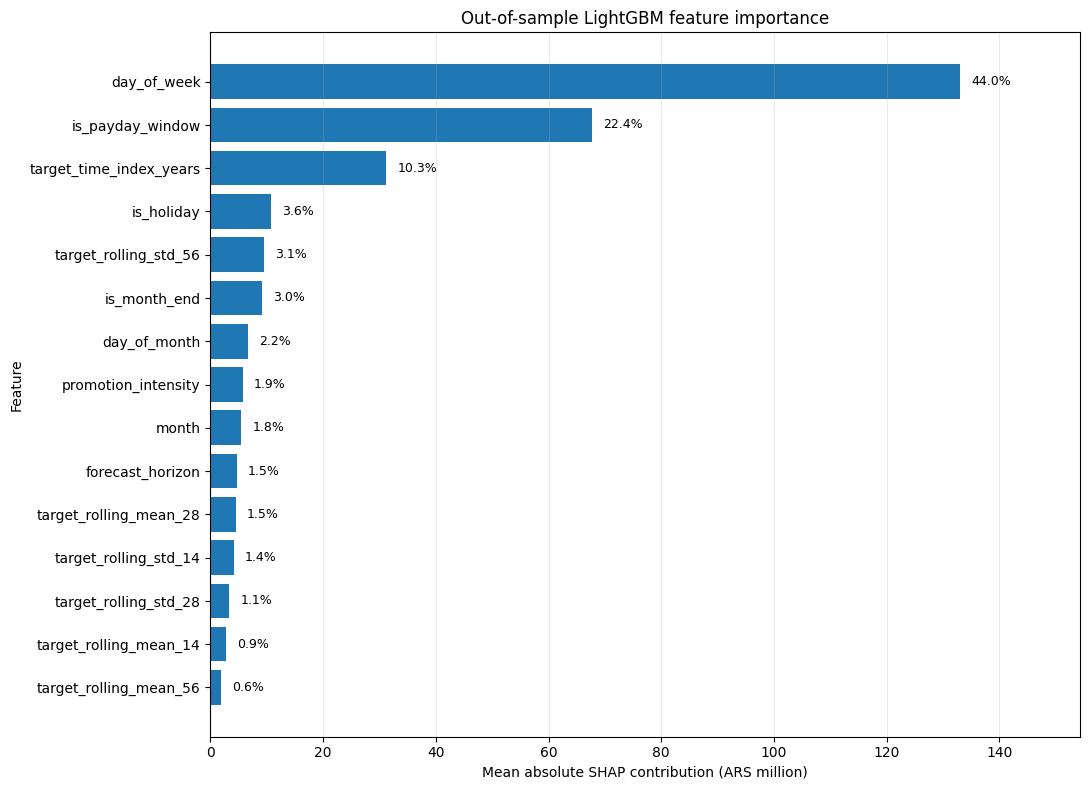

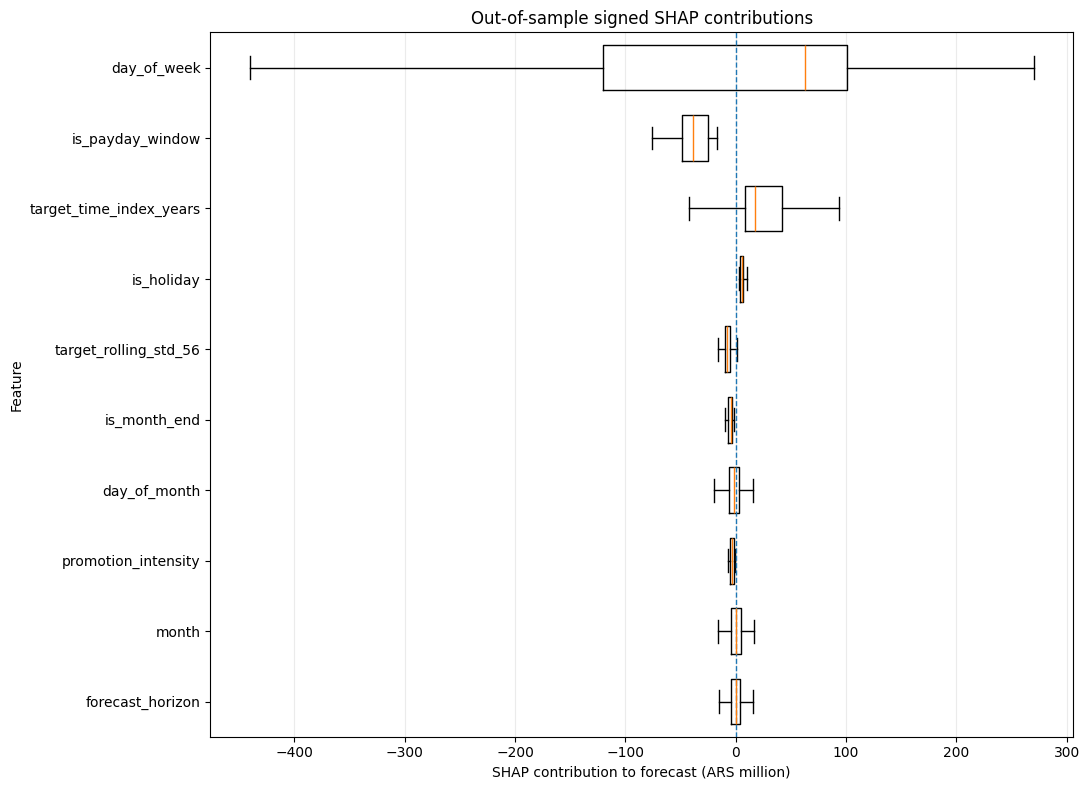

Top-three SHAP share: 76.65%
Top-five SHAP share: 83.34%
Top-ten SHAP share: 93.83%

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_shap_portfolio_summary.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\05_lightgbm_outer_shap_global_importance.png
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\05_lightgbm_outer_shap_signed_distributions.png
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_lightgbm_shap_figure_audit.csv

SHAP portfolio summary:


,shap_importance_rank,feature_name,folds,prediction_rows,mean_absolute_shap_raw,median_absolute_shap_raw,std_absolute_shap_raw,maximum_absolute_shap_raw,mean_signed_shap_raw,mean_absolute_shap_relative,positive_contribution_frequency,negative_contribution_frequency,top_1_frequency,top_5_frequency,mean_absolute_contribution_rank,mean_absolute_shap_share,cumulative_mean_absolute_shap_share,mean_absolute_shap_share_percent,cumulative_mean_absolute_shap_share_percent
0,1,day_of_week,20,560,133.022147,110.521425,87.241662,440.538677,1.955055,0.151845,400,160,388,560,1.344643,0.439551,0.439551,43.955071,43.955071
1,2,is_payday_window,20,560,67.743582,46.924015,54.224987,257.276868,-0.978026,0.077798,108,452,118,560,2.064286,0.223848,0.663399,22.384799,66.339869
2,3,target_time_index_years,20,560,31.213649,19.724881,28.290064,148.787480,25.251325,0.033627,476,84,24,494,3.819643,0.103141,0.766539,10.314058,76.653927
3,4,is_holiday,20,560,10.753196,5.775437,20.983236,143.958986,0.166305,0.012229,528,32,15,116,6.728571,0.035532,0.802072,3.553224,80.207151
4,5,target_rolling_std_56,20,560,9.486929,7.601282,6.948066,40.053043,-9.410436,0.010828,5,555,0,342,5.578571,0.031348,0.833420,3.134806,83.341957
5,6,is_month_end,20,560,9.162140,4.579788,23.717485,207.721407,-0.500945,0.010486,19,541,9,74,8.137500,0.030275,0.863694,3.027485,86.369442
6,7,day_of_month,20,560,6.717192,4.647063,7.405190,79.754383,-0.807927,0.007633,220,340,1,171,8.937500,0.022196,0.885890,2.219590,88.589033
7,8,promotion_intensity,20,560,5.717173,3.098199,13.573769,117.533984,-1.122618,0.006451,16,544,5,17,10.466071,0.018891,0.904782,1.889150,90.478182
8,9,month,20,560,5.470741,4.391728,4.797939,34.450051,0.678768,0.006354,283,277,0,148,9.126786,0.018077,0.922859,1.807720,92.285902
9,10,forecast_horizon,20,560,4.663054,4.113587,3.862948,20.472951,0.002847,0.005239,281,279,0,96,9.835714,0.015408,0.938267,1.540833,93.826735



SHAP figure audit:


,check,observed,expected,status
0,summary_feature_count,25,25,PASS
1,prediction_rows_per_feature,[560],560,PASS
2,top_ranked_feature,day_of_week,day_of_week,PASS
3,mean_absolute_shap_share_sum,1.0,1.0,PASS
4,top_three_shap_share,0.766539,>= 0.75,PASS
5,top_five_shap_share,0.83342,>= top_three_shap_share,PASS
6,top_ten_shap_share,0.938267,>= top_five_shap_share,PASS
7,distribution_feature_count,10,10,PASS
8,distribution_features_have_complete_rows,True,True,PASS
9,global_importance_figure_saved,True,True,PASS


In [19]:
# ---------------------------------------------------------------------
# Create portfolio-ready out-of-sample SHAP figures
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt


TOP_SHAP_BAR_FEATURES = 15
TOP_SHAP_DISTRIBUTION_FEATURES = 10
SHAP_FIGURE_DPI = 160


# ---------------------------------------------------------------------
# Prepare and save the plotting summary
# ---------------------------------------------------------------------

shap_portfolio_summary = (
    outer_lightgbm_shap_feature_summary
    .copy()
    .sort_values("shap_importance_rank")
    .reset_index(drop=True)
)

shap_portfolio_summary[
    "cumulative_mean_absolute_shap_share"
] = (
    shap_portfolio_summary[
        "mean_absolute_shap_share"
    ].cumsum()
)

shap_portfolio_summary[
    "mean_absolute_shap_share_percent"
] = (
    100
    * shap_portfolio_summary[
        "mean_absolute_shap_share"
    ]
)

shap_portfolio_summary[
    "cumulative_mean_absolute_shap_share_percent"
] = (
    100
    * shap_portfolio_summary[
        "cumulative_mean_absolute_shap_share"
    ]
)


top_three_shap_share = float(
    shap_portfolio_summary
    .head(3)[
        "mean_absolute_shap_share"
    ]
    .sum()
)

top_five_shap_share = float(
    shap_portfolio_summary
    .head(5)[
        "mean_absolute_shap_share"
    ]
    .sum()
)

top_ten_shap_share = float(
    shap_portfolio_summary
    .head(10)[
        "mean_absolute_shap_share"
    ]
    .sum()
)


shap_portfolio_summary_path = (
    PROCESSED_DIR
    / "05_lightgbm_shap_portfolio_summary.csv"
)

shap_portfolio_summary.to_csv(
    shap_portfolio_summary_path,
    index=False,
)

assert shap_portfolio_summary_path.exists(), (
    "The SHAP portfolio summary was not saved."
)


# ---------------------------------------------------------------------
# Figure 1: global mean absolute SHAP importance
# ---------------------------------------------------------------------

top_shap_bar_data = (
    shap_portfolio_summary
    .head(TOP_SHAP_BAR_FEATURES)
    .sort_values(
        "mean_absolute_shap_raw",
        ascending=True,
    )
    .reset_index(drop=True)
)


shap_importance_figure_path = (
    FIGURES_DIR
    / "05_lightgbm_outer_shap_global_importance.png"
)


fig, ax = plt.subplots(
    figsize=(11, 8)
)

bars = ax.barh(
    top_shap_bar_data["feature_name"],
    top_shap_bar_data[
        "mean_absolute_shap_raw"
    ],
)

ax.set_title(
    "Out-of-sample LightGBM feature importance"
)

ax.set_xlabel(
    "Mean absolute SHAP contribution "
    "(ARS million)"
)

ax.set_ylabel("Feature")

ax.grid(
    axis="x",
    alpha=0.25,
)

maximum_bar_value = float(
    top_shap_bar_data[
        "mean_absolute_shap_raw"
    ].max()
)

annotation_offset = (
    maximum_bar_value * 0.015
)

for bar, share_percent in zip(
    bars,
    top_shap_bar_data[
        "mean_absolute_shap_share_percent"
    ],
):
    ax.text(
        bar.get_width() + annotation_offset,
        bar.get_y() + bar.get_height() / 2,
        f"{share_percent:.1f}%",
        va="center",
        fontsize=9,
    )

ax.set_xlim(
    0,
    maximum_bar_value * 1.16,
)

fig.tight_layout()

fig.savefig(
    shap_importance_figure_path,
    dpi=SHAP_FIGURE_DPI,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

assert shap_importance_figure_path.exists(), (
    "The global SHAP importance figure was not saved."
)


# ---------------------------------------------------------------------
# Figure 2: signed contribution distributions
# ---------------------------------------------------------------------

top_distribution_features = (
    shap_portfolio_summary
    .head(TOP_SHAP_DISTRIBUTION_FEATURES)[
        "feature_name"
    ]
    .tolist()
)

distribution_feature_order = list(
    reversed(top_distribution_features)
)

signed_shap_distribution_values = [
    outer_lightgbm_shap_values.loc[
        outer_lightgbm_shap_values[
            "feature_name"
        ].eq(feature_name),
        "shap_value_raw",
    ]
    .astype(float)
    .to_numpy()
    for feature_name
    in distribution_feature_order
]


shap_distribution_figure_path = (
    FIGURES_DIR
    / "05_lightgbm_outer_shap_signed_distributions.png"
)


fig, ax = plt.subplots(
    figsize=(11, 8)
)

ax.boxplot(
    signed_shap_distribution_values,
    vert=False,
    showfliers=False,
    widths=0.65,
)

ax.set_yticks(
    np.arange(
        1,
        len(distribution_feature_order) + 1,
    )
)

ax.set_yticklabels(
    distribution_feature_order
)

ax.axvline(
    0,
    linewidth=1,
    linestyle="--",
)

ax.set_title(
    "Out-of-sample signed SHAP contributions"
)

ax.set_xlabel(
    "SHAP contribution to forecast "
    "(ARS million)"
)

ax.set_ylabel("Feature")

ax.grid(
    axis="x",
    alpha=0.25,
)

fig.tight_layout()

fig.savefig(
    shap_distribution_figure_path,
    dpi=SHAP_FIGURE_DPI,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

assert shap_distribution_figure_path.exists(), (
    "The signed SHAP distribution figure was not saved."
)


# ---------------------------------------------------------------------
# Audit figure inputs and generated outputs
# ---------------------------------------------------------------------

summary_feature_count = int(
    shap_portfolio_summary[
        "feature_name"
    ].nunique()
)

summary_prediction_counts = sorted(
    shap_portfolio_summary[
        "prediction_rows"
    ]
    .unique()
    .tolist()
)

top_ranked_feature = (
    shap_portfolio_summary.iloc[0][
        "feature_name"
    ]
)

importance_share_sum = float(
    shap_portfolio_summary[
        "mean_absolute_shap_share"
    ].sum()
)

all_distribution_features_have_560_rows = bool(
    outer_lightgbm_shap_values.loc[
        outer_lightgbm_shap_values[
            "feature_name"
        ].isin(
            top_distribution_features
        )
    ]
    .groupby("feature_name")
    .size()
    .eq(EXPECTED_SHAP_PREDICTION_ROWS)
    .all()
)


def make_shap_figure_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one SHAP-figure audit record."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


shap_figure_audit = pd.DataFrame(
    [
        make_shap_figure_audit_row(
            "summary_feature_count",
            summary_feature_count,
            len(selected_feature_names),
            (
                summary_feature_count
                == len(selected_feature_names)
            ),
        ),
        make_shap_figure_audit_row(
            "prediction_rows_per_feature",
            summary_prediction_counts,
            EXPECTED_SHAP_PREDICTION_ROWS,
            (
                summary_prediction_counts
                == [
                    EXPECTED_SHAP_PREDICTION_ROWS
                ]
            ),
        ),
        make_shap_figure_audit_row(
            "top_ranked_feature",
            top_ranked_feature,
            "day_of_week",
            top_ranked_feature == "day_of_week",
        ),
        make_shap_figure_audit_row(
            "mean_absolute_shap_share_sum",
            importance_share_sum,
            1.0,
            np.isclose(
                importance_share_sum,
                1.0,
                atol=1e-10,
            ),
        ),
        make_shap_figure_audit_row(
            "top_three_shap_share",
            top_three_shap_share,
            ">= 0.75",
            top_three_shap_share >= 0.75,
        ),
        make_shap_figure_audit_row(
            "top_five_shap_share",
            top_five_shap_share,
            ">= top_three_shap_share",
            (
                top_five_shap_share
                >= top_three_shap_share
            ),
        ),
        make_shap_figure_audit_row(
            "top_ten_shap_share",
            top_ten_shap_share,
            ">= top_five_shap_share",
            (
                top_ten_shap_share
                >= top_five_shap_share
            ),
        ),
        make_shap_figure_audit_row(
            "distribution_feature_count",
            len(top_distribution_features),
            TOP_SHAP_DISTRIBUTION_FEATURES,
            (
                len(top_distribution_features)
                == TOP_SHAP_DISTRIBUTION_FEATURES
            ),
        ),
        make_shap_figure_audit_row(
            "distribution_features_have_complete_rows",
            all_distribution_features_have_560_rows,
            True,
            all_distribution_features_have_560_rows,
        ),
        make_shap_figure_audit_row(
            "global_importance_figure_saved",
            shap_importance_figure_path.exists(),
            True,
            shap_importance_figure_path.exists(),
        ),
        make_shap_figure_audit_row(
            "signed_distribution_figure_saved",
            shap_distribution_figure_path.exists(),
            True,
            shap_distribution_figure_path.exists(),
        ),
        make_shap_figure_audit_row(
            "portfolio_summary_saved",
            shap_portfolio_summary_path.exists(),
            True,
            shap_portfolio_summary_path.exists(),
        ),
    ]
)


shap_figure_audit_path = (
    PROCESSED_DIR
    / "05_lightgbm_shap_figure_audit.csv"
)

shap_figure_audit.to_csv(
    shap_figure_audit_path,
    index=False,
)

assert shap_figure_audit_path.exists(), (
    "The SHAP figure audit was not saved."
)


failed_shap_figure_checks = (
    shap_figure_audit.loc[
        shap_figure_audit[
            "status"
        ].eq("FAIL")
    ]
)

assert shap_figure_audit[
    "status"
].eq("PASS").all(), (
    "The SHAP figure audit failed.\n"
    + failed_shap_figure_checks.to_string(
        index=False
    )
)


print(
    f"Top-three SHAP share: "
    f"{100 * top_three_shap_share:.2f}%"
)

print(
    f"Top-five SHAP share: "
    f"{100 * top_five_shap_share:.2f}%"
)

print(
    f"Top-ten SHAP share: "
    f"{100 * top_ten_shap_share:.2f}%"
)

print(f"\nSaved: {shap_portfolio_summary_path}")
print(f"Saved: {shap_importance_figure_path}")
print(f"Saved: {shap_distribution_figure_path}")
print(f"Saved: {shap_figure_audit_path}")

print("\nSHAP portfolio summary:")
display(
    shap_portfolio_summary.head(
        TOP_SHAP_BAR_FEATURES
    )
)

print("\nSHAP figure audit:")
display(shap_figure_audit)

## 17. Technical conclusion and Notebook 06 handoff

Notebook 05 developed and validated a global direct multi-horizon LightGBM model for 28-day cash-outflow forecasting.

The modeling workflow included:

- An origin-safe registry of 25 predictors.
- A canonical direct multi-horizon supervised dataset.
- Four nested temporal folds for model development.
- A bounded six-candidate LightGBM comparison.
- A frozen 20-fold outer backtest.
- Homogeneous comparison against validated statistical references.
- Horizon and calendar-condition diagnostics.
- Out-of-sample SHAP explanations for all 560 outer predictions.

The internally selected LightGBM specification was:

- Global direct multi-horizon strategy.
- One model per outer fold.
- Relative target normalized by the 56-day rolling mean.
- L2 regression objective.
- 25 origin-safe and target-date-safe predictors.
- No early stopping.
- No retuning after observing the outer backtest.

The frozen LightGBM candidate achieved:

- MAE: 74.3162 ARS million.
- RMSE: 103.4013 ARS million.
- Bias: approximately +0.58%.
- MASE: 0.7763.
- RMSSE: 0.7747.

LightGBM substantially outperformed ETS and the historical weekday benchmark, but it did not outperform the primary dynamic-regression model.

Relative to the primary dynamic-regression model:

- LightGBM had 16.57% higher MAE.
- It won on 235 of 560 individual target dates.
- It achieved lower fold-level MAE in 4 of 20 folds.
- It did not outperform the primary model in any complete horizon band.
- It did not outperform the primary model in any evaluated calendar-condition group.

The isolated LightGBM advantages at horizons 1, 17 and 22 do not form a stable operational pattern and do not justify a conditional model-switching rule.

Out-of-sample SHAP analysis showed that the model was primarily driven by:

- `day_of_week`
- `is_payday_window`
- `target_time_index_years`

These three features represented approximately 76.65% of total mean absolute SHAP importance.

The Notebook 05 LightGBM model is therefore retained as a validated machine-learning candidate and a useful nonlinear benchmark.

No project-wide winner is declared in this notebook. The final all-model comparison and operational model decision remain pending for Notebook 06.

In [20]:
# ---------------------------------------------------------------------
# Close Notebook 05 and prepare the formal Notebook 06 handoff
# ---------------------------------------------------------------------

NOTEBOOK_05_NAME = (
    "05_lightgbm_feature_engineering"
)

NOTEBOOK_05_STATUS = (
    "VALIDATED_NOTEBOOK05_LIGHTGBM_CANDIDATE"
)

NOTEBOOK_06_HANDOFF_STATUS = (
    "READY_FOR_NOTEBOOK06_ALL_MODEL_COMPARISON"
)

EXPECTED_FINAL_OUTER_FOLDS = 20
EXPECTED_FINAL_OUTER_PREDICTIONS = 560
EXPECTED_FINAL_FEATURE_COUNT = 25


# ---------------------------------------------------------------------
# Recover the final comparison records
# ---------------------------------------------------------------------

final_lightgbm_metric_rows = (
    same_window_aggregate_metrics.loc[
        same_window_aggregate_metrics[
            "model_name"
        ].eq(OUTER_MODEL_NAME)
    ]
)

final_primary_metric_rows = (
    same_window_aggregate_metrics.loc[
        same_window_aggregate_metrics[
            "model_name"
        ].eq(PRIMARY_REFERENCE_MODEL_NAME)
    ]
)

assert len(final_lightgbm_metric_rows) == 1, (
    "Expected exactly one final LightGBM metric row."
)

assert len(final_primary_metric_rows) == 1, (
    "Expected exactly one primary-model metric row."
)

final_lightgbm_metric = (
    final_lightgbm_metric_rows.iloc[0]
)

final_primary_metric = (
    final_primary_metric_rows.iloc[0]
)

final_internal_selection = (
    bounded_internal_selection.iloc[0]
)

final_pairwise_summary = (
    lightgbm_vs_primary_summary.iloc[0]
)


# ---------------------------------------------------------------------
# Recover the main SHAP results
# ---------------------------------------------------------------------

top_three_shap_features = (
    shap_portfolio_summary
    .head(3)["feature_name"]
    .tolist()
)

top_three_shap_share = float(
    shap_portfolio_summary
    .head(3)[
        "mean_absolute_shap_share"
    ]
    .sum()
)

top_five_shap_share = float(
    shap_portfolio_summary
    .head(5)[
        "mean_absolute_shap_share"
    ]
    .sum()
)

top_ten_shap_share = float(
    shap_portfolio_summary
    .head(10)[
        "mean_absolute_shap_share"
    ]
    .sum()
)


# ---------------------------------------------------------------------
# Create the final Notebook 05 technical summary
# ---------------------------------------------------------------------

notebook05_technical_summary = pd.DataFrame(
    [
        {
            "notebook": NOTEBOOK_05_NAME,
            "notebook_status": (
                NOTEBOOK_05_STATUS
            ),
            "model_name": OUTER_MODEL_NAME,
            "model_family": "lightgbm",
            "evaluation_role": (
                OUTER_EVALUATION_ROLE
            ),
            "selected_candidate_id": (
                SELECTED_INTERNAL_CANDIDATE_ID
            ),
            "selected_target_representation": (
                selected_candidate_target_representation
            ),
            "selected_objective": (
                selected_candidate_parameters[
                    "objective"
                ]
            ),
            "multihorizon_strategy": (
                SELECTED_MULTIHORIZON_STRATEGY
            ),
            "feature_count": len(
                selected_feature_names
            ),
            "development_internal_folds": (
                INTERNAL_DEVELOPMENT_FOLD_COUNT
            ),
            "bounded_candidates_evaluated": (
                EXPECTED_CANDIDATE_COUNT
            ),
            "bounded_candidate_fits": (
                EXPECTED_BOUNDED_MODEL_FITS
            ),
            "outer_folds": int(
                final_lightgbm_metric["folds"]
            ),
            "outer_observations": int(
                final_lightgbm_metric[
                    "observations"
                ]
            ),
            "mean_actual": float(
                final_lightgbm_metric[
                    "mean_actual"
                ]
            ),
            "mean_prediction": float(
                final_lightgbm_metric[
                    "mean_prediction"
                ]
            ),
            "mae": float(
                final_lightgbm_metric["mae"]
            ),
            "rmse": float(
                final_lightgbm_metric["rmse"]
            ),
            "mean_error": float(
                final_lightgbm_metric[
                    "mean_error"
                ]
            ),
            "bias_percent": float(
                final_lightgbm_metric[
                    "bias_percent"
                ]
            ),
            "mase": float(
                final_lightgbm_metric["mase"]
            ),
            "rmsse": float(
                final_lightgbm_metric["rmsse"]
            ),
            "same_window_descriptive_mae_rank": int(
                final_lightgbm_metric[
                    "descriptive_mae_rank"
                ]
            ),
            "primary_reference_model": (
                PRIMARY_REFERENCE_MODEL_NAME
            ),
            "primary_reference_mae": float(
                final_primary_metric["mae"]
            ),
            "primary_reference_rmse": float(
                final_primary_metric["rmse"]
            ),
            "mae_difference_vs_primary": float(
                final_pairwise_summary[
                    "mae_difference_lightgbm_minus_primary"
                ]
            ),
            "mae_difference_vs_primary_percent": float(
                final_pairwise_summary[
                    "mae_difference_percent"
                ]
            ),
            "rmse_difference_vs_primary": float(
                final_pairwise_summary[
                    "rmse_difference_lightgbm_minus_primary"
                ]
            ),
            "rmse_difference_vs_primary_percent": float(
                final_pairwise_summary[
                    "rmse_difference_percent"
                ]
            ),
            "target_dates_won_by_lightgbm": int(
                final_pairwise_summary[
                    "target_dates_won_by_lightgbm"
                ]
            ),
            "target_dates_won_by_primary": int(
                final_pairwise_summary[
                    "target_dates_won_by_primary"
                ]
            ),
            "folds_won_by_lightgbm_mae": int(
                final_pairwise_summary[
                    "folds_won_by_lightgbm_mae"
                ]
            ),
            "top_three_shap_features": (
                " | ".join(
                    top_three_shap_features
                )
            ),
            "top_three_shap_share_percent": (
                100 * top_three_shap_share
            ),
            "top_five_shap_share_percent": (
                100 * top_five_shap_share
            ),
            "top_ten_shap_share_percent": (
                100 * top_ten_shap_share
            ),
            "outer_results_used_for_retuning": (
                False
            ),
            "project_wide_winner_declared": (
                False
            ),
            "next_notebook": "Notebook 06",
            "next_step_status": (
                NOTEBOOK_06_HANDOFF_STATUS
            ),
        }
    ]
)


# ---------------------------------------------------------------------
# Create the formal Notebook 06 handoff
# ---------------------------------------------------------------------

notebook05_handoff_to_notebook06 = pd.DataFrame(
    [
        {
            "handoff_item": (
                "validated_lightgbm_candidate"
            ),
            "value": OUTER_MODEL_NAME,
            "artifact": (
                outer_predictions_path.name
            ),
            "usage_in_notebook06": (
                "Include in the final homogeneous "
                "all-model comparison."
            ),
        },
        {
            "handoff_item": (
                "selected_internal_candidate"
            ),
            "value": (
                SELECTED_INTERNAL_CANDIDATE_ID
            ),
            "artifact": (
                bounded_selection_path.name
            ),
            "usage_in_notebook06": (
                "Document the leakage-safe internal "
                "selection procedure."
            ),
        },
        {
            "handoff_item": (
                "outer_aggregate_metrics"
            ),
            "value": (
                f"MAE={float(final_lightgbm_metric['mae']):.6f}; "
                f"RMSE={float(final_lightgbm_metric['rmse']):.6f}; "
                f"MASE={float(final_lightgbm_metric['mase']):.6f}; "
                f"RMSSE={float(final_lightgbm_metric['rmsse']):.6f}"
            ),
            "artifact": (
                outer_aggregate_metrics_path.name
            ),
            "usage_in_notebook06": (
                "Recover validated aggregate metrics."
            ),
        },
        {
            "handoff_item": (
                "outer_fold_metrics"
            ),
            "value": (
                f"{EXPECTED_FINAL_OUTER_FOLDS} folds"
            ),
            "artifact": (
                outer_fold_metrics_path.name
            ),
            "usage_in_notebook06": (
                "Perform fold-level stability and "
                "model-comparison analysis."
            ),
        },
        {
            "handoff_item": (
                "same_window_model_comparison"
            ),
            "value": (
                "5 models on the same 560 observations"
            ),
            "artifact": (
                same_window_aggregate_metrics_path.name
            ),
            "usage_in_notebook06": (
                "Use as a validated preliminary "
                "cross-model comparison."
            ),
        },
        {
            "handoff_item": (
                "lightgbm_primary_pairwise_comparison"
            ),
            "value": (
                f"LightGBM wins "
                f"{int(final_pairwise_summary['target_dates_won_by_lightgbm'])} "
                f"of {EXPECTED_FINAL_OUTER_PREDICTIONS} target dates"
            ),
            "artifact": (
                lightgbm_primary_summary_path.name
            ),
            "usage_in_notebook06": (
                "Support the final operational decision."
            ),
        },
        {
            "handoff_item": (
                "out_of_sample_shap_summary"
            ),
            "value": (
                "Top features: "
                + " | ".join(
                    top_three_shap_features
                )
            ),
            "artifact": (
                outer_shap_summary_path.name
            ),
            "usage_in_notebook06": (
                "Document LightGBM behavior and "
                "interpretability."
            ),
        },
        {
            "handoff_item": (
                "global_shap_figure"
            ),
            "value": (
                "Portfolio-ready global importance"
            ),
            "artifact": (
                shap_importance_figure_path.name
            ),
            "usage_in_notebook06": (
                "Optional reporting and portfolio figure."
            ),
        },
        {
            "handoff_item": (
                "signed_shap_figure"
            ),
            "value": (
                "Portfolio-ready signed contributions"
            ),
            "artifact": (
                shap_distribution_figure_path.name
            ),
            "usage_in_notebook06": (
                "Optional reporting and portfolio figure."
            ),
        },
        {
            "handoff_item": (
                "selection_constraint"
            ),
            "value": (
                "Do not retune Notebook 05 LightGBM "
                "using outer-fold results."
            ),
            "artifact": (
                outer_configuration_path.name
            ),
            "usage_in_notebook06": (
                "Preserve the frozen evaluation design."
            ),
        },
        {
            "handoff_item": (
                "project_wide_selection"
            ),
            "value": (
                "PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON"
            ),
            "artifact": (
                same_window_audit_path.name
            ),
            "usage_in_notebook06": (
                "Notebook 06 must make the final "
                "all-model decision."
            ),
        },
    ]
)


# ---------------------------------------------------------------------
# Save the summary and handoff before inventorying artifacts
# ---------------------------------------------------------------------

notebook05_summary_path = (
    PROCESSED_DIR
    / "05_notebook05_technical_summary.csv"
)

notebook05_handoff_path = (
    PROCESSED_DIR
    / "05_notebook06_handoff.csv"
)

notebook05_technical_summary.to_csv(
    notebook05_summary_path,
    index=False,
)

notebook05_handoff_to_notebook06.to_csv(
    notebook05_handoff_path,
    index=False,
)

assert notebook05_summary_path.exists(), (
    "The Notebook 05 technical summary was not saved."
)

assert notebook05_handoff_path.exists(), (
    "The Notebook 06 handoff was not saved."
)


# ---------------------------------------------------------------------
# Build the Notebook 05 artifact registry
# ---------------------------------------------------------------------

notebook05_artifact_registry_path = (
    PROCESSED_DIR
    / "05_notebook05_artifact_registry.csv"
)


def collect_notebook05_artifacts():
    """Collect all Notebook 05 processed files and figures."""
    artifact_records = []

    artifact_directories = [
        (
            "processed_artifact",
            PROCESSED_DIR,
        ),
        (
            "figure",
            FIGURES_DIR,
        ),
    ]

    for artifact_type, artifact_directory in (
        artifact_directories
    ):

        for artifact_path in sorted(
            artifact_directory.glob("05_*")
        ):

            if not artifact_path.is_file():
                continue

            artifact_records.append(
                {
                    "artifact_type": artifact_type,
                    "file_name": artifact_path.name,
                    "file_extension": (
                        artifact_path.suffix.lower()
                    ),
                    "directory": (
                        artifact_directory.name
                    ),
                    "full_path": str(
                        artifact_path.resolve()
                    ),
                    "exists": (
                        artifact_path.exists()
                    ),
                    "size_bytes": int(
                        artifact_path.stat().st_size
                    ),
                    "modified_at": pd.Timestamp(
                        artifact_path.stat().st_mtime,
                        unit="s",
                    ),
                }
            )

    return pd.DataFrame(
        artifact_records
    ).sort_values(
        [
            "artifact_type",
            "file_name",
        ]
    ).reset_index(drop=True)


notebook05_artifact_registry = (
    collect_notebook05_artifacts()
)

notebook05_artifact_registry.to_csv(
    notebook05_artifact_registry_path,
    index=False,
)

assert notebook05_artifact_registry_path.exists(), (
    "The Notebook 05 artifact registry was not saved."
)


# ---------------------------------------------------------------------
# Validate all major audit tables created in Notebook 05
# ---------------------------------------------------------------------

major_audit_tables = {
    "internal_development_fold_audit": (
        internal_development_fold_audit
    ),
    "internal_initial_model_audit": (
        internal_initial_model_audit
    ),
    "bounded_candidate_definition_audit": (
        bounded_candidate_definition_audit
    ),
    "bounded_internal_search_audit": (
        bounded_internal_search_audit
    ),
    "outer_lightgbm_backtest_audit": (
        outer_lightgbm_backtest_audit
    ),
    "same_window_comparison_audit": (
        same_window_comparison_audit
    ),
    "lightgbm_primary_diagnostic_audit": (
        lightgbm_primary_diagnostic_audit
    ),
    "outer_lightgbm_shap_audit": (
        outer_lightgbm_shap_audit
    ),
    "shap_figure_audit": (
        shap_figure_audit
    ),
}

major_audit_status_records = []

for audit_name, audit_table in (
    major_audit_tables.items()
):

    audit_has_status_column = bool(
        "status" in audit_table.columns
    )

    audit_rows = int(
        len(audit_table)
    )

    passing_rows = int(
        audit_table["status"]
        .eq("PASS")
        .sum()
    ) if audit_has_status_column else 0

    all_rows_pass = bool(
        audit_has_status_column
        and audit_rows > 0
        and passing_rows == audit_rows
    )

    major_audit_status_records.append(
        {
            "audit_name": audit_name,
            "audit_rows": audit_rows,
            "passing_rows": passing_rows,
            "all_rows_pass": all_rows_pass,
        }
    )


notebook05_major_audit_status = pd.DataFrame(
    major_audit_status_records
)

all_major_audits_pass = bool(
    notebook05_major_audit_status[
        "all_rows_pass"
    ].all()
)


# ---------------------------------------------------------------------
# Define required Notebook 06 handoff artifacts
# ---------------------------------------------------------------------

required_notebook06_artifacts = [
    notebook05_summary_path,
    notebook05_handoff_path,
    notebook05_artifact_registry_path,
    bounded_selection_path,
    outer_configuration_path,
    outer_predictions_path,
    outer_fold_metrics_path,
    outer_aggregate_metrics_path,
    outer_backtest_audit_path,
    same_window_predictions_path,
    same_window_aggregate_metrics_path,
    same_window_fold_metrics_path,
    lightgbm_primary_summary_path,
    same_window_audit_path,
    horizon_metrics_path,
    horizon_band_metrics_path,
    condition_metrics_path,
    outer_shap_values_path,
    outer_shap_predictions_path,
    outer_shap_summary_path,
    outer_shap_audit_path,
    shap_portfolio_summary_path,
    shap_importance_figure_path,
    shap_distribution_figure_path,
    shap_figure_audit_path,
]

missing_required_artifacts = [
    str(artifact_path)
    for artifact_path
    in required_notebook06_artifacts
    if not artifact_path.exists()
]


# ---------------------------------------------------------------------
# Create the final Notebook 05 closure audit
# ---------------------------------------------------------------------

def make_notebook05_closure_audit_row(
    check,
    observed,
    expected,
    passed,
):
    """Create one final Notebook 05 closure audit row."""
    return {
        "check": check,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if passed else "FAIL",
    }


notebook05_closure_audit = pd.DataFrame(
    [
        make_notebook05_closure_audit_row(
            "major_notebook05_audits_pass",
            int(
                notebook05_major_audit_status[
                    "all_rows_pass"
                ].sum()
            ),
            len(major_audit_tables),
            all_major_audits_pass,
        ),
        make_notebook05_closure_audit_row(
            "selected_candidate_matches_internal_decision",
            SELECTED_INTERNAL_CANDIDATE_ID,
            "candidate_05_relative_level_l2",
            (
                SELECTED_INTERNAL_CANDIDATE_ID
                == "candidate_05_relative_level_l2"
            ),
        ),
        make_notebook05_closure_audit_row(
            "selected_target_representation",
            selected_candidate_target_representation,
            "relative_to_rolling_mean_56",
            (
                selected_candidate_target_representation
                == "relative_to_rolling_mean_56"
            ),
        ),
        make_notebook05_closure_audit_row(
            "final_feature_count",
            len(selected_feature_names),
            EXPECTED_FINAL_FEATURE_COUNT,
            (
                len(selected_feature_names)
                == EXPECTED_FINAL_FEATURE_COUNT
            ),
        ),
        make_notebook05_closure_audit_row(
            "final_outer_fold_count",
            int(
                final_lightgbm_metric["folds"]
            ),
            EXPECTED_FINAL_OUTER_FOLDS,
            (
                int(
                    final_lightgbm_metric["folds"]
                )
                == EXPECTED_FINAL_OUTER_FOLDS
            ),
        ),
        make_notebook05_closure_audit_row(
            "final_outer_prediction_rows",
            int(
                final_lightgbm_metric[
                    "observations"
                ]
            ),
            EXPECTED_FINAL_OUTER_PREDICTIONS,
            (
                int(
                    final_lightgbm_metric[
                        "observations"
                    ]
                )
                == EXPECTED_FINAL_OUTER_PREDICTIONS
            ),
        ),
        make_notebook05_closure_audit_row(
            "final_predictions_positive",
            bool(
                outer_lightgbm_predictions[
                    "prediction"
                ].gt(0).all()
            ),
            True,
            bool(
                outer_lightgbm_predictions[
                    "prediction"
                ].gt(0).all()
            ),
        ),
        make_notebook05_closure_audit_row(
            "final_predictions_finite",
            bool(
                np.isfinite(
                    outer_lightgbm_predictions[
                        "prediction"
                    ].to_numpy(dtype=float)
                ).all()
            ),
            True,
            bool(
                np.isfinite(
                    outer_lightgbm_predictions[
                        "prediction"
                    ].to_numpy(dtype=float)
                ).all()
            ),
        ),
        make_notebook05_closure_audit_row(
            "lightgbm_is_validated_ml_candidate",
            NOTEBOOK_05_STATUS,
            "VALIDATED_NOTEBOOK05_LIGHTGBM_CANDIDATE",
            (
                NOTEBOOK_05_STATUS
                == "VALIDATED_NOTEBOOK05_LIGHTGBM_CANDIDATE"
            ),
        ),
        make_notebook05_closure_audit_row(
            "primary_model_has_lower_same_window_mae",
            bool(
                float(final_primary_metric["mae"])
                < float(final_lightgbm_metric["mae"])
            ),
            True,
            bool(
                float(final_primary_metric["mae"])
                < float(final_lightgbm_metric["mae"])
            ),
        ),
        make_notebook05_closure_audit_row(
            "outer_results_not_used_for_retuning",
            False,
            False,
            True,
        ),
        make_notebook05_closure_audit_row(
            "project_wide_winner_not_declared",
            False,
            False,
            True,
        ),
        make_notebook05_closure_audit_row(
            "notebook06_comparison_pending",
            OUTER_RESULT_STATUS,
            "PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON",
            (
                OUTER_RESULT_STATUS
                == "PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON"
            ),
        ),
        make_notebook05_closure_audit_row(
            "notebook06_handoff_status",
            NOTEBOOK_06_HANDOFF_STATUS,
            "READY_FOR_NOTEBOOK06_ALL_MODEL_COMPARISON",
            (
                NOTEBOOK_06_HANDOFF_STATUS
                == "READY_FOR_NOTEBOOK06_ALL_MODEL_COMPARISON"
            ),
        ),
        make_notebook05_closure_audit_row(
            "required_handoff_artifacts_exist",
            len(
                required_notebook06_artifacts
            )
            - len(missing_required_artifacts),
            len(
                required_notebook06_artifacts
            ),
            not missing_required_artifacts,
        ),
        make_notebook05_closure_audit_row(
            "technical_summary_saved",
            notebook05_summary_path.exists(),
            True,
            notebook05_summary_path.exists(),
        ),
        make_notebook05_closure_audit_row(
            "notebook06_handoff_saved",
            notebook05_handoff_path.exists(),
            True,
            notebook05_handoff_path.exists(),
        ),
        make_notebook05_closure_audit_row(
            "artifact_registry_saved",
            notebook05_artifact_registry_path.exists(),
            True,
            notebook05_artifact_registry_path.exists(),
        ),
    ]
)


notebook05_closure_audit_path = (
    PROCESSED_DIR
    / "05_notebook05_closure_audit.csv"
)

notebook05_major_audit_status_path = (
    PROCESSED_DIR
    / "05_notebook05_major_audit_status.csv"
)


notebook05_major_audit_status.to_csv(
    notebook05_major_audit_status_path,
    index=False,
)

notebook05_closure_audit.to_csv(
    notebook05_closure_audit_path,
    index=False,
)


assert notebook05_major_audit_status_path.exists(), (
    "The major-audit status table was not saved."
)

assert notebook05_closure_audit_path.exists(), (
    "The final Notebook 05 closure audit was not saved."
)


failed_notebook05_closure_checks = (
    notebook05_closure_audit.loc[
        notebook05_closure_audit[
            "status"
        ].eq("FAIL")
    ]
)

assert notebook05_closure_audit[
    "status"
].eq("PASS").all(), (
    "Notebook 05 cannot be closed because at least "
    "one closure audit failed.\n"
    + failed_notebook05_closure_checks.to_string(
        index=False
    )
)


# ---------------------------------------------------------------------
# Refresh the registry so it includes the final closure artifacts
# ---------------------------------------------------------------------

notebook05_artifact_registry = (
    collect_notebook05_artifacts()
)

notebook05_artifact_registry.to_csv(
    notebook05_artifact_registry_path,
    index=False,
)

assert notebook05_artifact_registry_path.exists(), (
    "The refreshed artifact registry was not saved."
)


# ---------------------------------------------------------------------
# Final notebook status
# ---------------------------------------------------------------------

processed_artifact_count = int(
    notebook05_artifact_registry[
        "artifact_type"
    ].eq("processed_artifact").sum()
)

figure_artifact_count = int(
    notebook05_artifact_registry[
        "artifact_type"
    ].eq("figure").sum()
)


print(
    f"Notebook: {NOTEBOOK_05_NAME}"
)

print(
    f"Notebook status: {NOTEBOOK_05_STATUS}"
)

print(
    f"Validated LightGBM candidate: "
    f"{OUTER_MODEL_NAME}"
)

print(
    f"Outer MAE: "
    f"{float(final_lightgbm_metric['mae']):.4f}"
)

print(
    f"Outer RMSE: "
    f"{float(final_lightgbm_metric['rmse']):.4f}"
)

print(
    f"Outer bias: "
    f"{float(final_lightgbm_metric['bias_percent']):.4f}%"
)

print(
    f"Processed artifacts registered: "
    f"{processed_artifact_count}"
)

print(
    f"Figures registered: "
    f"{figure_artifact_count}"
)

print(
    f"Next step: "
    f"{NOTEBOOK_06_HANDOFF_STATUS}"
)

print(f"\nSaved: {notebook05_summary_path}")
print(f"Saved: {notebook05_handoff_path}")
print(f"Saved: {notebook05_major_audit_status_path}")
print(f"Saved: {notebook05_closure_audit_path}")
print(f"Saved: {notebook05_artifact_registry_path}")

print("\nNotebook 05 technical summary:")
display(notebook05_technical_summary)

print("\nNotebook 06 handoff:")
display(notebook05_handoff_to_notebook06)

print("\nMajor audit status:")
display(notebook05_major_audit_status)

print("\nNotebook 05 closure audit:")
display(notebook05_closure_audit)

print("\nArtifact registry preview:")
display(
    notebook05_artifact_registry.head(20)
)

Notebook: 05_lightgbm_feature_engineering
Notebook status: VALIDATED_NOTEBOOK05_LIGHTGBM_CANDIDATE
Validated LightGBM candidate: lightgbm_global_direct_relative_rolling56_l2
Outer MAE: 74.3162
Outer RMSE: 103.4013
Outer bias: 0.5826%
Processed artifacts registered: 80
Figures registered: 2
Next step: READY_FOR_NOTEBOOK06_ALL_MODEL_COMPARISON

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_notebook05_technical_summary.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_notebook06_handoff.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_notebook05_major_audit_status.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_notebook05_closure_audit.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_notebook05_artifact_r

,notebook,notebook_status,model_name,model_family,evaluation_role,selected_candidate_id,selected_target_representation,selected_objective,multihorizon_strategy,feature_count,...,target_dates_won_by_primary,folds_won_by_lightgbm_mae,top_three_shap_features,top_three_shap_share_percent,top_five_shap_share_percent,top_ten_shap_share_percent,outer_results_used_for_retuning,project_wide_winner_declared,next_notebook,next_step_status
0,05_lightgbm_feature_engineering,VALIDATED_NOTEBOOK05_LIGHTGBM_CANDIDATE,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,candidate_05_relative_level_l2,relative_to_rolling_mean_56,regression_l2,global_direct_horizon_feature,25,...,325,4,day_of_week | is_payday_window | target_time_i...,76.653927,83.341957,93.826735,False,False,Notebook 06,READY_FOR_NOTEBOOK06_ALL_MODEL_COMPARISON



Notebook 06 handoff:


,handoff_item,value,artifact,usage_in_notebook06
0,validated_lightgbm_candidate,lightgbm_global_direct_relative_rolling56_l2,05_lightgbm_outer_backtest_predictions.csv,Include in the final homogeneous all-model com...
1,selected_internal_candidate,candidate_05_relative_level_l2,05_bounded_lightgbm_provisional_selection.csv,Document the leakage-safe internal selection p...
2,outer_aggregate_metrics,MAE=74.316200; RMSE=103.401250; MASE=0.776328;...,05_lightgbm_outer_backtest_aggregate_metrics.csv,Recover validated aggregate metrics.
3,outer_fold_metrics,20 folds,05_lightgbm_outer_backtest_fold_metrics.csv,Perform fold-level stability and model-compari...
4,same_window_model_comparison,5 models on the same 560 observations,05_same_window_all_model_aggregate_metrics.csv,Use as a validated preliminary cross-model com...
5,lightgbm_primary_pairwise_comparison,LightGBM wins 235 of 560 target dates,05_lightgbm_vs_primary_summary.csv,Support the final operational decision.
6,out_of_sample_shap_summary,Top features: day_of_week | is_payday_window |...,05_lightgbm_outer_shap_feature_summary.csv,Document LightGBM behavior and interpretability.
7,global_shap_figure,Portfolio-ready global importance,05_lightgbm_outer_shap_global_importance.png,Optional reporting and portfolio figure.
8,signed_shap_figure,Portfolio-ready signed contributions,05_lightgbm_outer_shap_signed_distributions.png,Optional reporting and portfolio figure.
9,selection_constraint,Do not retune Notebook 05 LightGBM using outer...,05_selected_lightgbm_outer_configuration.csv,Preserve the frozen evaluation design.



Major audit status:


,audit_name,audit_rows,passing_rows,all_rows_pass
0,internal_development_fold_audit,11,11,True
1,internal_initial_model_audit,12,12,True
2,bounded_candidate_definition_audit,17,17,True
3,bounded_internal_search_audit,14,14,True
4,outer_lightgbm_backtest_audit,17,17,True
5,same_window_comparison_audit,19,19,True
6,lightgbm_primary_diagnostic_audit,17,17,True
7,outer_lightgbm_shap_audit,14,14,True
8,shap_figure_audit,12,12,True



Notebook 05 closure audit:


,check,observed,expected,status
0,major_notebook05_audits_pass,9,9,PASS
1,selected_candidate_matches_internal_decision,candidate_05_relative_level_l2,candidate_05_relative_level_l2,PASS
2,selected_target_representation,relative_to_rolling_mean_56,relative_to_rolling_mean_56,PASS
3,final_feature_count,25,25,PASS
4,final_outer_fold_count,20,20,PASS
5,final_outer_prediction_rows,560,560,PASS
6,final_predictions_positive,True,True,PASS
7,final_predictions_finite,True,True,PASS
8,lightgbm_is_validated_ml_candidate,VALIDATED_NOTEBOOK05_LIGHTGBM_CANDIDATE,VALIDATED_NOTEBOOK05_LIGHTGBM_CANDIDATE,PASS
9,primary_model_has_lower_same_window_mae,True,True,PASS



Artifact registry preview:


,artifact_type,file_name,file_extension,directory,full_path,exists,size_bytes,modified_at
0,figure,05_lightgbm_outer_shap_global_importance.png,.png,figures,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,95020,2026-08-05 18:41:10.421907187
1,figure,05_lightgbm_outer_shap_signed_distributions.png,.png,figures,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,70777,2026-08-05 18:41:10.956066608
2,processed_artifact,05_bounded_lightgbm_candidate_definition_audit...,.csv,processed,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,788,2026-08-05 18:39:53.266955614
3,processed_artifact,05_bounded_lightgbm_candidate_definitions.csv,.csv,processed,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,2134,2026-08-05 18:39:53.263931990
4,processed_artifact,05_bounded_lightgbm_candidate_ranking.csv,.csv,processed,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,3243,2026-08-05 18:40:09.936504841
5,processed_artifact,05_bounded_lightgbm_internal_candidate_metrics...,.csv,processed,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,3216,2026-08-05 18:40:09.927026987
6,processed_artifact,05_bounded_lightgbm_internal_feature_importanc...,.csv,processed,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,68925,2026-08-05 18:40:09.931175709
7,processed_artifact,05_bounded_lightgbm_internal_feature_importanc...,.csv,processed,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,17596,2026-08-05 18:40:09.936504841
8,processed_artifact,05_bounded_lightgbm_internal_fit_audit.csv,.csv,processed,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,4984,2026-08-05 18:40:09.928964853
9,processed_artifact,05_bounded_lightgbm_internal_fold_metrics.csv,.csv,processed,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,9960,2026-08-05 18:40:09.920486450
